# OptiChain – Disruption-Aware Adaptive Inventory Optimization

## Inventory Guardian Module

**Research Project:**  
OptiChain: AI-Driven Supply Chain Disruption Predictor & Line Optimizer for Sri Lankan Garment Factories

### Research Objective

Develop a disruption-aware adaptive inventory optimization model that dynamically determines:

- Reorder Point (ROP)
- Safety Stock
- Reorder Quantity

by considering:

- Historical demand behaviour
- Demand variability
- Lead-time variability
- Supply disruption scenarios

### Development Strategy

The Inventory Optimization module is initially developed using historical DataCo supply-chain data.

The module will later integrate validated outputs from the upstream OptiChain modules:

- `Forecasted_Demand` from the Demand Forecasting module
- `Supplier_Risk_Score` from the Supply Disruption Prediction module

These upstream outputs are not fabricated during standalone development.


In [9]:
# ============================================================
# 1. Import Required Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [10]:
import glob
import os

csv_files = glob.glob("/content/*.csv")

print("CSV files in Colab:\n")

for file in csv_files:
    size_mb = os.path.getsize(file) / (1024 * 1024)
    print(f"{os.path.basename(file)} | {size_mb:.2f} MB")

CSV files in Colab:

DataCoSupplyChainDataset (1).csv | 91.47 MB


In [11]:
# ============================================================
# 3. Load Full DataCo Supply Chain Dataset
# ============================================================

file_path = "/content/DataCoSupplyChainDataset (1).csv"

df = pd.read_csv(
    file_path,
    encoding="latin-1"
)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (180519, 53)


In [12]:
# ============================================================
# 4. Basic Dataset Validation
# ============================================================

print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

print("\nNumber of columns:")
print(len(df.columns))

Dataset shape: (180519, 53)

First 5 rows:


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class



Number of duplicate rows:
0

Number of columns:
53


In [13]:
# ============================================================
# 5. Check Required Inventory Columns
# ============================================================

required_columns = [
    "order date (DateOrders)",
    "shipping date (DateOrders)",
    "Order Item Quantity",
    "Product Card Id",
    "Product Name",
    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "Order Id",
    "Order Item Id"
]

print("Required Inventory Columns:\n")

for col in required_columns:
    if col in df.columns:
        print(f"✓ {col}")
    else:
        print(f"✗ MISSING: {col}")

Required Inventory Columns:

✓ order date (DateOrders)
✓ shipping date (DateOrders)
✓ Order Item Quantity
✓ Product Card Id
✓ Product Name
✓ Days for shipping (real)
✓ Days for shipment (scheduled)
✓ Order Id
✓ Order Item Id


In [14]:
# ============================================================
# 3. Initial Dataset Validation
# ============================================================

print("Dataset Shape:")
print(df.shape)

print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())

print("\nNumber of Columns:")
print(len(df.columns))

print("\nFirst 10 Columns:")
print(df.columns[:10].tolist())

print("\nLast 10 Columns:")
print(df.columns[-10:].tolist())

Dataset Shape:
(180519, 53)

Number of Duplicate Rows:
0

Number of Columns:
53

First 10 Columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City']

Last 10 Columns:
['Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product Status', 'shipping date (DateOrders)', 'Shipping Mode']


In [ ]:
# ============================================================
# 4. Data Quality Audit
# ============================================================

# Data types
print("DATA TYPES")
print(df.dtypes)

# Missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("\nMISSING VALUES")
print(missing_values)

# Basic statistics for numerical columns
print("\nNUMERICAL SUMMARY")
display(df.describe().T)

In [15]:
# ============================================================
# 5. Create Inventory Analysis Dataset
# ============================================================

inventory_columns = [
    # Time
    "order date (DateOrders)",
    "shipping date (DateOrders)",

    # Order / product identification
    "Order Id",
    "Order Item Id",
    "Product Card Id",
    "Product Name",
    "Category Id",
    "Category Name",
    "Department Id",
    "Department Name",

    # Demand / quantity
    "Order Item Quantity",
    "Sales",
    "Order Item Product Price",
    "Order Item Discount",
    "Order Item Discount Rate",
    "Order Item Total",

    # Lead-time behaviour
    "Days for shipping (real)",
    "Days for shipment (scheduled)",

    # Supply-chain context
    "Shipping Mode",
    "Market",
    "Order Region",
    "Order Country",
    "Order State",

    # Customer / order context
    "Customer Segment",
    "Order Status",

    # Historical delivery-risk indicator
    "Late_delivery_risk"
]

inventory_df = df[inventory_columns].copy()

print("Inventory dataset created successfully.")
print("Shape:", inventory_df.shape)

print("\nColumns:")
print(inventory_df.columns.tolist())

Inventory dataset created successfully.
Shape: (180519, 26)

Columns:
['order date (DateOrders)', 'shipping date (DateOrders)', 'Order Id', 'Order Item Id', 'Product Card Id', 'Product Name', 'Category Id', 'Category Name', 'Department Id', 'Department Name', 'Order Item Quantity', 'Sales', 'Order Item Product Price', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Total', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Shipping Mode', 'Market', 'Order Region', 'Order Country', 'Order State', 'Customer Segment', 'Order Status', 'Late_delivery_risk']


In [16]:
# ============================================================
# 6. Convert Date Columns to Datetime
# ============================================================

inventory_df["order date (DateOrders)"] = pd.to_datetime(
    inventory_df["order date (DateOrders)"],
    errors="coerce"
)

inventory_df["shipping date (DateOrders)"] = pd.to_datetime(
    inventory_df["shipping date (DateOrders)"],
    errors="coerce"
)

print("Date conversion completed.")

print("\nOrder Date Range:")
print(
    inventory_df["order date (DateOrders)"].min(),
    "to",
    inventory_df["order date (DateOrders)"].max()
)

print("\nShipping Date Range:")
print(
    inventory_df["shipping date (DateOrders)"].min(),
    "to",
    inventory_df["shipping date (DateOrders)"].max()
)

print("\nMissing Dates:")
print(
    "Order dates:",
    inventory_df["order date (DateOrders)"].isna().sum()
)

print(
    "Shipping dates:",
    inventory_df["shipping date (DateOrders)"].isna().sum()
)

Date conversion completed.

Order Date Range:
2015-01-01 00:00:00 to 2018-01-31 23:38:00

Shipping Date Range:
2015-01-03 00:00:00 to 2018-02-06 22:14:00

Missing Dates:
Order dates: 0
Shipping dates: 0


In [17]:
# ============================================================
# 7. Lead-Time Consistency Check
# ============================================================

inventory_df["Calculated_Lead_Time"] = (
    inventory_df["shipping date (DateOrders)"]
    - inventory_df["order date (DateOrders)"]
).dt.total_seconds() / (24 * 60 * 60)

inventory_df["Calculated_Lead_Time"] = (
    inventory_df["Calculated_Lead_Time"].round().astype(int)
)

inventory_df["Lead_Time_Difference"] = (
    inventory_df["Calculated_Lead_Time"]
    - inventory_df["Days for shipping (real)"]
)

print("Lead-time consistency check completed.")

print("\nCalculated Lead Time Statistics:")
print(
    inventory_df["Calculated_Lead_Time"].describe()
)

print("\nDataCo Lead Time Statistics:")
print(
    inventory_df["Days for shipping (real)"].describe()
)

print("\nLead-Time Difference:")
print(
    inventory_df["Lead_Time_Difference"].value_counts().sort_index()
)

print(
    "\nRows where calculated and DataCo lead time differ:",
    (inventory_df["Lead_Time_Difference"] != 0).sum()
)

Lead-time consistency check completed.

Calculated Lead Time Statistics:
count    180519.000000
mean          3.471856
std           1.670471
min           0.000000
25%           2.000000
50%           3.000000
75%           5.000000
max           6.000000
Name: Calculated_Lead_Time, dtype: float64

DataCo Lead Time Statistics:
count    180519.000000
mean          3.497654
std           1.623722
min           0.000000
25%           2.000000
50%           3.000000
75%           5.000000
max           6.000000
Name: Days for shipping (real), dtype: float64

Lead-Time Difference:
Lead_Time_Difference
-1      4657
 0    175862
Name: count, dtype: int64

Rows where calculated and DataCo lead time differ: 4657


In [18]:
# ============================================================
# 8. Lead-Time Behaviour Analysis
# ============================================================

actual_lead_time = inventory_df["Days for shipping (real)"]
scheduled_lead_time = inventory_df["Days for shipment (scheduled)"]

print("ACTUAL LEAD TIME")
print(actual_lead_time.describe())

print("\nSCHEDULED LEAD TIME")
print(scheduled_lead_time.describe())

# Delivery delay relative to scheduled shipment time
inventory_df["Delivery_Delay_Days"] = (
    actual_lead_time - scheduled_lead_time
)

print("\nDELIVERY DELAY")
print(inventory_df["Delivery_Delay_Days"].describe())

print("\nDelivery Delay Distribution:")
print(
    inventory_df["Delivery_Delay_Days"]
    .value_counts()
    .sort_index()
)

print("\nAverage Actual Lead Time:",
      round(actual_lead_time.mean(), 4))

print("Lead-Time Standard Deviation:",
      round(actual_lead_time.std(), 4))

print("Average Scheduled Lead Time:",
      round(scheduled_lead_time.mean(), 4))

print("Average Delivery Delay:",
      round(inventory_df["Delivery_Delay_Days"].mean(), 4))

ACTUAL LEAD TIME
count    180519.000000
mean          3.497654
std           1.623722
min           0.000000
25%           2.000000
50%           3.000000
75%           5.000000
max           6.000000
Name: Days for shipping (real), dtype: float64

SCHEDULED LEAD TIME
count    180519.000000
mean          2.931847
std           1.374449
min           0.000000
25%           2.000000
50%           4.000000
75%           4.000000
max           4.000000
Name: Days for shipment (scheduled), dtype: float64

DELIVERY DELAY
count    180519.000000
mean          0.565807
std           1.490966
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: Delivery_Delay_Days, dtype: float64

Delivery Delay Distribution:
Delivery_Delay_Days
-2    21666
-1    21700
 0    33753
 1    60647
 2    28718
 3     7052
 4     6983
Name: count, dtype: int64

Average Actual Lead Time: 3.4977
Lead-Time Standard Deviation: 1.6237
Average Scheduled Lead

In [19]:
# ============================================================
# 9. Daily Demand Analysis
# ============================================================

daily_demand = (
    inventory_df
    .groupby(
        inventory_df["order date (DateOrders)"].dt.date
    )["Order Item Quantity"]
    .sum()
    .reset_index(name="Daily_Demand")
)

daily_demand["Date"] = pd.to_datetime(daily_demand["order date (DateOrders)"])

daily_demand = daily_demand[
    ["Date", "Daily_Demand"]
].sort_values("Date")

print("Daily demand records:", len(daily_demand))

print("\nDaily Demand Statistics:")
print(daily_demand["Daily_Demand"].describe())

# Coefficient of variation
demand_mean = daily_demand["Daily_Demand"].mean()
demand_std = daily_demand["Daily_Demand"].std()

demand_cv = demand_std / demand_mean

print("\nMean Daily Demand:", round(demand_mean, 4))
print("Daily Demand Std Dev:", round(demand_std, 4))
print("Demand Coefficient of Variation:", round(demand_cv, 4))

print("\nFirst 10 Days:")
display(daily_demand.head(10))

Daily demand records: 1127

Daily Demand Statistics:
count    1127.000000
mean      340.797693
std       101.537645
min        68.000000
25%       333.000000
50%       368.000000
75%       396.000000
max       509.000000
Name: Daily_Demand, dtype: float64

Mean Daily Demand: 340.7977
Daily Demand Std Dev: 101.5376
Demand Coefficient of Variation: 0.2979

First 10 Days:


,Date,Daily_Demand
0,2015-01-01,355
1,2015-01-02,354
2,2015-01-03,392
3,2015-01-04,410
4,2015-01-05,373
5,2015-01-06,368
6,2015-01-07,350
7,2015-01-08,387
8,2015-01-09,308
9,2015-01-10,384


In [20]:
# ============================================================
# 10. Monthly Demand Analysis
# ============================================================

monthly_demand = (
    inventory_df
    .assign(
        Month=inventory_df["order date (DateOrders)"].dt.to_period("M")
    )
    .groupby("Month")["Order Item Quantity"]
    .sum()
    .reset_index(name="Monthly_Demand")
)

monthly_demand["Month"] = monthly_demand["Month"].astype(str)

print("Number of months:", len(monthly_demand))

print("\nFirst 10 Months:")
display(monthly_demand.head(10))

print("\nLast 10 Months:")
display(monthly_demand.tail(10))

print("\nMonthly Demand Statistics:")
print(monthly_demand["Monthly_Demand"].describe())

Number of months: 37

First 10 Months:


,Month,Monthly_Demand
0,2015-01,11854
1,2015-02,10438
2,2015-03,12062
3,2015-04,11287
4,2015-05,11902
5,2015-06,11203
6,2015-07,11800
7,2015-08,11612
8,2015-09,11366
9,2015-10,11703



Last 10 Months:


,Month,Monthly_Demand
27,2017-04,11189
28,2017-05,11033
29,2017-06,10194
30,2017-07,11091
31,2017-08,11095
32,2017-09,10502
33,2017-10,2490
34,2017-11,2055
35,2017-12,2124
36,2018-01,2123



Monthly Demand Statistics:
count       37.000000
mean     10380.513514
std       2919.380848
min       2055.000000
25%      11033.000000
50%      11349.000000
75%      11676.000000
max      12062.000000
Name: Monthly_Demand, dtype: float64


In [21]:
# ============================================================
# 11. Create Inventory Model Development Period
# ============================================================

development_end = pd.Timestamp("2017-09-30 23:59:59")

inventory_model_df = inventory_df[
    inventory_df["order date (DateOrders)"] <= development_end
].copy()

print("Inventory model dataset created.")

print("\nShape:")
print(inventory_model_df.shape)

print("\nDate Range:")
print(
    inventory_model_df["order date (DateOrders)"].min(),
    "to",
    inventory_model_df["order date (DateOrders)"].max()
)

print("\nUnique Products:")
print(inventory_model_df["Product Card Id"].nunique())

print("\nUnique Orders:")
print(inventory_model_df["Order Id"].nunique())

Inventory model dataset created.

Shape:
(171962, 29)

Date Range:
2015-01-01 00:00:00 to 2017-09-30 23:59:00

Unique Products:
100

Unique Orders:
57349


In [22]:
# ============================================================
# 12. Development-Period Daily Demand
# ============================================================

model_daily_demand = (
    inventory_model_df
    .groupby(
        inventory_model_df["order date (DateOrders)"].dt.date
    )["Order Item Quantity"]
    .sum()
    .reset_index(name="Daily_Demand")
)

model_daily_demand["Date"] = pd.to_datetime(
    model_daily_demand["order date (DateOrders)"]
)

model_daily_demand = (
    model_daily_demand[
        ["Date", "Daily_Demand"]
    ]
    .sort_values("Date")
    .reset_index(drop=True)
)

demand_mean = model_daily_demand["Daily_Demand"].mean()
demand_std = model_daily_demand["Daily_Demand"].std()
demand_cv = demand_std / demand_mean

print("Development-period daily demand records:",
      len(model_daily_demand))

print("\nDaily Demand Statistics:")
print(model_daily_demand["Daily_Demand"].describe())

print("\nMean Daily Demand:",
      round(demand_mean, 4))

print("Daily Demand Std Dev:",
      round(demand_std, 4))

print("Demand Coefficient of Variation:",
      round(demand_cv, 4))

print("\nDate Range:")
print(
    model_daily_demand["Date"].min(),
    "to",
    model_daily_demand["Date"].max()
)

Development-period daily demand records: 1004

Daily Demand Statistics:
count    1004.000000
mean      373.791833
std        38.866126
min       260.000000
25%       347.000000
50%       374.000000
75%       401.000000
max       509.000000
Name: Daily_Demand, dtype: float64

Mean Daily Demand: 373.7918
Daily Demand Std Dev: 38.8661
Demand Coefficient of Variation: 0.104

Date Range:
2015-01-01 00:00:00 to 2017-09-30 00:00:00


In [23]:
# ============================================================
# 13. Correct Product-Level Daily Demand Profile
# ============================================================

# Aggregate demand by product and day first
product_daily_demand = (
    inventory_model_df
    .groupby([
        "Product Card Id",
        inventory_model_df["order date (DateOrders)"].dt.date
    ])["Order Item Quantity"]
    .sum()
    .reset_index(name="Daily_Demand")
)

product_daily_demand["Date"] = pd.to_datetime(
    product_daily_demand["order date (DateOrders)"]
)

# Product-level demand statistics
product_demand = (
    product_daily_demand
    .groupby("Product Card Id")
    .agg(
        Total_Demand=("Daily_Demand", "sum"),
        Active_Days=("Date", "nunique"),
        Average_Daily_Demand=("Daily_Demand", "mean"),
        Demand_Std_Dev=("Daily_Demand", "std")
    )
    .reset_index()
)

product_demand["Demand_Std_Dev"] = (
    product_demand["Demand_Std_Dev"]
    .fillna(0)
)

product_demand["Demand_CV"] = np.where(
    product_demand["Average_Daily_Demand"] > 0,
    product_demand["Demand_Std_Dev"]
    / product_demand["Average_Daily_Demand"],
    0
)

print("Corrected product-level demand profile created.")

print("\nNumber of Products:",
      len(product_demand))

print("\nProduct-Level Demand Summary:")
display(product_demand.describe().T)

print("\nTop 10 Products by Total Demand:")
display(
    product_demand
    .sort_values("Total_Demand", ascending=False)
    .head(10)
)

Corrected product-level demand profile created.

Number of Products: 100

Product-Level Demand Summary:


,count,mean,std,min,25%,50%,75%,max
Product Card Id,100.0,569.890000,311.756474,19.000000,275.250000,668.500000,821.250000,1073.000000
Total_Demand,100.0,3752.870000,12265.973768,2.000000,66.500000,801.500000,906.250000,73578.000000
Active_Days,100.0,220.880000,267.171351,1.000000,51.750000,232.500000,254.000000,1004.000000
Average_Daily_Demand,100.0,5.981846,11.653866,1.134615,2.075549,3.529604,3.704433,73.284861
Demand_Std_Dev,100.0,2.339866,2.880418,0.000000,1.050544,1.982763,2.181695,16.682614
Demand_CV,100.0,0.504407,0.145940,0.000000,0.441516,0.550216,0.585305,0.942809



Top 10 Products by Total Demand:


,Product Card Id,Total_Demand,Active_Days,Average_Daily_Demand,Demand_Std_Dev,Demand_CV
35,365,73578,1004,73.284861,16.682614,0.227641
37,502,62878,1004,62.627490,15.947968,0.254648
97,1014,57735,1004,57.504980,14.781525,0.257048
15,191,36616,1004,36.470120,12.086598,0.331411
44,627,31710,1004,31.583665,10.650337,0.337210
36,403,22214,1004,22.125498,4.850526,0.219228
96,1004,17308,1004,17.239044,4.233069,0.245551
99,1073,15475,1004,15.413347,4.072555,0.264223
92,957,13714,1004,13.659363,3.725569,0.272748
93,977,998,270,3.696296,2.216109,0.599548


In [24]:
# ============================================================
# 14. Product Eligibility Analysis
# ============================================================

# Minimum historical activity required for product-level modelling
MIN_ACTIVE_DAYS = 180

product_demand["Eligible"] = (
    product_demand["Active_Days"] >= MIN_ACTIVE_DAYS
)

print("Minimum Active Days:", MIN_ACTIVE_DAYS)

print("\nEligible Products:",
      product_demand["Eligible"].sum())

print("Excluded Products:",
      (~product_demand["Eligible"]).sum())

print("\nActive Days Distribution:")
print(
    product_demand["Active_Days"].describe()
)

print("\nEligibility Summary:")
display(
    product_demand[
        [
            "Product Card Id",
            "Active_Days",
            "Average_Daily_Demand",
            "Demand_Std_Dev",
            "Demand_CV",
            "Eligible"
        ]
    ]
    .sort_values("Active_Days")
    .head(15)
)

Minimum Active Days: 180

Eligible Products: 54
Excluded Products: 46

Active Days Distribution:
count     100.000000
mean      220.880000
std       267.171351
min         1.000000
25%        51.750000
50%       232.500000
75%       254.000000
max      1004.000000
Name: Active_Days, dtype: float64

Eligibility Summary:


,Product Card Id,Active_Days,Average_Daily_Demand,Demand_Std_Dev,Demand_CV,Eligible
6,60,1,2.000000,0.000000,0.000000,False
82,860,1,4.000000,0.000000,0.000000,False
19,226,2,3.500000,0.707107,0.202031,False
17,208,2,3.000000,2.828427,0.942809,False
11,127,13,2.076923,1.552500,0.747500,False
5,58,14,2.071429,0.916875,0.442629,False
80,845,15,2.400000,1.242118,0.517549,False
34,364,15,2.400000,1.298351,0.540979,False
7,61,16,1.750000,1.125463,0.643122,False
29,303,17,2.058824,0.966345,0.469368,False


In [25]:
# ============================================================
# 15. Create Eligible Product Dataset
# ============================================================

eligible_products = product_demand[
    product_demand["Eligible"] == True
].copy()

eligible_products = eligible_products.drop(
    columns=["Eligible"]
)

print("Eligible product dataset created.")

print("Number of eligible products:",
      len(eligible_products))

print("\nActive Days:")
print(
    eligible_products["Active_Days"].describe()
)

print("\nEligible Product Demand Summary:")
display(
    eligible_products[
        [
            "Product Card Id",
            "Total_Demand",
            "Active_Days",
            "Average_Daily_Demand",
            "Demand_Std_Dev",
            "Demand_CV"
        ]
    ]
    .sort_values("Average_Daily_Demand", ascending=False)
    .head(10)
)

Eligible product dataset created.
Number of eligible products: 54

Active Days:
count      54.000000
mean      374.185185
std       284.522113
min       216.000000
25%       243.000000
50%       252.500000
75%       263.250000
max      1004.000000
Name: Active_Days, dtype: float64

Eligible Product Demand Summary:


,Product Card Id,Total_Demand,Active_Days,Average_Daily_Demand,Demand_Std_Dev,Demand_CV
35,365,73578,1004,73.284861,16.682614,0.227641
37,502,62878,1004,62.627490,15.947968,0.254648
97,1014,57735,1004,57.504980,14.781525,0.257048
15,191,36616,1004,36.470120,12.086598,0.331411
44,627,31710,1004,31.583665,10.650337,0.337210
36,403,22214,1004,22.125498,4.850526,0.219228
96,1004,17308,1004,17.239044,4.233069,0.245551
99,1073,15475,1004,15.413347,4.072555,0.264223
92,957,13714,1004,13.659363,3.725569,0.272748
83,885,958,255,3.756863,2.083801,0.554665


In [26]:
# ============================================================
# 16. Product-Level Lead-Time Profile
# ============================================================

product_lead_time = (
    inventory_model_df
    .groupby("Product Card Id")
    .agg(
        Average_Lead_Time=("Days for shipping (real)", "mean"),
        Lead_Time_Std_Dev=("Days for shipping (real)", "std"),
        Min_Lead_Time=("Days for shipping (real)", "min"),
        Max_Lead_Time=("Days for shipping (real)", "max")
    )
    .reset_index()
)

# Replace missing standard deviation with zero
product_lead_time["Lead_Time_Std_Dev"] = (
    product_lead_time["Lead_Time_Std_Dev"]
    .fillna(0)
)

# Keep only products selected for the inventory experiment
product_lead_time = product_lead_time[
    product_lead_time["Product Card Id"].isin(
        eligible_products["Product Card Id"]
    )
].copy()

print("Product-level lead-time profile created.")

print("\nNumber of eligible products:",
      len(product_lead_time))

print("\nLead-Time Summary:")
display(product_lead_time.describe().T)

print("\nFirst 10 Products:")
display(
    product_lead_time
    .sort_values("Average_Lead_Time")
    .head(10)
)

Product-level lead-time profile created.

Number of eligible products: 54

Lead-Time Summary:


,count,mean,std,min,25%,50%,75%,max
Product Card Id,54.0,629.796296,306.248474,37.000000,302.750000,776.500000,872.500000,1073.000000
Average_Lead_Time,54.0,3.505371,0.093094,3.282143,3.450885,3.498053,3.573811,3.713826
Lead_Time_Std_Dev,54.0,1.628208,0.039485,1.551763,1.606763,1.626384,1.651021,1.720051
Min_Lead_Time,54.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Max_Lead_Time,54.0,6.000000,0.000000,6.000000,6.000000,6.000000,6.000000,6.000000



First 10 Products:


,Product Card Id,Average_Lead_Time,Lead_Time_Std_Dev,Min_Lead_Time,Max_Lead_Time
26,278,3.282143,1.593795,0,6
72,810,3.306859,1.634010,0,6
68,792,3.329787,1.594396,0,6
27,282,3.347368,1.697772,0,6
24,273,3.350598,1.628677,0,6
12,134,3.397849,1.649982,0,6
73,818,3.415808,1.623839,0,6
76,823,3.437908,1.559025,0,6
62,771,3.440141,1.668649,0,6
13,135,3.441558,1.644206,0,6


In [27]:
# ============================================================
# 17. Build Product-Level Inventory Parameters
# ============================================================

inventory_parameters = eligible_products.merge(
    product_lead_time,
    on="Product Card Id",
    how="inner"
)

# Verify the merge
print("Inventory parameter table created.")

print("\nShape:")
print(inventory_parameters.shape)

print("\nNumber of Products:")
print(inventory_parameters["Product Card Id"].nunique())

print("\nColumns:")
print(inventory_parameters.columns.tolist())

print("\nInventory Parameter Table:")
display(
    inventory_parameters[
        [
            "Product Card Id",
            "Average_Daily_Demand",
            "Demand_Std_Dev",
            "Demand_CV",
            "Average_Lead_Time",
            "Lead_Time_Std_Dev",
            "Min_Lead_Time",
            "Max_Lead_Time"
        ]
    ]
    .sort_values("Average_Daily_Demand", ascending=False)
    .head(10)
)

Inventory parameter table created.

Shape:
(54, 10)

Number of Products:
54

Columns:
['Product Card Id', 'Total_Demand', 'Active_Days', 'Average_Daily_Demand', 'Demand_Std_Dev', 'Demand_CV', 'Average_Lead_Time', 'Lead_Time_Std_Dev', 'Min_Lead_Time', 'Max_Lead_Time']

Inventory Parameter Table:


,Product Card Id,Average_Daily_Demand,Demand_Std_Dev,Demand_CV,Average_Lead_Time,Lead_Time_Std_Dev,Min_Lead_Time,Max_Lead_Time
14,365,73.284861,16.682614,0.227641,3.506046,1.631699,0,6
16,502,62.627490,15.947968,0.254648,3.484673,1.620386,0,6
52,1014,57.504980,14.781525,0.257048,3.494578,1.626940,0,6
7,191,36.470120,12.086598,0.331411,3.492632,1.620867,0,6
21,627,31.583665,10.650337,0.337210,3.494627,1.629999,0,6
15,403,22.125498,4.850526,0.219228,3.501260,1.618077,0,6
51,1004,17.239044,4.233069,0.245551,3.501964,1.614792,0,6
53,1073,15.413347,4.072555,0.264223,3.482585,1.623349,0,6
49,957,13.659363,3.725569,0.272748,3.497885,1.626515,0,6
40,885,3.756863,2.083801,0.554665,3.584665,1.609274,0,6


In [28]:
# ============================================================
# 18. Baseline Safety Stock and Reorder Point
# ============================================================

# Target service level
SERVICE_LEVEL = 0.95

# Z-value for 95% service level
Z_VALUE = 1.645

# Calculate expected demand during lead time
inventory_parameters["Expected_Lead_Time_Demand"] = (
    inventory_parameters["Average_Daily_Demand"]
    * inventory_parameters["Average_Lead_Time"]
)

# Safety Stock considering both demand and lead-time variability
inventory_parameters["Safety_Stock"] = (
    Z_VALUE
    * np.sqrt(
        (
            inventory_parameters["Average_Lead_Time"]
            * inventory_parameters["Demand_Std_Dev"] ** 2
        )
        +
        (
            inventory_parameters["Average_Daily_Demand"] ** 2
            * inventory_parameters["Lead_Time_Std_Dev"] ** 2
        )
    )
)

# Reorder Point
inventory_parameters["Reorder_Point"] = (
    inventory_parameters["Expected_Lead_Time_Demand"]
    + inventory_parameters["Safety_Stock"]
)

print("Baseline inventory parameters calculated.")

print("\nService Level Target:", SERVICE_LEVEL)
print("Z-Value:", Z_VALUE)

print("\nBaseline Inventory Parameter Summary:")

display(
    inventory_parameters[
        [
            "Product Card Id",
            "Average_Daily_Demand",
            "Demand_Std_Dev",
            "Average_Lead_Time",
            "Lead_Time_Std_Dev",
            "Expected_Lead_Time_Demand",
            "Safety_Stock",
            "Reorder_Point"
        ]
    ]
    .sort_values("Reorder_Point", ascending=False)
    .head(10)
)

Baseline inventory parameters calculated.

Service Level Target: 0.95
Z-Value: 1.645

Baseline Inventory Parameter Summary:


,Product Card Id,Average_Daily_Demand,Demand_Std_Dev,Average_Lead_Time,Lead_Time_Std_Dev,Expected_Lead_Time_Demand,Safety_Stock,Reorder_Point
14,365,73.284861,16.682614,3.506046,1.631699,256.940110,203.308082,460.248192
16,502,62.627490,15.947968,3.484673,1.620386,218.236293,173.970871,392.207164
52,1014,57.504980,14.781525,3.494578,1.626940,200.955633,160.473769,361.429402
7,191,36.470120,12.086598,3.492632,1.620867,127.376704,104.098689,231.475393
21,627,31.583665,10.650337,3.494627,1.629999,110.373120,90.799263,201.172384
15,403,22.125498,4.850526,3.501260,1.618077,77.467131,60.755315,138.222447
51,1004,17.239044,4.233069,3.501964,1.614792,60.370518,47.610636,107.981154
53,1073,15.413347,4.072555,3.482585,1.623349,53.678287,43.016791,96.695078
49,957,13.659363,3.725569,3.497885,1.626515,47.778884,38.302448,86.081332
11,276,3.751020,2.237728,3.649518,1.574799,13.689415,11.994809,25.684225


In [29]:
# ============================================================
# 19. Baseline Replenishment Quantity
# ============================================================

# Baseline replenishment cycle
REPLENISHMENT_CYCLE_DAYS = 7

inventory_parameters["Baseline_Reorder_Quantity"] = (
    inventory_parameters["Average_Daily_Demand"]
    * REPLENISHMENT_CYCLE_DAYS
)

print("Baseline replenishment quantity calculated.")

print("\nReplenishment Cycle:",
      REPLENISHMENT_CYCLE_DAYS, "days")

print("\nBaseline Inventory Parameters:")

display(
    inventory_parameters[
        [
            "Product Card Id",
            "Average_Daily_Demand",
            "Average_Lead_Time",
            "Expected_Lead_Time_Demand",
            "Safety_Stock",
            "Reorder_Point",
            "Baseline_Reorder_Quantity"
        ]
    ]
    .sort_values("Reorder_Point", ascending=False)
    .head(10)
)

Baseline replenishment quantity calculated.

Replenishment Cycle: 7 days

Baseline Inventory Parameters:


,Product Card Id,Average_Daily_Demand,Average_Lead_Time,Expected_Lead_Time_Demand,Safety_Stock,Reorder_Point,Baseline_Reorder_Quantity
14,365,73.284861,3.506046,256.940110,203.308082,460.248192,512.994024
16,502,62.627490,3.484673,218.236293,173.970871,392.207164,438.392430
52,1014,57.504980,3.494578,200.955633,160.473769,361.429402,402.534861
7,191,36.470120,3.492632,127.376704,104.098689,231.475393,255.290837
21,627,31.583665,3.494627,110.373120,90.799263,201.172384,221.085657
15,403,22.125498,3.501260,77.467131,60.755315,138.222447,154.878486
51,1004,17.239044,3.501964,60.370518,47.610636,107.981154,120.673307
53,1073,15.413347,3.482585,53.678287,43.016791,96.695078,107.893426
49,957,13.659363,3.497885,47.778884,38.302448,86.081332,95.615538
11,276,3.751020,3.649518,13.689415,11.994809,25.684225,26.257143


In [30]:
# ============================================================
# 20. Prepare Product-Level Daily Demand for Adaptive Model
# ============================================================

# Create calendar date without time
inventory_model_df["Order_Date"] = (
    inventory_model_df["order date (DateOrders)"]
    .dt.normalize()
)

# Aggregate all transactions for the same product and calendar day
product_daily_demand = (
    inventory_model_df
    .groupby(
        [
            "Product Card Id",
            "Order_Date"
        ],
        as_index=False
    )["Order Item Quantity"]
    .sum()
    .rename(
        columns={
            "Order Item Quantity": "Daily_Demand"
        }
    )
)

# Keep only eligible products
product_daily_demand = product_daily_demand[
    product_daily_demand["Product Card Id"].isin(
        inventory_parameters["Product Card Id"]
    )
].copy()

# Sort chronologically
product_daily_demand = product_daily_demand.sort_values(
    ["Product Card Id", "Order_Date"]
).reset_index(drop=True)

print("Product-level daily demand prepared correctly.")

print("\nShape:", product_daily_demand.shape)

print(
    "Number of products:",
    product_daily_demand["Product Card Id"].nunique()
)

print(
    "Date range:",
    product_daily_demand["Order_Date"].min(),
    "to",
    product_daily_demand["Order_Date"].max()
)

print(
    "\nDuplicate Product-Date combinations:",
    product_daily_demand.duplicated(
        ["Product Card Id", "Order_Date"]
    ).sum()
)

display(product_daily_demand.head(10))

Product-level daily demand prepared correctly.

Shape: (20206, 3)
Number of products: 54
Date range: 2015-01-01 00:00:00 to 2017-09-30 00:00:00

Duplicate Product-Date combinations: 0


,Product Card Id,Order_Date,Daily_Demand
0,37,2015-01-01,2
1,37,2015-01-17,9
2,37,2015-01-23,4
3,37,2015-01-25,3
4,37,2015-02-03,2
5,37,2015-02-07,5
6,37,2015-02-11,2
7,37,2015-02-13,3
8,37,2015-02-20,1
9,37,2015-02-24,2


In [31]:
# ============================================================
# 21. Create Complete Product-Level Daily Demand Series
# ============================================================

# Create every calendar date in the development period
full_date_range = pd.date_range(
    start=inventory_model_df["Order_Date"].min(),
    end=inventory_model_df["Order_Date"].max(),
    freq="D"
)

# Get the 54 eligible products
eligible_product_ids = inventory_parameters["Product Card Id"].unique()

# Create every Product × Date combination
complete_product_dates = pd.MultiIndex.from_product(
    [
        eligible_product_ids,
        full_date_range
    ],
    names=["Product Card Id", "Order_Date"]
).to_frame(index=False)

# Save the currently calculated demand
observed_demand = product_daily_demand[
    [
        "Product Card Id",
        "Order_Date",
        "Daily_Demand"
    ]
].copy()

# Merge actual daily demand into the complete calendar
product_daily_demand = complete_product_dates.merge(
    observed_demand,
    on=["Product Card Id", "Order_Date"],
    how="left"
)

# No order on a day = zero demand
product_daily_demand["Daily_Demand"] = (
    product_daily_demand["Daily_Demand"]
    .fillna(0)
)

# Sort chronologically
product_daily_demand = product_daily_demand.sort_values(
    ["Product Card Id", "Order_Date"]
).reset_index(drop=True)

print("Complete product-level daily demand series created.")

print("\nShape:", product_daily_demand.shape)

print(
    "Number of products:",
    product_daily_demand["Product Card Id"].nunique()
)

print(
    "Date range:",
    product_daily_demand["Order_Date"].min(),
    "to",
    product_daily_demand["Order_Date"].max()
)

print(
    "\nZero-demand product-days:",
    (product_daily_demand["Daily_Demand"] == 0).sum()
)

print(
    "\nDuplicate Product-Date combinations:",
    product_daily_demand.duplicated(
        ["Product Card Id", "Order_Date"]
    ).sum()
)

display(product_daily_demand.head(20))

Complete product-level daily demand series created.

Shape: (54216, 3)
Number of products: 54
Date range: 2015-01-01 00:00:00 to 2017-09-30 00:00:00

Zero-demand product-days: 34010

Duplicate Product-Date combinations: 0


,Product Card Id,Order_Date,Daily_Demand
0,37,2015-01-01,2.0
1,37,2015-01-02,0.0
2,37,2015-01-03,0.0
3,37,2015-01-04,0.0
4,37,2015-01-05,0.0
5,37,2015-01-06,0.0
6,37,2015-01-07,0.0
7,37,2015-01-08,0.0
8,37,2015-01-09,0.0
9,37,2015-01-10,0.0


In [32]:
# ============================================================
# 22. Calculate 30-Day Rolling Demand Features
# ============================================================

ROLLING_WINDOW_DAYS = 30

# Previous demand only — prevents data leakage
product_daily_demand["Rolling_Mean_Demand"] = (
    product_daily_demand
    .groupby("Product Card Id")["Daily_Demand"]
    .transform(
        lambda x: x.shift(1).rolling(
            window=ROLLING_WINDOW_DAYS,
            min_periods=7
        ).mean()
    )
)

product_daily_demand["Rolling_Std_Demand"] = (
    product_daily_demand
    .groupby("Product Card Id")["Daily_Demand"]
    .transform(
        lambda x: x.shift(1).rolling(
            window=ROLLING_WINDOW_DAYS,
            min_periods=7
        ).std()
    )
)

# Number of previous observations used
product_daily_demand["Rolling_Observation_Count"] = (
    product_daily_demand
    .groupby("Product Card Id")["Daily_Demand"]
    .transform(
        lambda x: x.shift(1).rolling(
            window=ROLLING_WINDOW_DAYS,
            min_periods=7
        ).count()
    )
)

print("30-day rolling demand features calculated.")

print("\nRolling Window:", ROLLING_WINDOW_DAYS, "calendar days")

print(
    "\nRows with rolling demand available:",
    product_daily_demand["Rolling_Mean_Demand"].notna().sum()
)

print(
    "Rows without rolling demand:",
    product_daily_demand["Rolling_Mean_Demand"].isna().sum()
)

print(
    "\nLeakage check:")
print(
    "Today's demand is excluded using shift(1)."
)

display(
    product_daily_demand[
        [
            "Product Card Id",
            "Order_Date",
            "Daily_Demand",
            "Rolling_Mean_Demand",
            "Rolling_Std_Demand",
            "Rolling_Observation_Count"
        ]
    ].head(40)
)

30-day rolling demand features calculated.

Rolling Window: 30 calendar days

Rows with rolling demand available: 53838
Rows without rolling demand: 378

Leakage check:
Today's demand is excluded using shift(1).


,Product Card Id,Order_Date,Daily_Demand,Rolling_Mean_Demand,Rolling_Std_Demand,Rolling_Observation_Count
0,37,2015-01-01,2.0,NaN,NaN,NaN
1,37,2015-01-02,0.0,NaN,NaN,NaN
2,37,2015-01-03,0.0,NaN,NaN,NaN
3,37,2015-01-04,0.0,NaN,NaN,NaN
4,37,2015-01-05,0.0,NaN,NaN,NaN
5,37,2015-01-06,0.0,NaN,NaN,NaN
6,37,2015-01-07,0.0,NaN,NaN,6.0
7,37,2015-01-08,0.0,0.285714,0.755929,7.0
8,37,2015-01-09,0.0,0.250000,0.707107,8.0
9,37,2015-01-10,0.0,0.222222,0.666667,9.0


In [33]:
# ============================================================
# 23. Calculate Adaptive Inventory Parameters
# ============================================================

Z_VALUE = 1.645
REPLENISHMENT_CYCLE_DAYS = 7

# Add historical lead-time parameters to each product-day
product_daily_demand = product_daily_demand.merge(
    inventory_parameters[
        [
            "Product Card Id",
            "Average_Lead_Time",
            "Lead_Time_Std_Dev"
        ]
    ],
    on="Product Card Id",
    how="left"
)

# Use rolling demand where available.
# For the initial days, fall back to historical product demand.
product_daily_demand["Adaptive_Daily_Demand"] = (
    product_daily_demand["Rolling_Mean_Demand"]
    .fillna(
        product_daily_demand["Product Card Id"].map(
            inventory_parameters.set_index(
                "Product Card Id"
            )["Average_Daily_Demand"]
        )
    )
)

product_daily_demand["Adaptive_Demand_Std_Dev"] = (
    product_daily_demand["Rolling_Std_Demand"]
    .fillna(
        product_daily_demand["Product Card Id"].map(
            inventory_parameters.set_index(
                "Product Card Id"
            )["Demand_Std_Dev"]
        )
    )
)

# Adaptive expected demand during lead time
product_daily_demand["Adaptive_Lead_Time_Demand"] = (
    product_daily_demand["Adaptive_Daily_Demand"]
    * product_daily_demand["Average_Lead_Time"]
)

# Adaptive safety stock
product_daily_demand["Adaptive_Safety_Stock"] = (
    Z_VALUE
    * np.sqrt(
        (
            product_daily_demand["Average_Lead_Time"]
            * product_daily_demand["Adaptive_Demand_Std_Dev"] ** 2
        )
        +
        (
            product_daily_demand["Adaptive_Daily_Demand"] ** 2
            * product_daily_demand["Lead_Time_Std_Dev"] ** 2
        )
    )
)

# Adaptive reorder point
product_daily_demand["Adaptive_Reorder_Point"] = (
    product_daily_demand["Adaptive_Lead_Time_Demand"]
    + product_daily_demand["Adaptive_Safety_Stock"]
)

# Adaptive replenishment quantity
product_daily_demand["Adaptive_Reorder_Quantity"] = (
    product_daily_demand["Adaptive_Daily_Demand"]
    * REPLENISHMENT_CYCLE_DAYS
)

print("Adaptive inventory parameters calculated.")

print("\nService Level Target:", "95%")
print("Z-Value:", Z_VALUE)
print("Replenishment Cycle:", REPLENISHMENT_CYCLE_DAYS, "days")

print("\nAdaptive Parameter Summary:")

display(
    product_daily_demand[
        [
            "Product Card Id",
            "Order_Date",
            "Daily_Demand",
            "Adaptive_Daily_Demand",
            "Adaptive_Demand_Std_Dev",
            "Average_Lead_Time",
            "Adaptive_Lead_Time_Demand",
            "Adaptive_Safety_Stock",
            "Adaptive_Reorder_Point",
            "Adaptive_Reorder_Quantity"
        ]
    ].head(20)
)

Adaptive inventory parameters calculated.

Service Level Target: 95%
Z-Value: 1.645
Replenishment Cycle: 7 days

Adaptive Parameter Summary:


,Product Card Id,Order_Date,Daily_Demand,Adaptive_Daily_Demand,Adaptive_Demand_Std_Dev,Average_Lead_Time,Adaptive_Lead_Time_Demand,Adaptive_Safety_Stock,Adaptive_Reorder_Point,Adaptive_Reorder_Quantity
0,37,2015-01-01,2.0,3.366379,1.877017,3.461832,11.653840,10.587363,22.241203,23.564655
1,37,2015-01-02,0.0,3.366379,1.877017,3.461832,11.653840,10.587363,22.241203,23.564655
2,37,2015-01-03,0.0,3.366379,1.877017,3.461832,11.653840,10.587363,22.241203,23.564655
3,37,2015-01-04,0.0,3.366379,1.877017,3.461832,11.653840,10.587363,22.241203,23.564655
4,37,2015-01-05,0.0,3.366379,1.877017,3.461832,11.653840,10.587363,22.241203,23.564655
5,37,2015-01-06,0.0,3.366379,1.877017,3.461832,11.653840,10.587363,22.241203,23.564655
6,37,2015-01-07,0.0,3.366379,1.877017,3.461832,11.653840,10.587363,22.241203,23.564655
7,37,2015-01-08,0.0,0.285714,0.755929,3.461832,0.989095,2.433666,3.422761,2.000000
8,37,2015-01-09,0.0,0.250000,0.707107,3.461832,0.865458,2.262759,3.128217,1.750000
9,37,2015-01-10,0.0,0.222222,0.666667,3.461832,0.769296,2.123229,2.892525,1.555556


In [34]:
# ============================================================
# 24. Validate Adaptive Inventory Parameters
# ============================================================

print("Adaptive Inventory Parameter Validation")
print("=" * 60)

# Check for missing values
print("\nMissing Values:")
print(
    product_daily_demand[
        [
            "Adaptive_Daily_Demand",
            "Adaptive_Demand_Std_Dev",
            "Adaptive_Lead_Time_Demand",
            "Adaptive_Safety_Stock",
            "Adaptive_Reorder_Point",
            "Adaptive_Reorder_Quantity"
        ]
    ].isna().sum()
)

# Check for invalid negative values
print("\nNegative Values:")

adaptive_columns = [
    "Adaptive_Daily_Demand",
    "Adaptive_Demand_Std_Dev",
    "Adaptive_Lead_Time_Demand",
    "Adaptive_Safety_Stock",
    "Adaptive_Reorder_Point",
    "Adaptive_Reorder_Quantity"
]

for column in adaptive_columns:
    print(
        column,
        ":",
        (product_daily_demand[column] < 0).sum()
    )

# Summary statistics
print("\nAdaptive Parameter Statistics:")

display(
    product_daily_demand[
        adaptive_columns
    ].describe().round(3)
)

# Compare historical vs adaptive demand
print("\nHistorical vs Adaptive Daily Demand:")

historical_mean = (
    inventory_parameters["Average_Daily_Demand"].mean()
)

adaptive_mean = (
    product_daily_demand["Adaptive_Daily_Demand"].mean()
)

print(
    "Mean Historical Product Demand:",
    round(historical_mean, 3)
)

print(
    "Mean Adaptive Daily Demand:",
    round(adaptive_mean, 3)
)

print(
    "Adaptive / Historical Ratio:",
    round(
        adaptive_mean / historical_mean,
        3
    )
)

Adaptive Inventory Parameter Validation

Missing Values:
Adaptive_Daily_Demand        0
Adaptive_Demand_Std_Dev      0
Adaptive_Lead_Time_Demand    0
Adaptive_Safety_Stock        0
Adaptive_Reorder_Point       0
Adaptive_Reorder_Quantity    0
dtype: int64

Negative Values:
Adaptive_Daily_Demand : 0
Adaptive_Demand_Std_Dev : 0
Adaptive_Lead_Time_Demand : 0
Adaptive_Safety_Stock : 0
Adaptive_Reorder_Point : 0
Adaptive_Reorder_Quantity : 0

Adaptive Parameter Statistics:


,Adaptive_Daily_Demand,Adaptive_Demand_Std_Dev,Adaptive_Lead_Time_Demand,Adaptive_Safety_Stock,Adaptive_Reorder_Point,Adaptive_Reorder_Quantity
count,54216.000,54216.000,54216.000,54216.000,54216.000,54216.000
mean,6.871,2.962,24.026,21.784,45.810,48.094
std,15.923,3.729,55.666,43.497,99.147,111.462
min,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.700,1.501,2.460,5.040,7.572,4.900
50%,1.067,1.911,3.704,6.593,10.328,7.467
75%,1.500,2.454,5.267,8.584,13.739,10.500
max,80.567,22.515,282.470,219.948,502.419,563.967



Historical vs Adaptive Daily Demand:
Mean Historical Product Demand: 9.072
Mean Adaptive Daily Demand: 6.871
Adaptive / Historical Ratio: 0.757


In [35]:
# ============================================================
# 25. Validate Calendar-Based Demand Baseline
# ============================================================

calendar_demand_summary = (
    product_daily_demand
    .groupby("Product Card Id")["Daily_Demand"]
    .agg(
        Calendar_Average_Daily_Demand="mean",
        Calendar_Demand_Std_Dev="std",
        Total_Demand="sum",
        Active_Days=lambda x: (x > 0).sum(),
        Total_Calendar_Days="count"
    )
    .reset_index()
)

# Calculate calendar demand CV
calendar_demand_summary["Calendar_Demand_CV"] = (
    calendar_demand_summary["Calendar_Demand_Std_Dev"]
    / calendar_demand_summary["Calendar_Average_Daily_Demand"]
).replace([np.inf, -np.inf], np.nan)

print("Calendar-based demand baseline calculated.")

print("\nOverall Calendar Demand Statistics:")

print(
    "Mean Calendar Daily Demand:",
    round(
        calendar_demand_summary[
            "Calendar_Average_Daily_Demand"
        ].mean(),
        3
    )
)

print(
    "Mean Calendar Demand Std Dev:",
    round(
        calendar_demand_summary[
            "Calendar_Demand_Std_Dev"
        ].mean(),
        3
    )
)

print(
    "Mean Active Days per Product:",
    round(
        calendar_demand_summary[
            "Active_Days"
        ].mean(),
        2
    )
)

print(
    "Calendar Days per Product:",
    calendar_demand_summary[
        "Total_Calendar_Days"
    ].iloc[0]
)

print("\nHistorical Active-Day vs Calendar-Day Demand:")

print(
    "Active-Day Historical Mean:",
    round(
        inventory_parameters[
            "Average_Daily_Demand"
        ].mean(),
        3
    )
)

print(
    "Calendar-Day Historical Mean:",
    round(
        calendar_demand_summary[
            "Calendar_Average_Daily_Demand"
        ].mean(),
        3
    )
)

print(
    "Adaptive Mean Daily Demand:",
    round(
        product_daily_demand[
            "Adaptive_Daily_Demand"
        ].mean(),
        3
    )
)

display(
    calendar_demand_summary
    .sort_values(
        "Calendar_Average_Daily_Demand",
        ascending=False
    )
    .head(10)
)

Calendar-based demand baseline calculated.

Overall Calendar Demand Statistics:
Mean Calendar Daily Demand: 6.842
Mean Calendar Demand Std Dev: 3.143
Mean Active Days per Product: 374.19
Calendar Days per Product: 1004

Historical Active-Day vs Calendar-Day Demand:
Active-Day Historical Mean: 9.072
Calendar-Day Historical Mean: 6.842
Adaptive Mean Daily Demand: 6.871


,Product Card Id,Calendar_Average_Daily_Demand,Calendar_Demand_Std_Dev,Total_Demand,Active_Days,Total_Calendar_Days,Calendar_Demand_CV
14,365,73.284861,16.682614,73578.0,1004,1004,0.227641
16,502,62.627490,15.947968,62878.0,1004,1004,0.254648
52,1014,57.504980,14.781525,57735.0,1004,1004,0.257048
7,191,36.470120,12.086598,36616.0,1004,1004,0.331411
21,627,31.583665,10.650337,31710.0,1004,1004,0.337210
15,403,22.125498,4.850526,22214.0,1004,1004,0.219228
51,1004,17.239044,4.233069,17308.0,1004,1004,0.245551
53,1073,15.413347,4.072555,15475.0,1004,1004,0.264223
49,957,13.659363,3.725569,13714.0,1004,1004,0.272748
50,977,0.994024,2.001486,998.0,270,1004,2.013519


In [36]:
# ============================================================
# 26. Prepare Inventory Simulation
# ============================================================

# Create simulation dataframe
simulation_df = product_daily_demand.copy()

# Initial inventory is based on the baseline reorder point
baseline_rop_map = (
    inventory_parameters
    .set_index("Product Card Id")["Reorder_Point"]
)

baseline_roq_map = (
    inventory_parameters
    .set_index("Product Card Id")["Baseline_Reorder_Quantity"]
)

simulation_df["Initial_Inventory"] = (
    simulation_df["Product Card Id"]
    .map(baseline_rop_map)
)

simulation_df["Baseline_Reorder_Quantity"] = (
    simulation_df["Product Card Id"]
    .map(baseline_roq_map)
)

# Check that all products received inventory parameters
print("Inventory simulation dataset prepared.")

print("\nShape:", simulation_df.shape)

print(
    "Products:",
    simulation_df["Product Card Id"].nunique()
)

print(
    "Missing Initial Inventory:",
    simulation_df["Initial_Inventory"].isna().sum()
)

print(
    "Missing Baseline Reorder Quantity:",
    simulation_df["Baseline_Reorder_Quantity"].isna().sum()
)

print("\nInitial Inventory Statistics:")

display(
    simulation_df[
        [
            "Product Card Id",
            "Initial_Inventory",
            "Baseline_Reorder_Quantity"
        ]
    ]
    .drop_duplicates()
    .describe()
    .round(2)
)

Inventory simulation dataset prepared.

Shape: (54216, 16)
Products: 54
Missing Initial Inventory: 0
Missing Baseline Reorder Quantity: 0

Initial Inventory Statistics:


,Product Card Id,Initial_Inventory,Baseline_Reorder_Quantity
count,54.00,54.00,54.00
mean,629.80,58.35,63.51
std,306.25,95.14,106.48
min,37.00,20.87,22.91
25%,302.75,23.53,24.38
50%,776.50,24.29,25.14
75%,872.50,25.06,25.96
max,1073.00,460.25,512.99


In [37]:
# ============================================================
# 27. Baseline Inventory Simulation
# ============================================================

baseline_results = []

for product_id, product_data in simulation_df.groupby(
    "Product Card Id"
):

    product_data = product_data.sort_values(
        "Order_Date"
    ).reset_index(drop=True)

    # Product-level baseline parameters
    initial_inventory = product_data[
        "Initial_Inventory"
    ].iloc[0]

    reorder_point = baseline_rop_map[
        product_id
    ]

    reorder_quantity = baseline_roq_map[
        product_id
    ]

    average_lead_time = inventory_parameters.loc[
        inventory_parameters["Product Card Id"] == product_id,
        "Average_Lead_Time"
    ].iloc[0]

    # Use the ceiling of average lead time
    # to represent whole calendar days
    lead_time_days = max(
        1,
        int(np.ceil(average_lead_time))
    )

    # Simulation state
    inventory = initial_inventory
    pending_orders = {}

    total_demand = 0
    fulfilled_demand = 0
    stockout_units = 0
    stockout_days = 0
    reorder_count = 0
    inventory_sum = 0

    for day_index, row in product_data.iterrows():

        current_date = row["Order_Date"]
        demand = row["Daily_Demand"]

        # ----------------------------------------------------
        # 1. Receive orders scheduled for today
        # ----------------------------------------------------
        if day_index in pending_orders:

            inventory += pending_orders[day_index]

            del pending_orders[day_index]

        # ----------------------------------------------------
        # 2. Record inventory before demand
        # ----------------------------------------------------
        inventory_before_demand = inventory

        # ----------------------------------------------------
        # 3. Fulfill demand
        # ----------------------------------------------------
        fulfilled = min(
            inventory,
            demand
        )

        unmet = demand - fulfilled

        inventory -= fulfilled

        # ----------------------------------------------------
        # 4. Record performance
        # ----------------------------------------------------
        total_demand += demand
        fulfilled_demand += fulfilled
        stockout_units += unmet

        if unmet > 0:
            stockout_days += 1

        inventory_sum += inventory

        # ----------------------------------------------------
        # 5. Calculate inventory position
        # ----------------------------------------------------
        pipeline_inventory = sum(
            pending_orders.values()
        )

        inventory_position = (
            inventory
            + pipeline_inventory
        )

        # ----------------------------------------------------
        # 6. Reorder when inventory position
        #    reaches reorder point
        # ----------------------------------------------------
        if inventory_position <= reorder_point:

            arrival_day = (
                day_index
                + lead_time_days
            )

            pending_orders[arrival_day] = (
                pending_orders.get(
                    arrival_day,
                    0
                )
                + reorder_quantity
            )

            reorder_count += 1

        # ----------------------------------------------------
        # 7. Save daily result
        # ----------------------------------------------------
        baseline_results.append(
            {
                "Product Card Id": product_id,
                "Order_Date": current_date,
                "Demand": demand,
                "Inventory_Before_Demand":
                    inventory_before_demand,
                "Fulfilled_Demand":
                    fulfilled,
                "Stockout_Units":
                    unmet,
                "Ending_Inventory":
                    inventory,
                "Inventory_Position":
                    inventory_position,
                "Reorder_Point":
                    reorder_point,
                "Reorder_Quantity":
                    reorder_quantity
            }
        )

# Convert results to DataFrame
baseline_results_df = pd.DataFrame(
    baseline_results
)

print("Baseline inventory simulation completed.")

print("\nSimulation Shape:")
print(baseline_results_df.shape)

print(
    "\nProducts:",
    baseline_results_df["Product Card Id"].nunique()
)

print(
    "Total Demand:",
    round(
        baseline_results_df["Demand"].sum(),
        2
    )
)

print(
    "Total Stockout Units:",
    round(
        baseline_results_df["Stockout_Units"].sum(),
        2
    )
)

print(
    "Total Replenishment Orders:",
    baseline_results_df.groupby(
        "Product Card Id"
    ).apply(
        lambda x: (
            x["Inventory_Position"]
            <= x["Reorder_Point"]
        ).sum()
    ).sum()
)

display(
    baseline_results_df.head(20)
)

Baseline inventory simulation completed.

Simulation Shape:
(54216, 10)

Products: 54
Total Demand: 370946.0
Total Stockout Units: 4.36
Total Replenishment Orders: 2916


/tmp/ipykernel_8671/3650102180.py:187: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(


,Product Card Id,Order_Date,Demand,Inventory_Before_Demand,Fulfilled_Demand,Stockout_Units,Ending_Inventory,Inventory_Position,Reorder_Point,Reorder_Quantity
0,37,2015-01-01,2.0,22.241203,2.0,0.0,20.241203,20.241203,22.241203,23.564655
1,37,2015-01-02,0.0,20.241203,0.0,0.0,20.241203,43.805858,22.241203,23.564655
2,37,2015-01-03,0.0,20.241203,0.0,0.0,20.241203,43.805858,22.241203,23.564655
3,37,2015-01-04,0.0,20.241203,0.0,0.0,20.241203,43.805858,22.241203,23.564655
4,37,2015-01-05,0.0,43.805858,0.0,0.0,43.805858,43.805858,22.241203,23.564655
5,37,2015-01-06,0.0,43.805858,0.0,0.0,43.805858,43.805858,22.241203,23.564655
6,37,2015-01-07,0.0,43.805858,0.0,0.0,43.805858,43.805858,22.241203,23.564655
7,37,2015-01-08,0.0,43.805858,0.0,0.0,43.805858,43.805858,22.241203,23.564655
8,37,2015-01-09,0.0,43.805858,0.0,0.0,43.805858,43.805858,22.241203,23.564655
9,37,2015-01-10,0.0,43.805858,0.0,0.0,43.805858,43.805858,22.241203,23.564655


In [38]:
# ============================================================
# 28. Validate Baseline Simulation Results
# ============================================================

total_demand = baseline_results_df["Demand"].sum()

total_fulfilled = baseline_results_df[
    "Fulfilled_Demand"
].sum()

total_stockout = baseline_results_df[
    "Stockout_Units"
].sum()

# Demand-weighted service level
service_level = (
    total_fulfilled / total_demand
) * 100

# Stockout rate based on units
stockout_rate = (
    total_stockout / total_demand
) * 100

# Average ending inventory
average_inventory = (
    baseline_results_df[
        "Ending_Inventory"
    ].mean()
)

# Maximum inventory
maximum_inventory = (
    baseline_results_df[
        "Ending_Inventory"
    ].max()
)

# Number of product-days with stockout
stockout_days = (
    baseline_results_df[
        "Stockout_Units"
    ] > 0
).sum()

# Number of product-days simulated
total_product_days = len(
    baseline_results_df
)

# Products with at least one stockout
products_with_stockout = (
    baseline_results_df[
        baseline_results_df["Stockout_Units"] > 0
    ]["Product Card Id"]
    .nunique()
)

# Check for negative inventory
negative_inventory = (
    baseline_results_df[
        "Ending_Inventory"
    ] < 0
).sum()

# Demand balance check
demand_balance_error = (
    total_demand
    - total_fulfilled
    - total_stockout
)

print("Baseline Simulation Validation")
print("=" * 60)

print("\nTotal Demand:")
print(round(total_demand, 2))

print("\nTotal Fulfilled Demand:")
print(round(total_fulfilled, 2))

print("\nTotal Stockout Units:")
print(round(total_stockout, 2))

print("\nDemand-Weighted Service Level:")
print(round(service_level, 4), "%")

print("\nStockout Rate:")
print(round(stockout_rate, 4), "%")

print("\nAverage Ending Inventory:")
print(round(average_inventory, 4))

print("\nMaximum Ending Inventory:")
print(round(maximum_inventory, 4))

print("\nStockout Product-Days:")
print(stockout_days)

print("\nProducts With Stockouts:")
print(products_with_stockout)

print("\nNegative Inventory Records:")
print(negative_inventory)

print("\nDemand Balance Error:")
print(round(demand_balance_error, 10))

Baseline Simulation Validation

Total Demand:
370946.0

Total Fulfilled Demand:
370941.64

Total Stockout Units:
4.36

Demand-Weighted Service Level:
99.9988 %

Stockout Rate:
0.0012 %

Average Ending Inventory:
62.7036

Maximum Ending Inventory:
763.4773

Stockout Product-Days:
2

Products With Stockouts:
2

Negative Inventory Records:
0

Demand Balance Error:
0.0


In [39]:
# ============================================================
# 29. Adaptive Inventory Simulation
# ============================================================

adaptive_results = []

for product_id, product_data in simulation_df.groupby(
    "Product Card Id"
):

    product_data = product_data.sort_values(
        "Order_Date"
    ).reset_index(drop=True)

    # Product-level historical lead time
    average_lead_time = inventory_parameters.loc[
        inventory_parameters["Product Card Id"] == product_id,
        "Average_Lead_Time"
    ].iloc[0]

    # Whole calendar days for replenishment
    lead_time_days = max(
        1,
        int(np.ceil(average_lead_time))
    )

    # Initial inventory
    inventory = product_data[
        "Initial_Inventory"
    ].iloc[0]

    pending_orders = {}

    for day_index, row in product_data.iterrows():

        current_date = row["Order_Date"]
        demand = row["Daily_Demand"]

        # ----------------------------------------------------
        # 1. Receive pending replenishment
        # ----------------------------------------------------
        if day_index in pending_orders:

            inventory += pending_orders[day_index]

            del pending_orders[day_index]

        # ----------------------------------------------------
        # 2. Adaptive parameters for this day
        # ----------------------------------------------------
        adaptive_rop = row[
            "Adaptive_Reorder_Point"
        ]

        adaptive_roq = row[
            "Adaptive_Reorder_Quantity"
        ]

        # ----------------------------------------------------
        # 3. Inventory before demand
        # ----------------------------------------------------
        inventory_before_demand = inventory

        # ----------------------------------------------------
        # 4. Fulfill demand
        # ----------------------------------------------------
        fulfilled = min(
            inventory,
            demand
        )

        unmet = demand - fulfilled

        inventory -= fulfilled

        # ----------------------------------------------------
        # 5. Inventory position
        # ----------------------------------------------------
        pipeline_inventory = sum(
            pending_orders.values()
        )

        inventory_position = (
            inventory
            + pipeline_inventory
        )

        # ----------------------------------------------------
        # 6. Reorder using adaptive policy
        # ----------------------------------------------------
        reorder_placed = 0

        if inventory_position <= adaptive_rop:

            arrival_day = (
                day_index
                + lead_time_days
            )

            pending_orders[arrival_day] = (
                pending_orders.get(
                    arrival_day,
                    0
                )
                + adaptive_roq
            )

            reorder_placed = 1

        # ----------------------------------------------------
        # 7. Store daily result
        # ----------------------------------------------------
        adaptive_results.append(
            {
                "Product Card Id":
                    product_id,

                "Order_Date":
                    current_date,

                "Demand":
                    demand,

                "Inventory_Before_Demand":
                    inventory_before_demand,

                "Fulfilled_Demand":
                    fulfilled,

                "Stockout_Units":
                    unmet,

                "Ending_Inventory":
                    inventory,

                "Inventory_Position":
                    inventory_position,

                "Adaptive_Reorder_Point":
                    adaptive_rop,

                "Adaptive_Reorder_Quantity":
                    adaptive_roq,

                "Reorder_Placed":
                    reorder_placed
            }
        )

# Convert to DataFrame
adaptive_results_df = pd.DataFrame(
    adaptive_results
)

print("Adaptive inventory simulation completed.")

print("\nSimulation Shape:")
print(adaptive_results_df.shape)

print(
    "\nProducts:",
    adaptive_results_df[
        "Product Card Id"
    ].nunique()
)

print(
    "Total Demand:",
    round(
        adaptive_results_df["Demand"].sum(),
        2
    )
)

print(
    "Total Stockout Units:",
    round(
        adaptive_results_df["Stockout_Units"].sum(),
        2
    )
)

print(
    "Total Replenishment Orders:",
    adaptive_results_df[
        "Reorder_Placed"
    ].sum()
)

display(
    adaptive_results_df.head(20)
)

Adaptive inventory simulation completed.

Simulation Shape:
(54216, 11)

Products: 54
Total Demand: 370946.0
Total Stockout Units: 1994.05
Total Replenishment Orders: 6415


,Product Card Id,Order_Date,Demand,Inventory_Before_Demand,Fulfilled_Demand,Stockout_Units,Ending_Inventory,Inventory_Position,Adaptive_Reorder_Point,Adaptive_Reorder_Quantity,Reorder_Placed
0,37,2015-01-01,2.0,22.241203,2.0,0.0,20.241203,20.241203,22.241203,23.564655,1
1,37,2015-01-02,0.0,20.241203,0.0,0.0,20.241203,43.805858,22.241203,23.564655,0
2,37,2015-01-03,0.0,20.241203,0.0,0.0,20.241203,43.805858,22.241203,23.564655,0
3,37,2015-01-04,0.0,20.241203,0.0,0.0,20.241203,43.805858,22.241203,23.564655,0
4,37,2015-01-05,0.0,43.805858,0.0,0.0,43.805858,43.805858,22.241203,23.564655,0
5,37,2015-01-06,0.0,43.805858,0.0,0.0,43.805858,43.805858,22.241203,23.564655,0
6,37,2015-01-07,0.0,43.805858,0.0,0.0,43.805858,43.805858,22.241203,23.564655,0
7,37,2015-01-08,0.0,43.805858,0.0,0.0,43.805858,43.805858,3.422761,2.000000,0
8,37,2015-01-09,0.0,43.805858,0.0,0.0,43.805858,43.805858,3.128217,1.750000,0
9,37,2015-01-10,0.0,43.805858,0.0,0.0,43.805858,43.805858,2.892525,1.555556,0


In [40]:
# ============================================================
# 30. Baseline vs Adaptive Performance Comparison
# ============================================================

def calculate_inventory_metrics(results_df, reorder_column):

    total_demand = results_df["Demand"].sum()
    total_fulfilled = results_df["Fulfilled_Demand"].sum()
    total_stockout = results_df["Stockout_Units"].sum()

    service_level = (
        total_fulfilled / total_demand
    ) * 100

    stockout_rate = (
        total_stockout / total_demand
    ) * 100

    average_inventory = (
        results_df["Ending_Inventory"].mean()
    )

    stockout_days = (
        results_df["Stockout_Units"] > 0
    ).sum()

    products_with_stockout = (
        results_df[
            results_df["Stockout_Units"] > 0
        ]["Product Card Id"]
        .nunique()
    )

    negative_inventory = (
        results_df["Ending_Inventory"] < 0
    ).sum()

    if "Reorder_Placed" in results_df.columns:
        replenishment_orders = (
            results_df["Reorder_Placed"].sum()
        )
    else:
        replenishment_orders = np.nan

    return {
        "Total Demand": total_demand,
        "Fulfilled Demand": total_fulfilled,
        "Stockout Units": total_stockout,
        "Service Level (%)": service_level,
        "Stockout Rate (%)": stockout_rate,
        "Average Inventory": average_inventory,
        "Stockout Product-Days": stockout_days,
        "Products With Stockouts": products_with_stockout,
        "Negative Inventory Records": negative_inventory,
        "Replenishment Orders": replenishment_orders
    }


# ------------------------------------------------------------
# Calculate metrics
# ------------------------------------------------------------

baseline_metrics = calculate_inventory_metrics(
    baseline_results_df,
    "Reorder_Point"
)

adaptive_metrics = calculate_inventory_metrics(
    adaptive_results_df,
    "Adaptive_Reorder_Point"
)


# ------------------------------------------------------------
# Create comparison table
# ------------------------------------------------------------

comparison_df = pd.DataFrame(
    {
        "Baseline": baseline_metrics,
        "Adaptive": adaptive_metrics
    }
)


print("Baseline vs Adaptive Inventory Performance")
print("=" * 70)

display(
    comparison_df.round(4)
)


# ------------------------------------------------------------
# Calculate percentage changes
# ------------------------------------------------------------

percentage_change = (
    (
        comparison_df["Adaptive"]
        - comparison_df["Baseline"]
    )
    /
    comparison_df["Baseline"].replace(
        0, np.nan
    )
) * 100


comparison_df["Adaptive Change (%)"] = (
    percentage_change
)


print("\nAdaptive Change Relative to Baseline")
print("=" * 70)

display(
    comparison_df.round(4)
)

Baseline vs Adaptive Inventory Performance


,Baseline,Adaptive
Total Demand,370946.0000,370946.0000
Fulfilled Demand,370941.6380,368951.9510
Stockout Units,4.3620,1994.0490
Service Level (%),99.9988,99.4624
Stockout Rate (%),0.0012,0.5376
Average Inventory,62.7036,45.4320
Stockout Product-Days,2.0000,806.0000
Products With Stockouts,2.0000,45.0000
Negative Inventory Records,0.0000,0.0000
Replenishment Orders,NaN,6415.0000



Adaptive Change Relative to Baseline


,Baseline,Adaptive,Adaptive Change (%)
Total Demand,370946.0000,370946.0000,0.0000
Fulfilled Demand,370941.6380,368951.9510,-0.5364
Stockout Units,4.3620,1994.0490,45614.2667
Service Level (%),99.9988,99.4624,-0.5364
Stockout Rate (%),0.0012,0.5376,45614.2667
Average Inventory,62.7036,45.4320,-27.5449
Stockout Product-Days,2.0000,806.0000,40200.0000
Products With Stockouts,2.0000,45.0000,2150.0000
Negative Inventory Records,0.0000,0.0000,NaN
Replenishment Orders,NaN,6415.0000,NaN


In [41]:
# ============================================================
# 31. Add Baseline Replenishment Order Indicator
# ============================================================

# Reconstruct whether a replenishment order was triggered
# on each baseline simulation day.

baseline_results_df["Reorder_Placed"] = (
    baseline_results_df["Inventory_Position"]
    <= baseline_results_df["Reorder_Point"]
).astype(int)

baseline_order_count = (
    baseline_results_df["Reorder_Placed"].sum()
)

print("Baseline replenishment order count reconstructed.")

print(
    "\nBaseline Replenishment Orders:",
    baseline_order_count
)

print(
    "Adaptive Replenishment Orders:",
    adaptive_results_df[
        "Reorder_Placed"
    ].sum()
)

print(
    "\nBaseline rows with reorder:",
    baseline_results_df[
        "Reorder_Placed"
    ].sum()
)

display(
    baseline_results_df[
        [
            "Product Card Id",
            "Order_Date",
            "Inventory_Position",
            "Reorder_Point",
            "Reorder_Quantity",
            "Reorder_Placed"
        ]
    ]
    .loc[
        lambda x: x["Reorder_Placed"] == 1
    ]
    .head(10)
)

Baseline replenishment order count reconstructed.

Baseline Replenishment Orders: 2916
Adaptive Replenishment Orders: 6415

Baseline rows with reorder: 2916


,Product Card Id,Order_Date,Inventory_Position,Reorder_Point,Reorder_Quantity,Reorder_Placed
0,37,2015-01-01,20.241203,22.241203,23.564655,1
37,37,2015-02-07,20.805858,22.241203,23.564655,1
76,37,2015-03-18,21.370514,22.241203,23.564655,1
103,37,2015-04-14,21.935169,22.241203,23.564655,1
131,37,2015-05-12,20.499824,22.241203,23.564655,1
175,37,2015-06-25,21.064479,22.241203,23.564655,1
198,37,2015-07-18,20.629134,22.241203,23.564655,1
229,37,2015-08-18,16.193789,22.241203,23.564655,1
253,37,2015-09-11,20.758445,22.241203,23.564655,1
301,37,2015-10-29,21.323100,22.241203,23.564655,1


In [42]:
# ============================================================
# 32. Adaptive Service-Level Target Check
# ============================================================

TARGET_SERVICE_LEVEL = 95.0

adaptive_service_level = (
    adaptive_results_df["Fulfilled_Demand"].sum()
    / adaptive_results_df["Demand"].sum()
) * 100

print("Adaptive Service-Level Target Evaluation")
print("=" * 60)

print(
    "Target Service Level:",
    TARGET_SERVICE_LEVEL,
    "%"
)

print(
    "Actual Adaptive Service Level:",
    round(adaptive_service_level, 4),
    "%"
)

print(
    "Difference from Target:",
    round(
        adaptive_service_level - TARGET_SERVICE_LEVEL,
        4
    ),
    "percentage points"
)

if adaptive_service_level >= TARGET_SERVICE_LEVEL:
    print("\nResult: Target service level achieved.")
else:
    print("\nResult: Target service level NOT achieved.")

Adaptive Service-Level Target Evaluation
Target Service Level: 95.0 %
Actual Adaptive Service Level: 99.4624 %
Difference from Target: 4.4624 percentage points

Result: Target service level achieved.


In [43]:
# ============================================================
# 33. Disruption-Aware Adaptive Inventory Parameters
# ============================================================

# Disruption scenarios
DISRUPTION_SCENARIOS = {
    "Normal": 1.0,
    "Moderate": 1.5,
    "Severe": 2.0
}

disruption_parameter_results = {}

for scenario_name, lead_time_multiplier in DISRUPTION_SCENARIOS.items():

    scenario_df = simulation_df.copy()

    # --------------------------------------------------------
    # 1. Adjust lead time for disruption scenario
    # --------------------------------------------------------
    scenario_df["Disrupted_Lead_Time"] = (
        scenario_df["Average_Lead_Time"]
        * lead_time_multiplier
    )

    # --------------------------------------------------------
    # 2. Demand during disrupted lead time
    # --------------------------------------------------------
    scenario_df["Disrupted_Lead_Time_Demand"] = (
        scenario_df["Adaptive_Daily_Demand"]
        * scenario_df["Disrupted_Lead_Time"]
    )

    # --------------------------------------------------------
    # 3. Disruption-aware safety stock
    # --------------------------------------------------------
    scenario_df["Disruption_Aware_Safety_Stock"] = (
        Z_VALUE
        * np.sqrt(
            scenario_df["Disrupted_Lead_Time"]
            * (
                scenario_df["Adaptive_Demand_Std_Dev"] ** 2
            )
            +
            (
                scenario_df["Adaptive_Daily_Demand"] ** 2
                *
                scenario_df[
                    "Lead_Time_Std_Dev"
                ] ** 2
            )
        )
    )

    # --------------------------------------------------------
    # 4. Disruption-aware reorder point
    # --------------------------------------------------------
    scenario_df["Disruption_Aware_Reorder_Point"] = (
        scenario_df["Disrupted_Lead_Time_Demand"]
        +
        scenario_df[
            "Disruption_Aware_Safety_Stock"
        ]
    )

    # --------------------------------------------------------
    # 5. Disruption-aware replenishment quantity
    # --------------------------------------------------------
    scenario_df["Disruption_Aware_Reorder_Quantity"] = (
        scenario_df["Adaptive_Daily_Demand"]
        * REPLENISHMENT_CYCLE_DAYS
        * lead_time_multiplier
    )

    disruption_parameter_results[
        scenario_name
    ] = scenario_df


print("Disruption-aware adaptive parameters calculated.")

print("\nScenarios:")
for scenario_name, multiplier in DISRUPTION_SCENARIOS.items():
    print(
        f"{scenario_name}: "
        f"{multiplier}x lead-time exposure"
    )

# Show moderate scenario
print("\nModerate Disruption Parameter Summary:")

display(
    disruption_parameter_results["Moderate"][
        [
            "Product Card Id",
            "Order_Date",
            "Adaptive_Daily_Demand",
            "Average_Lead_Time",
            "Disrupted_Lead_Time",
            "Disrupted_Lead_Time_Demand",
            "Disruption_Aware_Safety_Stock",
            "Disruption_Aware_Reorder_Point",
            "Disruption_Aware_Reorder_Quantity"
        ]
    ].head(10)
)

Disruption-aware adaptive parameters calculated.

Scenarios:
Normal: 1.0x lead-time exposure
Moderate: 1.5x lead-time exposure
Severe: 2.0x lead-time exposure

Moderate Disruption Parameter Summary:


,Product Card Id,Order_Date,Adaptive_Daily_Demand,Average_Lead_Time,Disrupted_Lead_Time,Disrupted_Lead_Time_Demand,Disruption_Aware_Safety_Stock,Disruption_Aware_Reorder_Point,Disruption_Aware_Reorder_Quantity
0,37,2015-01-01,3.366379,3.461832,5.192748,17.480760,11.339954,28.820714,35.346983
1,37,2015-01-02,3.366379,3.461832,5.192748,17.480760,11.339954,28.820714,35.346983
2,37,2015-01-03,3.366379,3.461832,5.192748,17.480760,11.339954,28.820714,35.346983
3,37,2015-01-04,3.366379,3.461832,5.192748,17.480760,11.339954,28.820714,35.346983
4,37,2015-01-05,3.366379,3.461832,5.192748,17.480760,11.339954,28.820714,35.346983
5,37,2015-01-06,3.366379,3.461832,5.192748,17.480760,11.339954,28.820714,35.346983
6,37,2015-01-07,3.366379,3.461832,5.192748,17.480760,11.339954,28.820714,35.346983
7,37,2015-01-08,0.285714,3.461832,5.192748,1.483642,2.932447,4.416090,3.000000
8,37,2015-01-09,0.250000,3.461832,5.192748,1.298187,2.731672,4.029859,2.625000
9,37,2015-01-10,0.222222,3.461832,5.192748,1.153944,2.567068,3.721012,2.333333


In [44]:
# ============================================================
# 34. Disruption-Aware Parameter Validation
# ============================================================

print("Disruption-Aware Parameter Validation")
print("=" * 60)

for scenario_name, scenario_df in disruption_parameter_results.items():

    print(f"\n{scenario_name} Scenario")
    print("-" * 40)

    check_columns = [
        "Disrupted_Lead_Time",
        "Disrupted_Lead_Time_Demand",
        "Disruption_Aware_Safety_Stock",
        "Disruption_Aware_Reorder_Point",
        "Disruption_Aware_Reorder_Quantity"
    ]

    print("Missing Values:")
    print(
        scenario_df[check_columns]
        .isna()
        .sum()
    )

    print("\nNegative Values:")

    for column in check_columns:
        negative_count = (
            scenario_df[column] < 0
        ).sum()

        print(
            f"{column}: {negative_count}"
        )

print("\n" + "=" * 60)
print("Validation completed.")

Disruption-Aware Parameter Validation

Normal Scenario
----------------------------------------
Missing Values:
Disrupted_Lead_Time                  0
Disrupted_Lead_Time_Demand           0
Disruption_Aware_Safety_Stock        0
Disruption_Aware_Reorder_Point       0
Disruption_Aware_Reorder_Quantity    0
dtype: int64

Negative Values:
Disrupted_Lead_Time: 0
Disrupted_Lead_Time_Demand: 0
Disruption_Aware_Safety_Stock: 0
Disruption_Aware_Reorder_Point: 0
Disruption_Aware_Reorder_Quantity: 0

Moderate Scenario
----------------------------------------
Missing Values:
Disrupted_Lead_Time                  0
Disrupted_Lead_Time_Demand           0
Disruption_Aware_Safety_Stock        0
Disruption_Aware_Reorder_Point       0
Disruption_Aware_Reorder_Quantity    0
dtype: int64

Negative Values:
Disrupted_Lead_Time: 0
Disrupted_Lead_Time_Demand: 0
Disruption_Aware_Safety_Stock: 0
Disruption_Aware_Reorder_Point: 0
Disruption_Aware_Reorder_Quantity: 0

Severe Scenario
-----------------------------

In [45]:
# ============================================================
# 35. Disruption-Aware Inventory Simulation
# ============================================================

disruption_simulation_results = {}

for scenario_name, scenario_df in disruption_parameter_results.items():

    sim_df = scenario_df.copy()

    # Sort chronologically by product and date
    sim_df = sim_df.sort_values(
        ["Product Card Id", "Order_Date"]
    ).reset_index(drop=True)

    # Initialize simulation columns
    sim_df["Inventory_Before_Demand"] = 0.0
    sim_df["Fulfilled_Demand"] = 0.0
    sim_df["Stockout_Units"] = 0.0
    sim_df["Ending_Inventory"] = 0.0
    sim_df["Inventory_Position"] = 0.0
    sim_df["Reorder_Placed"] = 0

    # Simulate each product independently
    for product_id, group_index in sim_df.groupby(
        "Product Card Id"
    ).groups.items():

        previous_inventory = None
        inventory_position = None

        for idx in group_index:

            demand = sim_df.at[idx, "Daily_Demand"]
            reorder_point = sim_df.at[
                idx,
                "Disruption_Aware_Reorder_Point"
            ]
            reorder_quantity = sim_df.at[
                idx,
                "Disruption_Aware_Reorder_Quantity"
            ]

            # Initial inventory
            if previous_inventory is None:

                previous_inventory = (
                    reorder_point
                )

                inventory_position = (
                    previous_inventory
                )

            # Inventory before today's demand
            inventory_before_demand = (
                previous_inventory
            )

            # Fulfill demand
            fulfilled = min(
                inventory_before_demand,
                demand
            )

            stockout = max(
                demand - fulfilled,
                0
            )

            ending_inventory = (
                inventory_before_demand
                - fulfilled
            )

            # Update inventory position
            inventory_position = (
                ending_inventory
            )

            # Reorder when inventory position
            # reaches or falls below reorder point
            reorder = 0

            if inventory_position <= reorder_point:

                ending_inventory += (
                    reorder_quantity
                )

                inventory_position = (
                    ending_inventory
                )

                reorder = 1

            # Store results
            sim_df.at[
                idx,
                "Inventory_Before_Demand"
            ] = inventory_before_demand

            sim_df.at[
                idx,
                "Fulfilled_Demand"
            ] = fulfilled

            sim_df.at[
                idx,
                "Stockout_Units"
            ] = stockout

            sim_df.at[
                idx,
                "Ending_Inventory"
            ] = ending_inventory

            sim_df.at[
                idx,
                "Inventory_Position"
            ] = inventory_position

            sim_df.at[
                idx,
                "Reorder_Placed"
            ] = reorder

            previous_inventory = ending_inventory

    disruption_simulation_results[
        scenario_name
    ] = sim_df

    # --------------------------------------------------------
    # Scenario summary
    # --------------------------------------------------------

    total_demand = sim_df["Daily_Demand"].sum()

    fulfilled_demand = (
        sim_df["Fulfilled_Demand"].sum()
    )

    stockout_units = (
        sim_df["Stockout_Units"].sum()
    )

    service_level = (
        fulfilled_demand / total_demand * 100
        if total_demand > 0
        else 0
    )

    stockout_rate = (
        stockout_units / total_demand * 100
        if total_demand > 0
        else 0
    )

    average_inventory = (
        sim_df["Ending_Inventory"].mean()
    )

    replenishment_orders = (
        sim_df["Reorder_Placed"].sum()
    )

    print(f"\n{scenario_name} Scenario")
    print("-" * 50)

    print(
        "Total Demand:",
        round(total_demand, 2)
    )

    print(
        "Fulfilled Demand:",
        round(fulfilled_demand, 2)
    )

    print(
        "Stockout Units:",
        round(stockout_units, 2)
    )

    print(
        "Service Level:",
        round(service_level, 4),
        "%"
    )

    print(
        "Stockout Rate:",
        round(stockout_rate, 4),
        "%"
    )

    print(
        "Average Inventory:",
        round(average_inventory, 4)
    )

    print(
        "Replenishment Orders:",
        int(replenishment_orders)
    )

print("\n" + "=" * 60)
print("All disruption simulations completed.")


Normal Scenario
--------------------------------------------------
Total Demand: 370946.0
Fulfilled Demand: 370781.22
Stockout Units: 164.78
Service Level: 99.9556 %
Stockout Rate: 0.0444 %
Average Inventory: 72.5841
Replenishment Orders: 6684

Moderate Scenario
--------------------------------------------------
Total Demand: 370946.0
Fulfilled Demand: 370908.48
Stockout Units: 37.52
Service Level: 99.9899 %
Stockout Rate: 0.0101 %
Average Inventory: 99.2852
Replenishment Orders: 4384

Severe Scenario
--------------------------------------------------
Total Demand: 370946.0
Fulfilled Demand: 370935.29
Stockout Units: 10.71
Service Level: 99.9971 %
Stockout Rate: 0.0029 %
Average Inventory: 126.5413
Replenishment Orders: 3192

All disruption simulations completed.


In [46]:
# ============================================================
# 36. Disruption Scenario Performance Comparison
# ============================================================

disruption_comparison = []

for scenario_name, sim_df in disruption_simulation_results.items():

    total_demand = sim_df["Daily_Demand"].sum()

    fulfilled_demand = sim_df["Fulfilled_Demand"].sum()

    stockout_units = sim_df["Stockout_Units"].sum()

    service_level = (
        fulfilled_demand / total_demand
    ) * 100

    stockout_rate = (
        stockout_units / total_demand
    ) * 100

    average_inventory = (
        sim_df["Ending_Inventory"].mean()
    )

    maximum_inventory = (
        sim_df["Ending_Inventory"].max()
    )

    replenishment_orders = (
        sim_df["Reorder_Placed"].sum()
    )

    disruption_comparison.append({
        "Scenario": scenario_name,
        "Lead_Time_Multiplier":
            DISRUPTION_SCENARIOS[scenario_name],
        "Total_Demand": total_demand,
        "Fulfilled_Demand": fulfilled_demand,
        "Stockout_Units": stockout_units,
        "Service_Level_%": service_level,
        "Stockout_Rate_%": stockout_rate,
        "Average_Inventory": average_inventory,
        "Maximum_Inventory": maximum_inventory,
        "Replenishment_Orders": replenishment_orders
    })

disruption_comparison_df = pd.DataFrame(
    disruption_comparison
)

disruption_comparison_df = (
    disruption_comparison_df
    .sort_values("Lead_Time_Multiplier")
    .reset_index(drop=True)
)

print("Disruption Scenario Performance Comparison")
print("=" * 70)

display(
    disruption_comparison_df.round(4)
)

Disruption Scenario Performance Comparison


,Scenario,Lead_Time_Multiplier,Total_Demand,Fulfilled_Demand,Stockout_Units,Service_Level_%,Stockout_Rate_%,Average_Inventory,Maximum_Inventory,Replenishment_Orders
0,Normal,1.0,370946.0,370781.2219,164.7781,99.9556,0.0444,72.5841,1029.9068,6684
1,Moderate,1.5,370946.0,370908.4817,37.5183,99.9899,0.0101,99.2852,1438.5473,4384
2,Severe,2.0,370946.0,370935.2866,10.7134,99.9971,0.0029,126.5413,1835.1772,3192


In [47]:
# ============================================================
# 37. Disruption Simulation Validation
# ============================================================

print("Disruption Simulation Validation")
print("=" * 70)

for scenario_name, sim_df in disruption_simulation_results.items():

    total_demand = sim_df["Daily_Demand"].sum()
    total_fulfilled = sim_df["Fulfilled_Demand"].sum()
    total_stockout = sim_df["Stockout_Units"].sum()

    demand_balance_error = (
        total_demand
        - total_fulfilled
        - total_stockout
    )

    negative_inventory = (
        sim_df["Ending_Inventory"] < 0
    ).sum()

    negative_inventory_position = (
        sim_df["Inventory_Position"] < 0
    ).sum()

    stockout_product_days = (
        sim_df["Stockout_Units"] > 0
    ).sum()

    products_with_stockouts = (
        sim_df.loc[
            sim_df["Stockout_Units"] > 0,
            "Product Card Id"
        ].nunique()
    )

    print(f"\n{scenario_name} Scenario")
    print("-" * 50)

    print(
        "Demand Balance Error:",
        round(demand_balance_error, 6)
    )

    print(
        "Negative Ending Inventory:",
        negative_inventory
    )

    print(
        "Negative Inventory Position:",
        negative_inventory_position
    )

    print(
        "Stockout Product-Days:",
        stockout_product_days
    )

    print(
        "Products With Stockouts:",
        products_with_stockouts
    )

print("\n" + "=" * 70)
print("Disruption simulation validation completed.")

Disruption Simulation Validation

Normal Scenario
--------------------------------------------------
Demand Balance Error: -0.0
Negative Ending Inventory: 0
Negative Inventory Position: 0
Stockout Product-Days: 93
Products With Stockouts: 38

Moderate Scenario
--------------------------------------------------
Demand Balance Error: -0.0
Negative Ending Inventory: 0
Negative Inventory Position: 0
Stockout Product-Days: 22
Products With Stockouts: 14

Severe Scenario
--------------------------------------------------
Demand Balance Error: -0.0
Negative Ending Inventory: 0
Negative Inventory Position: 0
Stockout Product-Days: 5
Products With Stockouts: 3

Disruption simulation validation completed.


In [48]:
# ============================================================
# CELL 38A — CHECK RESULT DATAFRAME COLUMNS
# ============================================================

print("BASELINE COLUMNS:")
print(baseline_results_df.columns.tolist())

print("\n" + "=" * 80)

print("ADAPTIVE COLUMNS:")
print(adaptive_results_df.columns.tolist())

print("\n" + "=" * 80)

for scenario, result_df in disruption_simulation_results.items():
    print(f"{scenario.upper()} DISRUPTION COLUMNS:")
    print(result_df.columns.tolist())
    print()

BASELINE COLUMNS:
['Product Card Id', 'Order_Date', 'Demand', 'Inventory_Before_Demand', 'Fulfilled_Demand', 'Stockout_Units', 'Ending_Inventory', 'Inventory_Position', 'Reorder_Point', 'Reorder_Quantity', 'Reorder_Placed']

ADAPTIVE COLUMNS:
['Product Card Id', 'Order_Date', 'Demand', 'Inventory_Before_Demand', 'Fulfilled_Demand', 'Stockout_Units', 'Ending_Inventory', 'Inventory_Position', 'Adaptive_Reorder_Point', 'Adaptive_Reorder_Quantity', 'Reorder_Placed']

NORMAL DISRUPTION COLUMNS:
['Product Card Id', 'Order_Date', 'Daily_Demand', 'Rolling_Mean_Demand', 'Rolling_Std_Demand', 'Rolling_Observation_Count', 'Average_Lead_Time', 'Lead_Time_Std_Dev', 'Adaptive_Daily_Demand', 'Adaptive_Demand_Std_Dev', 'Adaptive_Lead_Time_Demand', 'Adaptive_Safety_Stock', 'Adaptive_Reorder_Point', 'Adaptive_Reorder_Quantity', 'Initial_Inventory', 'Baseline_Reorder_Quantity', 'Disrupted_Lead_Time', 'Disrupted_Lead_Time_Demand', 'Disruption_Aware_Safety_Stock', 'Disruption_Aware_Reorder_Point', 'Disrupt

In [49]:
# ============================================================
# CELL 38 — FINAL MODEL COMPARISON
# ============================================================

def calculate_inventory_metrics(result_df, model_name):

    # --------------------------------------------------------
    # Detect demand column
    # --------------------------------------------------------
    if "Demand" in result_df.columns:
        demand_column = "Demand"
    elif "Daily_Demand" in result_df.columns:
        demand_column = "Daily_Demand"
    else:
        raise KeyError(
            f"No demand column found in {model_name}. "
            f"Available columns: {result_df.columns.tolist()}"
        )

    # --------------------------------------------------------
    # Core inventory metrics
    # --------------------------------------------------------
    total_demand = result_df[demand_column].sum()
    fulfilled_demand = result_df["Fulfilled_Demand"].sum()
    stockout_units = result_df["Stockout_Units"].sum()

    service_level = (
        fulfilled_demand / total_demand * 100
        if total_demand > 0 else 0
    )

    stockout_rate = (
        stockout_units / total_demand * 100
        if total_demand > 0 else 0
    )

    average_inventory = result_df["Ending_Inventory"].mean()
    max_inventory = result_df["Ending_Inventory"].max()

    stockout_product_days = (
        result_df["Stockout_Units"] > 0
    ).sum()

    products_with_stockouts = (
        result_df.loc[
            result_df["Stockout_Units"] > 0,
            "Product Card Id"
        ].nunique()
    )

    replenishment_orders = result_df["Reorder_Placed"].sum()

    return {
        "Model / Scenario": model_name,
        "Total Demand": total_demand,
        "Fulfilled Demand": fulfilled_demand,
        "Stockout Units": stockout_units,
        "Service Level (%)": service_level,
        "Stockout Rate (%)": stockout_rate,
        "Average Inventory": average_inventory,
        "Maximum Inventory": max_inventory,
        "Stockout Product-Days": stockout_product_days,
        "Products With Stockouts": products_with_stockouts,
        "Replenishment Orders": replenishment_orders
    }


# ============================================================
# BUILD FINAL COMPARISON
# ============================================================

final_comparison = []

# Baseline
final_comparison.append(
    calculate_inventory_metrics(
        baseline_results_df,
        "Baseline 7-Day Replenishment"
    )
)

# Adaptive
final_comparison.append(
    calculate_inventory_metrics(
        adaptive_results_df,
        "Adaptive Inventory Model"
    )
)


# ============================================================
# DISRUPTION SCENARIOS
# ============================================================

scenario_labels = {
    "Normal": "Disruption-Aware - Normal",
    "Moderate": "Disruption-Aware - Moderate",
    "Severe": "Disruption-Aware - Severe"
}

for scenario, result_df in disruption_simulation_results.items():

    final_comparison.append(
        calculate_inventory_metrics(
            result_df,
            scenario_labels[scenario]
        )
    )


# ============================================================
# CREATE FINAL DATAFRAME
# ============================================================

final_comparison_df = pd.DataFrame(final_comparison)


# Round values for presentation
final_comparison_df = final_comparison_df.round({
    "Total Demand": 2,
    "Fulfilled Demand": 2,
    "Stockout Units": 2,
    "Service Level (%)": 4,
    "Stockout Rate (%)": 4,
    "Average Inventory": 2,
    "Maximum Inventory": 2,
    "Stockout Product-Days": 0,
    "Products With Stockouts": 0,
    "Replenishment Orders": 0
})


# ============================================================
# DISPLAY
# ============================================================

print("FINAL INVENTORY MODEL COMPARISON")
print("=" * 100)

display(final_comparison_df)

FINAL INVENTORY MODEL COMPARISON


,Model / Scenario,Total Demand,Fulfilled Demand,Stockout Units,Service Level (%),Stockout Rate (%),Average Inventory,Maximum Inventory,Stockout Product-Days,Products With Stockouts,Replenishment Orders
0,Baseline 7-Day Replenishment,370946.0,370941.64,4.36,99.9988,0.0012,62.70,763.48,2,2,2916
1,Adaptive Inventory Model,370946.0,368951.95,1994.05,99.4624,0.5376,45.43,787.17,806,45,6415
2,Disruption-Aware - Normal,370946.0,370781.22,164.78,99.9556,0.0444,72.58,1029.91,93,38,6684
3,Disruption-Aware - Moderate,370946.0,370908.48,37.52,99.9899,0.0101,99.29,1438.55,22,14,4384
4,Disruption-Aware - Severe,370946.0,370935.29,10.71,99.9971,0.0029,126.54,1835.18,5,3,3192


In [50]:
# ============================================================
# CELL 39 — KPI IMPROVEMENT ANALYSIS
# ============================================================

# Baseline reference values
baseline = final_comparison_df[
    final_comparison_df["Model / Scenario"]
    == "Baseline 7-Day Replenishment"
].iloc[0]


# Create KPI improvement table
kpi_analysis = final_comparison_df.copy()

kpi_analysis["Inventory Change (%)"] = (
    (kpi_analysis["Average Inventory"] - baseline["Average Inventory"])
    / baseline["Average Inventory"]
) * 100

kpi_analysis["Stockout Change (%)"] = (
    (kpi_analysis["Stockout Units"] - baseline["Stockout Units"])
    / baseline["Stockout Units"]
) * 100

kpi_analysis["Replenishment Change (%)"] = (
    (kpi_analysis["Replenishment Orders"] - baseline["Replenishment Orders"])
    / baseline["Replenishment Orders"]
) * 100

kpi_analysis["Service Level Change (pp)"] = (
    kpi_analysis["Service Level (%)"]
    - baseline["Service Level (%)"]
)

kpi_analysis["Maximum Inventory Change (%)"] = (
    (kpi_analysis["Maximum Inventory"] - baseline["Maximum Inventory"])
    / baseline["Maximum Inventory"]
) * 100


# ------------------------------------------------------------
# Remove baseline from improvement comparison
# ------------------------------------------------------------

kpi_analysis = kpi_analysis[
    kpi_analysis["Model / Scenario"]
    != "Baseline 7-Day Replenishment"
].copy()


# ------------------------------------------------------------
# Select relevant columns
# ------------------------------------------------------------

kpi_analysis = kpi_analysis[
    [
        "Model / Scenario",
        "Service Level (%)",
        "Service Level Change (pp)",
        "Stockout Units",
        "Stockout Change (%)",
        "Average Inventory",
        "Inventory Change (%)",
        "Maximum Inventory",
        "Maximum Inventory Change (%)",
        "Replenishment Orders",
        "Replenishment Change (%)"
    ]
]


# ------------------------------------------------------------
# Round values
# ------------------------------------------------------------

kpi_analysis = kpi_analysis.round({
    "Service Level (%)": 4,
    "Service Level Change (pp)": 4,
    "Stockout Units": 2,
    "Stockout Change (%)": 2,
    "Average Inventory": 2,
    "Inventory Change (%)": 2,
    "Maximum Inventory": 2,
    "Maximum Inventory Change (%)": 2,
    "Replenishment Orders": 0,
    "Replenishment Change (%)": 2
})


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("KPI CHANGE RELATIVE TO BASELINE")
print("=" * 100)

display(kpi_analysis)

KPI CHANGE RELATIVE TO BASELINE


,Model / Scenario,Service Level (%),Service Level Change (pp),Stockout Units,Stockout Change (%),Average Inventory,Inventory Change (%),Maximum Inventory,Maximum Inventory Change (%),Replenishment Orders,Replenishment Change (%)
1,Adaptive Inventory Model,99.4624,-0.5364,1994.05,45635.09,45.43,-27.54,787.17,3.10,6415,119.99
2,Disruption-Aware - Normal,99.9556,-0.0432,164.78,3679.36,72.58,15.76,1029.91,34.90,6684,129.22
3,Disruption-Aware - Moderate,99.9899,-0.0089,37.52,760.55,99.29,58.36,1438.55,88.42,4384,50.34
4,Disruption-Aware - Severe,99.9971,-0.0017,10.71,145.64,126.54,101.82,1835.18,140.37,3192,9.47


In [51]:
# ============================================================
# CELL 40 — FINAL RESEARCH KPI SUMMARY
# ============================================================

# ------------------------------------------------------------
# Define service-level target
# ------------------------------------------------------------

SERVICE_LEVEL_TARGET = 95.0


# ------------------------------------------------------------
# Create research summary
# ------------------------------------------------------------

research_summary = final_comparison_df[
    [
        "Model / Scenario",
        "Service Level (%)",
        "Stockout Rate (%)",
        "Average Inventory",
        "Replenishment Orders"
    ]
].copy()


# ------------------------------------------------------------
# Add service target status
# ------------------------------------------------------------

research_summary["95% Service Target"] = research_summary[
    "Service Level (%)"
] >= SERVICE_LEVEL_TARGET


# ------------------------------------------------------------
# Add inventory-service trade-off indicator
# ------------------------------------------------------------

research_summary["Meets Service Target"] = (
    research_summary["Service Level (%)"]
    >= SERVICE_LEVEL_TARGET
)


# ------------------------------------------------------------
# Round values
# ------------------------------------------------------------

research_summary = research_summary.round({
    "Service Level (%)": 4,
    "Stockout Rate (%)": 4,
    "Average Inventory": 2,
    "Replenishment Orders": 0
})


# ------------------------------------------------------------
# Display final research table
# ------------------------------------------------------------

print("FINAL RESEARCH KPI SUMMARY")
print("=" * 90)
print(f"Target Service Level: {SERVICE_LEVEL_TARGET:.1f}%")
print("=" * 90)

display(research_summary)

FINAL RESEARCH KPI SUMMARY
Target Service Level: 95.0%


,Model / Scenario,Service Level (%),Stockout Rate (%),Average Inventory,Replenishment Orders,95% Service Target,Meets Service Target
0,Baseline 7-Day Replenishment,99.9988,0.0012,62.70,2916,True,True
1,Adaptive Inventory Model,99.4624,0.5376,45.43,6415,True,True
2,Disruption-Aware - Normal,99.9556,0.0444,72.58,6684,True,True
3,Disruption-Aware - Moderate,99.9899,0.0101,99.29,4384,True,True
4,Disruption-Aware - Severe,99.9971,0.0029,126.54,3192,True,True


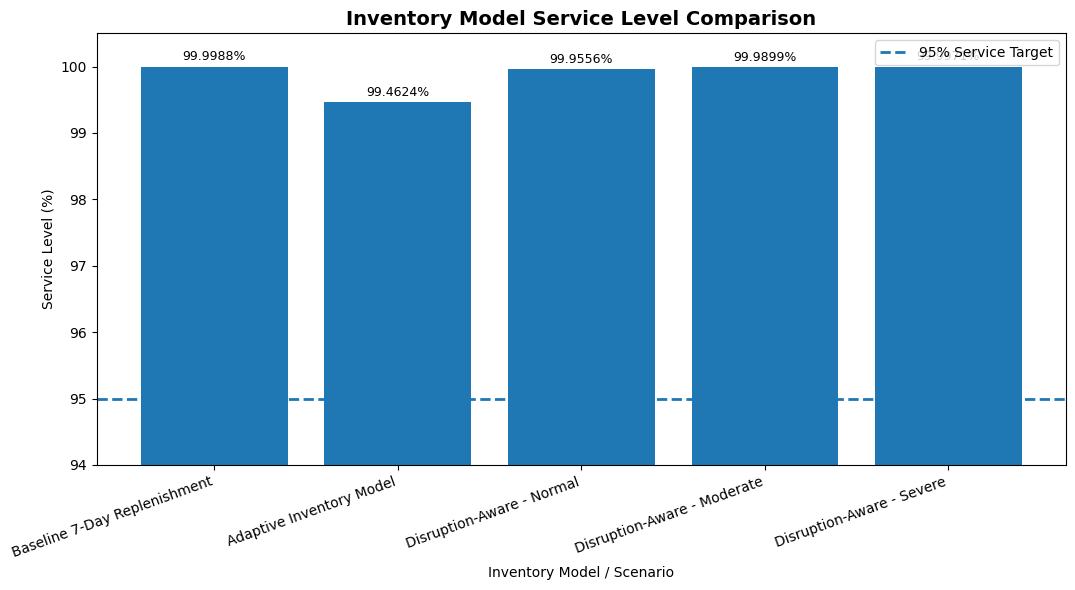

In [52]:
# ============================================================
# CELL 41 — SERVICE LEVEL COMPARISON
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------

models = research_summary["Model / Scenario"]
service_levels = research_summary["Service Level (%)"]

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

plt.bar(models, service_levels)

plt.axhline(
    y=SERVICE_LEVEL_TARGET,
    linestyle="--",
    linewidth=2,
    label=f"{SERVICE_LEVEL_TARGET:.0f}% Service Target"
)

# ------------------------------------------------------------
# Add values above bars
# ------------------------------------------------------------

for i, value in enumerate(service_levels):
    plt.text(
        i,
        value + 0.05,
        f"{value:.4f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

plt.title(
    "Inventory Model Service Level Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Service Level (%)")
plt.xlabel("Inventory Model / Scenario")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.ylim(
    min(service_levels.min() - 1, 94),
    100.5
)

plt.legend()

plt.tight_layout()

plt.show()

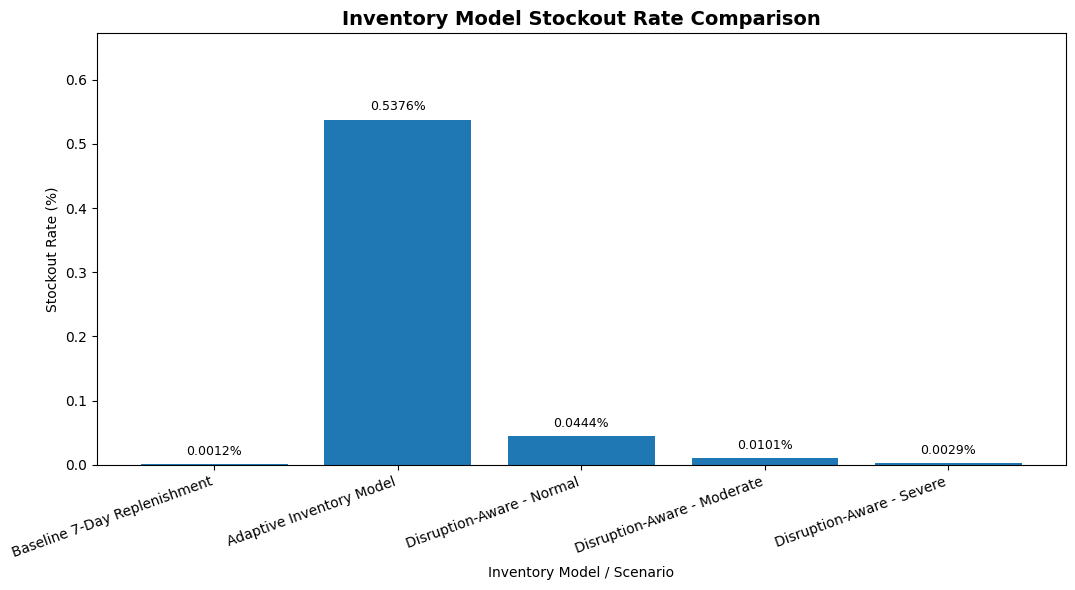

In [53]:
# ============================================================
# CELL 42 — STOCKOUT RATE COMPARISON
# ============================================================

# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------

models = research_summary["Model / Scenario"]
stockout_rates = research_summary["Stockout Rate (%)"]

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

plt.bar(models, stockout_rates)

# ------------------------------------------------------------
# Add values above bars
# ------------------------------------------------------------

for i, value in enumerate(stockout_rates):
    plt.text(
        i,
        value + 0.01,
        f"{value:.4f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

plt.title(
    "Inventory Model Stockout Rate Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Stockout Rate (%)")
plt.xlabel("Inventory Model / Scenario")

plt.xticks(
    rotation=20,
    ha="right"
)

# Give enough vertical space for labels
plt.ylim(
    0,
    max(stockout_rates) * 1.25
)

plt.tight_layout()

plt.show()

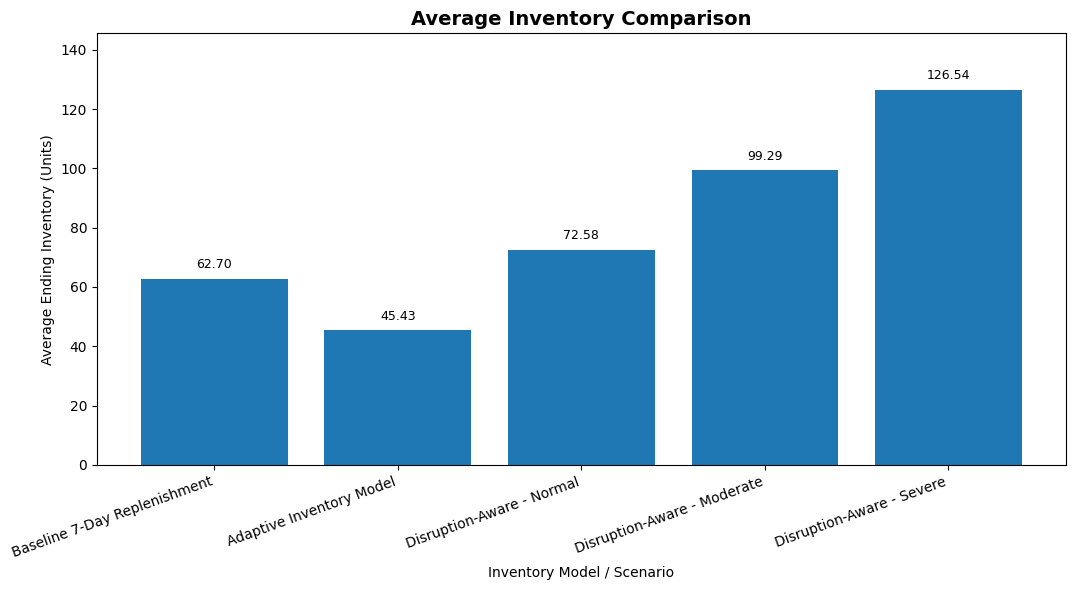

In [54]:
# ============================================================
# CELL 43 — AVERAGE INVENTORY COMPARISON
# ============================================================

# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------

models = research_summary["Model / Scenario"]
average_inventory = research_summary["Average Inventory"]

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

plt.bar(models, average_inventory)

# ------------------------------------------------------------
# Add values above bars
# ------------------------------------------------------------

for i, value in enumerate(average_inventory):
    plt.text(
        i,
        value + (max(average_inventory) * 0.02),
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

plt.title(
    "Average Inventory Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Average Ending Inventory (Units)")
plt.xlabel("Inventory Model / Scenario")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.ylim(
    0,
    max(average_inventory) * 1.15
)

plt.tight_layout()

plt.show()

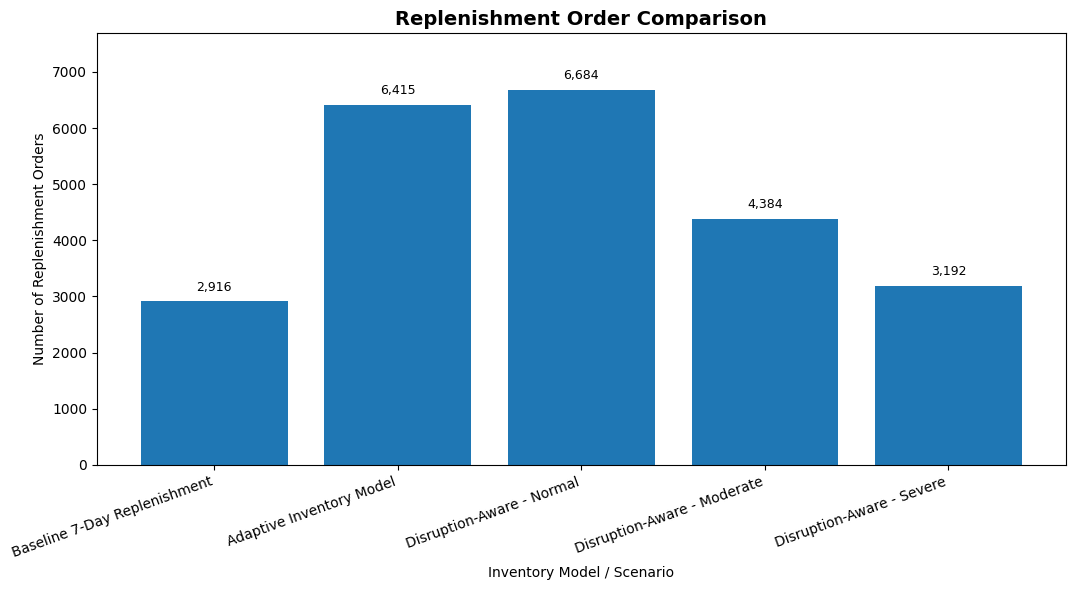

In [55]:
# ============================================================
# CELL 44 — REPLENISHMENT ORDER COMPARISON
# ============================================================

# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------

models = research_summary["Model / Scenario"]
replenishment_orders = research_summary["Replenishment Orders"]

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

plt.bar(models, replenishment_orders)

# ------------------------------------------------------------
# Add values above bars
# ------------------------------------------------------------

for i, value in enumerate(replenishment_orders):
    plt.text(
        i,
        value + (max(replenishment_orders) * 0.02),
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

plt.title(
    "Replenishment Order Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Number of Replenishment Orders")
plt.xlabel("Inventory Model / Scenario")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.ylim(
    0,
    max(replenishment_orders) * 1.15
)

plt.tight_layout()

plt.show()

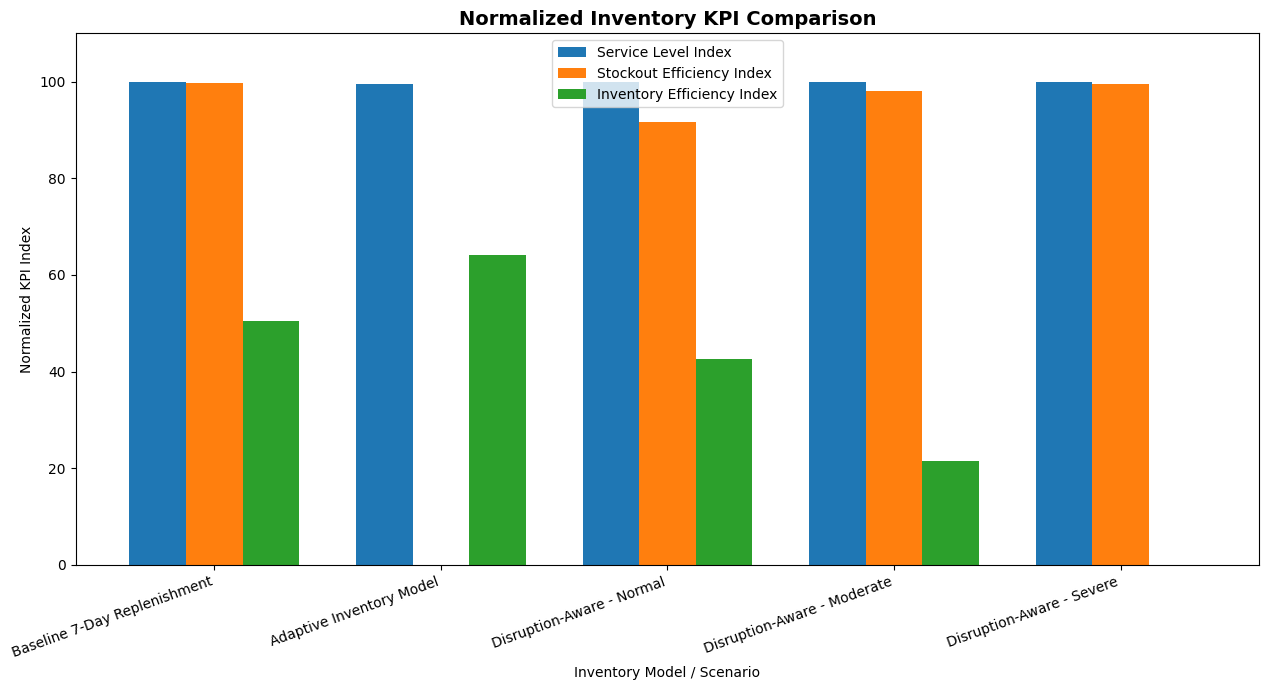

NORMALIZED KPI COMPARISON


,Model / Scenario,Service Level Index,Stockout Efficiency Index,Inventory Efficiency Index
0,Baseline 7-Day Replenishment,100.00,99.78,50.45
1,Adaptive Inventory Model,99.46,0.00,64.10
2,Disruption-Aware - Normal,99.96,91.74,42.64
3,Disruption-Aware - Moderate,99.99,98.12,21.53
4,Disruption-Aware - Severe,100.00,99.46,0.00


In [56]:
# ============================================================
# CELL 45 — CONSOLIDATED KPI COMPARISON
# ============================================================

# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------

models = research_summary["Model / Scenario"]

service_levels = research_summary["Service Level (%)"]
stockout_rates = research_summary["Stockout Rate (%)"]
average_inventory = research_summary["Average Inventory"]


# ------------------------------------------------------------
# Create normalized KPI indices
# ------------------------------------------------------------

# Normalize each KPI to make them comparable visually.
# Higher service level is better.
# Lower stockout rate and inventory are lower-is-more-efficient metrics.

service_index = (
    service_levels / service_levels.max()
) * 100

stockout_efficiency_index = (
    1 - (stockout_rates / stockout_rates.max())
) * 100

inventory_efficiency_index = (
    1 - (average_inventory / average_inventory.max())
) * 100


# ------------------------------------------------------------
# Create comparison table
# ------------------------------------------------------------

kpi_index_df = pd.DataFrame({
    "Model / Scenario": models,
    "Service Level Index": service_index,
    "Stockout Efficiency Index": stockout_efficiency_index,
    "Inventory Efficiency Index": inventory_efficiency_index
})


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

x = range(len(models))

width = 0.25

plt.figure(figsize=(13, 7))

plt.bar(
    [i - width for i in x],
    service_index,
    width=width,
    label="Service Level Index"
)

plt.bar(
    x,
    stockout_efficiency_index,
    width=width,
    label="Stockout Efficiency Index"
)

plt.bar(
    [i + width for i in x],
    inventory_efficiency_index,
    width=width,
    label="Inventory Efficiency Index"
)


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

plt.title(
    "Normalized Inventory KPI Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Normalized KPI Index")
plt.xlabel("Inventory Model / Scenario")

plt.xticks(
    list(x),
    models,
    rotation=20,
    ha="right"
)

plt.ylim(0, 110)

plt.legend()

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# Display normalized KPI table
# ------------------------------------------------------------

print("NORMALIZED KPI COMPARISON")
print("=" * 90)

display(
    kpi_index_df.round(2)
)

In [57]:
# ============================================================
# CELL 46 — EXPORT FINAL RESEARCH TABLES
# ============================================================

import os

# ------------------------------------------------------------
# Define output directories
# ------------------------------------------------------------

RESULTS_DIR = "/content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/07_Results"

METRICS_DIR = os.path.join(RESULTS_DIR, "Metrics")
TABLES_DIR = os.path.join(RESULTS_DIR, "Tables")

os.makedirs(METRICS_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)


# ------------------------------------------------------------
# Export final comparison table
# ------------------------------------------------------------

final_comparison_path = os.path.join(
    TABLES_DIR,
    "Final_Inventory_Model_Comparison.csv"
)

final_comparison_df.to_csv(
    final_comparison_path,
    index=False
)


# ------------------------------------------------------------
# Export KPI change analysis
# ------------------------------------------------------------

kpi_analysis_path = os.path.join(
    METRICS_DIR,
    "Inventory_KPI_Change_Relative_to_Baseline.csv"
)

kpi_analysis.to_csv(
    kpi_analysis_path,
    index=False
)


# ------------------------------------------------------------
# Export research KPI summary
# ------------------------------------------------------------

research_summary_path = os.path.join(
    METRICS_DIR,
    "Final_Research_KPI_Summary.csv"
)

research_summary.to_csv(
    research_summary_path,
    index=False
)


# ------------------------------------------------------------
# Export normalized KPI table
# ------------------------------------------------------------

normalized_kpi_path = os.path.join(
    METRICS_DIR,
    "Normalized_KPI_Comparison.csv"
)

kpi_index_df.to_csv(
    normalized_kpi_path,
    index=False
)


# ------------------------------------------------------------
# Display confirmation
# ------------------------------------------------------------

print("FINAL RESEARCH TABLE EXPORT")
print("=" * 80)

print(f"Final comparison table:")
print(final_comparison_path)

print("\nKPI change analysis:")
print(kpi_analysis_path)

print("\nFinal research KPI summary:")
print(research_summary_path)

print("\nNormalized KPI comparison:")
print(normalized_kpi_path)

print("\nAll research tables exported successfully.")

FINAL RESEARCH TABLE EXPORT
Final comparison table:
/content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/07_Results/Tables/Final_Inventory_Model_Comparison.csv

KPI change analysis:
/content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/07_Results/Metrics/Inventory_KPI_Change_Relative_to_Baseline.csv

Final research KPI summary:
/content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/07_Results/Metrics/Final_Research_KPI_Summary.csv

Normalized KPI comparison:
/content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/07_Results/Metrics/Normalized_KPI_Comparison.csv

All research tables exported successfully.


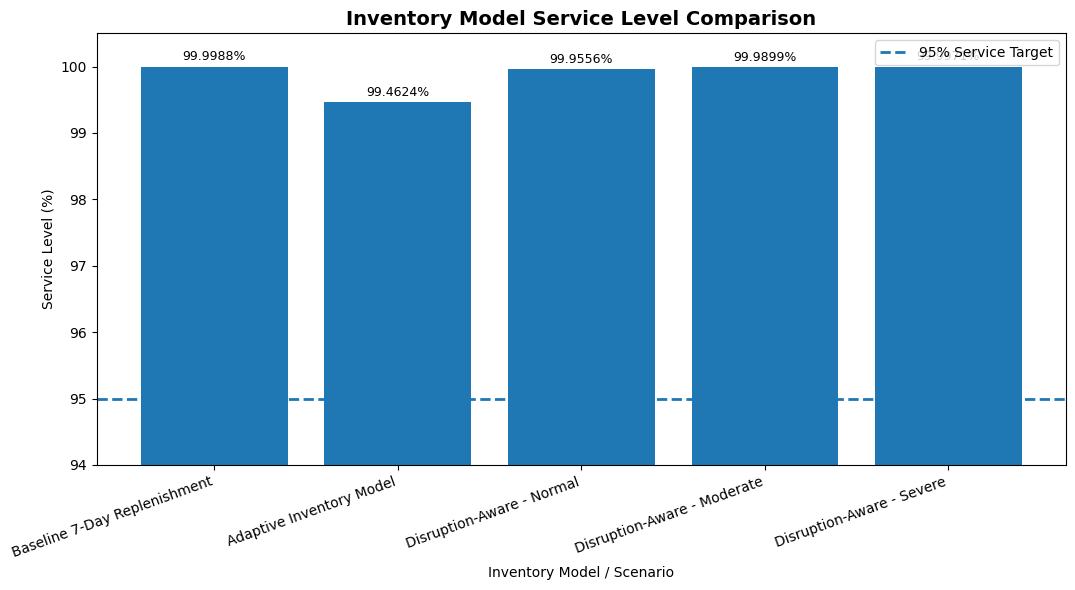

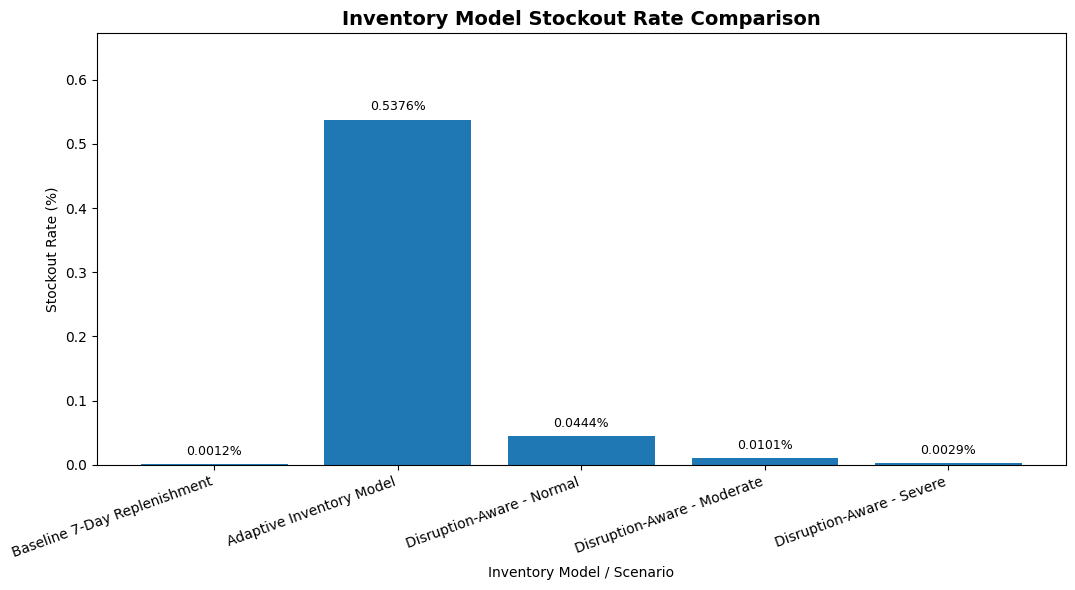

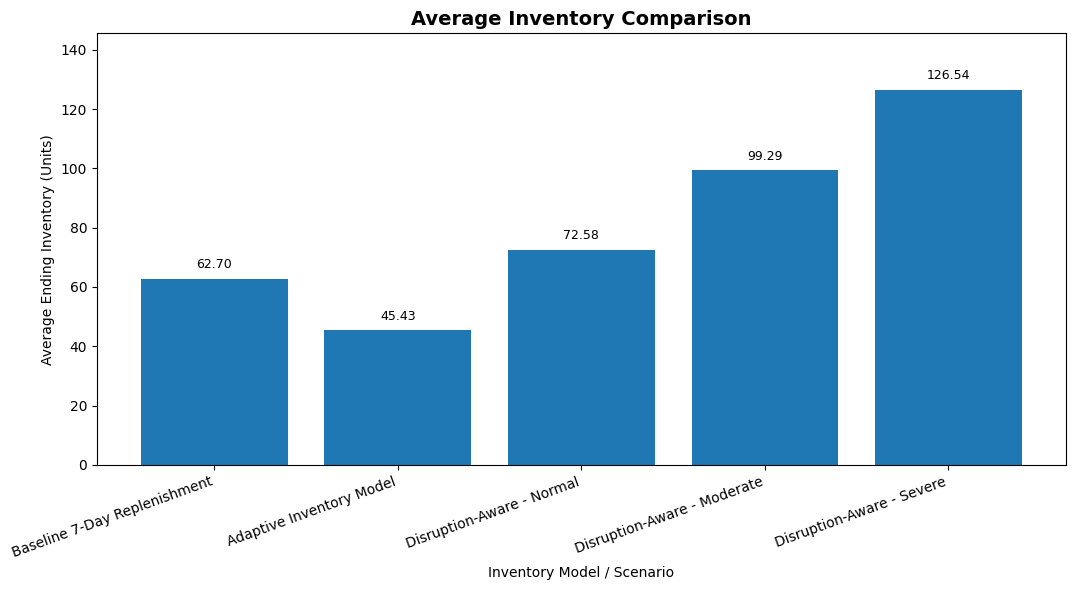

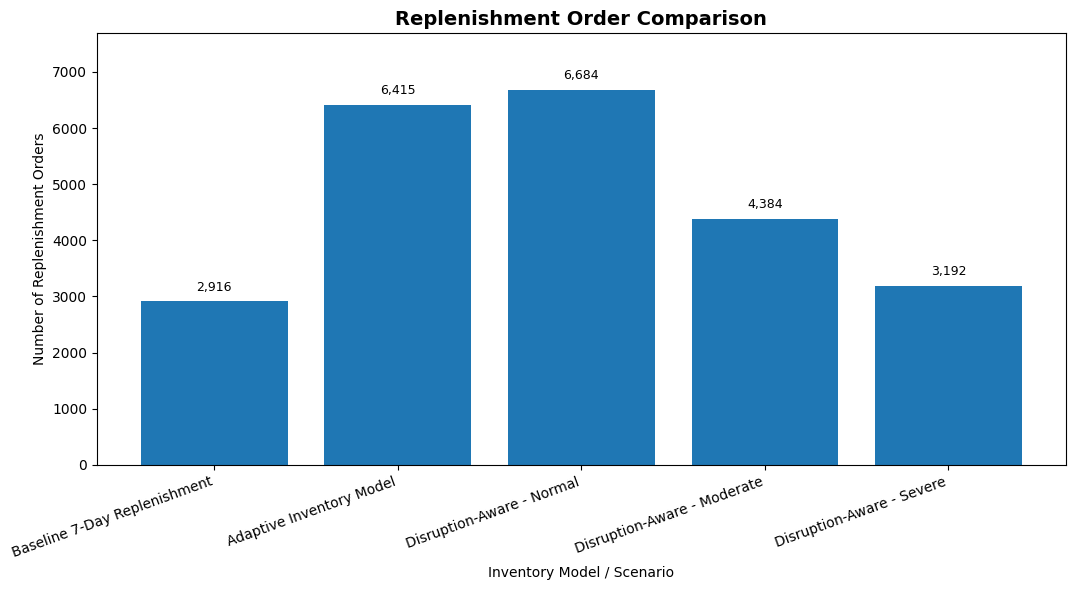


FINAL FIGURE EXPORT
Figure 1: /content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/07_Results/Figures/Figure_1_Service_Level_Comparison.png
Figure 2: /content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/07_Results/Figures/Figure_2_Stockout_Rate_Comparison.png
Figure 3: /content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/07_Results/Figures/Figure_3_Average_Inventory_Comparison.png
Figure 4: /content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/07_Results/Figures/Figure_4_Replenishment_Order_Comparison.png

All four research figures exported successfully at 300 DPI.


In [58]:
# ============================================================
# CELL 47 — EXPORT FINAL RESEARCH FIGURES
# ============================================================

import os
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Define figure output directory
# ------------------------------------------------------------

FIGURES_DIR = "/content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/07_Results/Figures"

os.makedirs(FIGURES_DIR, exist_ok=True)


# ------------------------------------------------------------
# Common data
# ------------------------------------------------------------

models = research_summary["Model / Scenario"]


# ============================================================
# FIGURE 1 — SERVICE LEVEL
# ============================================================

service_levels = research_summary["Service Level (%)"]

plt.figure(figsize=(11, 6))

plt.bar(models, service_levels)

plt.axhline(
    y=SERVICE_LEVEL_TARGET,
    linestyle="--",
    linewidth=2,
    label=f"{SERVICE_LEVEL_TARGET:.0f}% Service Target"
)

for i, value in enumerate(service_levels):
    plt.text(
        i,
        value + 0.05,
        f"{value:.4f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title(
    "Inventory Model Service Level Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Service Level (%)")
plt.xlabel("Inventory Model / Scenario")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.ylim(
    min(service_levels.min() - 1, 94),
    100.5
)

plt.legend()
plt.tight_layout()

service_path = os.path.join(
    FIGURES_DIR,
    "Figure_1_Service_Level_Comparison.png"
)

plt.savefig(
    service_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# FIGURE 2 — STOCKOUT RATE
# ============================================================

stockout_rates = research_summary["Stockout Rate (%)"]

plt.figure(figsize=(11, 6))

plt.bar(models, stockout_rates)

for i, value in enumerate(stockout_rates):
    plt.text(
        i,
        value + 0.01,
        f"{value:.4f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title(
    "Inventory Model Stockout Rate Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Stockout Rate (%)")
plt.xlabel("Inventory Model / Scenario")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.ylim(
    0,
    max(stockout_rates) * 1.25
)

plt.tight_layout()

stockout_path = os.path.join(
    FIGURES_DIR,
    "Figure_2_Stockout_Rate_Comparison.png"
)

plt.savefig(
    stockout_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# FIGURE 3 — AVERAGE INVENTORY
# ============================================================

average_inventory = research_summary["Average Inventory"]

plt.figure(figsize=(11, 6))

plt.bar(models, average_inventory)

for i, value in enumerate(average_inventory):
    plt.text(
        i,
        value + (max(average_inventory) * 0.02),
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title(
    "Average Inventory Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Average Ending Inventory (Units)")
plt.xlabel("Inventory Model / Scenario")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.ylim(
    0,
    max(average_inventory) * 1.15
)

plt.tight_layout()

inventory_path = os.path.join(
    FIGURES_DIR,
    "Figure_3_Average_Inventory_Comparison.png"
)

plt.savefig(
    inventory_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# FIGURE 4 — REPLENISHMENT ORDERS
# ============================================================

replenishment_orders = research_summary["Replenishment Orders"]

plt.figure(figsize=(11, 6))

plt.bar(models, replenishment_orders)

for i, value in enumerate(replenishment_orders):
    plt.text(
        i,
        value + (max(replenishment_orders) * 0.02),
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title(
    "Replenishment Order Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Number of Replenishment Orders")
plt.xlabel("Inventory Model / Scenario")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.ylim(
    0,
    max(replenishment_orders) * 1.15
)

plt.tight_layout()

reorder_path = os.path.join(
    FIGURES_DIR,
    "Figure_4_Replenishment_Order_Comparison.png"
)

plt.savefig(
    reorder_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# CONFIRMATION
# ============================================================

print("\nFINAL FIGURE EXPORT")
print("=" * 80)

print("Figure 1:", service_path)
print("Figure 2:", stockout_path)
print("Figure 3:", inventory_path)
print("Figure 4:", reorder_path)

print("\nAll four research figures exported successfully at 300 DPI.")

In [59]:
# ============================================================
# CELL 48 — MASTER RESEARCH RESULTS EXCEL EXPORT
# ============================================================

import os
import pandas as pd

# ------------------------------------------------------------
# Define output path
# ------------------------------------------------------------

EXPORT_DIR = "/content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/08_Exports"

os.makedirs(EXPORT_DIR, exist_ok=True)

excel_path = os.path.join(
    EXPORT_DIR,
    "OptiChain_Inventory_Optimization_Final_Results.xlsx"
)


# ------------------------------------------------------------
# Create Excel workbook
# ------------------------------------------------------------

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:

    final_comparison_df.to_excel(
        writer,
        sheet_name="Final_Comparison",
        index=False
    )

    kpi_analysis.to_excel(
        writer,
        sheet_name="KPI_Analysis",
        index=False
    )

    research_summary.to_excel(
        writer,
        sheet_name="Research_Summary",
        index=False
    )

    kpi_index_df.to_excel(
        writer,
        sheet_name="Normalized_KPIs",
        index=False
    )


# ------------------------------------------------------------
# Confirmation
# ------------------------------------------------------------

print("MASTER RESEARCH RESULTS EXPORT")
print("=" * 80)

print(f"Excel file created successfully:")
print(excel_path)

print("\nSheets included:")
print("1. Final_Comparison")
print("2. KPI_Analysis")
print("3. Research_Summary")
print("4. Normalized_KPIs")

MASTER RESEARCH RESULTS EXPORT
Excel file created successfully:
/content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/08_Exports/OptiChain_Inventory_Optimization_Final_Results.xlsx

Sheets included:
1. Final_Comparison
2. KPI_Analysis
3. Research_Summary
4. Normalized_KPIs


In [60]:
# ============================================================
# ML PHASE - STEP 1
# Inspect available datasets and columns
# ============================================================

print("========== simulation_df ==========")
print("Shape:", simulation_df.shape)
print("\nColumns:")
print(simulation_df.columns.tolist())

print("\n\n========== inventory_model_df ==========")
print("Shape:", inventory_model_df.shape)
print("\nColumns:")
print(inventory_model_df.columns.tolist())

========== simulation_df ==========
Shape: (54216, 16)

Columns:
['Product Card Id', 'Order_Date', 'Daily_Demand', 'Rolling_Mean_Demand', 'Rolling_Std_Demand', 'Rolling_Observation_Count', 'Average_Lead_Time', 'Lead_Time_Std_Dev', 'Adaptive_Daily_Demand', 'Adaptive_Demand_Std_Dev', 'Adaptive_Lead_Time_Demand', 'Adaptive_Safety_Stock', 'Adaptive_Reorder_Point', 'Adaptive_Reorder_Quantity', 'Initial_Inventory', 'Baseline_Reorder_Quantity']


========== inventory_model_df ==========
Shape: (171962, 30)

Columns:
['order date (DateOrders)', 'shipping date (DateOrders)', 'Order Id', 'Order Item Id', 'Product Card Id', 'Product Name', 'Category Id', 'Category Name', 'Department Id', 'Department Name', 'Order Item Quantity', 'Sales', 'Order Item Product Price', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Total', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Shipping Mode', 'Market', 'Order Region', 'Order Country', 'Order State', 'Customer Segment', 'Order S

In [61]:
# ============================================================
# ML PHASE - STEP 2
# Inspect simulation data and confirm temporal structure
# ============================================================

ml_check = simulation_df.copy()

# Sort chronologically
ml_check = ml_check.sort_values(
    ["Product Card Id", "Order_Date"]
).reset_index(drop=True)

print("Shape:", ml_check.shape)

print("\nDate range:")
print("Start:", ml_check["Order_Date"].min())
print("End  :", ml_check["Order_Date"].max())

print("\nNumber of products:")
print(ml_check["Product Card Id"].nunique())

print("\nRows per product:")
print(
    ml_check.groupby("Product Card Id")
    .size()
    .describe()
)

print("\nMissing values:")
print(
    ml_check[
        [
            "Daily_Demand",
            "Rolling_Mean_Demand",
            "Rolling_Std_Demand",
            "Average_Lead_Time",
            "Lead_Time_Std_Dev",
            "Adaptive_Reorder_Point",
            "Adaptive_Reorder_Quantity",
            "Initial_Inventory"
        ]
    ].isna().sum()
)

print("\nDemand statistics:")
print(
    ml_check["Daily_Demand"].describe()
)

Shape: (54216, 16)

Date range:
Start: 2015-01-01 00:00:00
End  : 2017-09-30 00:00:00

Number of products:
54

Rows per product:
count      54.0
mean     1004.0
std         0.0
min      1004.0
25%      1004.0
50%      1004.0
75%      1004.0
max      1004.0
dtype: float64

Missing values:
Daily_Demand                   0
Rolling_Mean_Demand          378
Rolling_Std_Demand           378
Average_Lead_Time              0
Lead_Time_Std_Dev              0
Adaptive_Reorder_Point         0
Adaptive_Reorder_Quantity      0
Initial_Inventory              0
dtype: int64

Demand statistics:
count    54216.000000
mean         6.842002
std         16.599383
min          0.000000
25%          0.000000
50%          0.000000
75%          4.000000
max        133.000000
Name: Daily_Demand, dtype: float64


In [62]:
# ============================================================
# ML PHASE - STEP 3
# Create leakage-free future demand over lead-time horizon
# ============================================================

ml_target_df = simulation_df.copy()

# Ensure correct chronological order
ml_target_df = ml_target_df.sort_values(
    ["Product Card Id", "Order_Date"]
).reset_index(drop=True)

# Lead time used for the prediction horizon
ml_target_df["ML_Lead_Time_Days"] = (
    ml_target_df["Average_Lead_Time"]
    .round()
    .clip(lower=1)
    .astype(int)
)

# ------------------------------------------------------------
# Calculate future demand for each product.
# IMPORTANT:
# The current day's demand is NOT included.
# Only future days are used.
# ------------------------------------------------------------

ml_target_df["Future_Demand_Lead_Time"] = 0.0

for product_id, group in ml_target_df.groupby("Product Card Id", sort=False):

    indices = group.index.to_numpy()
    demand = group["Daily_Demand"].to_numpy()
    lead_times = group["ML_Lead_Time_Days"].to_numpy()

    future_demand = []

    for i, lead_time in enumerate(lead_times):

        start = i + 1
        end = min(i + 1 + lead_time, len(demand))

        future_demand.append(
            demand[start:end].sum()
        )

    ml_target_df.loc[
        indices,
        "Future_Demand_Lead_Time"
    ] = future_demand

# ------------------------------------------------------------
# Create target:
# 1 = future lead-time demand exceeds current adaptive
#     reorder-point protection level
# 0 = otherwise
# ------------------------------------------------------------

ml_target_df["Stockout_Risk"] = (
    ml_target_df["Future_Demand_Lead_Time"]
    > ml_target_df["Adaptive_Reorder_Point"]
).astype(int)

# ------------------------------------------------------------
# Remove final observations where the complete future
# lead-time horizon is unavailable.
# ------------------------------------------------------------

valid_rows = []

for product_id, group in ml_target_df.groupby("Product Card Id", sort=False):

    group = group.sort_values("Order_Date")

    max_lead_time = int(
        group["ML_Lead_Time_Days"].max()
    )

    valid_rows.extend(
        group.index[:-max_lead_time]
    )

ml_target_df = (
    ml_target_df.loc[valid_rows]
    .sort_values(["Product Card Id", "Order_Date"])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Target validation
# ------------------------------------------------------------

print("ML target dataset shape:", ml_target_df.shape)

print("\nTarget distribution:")
print(
    ml_target_df["Stockout_Risk"]
    .value_counts()
    .sort_index()
)

print("\nTarget percentages:")
print(
    ml_target_df["Stockout_Risk"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\nFuture demand statistics:")
print(
    ml_target_df["Future_Demand_Lead_Time"].describe()
)

print("\nTarget missing values:")
print(
    ml_target_df[
        [
            "Future_Demand_Lead_Time",
            "Stockout_Risk"
        ]
    ].isna().sum()
)

ML target dataset shape: (54028, 19)

Target distribution:
Stockout_Risk
0    50685
1     3343
Name: count, dtype: int64

Target percentages:
Stockout_Risk
0    93.81
1     6.19
Name: proportion, dtype: float64

Future demand statistics:
count    54028.000000
mean        22.996187
std         55.175214
min          0.000000
25%          0.000000
50%          3.000000
75%          8.000000
max        389.000000
Name: Future_Demand_Lead_Time, dtype: float64

Target missing values:
Future_Demand_Lead_Time    0
Stockout_Risk              0
dtype: int64


In [63]:
# ============================================================
# ML PHASE - STEP 4
# Create leakage-free inventory risk features
# ============================================================

ml_features_df = ml_target_df.copy()

# ------------------------------------------------------------
# Feature engineering
# All features use information available on or before
# the prediction date.
# ------------------------------------------------------------

# Inventory protection gap
ml_features_df["Inventory_Protection_Gap"] = (
    ml_features_df["Initial_Inventory"]
    - ml_features_df["Adaptive_Reorder_Point"]
)

# Inventory coverage relative to adaptive daily demand
ml_features_df["Inventory_Coverage_Days"] = (
    ml_features_df["Initial_Inventory"]
    / ml_features_df["Adaptive_Daily_Demand"].replace(0, np.nan)
)

# Demand variability relative to average demand
ml_features_df["Demand_CV"] = (
    ml_features_df["Adaptive_Demand_Std_Dev"]
    / ml_features_df["Adaptive_Daily_Demand"].replace(0, np.nan)
)

# Lead-time variability relative to average lead time
ml_features_df["Lead_Time_CV"] = (
    ml_features_df["Lead_Time_Std_Dev"]
    / ml_features_df["Average_Lead_Time"].replace(0, np.nan)
)

# Difference between rolling demand and adaptive demand
ml_features_df["Recent_Demand_Deviation"] = (
    ml_features_df["Rolling_Mean_Demand"]
    - ml_features_df["Adaptive_Daily_Demand"]
)

# Recent demand variability relative to adaptive variability
ml_features_df["Recent_Variability_Ratio"] = (
    ml_features_df["Rolling_Std_Demand"]
    / ml_features_df["Adaptive_Demand_Std_Dev"].replace(0, np.nan)
)

# ------------------------------------------------------------
# Replace infinite values created by zero-demand products
# ------------------------------------------------------------

ml_features_df = ml_features_df.replace(
    [np.inf, -np.inf],
    np.nan
)

# Fill unavailable rolling statistics using adaptive
# historical statistics.
ml_features_df["Rolling_Mean_Demand"] = (
    ml_features_df["Rolling_Mean_Demand"]
    .fillna(ml_features_df["Adaptive_Daily_Demand"])
)

ml_features_df["Rolling_Std_Demand"] = (
    ml_features_df["Rolling_Std_Demand"]
    .fillna(ml_features_df["Adaptive_Demand_Std_Dev"])
)

ml_features_df["Rolling_Observation_Count"] = (
    ml_features_df["Rolling_Observation_Count"]
    .fillna(0)
)

# Derived feature fallbacks
ml_features_df["Inventory_Coverage_Days"] = (
    ml_features_df["Inventory_Coverage_Days"]
    .fillna(0)
)

ml_features_df["Demand_CV"] = (
    ml_features_df["Demand_CV"]
    .fillna(0)
)

ml_features_df["Lead_Time_CV"] = (
    ml_features_df["Lead_Time_CV"]
    .fillna(0)
)

ml_features_df["Recent_Variability_Ratio"] = (
    ml_features_df["Recent_Variability_Ratio"]
    .fillna(0)
)

# ------------------------------------------------------------
# Final feature list
# ------------------------------------------------------------

ML_FEATURES = [
    "Daily_Demand",
    "Rolling_Mean_Demand",
    "Rolling_Std_Demand",
    "Rolling_Observation_Count",
    "Average_Lead_Time",
    "Lead_Time_Std_Dev",
    "Adaptive_Daily_Demand",
    "Adaptive_Demand_Std_Dev",
    "Adaptive_Lead_Time_Demand",
    "Adaptive_Safety_Stock",
    "Adaptive_Reorder_Point",
    "Adaptive_Reorder_Quantity",
    "Initial_Inventory",
    "Baseline_Reorder_Quantity",
    "Inventory_Protection_Gap",
    "Inventory_Coverage_Days",
    "Demand_CV",
    "Lead_Time_CV",
    "Recent_Demand_Deviation",
    "Recent_Variability_Ratio"
]

TARGET = "Stockout_Risk"

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

X = ml_features_df[ML_FEATURES].copy()
y = ml_features_df[TARGET].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nNumber of features:", len(ML_FEATURES))

print("\nMissing feature values:")
print(X.isna().sum().sum())

print("\nInfinite feature values:")
print(np.isinf(X.select_dtypes(include=np.number)).sum().sum())

print("\nTarget distribution:")
print(y.value_counts().sort_index())

print("\nTarget percentage:")
print(
    y.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\nFeature list:")
for i, feature in enumerate(ML_FEATURES, start=1):
    print(f"{i:02d}. {feature}")

Feature matrix shape: (54028, 20)
Target shape: (54028,)

Number of features: 20

Missing feature values:
378

Infinite feature values:
0

Target distribution:
Stockout_Risk
0    50685
1     3343
Name: count, dtype: int64

Target percentage:
Stockout_Risk
0    93.81
1     6.19
Name: proportion, dtype: float64

Feature list:
01. Daily_Demand
02. Rolling_Mean_Demand
03. Rolling_Std_Demand
04. Rolling_Observation_Count
05. Average_Lead_Time
06. Lead_Time_Std_Dev
07. Adaptive_Daily_Demand
08. Adaptive_Demand_Std_Dev
09. Adaptive_Lead_Time_Demand
10. Adaptive_Safety_Stock
11. Adaptive_Reorder_Point
12. Adaptive_Reorder_Quantity
13. Initial_Inventory
14. Baseline_Reorder_Quantity
15. Inventory_Protection_Gap
16. Inventory_Coverage_Days
17. Demand_CV
18. Lead_Time_CV
19. Recent_Demand_Deviation
20. Recent_Variability_Ratio


In [64]:
# ============================================================
# ML PHASE - STEP 5
# Clean initial rolling-window rows and create
# chronological train/test split
# ============================================================

# Work on a clean copy
ml_model_df = ml_features_df.copy()

# ------------------------------------------------------------
# Remove rows where rolling statistics are unavailable.
# These occur only at the beginning of each product's
# historical series.
# ------------------------------------------------------------

required_columns = [
    "Rolling_Mean_Demand",
    "Rolling_Std_Demand"
]

before_rows = len(ml_model_df)

ml_model_df = ml_model_df.dropna(
    subset=required_columns
).reset_index(drop=True)

after_rows = len(ml_model_df)

print("Rows before removing initial rolling-window rows:", before_rows)
print("Rows removed:", before_rows - after_rows)
print("Rows remaining:", after_rows)

# ------------------------------------------------------------
# Ensure chronological ordering
# ------------------------------------------------------------

ml_model_df = ml_model_df.sort_values(
    "Order_Date"
).reset_index(drop=True)

# ------------------------------------------------------------
# Determine chronological 80/20 split point
# ------------------------------------------------------------

split_index = int(len(ml_model_df) * 0.80)

split_date = ml_model_df.loc[
    split_index,
    "Order_Date"
]

train_df = ml_model_df.iloc[:split_index].copy()
test_df = ml_model_df.iloc[split_index:].copy()

# ------------------------------------------------------------
# Create X and y
# ------------------------------------------------------------

X_train = train_df[ML_FEATURES].copy()
y_train = train_df[TARGET].copy()

X_test = test_df[ML_FEATURES].copy()
y_test = test_df[TARGET].copy()

# ------------------------------------------------------------
# Final validation
# ------------------------------------------------------------

print("\n========== CHRONOLOGICAL SPLIT ==========")

print("\nTraining:")
print("Rows:", len(train_df))
print("Start:", train_df["Order_Date"].min())
print("End  :", train_df["Order_Date"].max())

print("\nTesting:")
print("Rows:", len(test_df))
print("Start:", test_df["Order_Date"].min())
print("End  :", test_df["Order_Date"].max())

print("\nSplit date:", split_date)

print("\nFeature shapes:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nTarget distribution - Training:")
print(y_train.value_counts().sort_index())

print("\nTarget distribution - Testing:")
print(y_test.value_counts().sort_index())

print("\nTarget percentage - Training:")
print(
    y_train.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\nTarget percentage - Testing:")
print(
    y_test.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\nMissing values:")
print("X_train:", X_train.isna().sum().sum())
print("X_test :", X_test.isna().sum().sum())
print("y_train:", y_train.isna().sum())
print("y_test :", y_test.isna().sum())

Rows before removing initial rolling-window rows: 54028
Rows removed: 0
Rows remaining: 54028

========== CHRONOLOGICAL SPLIT ==========

Training:
Rows: 43222
Start: 2015-01-01 00:00:00
End  : 2017-03-11 00:00:00

Testing:
Rows: 10806
Start: 2017-03-11 00:00:00
End  : 2017-09-27 00:00:00

Split date: 2017-03-11 00:00:00

Feature shapes:
X_train: (43222, 20)
X_test : (10806, 20)

Target distribution - Training:
Stockout_Risk
0    40024
1     3198
Name: count, dtype: int64

Target distribution - Testing:
Stockout_Risk
0    10661
1      145
Name: count, dtype: int64

Target percentage - Training:
Stockout_Risk
0    92.6
1     7.4
Name: proportion, dtype: float64

Target percentage - Testing:
Stockout_Risk
0    98.66
1     1.34
Name: proportion, dtype: float64

Missing values:
X_train: 378
X_test : 0
y_train: 0
y_test : 0


In [65]:
# ============================================================
# ML PHASE - STEP 5A
# Diagnose missing features and temporal target distribution
# ============================================================

print("========== MISSING VALUES BY FEATURE ==========")

missing_features = (
    X_train.isna()
    .sum()
    .sort_values(ascending=False)
)

print(
    missing_features[missing_features > 0]
)

print("\nTotal missing training values:",
      X_train.isna().sum().sum())

print("\nTotal missing testing values:",
      X_test.isna().sum().sum())


# ============================================================
# TARGET DISTRIBUTION BY TIME PERIOD
# ============================================================

print("\n\n========== TARGET DISTRIBUTION BY YEAR ==========")

yearly_target = (
    ml_model_df
    .assign(Year=ml_model_df["Order_Date"].dt.year)
    .groupby("Year")["Stockout_Risk"]
    .agg(
        Total_Observations="count",
        Risk_Events="sum",
        Risk_Rate="mean"
    )
)

yearly_target["Risk_Rate"] = (
    yearly_target["Risk_Rate"] * 100
).round(2)

print(yearly_target)


# ============================================================
# TARGET DISTRIBUTION BY QUARTER
# ============================================================

print("\n\n========== TARGET DISTRIBUTION BY QUARTER ==========")

quarterly_target = (
    ml_model_df
    .assign(
        YearQuarter=(
            ml_model_df["Order_Date"]
            .dt.to_period("Q")
            .astype(str)
        )
    )
    .groupby("YearQuarter")["Stockout_Risk"]
    .agg(
        Total_Observations="count",
        Risk_Events="sum",
        Risk_Rate="mean"
    )
)

quarterly_target["Risk_Rate"] = (
    quarterly_target["Risk_Rate"] * 100
).round(2)

print(quarterly_target)


# ============================================================
# TRAIN / TEST DATE TARGET CHECK
# ============================================================

print("\n\n========== TRAIN / TEST TARGET SUMMARY ==========")

print("Training period:")
print(train_df["Order_Date"].min(), "to", train_df["Order_Date"].max())

print("Training stockout-risk rate:",
      round(y_train.mean() * 100, 2), "%")

print("\nTesting period:")
print(test_df["Order_Date"].min(), "to", test_df["Order_Date"].max())

print("Testing stockout-risk rate:",
      round(y_test.mean() * 100, 2), "%")

========== MISSING VALUES BY FEATURE ==========
Recent_Demand_Deviation    378
dtype: int64

Total missing training values: 378

Total missing testing values: 0


========== TARGET DISTRIBUTION BY YEAR ==========
      Total_Observations  Risk_Events  Risk_Rate
Year                                            
2015               19710         1446       7.34
2016               19764         1488       7.53
2017               14554          409       2.81


========== TARGET DISTRIBUTION BY QUARTER ==========
             Total_Observations  Risk_Events  Risk_Rate
YearQuarter                                            
2015Q1                     4860          372       7.65
2015Q2                     4914          343       6.98
2015Q3                     4968          350       7.05
2015Q4                     4968          381       7.67
2016Q1                     4914          335       6.82
2016Q2                     4914          366       7.45
2016Q3                     4968        

In [66]:
# ============================================================
# ML PHASE - STEP 5B
# Investigate the sudden change in Stockout_Risk
# ============================================================

diagnosis_df = ml_target_df.copy()

diagnosis_df["YearMonth"] = (
    diagnosis_df["Order_Date"]
    .dt.to_period("M")
    .astype(str)
)

# ------------------------------------------------------------
# Monthly target rate
# ------------------------------------------------------------

monthly_target = (
    diagnosis_df
    .groupby("YearMonth")
    .agg(
        Observations=("Stockout_Risk", "count"),
        Risk_Events=("Stockout_Risk", "sum"),
        Risk_Rate=("Stockout_Risk", "mean"),
        Mean_Future_Demand=("Future_Demand_Lead_Time", "mean"),
        Mean_ROP=("Adaptive_Reorder_Point", "mean"),
        Mean_Initial_Inventory=("Initial_Inventory", "mean")
    )
)

monthly_target["Risk_Rate"] = (
    monthly_target["Risk_Rate"] * 100
).round(2)

print("========== MONTHLY TARGET DIAGNOSIS ==========")
print(monthly_target.to_string())


# ------------------------------------------------------------
# Compare important variables between 2015-2016 and 2017
# ------------------------------------------------------------

diagnosis_df["Period"] = np.where(
    diagnosis_df["Order_Date"] < pd.Timestamp("2017-01-01"),
    "2015-2016",
    "2017"
)

period_summary = (
    diagnosis_df
    .groupby("Period")
    .agg(
        Observations=("Stockout_Risk", "count"),
        Risk_Rate=("Stockout_Risk", "mean"),
        Mean_Daily_Demand=("Daily_Demand", "mean"),
        Mean_Future_Demand=("Future_Demand_Lead_Time", "mean"),
        Mean_Adaptive_Daily_Demand=("Adaptive_Daily_Demand", "mean"),
        Mean_Adaptive_Std=("Adaptive_Demand_Std_Dev", "mean"),
        Mean_ROP=("Adaptive_Reorder_Point", "mean"),
        Mean_ROQ=("Adaptive_Reorder_Quantity", "mean"),
        Mean_Initial_Inventory=("Initial_Inventory", "mean")
    )
)

period_summary["Risk_Rate"] = (
    period_summary["Risk_Rate"] * 100
).round(2)

print("\n\n========== PERIOD COMPARISON ==========")
print(period_summary.round(4).to_string())


# ------------------------------------------------------------
# Inspect 2017 Q2/Q3 target cases
# ------------------------------------------------------------

late_period = diagnosis_df[
    diagnosis_df["Order_Date"] >= pd.Timestamp("2017-04-01")
].copy()

print("\n\n========== 2017 Q2/Q3 ==========")

print("Rows:", len(late_period))
print("Risk events:", late_period["Stockout_Risk"].sum())

print("\nFuture demand:")
print(late_period["Future_Demand_Lead_Time"].describe())

print("\nAdaptive ROP:")
print(late_period["Adaptive_Reorder_Point"].describe())

print("\nInitial inventory:")
print(late_period["Initial_Inventory"].describe())

print("\nDaily demand:")
print(late_period["Daily_Demand"].describe())

# ------------------------------------------------------------
# Check whether the target rule is actually being satisfied
# ------------------------------------------------------------

late_period["Demand_ROP_Gap"] = (
    late_period["Future_Demand_Lead_Time"]
    - late_period["Adaptive_Reorder_Point"]
)

print("\nFuture Demand - Adaptive ROP:")
print(late_period["Demand_ROP_Gap"].describe())

print("\nMaximum Future Demand - Adaptive ROP:",
      late_period["Demand_ROP_Gap"].max())

========== MONTHLY TARGET DIAGNOSIS ==========
           Observations  Risk_Events  Risk_Rate  Mean_Future_Demand   Mean_ROP  Mean_Initial_Inventory
YearMonth                                                                                             
2015-01            1674          123       7.35           23.813023  49.489674               58.346339
2015-02            1512          119       7.87           23.613757  47.041813               58.346339
2015-03            1674          130       7.77           23.942055  47.653172               58.346339
2015-04            1620          111       6.85           23.437654  47.672609               58.346339
2015-05            1674          146       8.72           23.948029  46.943737               58.346339
2015-06            1620           86       5.31           23.219136  47.251183               58.346339
2015-07            1674          124       7.41           23.547790  47.182834               58.346339
2015-08            1674   

In [67]:
# ============================================================
# ML PHASE - STEP 5C
# Evaluate a more direct inventory-shortfall target
# ============================================================

target_test_df = ml_target_df.copy()

# ------------------------------------------------------------
# New target definition:
#
# Stockout_Risk = 1 when future demand during the lead-time
# horizon exceeds the inventory available at prediction time.
#
# This does NOT use Adaptive_Reorder_Point.
# ------------------------------------------------------------

target_test_df["Stockout_Risk_New"] = (
    target_test_df["Future_Demand_Lead_Time"]
    > target_test_df["Initial_Inventory"]
).astype(int)

# ------------------------------------------------------------
# Overall distribution
# ------------------------------------------------------------

print("========== NEW TARGET DISTRIBUTION ==========")

print(
    target_test_df["Stockout_Risk_New"]
    .value_counts()
    .sort_index()
)

print("\nPercentage:")

print(
    target_test_df["Stockout_Risk_New"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

# ------------------------------------------------------------
# Yearly distribution
# ------------------------------------------------------------

target_test_df["Year"] = (
    target_test_df["Order_Date"].dt.year
)

yearly_new_target = (
    target_test_df
    .groupby("Year")["Stockout_Risk_New"]
    .agg(
        Observations="count",
        Risk_Events="sum",
        Risk_Rate="mean"
    )
)

yearly_new_target["Risk_Rate"] = (
    yearly_new_target["Risk_Rate"] * 100
).round(2)

print("\n\n========== YEARLY NEW TARGET ==========")
print(yearly_new_target)

# ------------------------------------------------------------
# Quarterly distribution
# ------------------------------------------------------------

target_test_df["YearQuarter"] = (
    target_test_df["Order_Date"]
    .dt.to_period("Q")
    .astype(str)
)

quarterly_new_target = (
    target_test_df
    .groupby("YearQuarter")["Stockout_Risk_New"]
    .agg(
        Observations="count",
        Risk_Events="sum",
        Risk_Rate="mean"
    )
)

quarterly_new_target["Risk_Rate"] = (
    quarterly_new_target["Risk_Rate"] * 100
).round(2)

print("\n\n========== QUARTERLY NEW TARGET ==========")
print(quarterly_new_target)

# ------------------------------------------------------------
# Compare old vs new target
# ------------------------------------------------------------

print("\n\n========== OLD vs NEW TARGET ==========")

comparison = pd.DataFrame({
    "Old_Target_Rate_%": [
        ml_target_df["Stockout_Risk"].mean() * 100
    ],
    "New_Target_Rate_%": [
        target_test_df["Stockout_Risk_New"].mean() * 100
    ]
})

print(comparison.round(2))

========== NEW TARGET DISTRIBUTION ==========
Stockout_Risk_New
0    54021
1        7
Name: count, dtype: int64

Percentage:
Stockout_Risk_New
0    99.99
1     0.01
Name: proportion, dtype: float64


========== YEARLY NEW TARGET ==========
      Observations  Risk_Events  Risk_Rate
Year                                      
2015         19710            6       0.03
2016         19764            0       0.00
2017         14554            1       0.01


========== QUARTERLY NEW TARGET ==========
             Observations  Risk_Events  Risk_Rate
YearQuarter                                      
2015Q1               4860            2       0.04
2015Q2               4914            0       0.00
2015Q3               4968            2       0.04
2015Q4               4968            2       0.04
2016Q1               4914            0       0.00
2016Q2               4914            0       0.00
2016Q3               4968            0       0.00
2016Q4               4968            0       0.00


## 15. Machine Learning-Based Backorder Risk Prediction

### 15.1 Backorder Dataset Loading and Initial Inspection

In [68]:
import os

print("Training file exists:", os.path.exists("/content/Training_BOP.csv"))
print("Testing file exists:", os.path.exists("/content/Testing_BOP.csv"))

print("\nFiles in /content:")
for file in sorted(os.listdir("/content")):
    if "BOP" in file.upper():
        print(file)

Training file exists: True
Testing file exists: True

Files in /content:
Testing_BOP.csv
Training_BOP.csv


In [69]:
# ============================================================
# STEP 15.1 — LOAD BACKORDER DATASETS
# ============================================================

import pandas as pd
import numpy as np

TRAIN_BOP_PATH = "/content/Training_BOP.csv"
TEST_BOP_PATH = "/content/Testing_BOP.csv"

# Load datasets
bop_train = pd.read_csv(TRAIN_BOP_PATH, low_memory=False)
bop_test = pd.read_csv(TEST_BOP_PATH, low_memory=False)

print("========== TRAINING DATA ==========")
print("Shape:", bop_train.shape)

print("\n========== TESTING DATA ==========")
print("Shape:", bop_test.shape)

print("\n========== COLUMN NAMES ==========")
print(bop_train.columns.tolist())

print("\n========== FIRST 5 TRAINING RECORDS ==========")
display(bop_train.head())

print("\n========== TARGET DISTRIBUTION ==========")
print(bop_train["went_on_backorder"].value_counts(dropna=False))

print("\n========== TARGET PERCENTAGE ==========")
print(
    (bop_train["went_on_backorder"]
     .value_counts(normalize=True, dropna=False) * 100)
    .round(4)
)

========== TRAINING DATA ==========
Shape: (1687861, 23)

========== TESTING DATA ==========
Shape: (242076, 23)

========== COLUMN NAMES ==========
['sku', 'national_inv', 'lead_time', 'in_transit_qty', 'forecast_3_month', 'forecast_6_month', 'forecast_9_month', 'sales_1_month', 'sales_3_month', 'sales_6_month', 'sales_9_month', 'min_bank', 'potential_issue', 'pieces_past_due', 'perf_6_month_avg', 'perf_12_month_avg', 'local_bo_qty', 'deck_risk', 'oe_constraint', 'ppap_risk', 'stop_auto_buy', 'rev_stop', 'went_on_backorder']

========== FIRST 5 TRAINING RECORDS ==========


,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,sales_9_month,min_bank,potential_issue,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
0,1026827,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No,0.0,-99.00,-99.00,0.0,No,No,No,Yes,No,No
1,1043384,2.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No,0.0,0.99,0.99,0.0,No,No,No,Yes,No,No
2,1043696,2.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No,0.0,-99.00,-99.00,0.0,Yes,No,No,Yes,No,No
3,1043852,7.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,No,0.0,0.10,0.13,0.0,No,No,No,Yes,No,No
4,1044048,8.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,2.0,No,0.0,-99.00,-99.00,0.0,Yes,No,No,Yes,No,No



========== TARGET DISTRIBUTION ==========
went_on_backorder
No     1676567
Yes      11293
NaN          1
Name: count, dtype: int64

========== TARGET PERCENTAGE ==========
went_on_backorder
No     99.3309
Yes     0.6691
NaN     0.0001
Name: proportion, dtype: float64


In [70]:
# ============================================================
# STEP 15.2 — BACKORDER DATA QUALITY ANALYSIS
# ============================================================

print("========== MISSING VALUES — TRAINING ==========")

missing_train = (
    bop_train.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_train = missing_train[missing_train > 0]

print(missing_train)

print("\n========== MISSING VALUES — TESTING ==========")

missing_test = (
    bop_test.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_test = missing_test[missing_test > 0]

print(missing_test)

print("\n========== DUPLICATE ROWS ==========")

print("Training duplicates:", bop_train.duplicated().sum())
print("Testing duplicates:", bop_test.duplicated().sum())

print("\n========== UNIQUE VALUES ==========")

unique_summary = pd.DataFrame({
    "Column": bop_train.columns,
    "Unique_Values": [
        bop_train[col].nunique(dropna=False)
        for col in bop_train.columns
    ],
    "Data_Type": [
        bop_train[col].dtype
        for col in bop_train.columns
    ]
})

display(unique_summary)

print("\n========== SPECIAL -99 VALUES ==========")

for col in bop_train.columns:
    count_99 = (bop_train[col] == -99).sum()

    if count_99 > 0:
        print(f"{col}: {count_99:,} records ({count_99 / len(bop_train) * 100:.2f}%)")

========== MISSING VALUES — TRAINING ==========
lead_time            100894
national_inv              1
in_transit_qty            1
forecast_6_month          1
forecast_3_month          1
forecast_9_month          1
sales_1_month             1
perf_12_month_avg         1
sales_3_month             1
sales_6_month             1
sales_9_month             1
min_bank                  1
potential_issue           1
pieces_past_due           1
perf_6_month_avg          1
ppap_risk                 1
local_bo_qty              1
deck_risk                 1
oe_constraint             1
rev_stop                  1
stop_auto_buy             1
went_on_backorder         1
dtype: int64

========== MISSING VALUES — TESTING ==========
lead_time            14725
national_inv             1
in_transit_qty           1
forecast_6_month         1
forecast_3_month         1
forecast_9_month         1
sales_1_month            1
perf_12_month_avg        1
sales_3_month            1
sales_6_month            1
sales

,Column,Unique_Values,Data_Type
0,sku,1687861,object
1,national_inv,14970,float64
2,lead_time,33,float64
3,in_transit_qty,5231,float64
4,forecast_3_month,7826,float64
5,forecast_6_month,11115,float64
6,forecast_9_month,13663,float64
7,sales_1_month,5765,float64
8,sales_3_month,10496,float64
9,sales_6_month,14819,float64



========== SPECIAL -99 VALUES ==========
national_inv: 3 records (0.00%)
perf_6_month_avg: 129,478 records (7.67%)
perf_12_month_avg: 122,050 records (7.23%)


In [71]:
# ============================================================
# STEP 15.3 — BACKORDER DATA CLEANING
# ============================================================

# Create copies so the original loaded datasets remain unchanged
bop_train_clean = bop_train.copy()
bop_test_clean = bop_test.copy()

# ------------------------------------------------------------
# 1. Convert special -99 performance values to NaN
# ------------------------------------------------------------

performance_cols = [
    "perf_6_month_avg",
    "perf_12_month_avg"
]

for col in performance_cols:
    bop_train_clean[col] = bop_train_clean[col].replace(-99, np.nan)
    bop_test_clean[col] = bop_test_clean[col].replace(-99, np.nan)

# ------------------------------------------------------------
# 2. Remove the single training record with missing target
# ------------------------------------------------------------

before_rows = len(bop_train_clean)

bop_train_clean = bop_train_clean[
    bop_train_clean["went_on_backorder"].notna()
].copy()

removed_target_rows = before_rows - len(bop_train_clean)

# ------------------------------------------------------------
# 3. Convert categorical Yes/No columns to binary 0/1
# ------------------------------------------------------------

binary_cols = [
    "potential_issue",
    "deck_risk",
    "oe_constraint",
    "ppap_risk",
    "stop_auto_buy",
    "rev_stop"
]

for col in binary_cols:
    bop_train_clean[col] = (
        bop_train_clean[col]
        .map({"Yes": 1, "No": 0})
    )

    bop_test_clean[col] = (
        bop_test_clean[col]
        .map({"Yes": 1, "No": 0})
    )

# Target encoding
bop_train_clean["went_on_backorder"] = (
    bop_train_clean["went_on_backorder"]
    .map({"Yes": 1, "No": 0})
)

# ------------------------------------------------------------
# 4. Remove SKU from modelling data
# ------------------------------------------------------------

bop_train_clean = bop_train_clean.drop(columns=["sku"])
bop_test_clean = bop_test_clean.drop(columns=["sku"])

# ------------------------------------------------------------
# 5. Report cleaning results
# ------------------------------------------------------------

print("========== CLEANING SUMMARY ==========")

print("Original training rows:", before_rows)
print("Removed missing-target rows:", removed_target_rows)
print("Final training rows:", len(bop_train_clean))
print("Testing rows:", len(bop_test_clean))

print("\n========== TARGET AFTER ENCODING ==========")
print(bop_train_clean["went_on_backorder"].value_counts(dropna=False))

print("\n========== REMAINING MISSING VALUES — TRAINING ==========")
print(
    bop_train_clean.isnull().sum()
    .loc[lambda x: x > 0]
    .sort_values(ascending=False)
)

print("\n========== REMAINING MISSING VALUES — TESTING ==========")
print(
    bop_test_clean.isnull().sum()
    .loc[lambda x: x > 0]
    .sort_values(ascending=False)
)

print("\n========== DATA TYPES ==========")
print(bop_train_clean.dtypes)

========== CLEANING SUMMARY ==========
Original training rows: 1687861
Removed missing-target rows: 1
Final training rows: 1687860
Testing rows: 242076

========== TARGET AFTER ENCODING ==========
went_on_backorder
0    1676567
1      11293
Name: count, dtype: int64

========== REMAINING MISSING VALUES — TRAINING ==========
perf_6_month_avg     129478
perf_12_month_avg    122050
lead_time            100893
dtype: int64

========== REMAINING MISSING VALUES — TESTING ==========
perf_6_month_avg     19102
perf_12_month_avg    17976
lead_time            14725
forecast_3_month         1
in_transit_qty           1
national_inv             1
forecast_9_month         1
forecast_6_month         1
sales_6_month            1
sales_1_month            1
sales_9_month            1
min_bank                 1
potential_issue          1
sales_3_month            1
pieces_past_due          1
local_bo_qty             1
deck_risk                1
oe_constraint            1
ppap_risk                1
stop_a

In [72]:
# ============================================================
# STEP 15.4 — MISSING VALUE IMPUTATION
# ============================================================

# Columns requiring numerical imputation
numeric_impute_cols = [
    "lead_time",
    "perf_6_month_avg",
    "perf_12_month_avg"
]

# Additional numerical columns with isolated missing values
all_numeric_cols = [
    "national_inv",
    "lead_time",
    "in_transit_qty",
    "forecast_3_month",
    "forecast_6_month",
    "forecast_9_month",
    "sales_1_month",
    "sales_3_month",
    "sales_6_month",
    "sales_9_month",
    "min_bank",
    "pieces_past_due",
    "perf_6_month_avg",
    "perf_12_month_avg",
    "local_bo_qty"
]

# ------------------------------------------------------------
# Calculate imputation values ONLY from training data
# ------------------------------------------------------------

imputation_values = {}

for col in all_numeric_cols:
    imputation_values[col] = bop_train_clean[col].median()

# ------------------------------------------------------------
# Apply training-derived medians to both datasets
# ------------------------------------------------------------

for col in all_numeric_cols:
    bop_train_clean[col] = bop_train_clean[col].fillna(
        imputation_values[col]
    )

    bop_test_clean[col] = bop_test_clean[col].fillna(
        imputation_values[col]
    )

# ------------------------------------------------------------
# Handle any missing categorical/binary values
# using training-mode values
# ------------------------------------------------------------

binary_cols = [
    "potential_issue",
    "deck_risk",
    "oe_constraint",
    "ppap_risk",
    "stop_auto_buy",
    "rev_stop"
]

for col in binary_cols:
    mode_value = bop_train_clean[col].mode()[0]

    bop_train_clean[col] = bop_train_clean[col].fillna(mode_value)
    bop_test_clean[col] = bop_test_clean[col].fillna(mode_value)

# ------------------------------------------------------------
# Remove target column from test if it contains missing target
# The test target is not needed for feature preparation.
# Keep it separately for later evaluation.
# ------------------------------------------------------------

bop_test_target = bop_test_clean["went_on_backorder"].copy()

bop_test_clean = bop_test_clean.drop(
    columns=["went_on_backorder"]
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

print("========== IMPUTATION VALUES FROM TRAINING ==========")

for col in all_numeric_cols:
    print(f"{col}: {imputation_values[col]}")

print("\n========== REMAINING MISSING VALUES ==========")

print("Training missing values:",
      bop_train_clean.isnull().sum().sum())

print("Testing missing values:",
      bop_test_clean.isnull().sum().sum())

print("\n========== FINAL SHAPES ==========")

print("Training:", bop_train_clean.shape)
print("Testing:", bop_test_clean.shape)

print("\n========== TARGET DISTRIBUTION ==========")

print(
    bop_train_clean["went_on_backorder"]
    .value_counts()
)

========== IMPUTATION VALUES FROM TRAINING ==========
national_inv: 15.0
lead_time: 8.0
in_transit_qty: 0.0
forecast_3_month: 0.0
forecast_6_month: 0.0
forecast_9_month: 0.0
sales_1_month: 0.0
sales_3_month: 1.0
sales_6_month: 2.0
sales_9_month: 4.0
min_bank: 0.0
pieces_past_due: 0.0
perf_6_month_avg: 0.85
perf_12_month_avg: 0.83
local_bo_qty: 0.0

========== REMAINING MISSING VALUES ==========
Training missing values: 0
Testing missing values: 0

========== FINAL SHAPES ==========
Training: (1687860, 22)
Testing: (242076, 21)

========== TARGET DISTRIBUTION ==========
went_on_backorder
0    1676567
1      11293
Name: count, dtype: int64


In [73]:
# ============================================================
# 15.5 FEATURE ENGINEERING — BACKORDER RISK MODEL
# ============================================================

def add_backorder_features(data):
    df_fe = data.copy()

    # --------------------------------------------------------
    # 1. Inventory coverage / demand pressure
    # --------------------------------------------------------
    df_fe["demand_3m_avg"] = df_fe["forecast_3_month"] / 3.0
    df_fe["inventory_demand_ratio"] = (
        df_fe["national_inv"] /
        (df_fe["demand_3m_avg"] + 1)
    )

    # --------------------------------------------------------
    # 2. Supply pipeline
    # --------------------------------------------------------
    df_fe["total_available_supply"] = (
        df_fe["national_inv"] +
        df_fe["in_transit_qty"]
    )

    df_fe["supply_gap_3m"] = (
        df_fe["forecast_3_month"] -
        df_fe["total_available_supply"]
    )

    # --------------------------------------------------------
    # 3. Demand vs inventory
    # --------------------------------------------------------
    df_fe["forecast_to_inventory_ratio"] = (
        df_fe["forecast_3_month"] /
        (df_fe["national_inv"].clip(lower=0) + 1)
    )

    # --------------------------------------------------------
    # 4. Recent sales pressure
    # --------------------------------------------------------
    df_fe["sales_3m_avg"] = df_fe["sales_3_month"] / 3.0
    df_fe["sales_6m_avg"] = df_fe["sales_6_month"] / 6.0
    df_fe["sales_9m_avg"] = df_fe["sales_9_month"] / 9.0

    df_fe["sales_trend_3m_9m"] = (
        df_fe["sales_3m_avg"] /
        (df_fe["sales_9m_avg"] + 1)
    )

    # --------------------------------------------------------
    # 5. Forecast growth / demand pressure
    # --------------------------------------------------------
    df_fe["forecast_growth_3m_6m"] = (
        df_fe["forecast_6_month"] /
        (df_fe["forecast_3_month"] + 1)
    )

    df_fe["forecast_growth_6m_9m"] = (
        df_fe["forecast_9_month"] /
        (df_fe["forecast_6_month"] + 1)
    )

    # --------------------------------------------------------
    # 6. Inventory position relative to minimum bank
    # --------------------------------------------------------
    df_fe["inventory_vs_min_bank"] = (
        df_fe["national_inv"] -
        df_fe["min_bank"]
    )

    # --------------------------------------------------------
    # 7. Past-due / supply issue indicators
    # --------------------------------------------------------
    df_fe["past_due_ratio"] = (
        df_fe["pieces_past_due"] /
        (df_fe["sales_3_month"] + 1)
    )

    df_fe["local_backorder_pressure"] = (
        df_fe["local_bo_qty"] /
        (df_fe["national_inv"].abs() + 1)
    )

    # --------------------------------------------------------
    # 8. Lead-time pressure
    # --------------------------------------------------------
    df_fe["lead_time_demand_pressure"] = (
        df_fe["forecast_3_month"] /
        ((df_fe["lead_time"] + 1) * 30)
    )

    # --------------------------------------------------------
    # Replace infinite values generated by ratios
    # --------------------------------------------------------
    df_fe = df_fe.replace([np.inf, -np.inf], np.nan)

    # --------------------------------------------------------
    # Final missing-value safety check
    # --------------------------------------------------------
    numeric_cols = df_fe.select_dtypes(include=[np.number]).columns

    for col in numeric_cols:
        if df_fe[col].isna().any():
            df_fe[col] = df_fe[col].fillna(
                df_fe[col].median()
            )

    return df_fe


# Apply feature engineering
bop_train_fe = add_backorder_features(bop_train_clean)

# Testing data does not contain the target
bop_test_fe = add_backorder_features(bop_test_clean)


# ============================================================
# OUTPUT CHECKS
# ============================================================

print("========== FEATURE ENGINEERING COMPLETE ==========")

print("\nOriginal training columns:", len(bop_train_clean.columns))
print("Engineered training columns:", len(bop_train_fe.columns))

print("\nTraining shape:", bop_train_fe.shape)
print("Testing shape:", bop_test_fe.shape)

print("\n========== NEW FEATURES ==========")

new_features = [
    "demand_3m_avg",
    "inventory_demand_ratio",
    "total_available_supply",
    "supply_gap_3m",
    "forecast_to_inventory_ratio",
    "sales_3m_avg",
    "sales_6m_avg",
    "sales_9m_avg",
    "sales_trend_3m_9m",
    "forecast_growth_3m_6m",
    "forecast_growth_6m_9m",
    "inventory_vs_min_bank",
    "past_due_ratio",
    "local_backorder_pressure",
    "lead_time_demand_pressure"
]

print(new_features)

print("\n========== MISSING VALUES ==========")
print("Training missing:", bop_train_fe.isna().sum().sum())
print("Testing missing:", bop_test_fe.isna().sum().sum())

========== FEATURE ENGINEERING COMPLETE ==========

Original training columns: 22
Engineered training columns: 37

Training shape: (1687860, 37)
Testing shape: (242076, 36)

========== NEW FEATURES ==========
['demand_3m_avg', 'inventory_demand_ratio', 'total_available_supply', 'supply_gap_3m', 'forecast_to_inventory_ratio', 'sales_3m_avg', 'sales_6m_avg', 'sales_9m_avg', 'sales_trend_3m_9m', 'forecast_growth_3m_6m', 'forecast_growth_6m_9m', 'inventory_vs_min_bank', 'past_due_ratio', 'local_backorder_pressure', 'lead_time_demand_pressure']

========== MISSING VALUES ==========
Training missing: 0
Testing missing: 0


In [74]:
# ============================================================
# 15.6 LEAKAGE ANALYSIS — BACKORDER RISK MODEL
# ============================================================

target_col = "went_on_backorder"

# ------------------------------------------------------------
# Potentially sensitive / leakage-related columns
# ------------------------------------------------------------
leakage_review = {
    "Target": [
        "went_on_backorder"
    ],
    "Identifier": [
        "sku"
    ],
    "Current_Operational_Information": [
        "national_inv",
        "in_transit_qty",
        "pieces_past_due",
        "local_bo_qty",
        "min_bank"
    ],
    "Demand_and_Forecast_Information": [
        "forecast_3_month",
        "forecast_6_month",
        "forecast_9_month",
        "sales_1_month",
        "sales_3_month",
        "sales_6_month",
        "sales_9_month"
    ],
    "Supply_and_Lead_Time_Information": [
        "lead_time",
        "perf_6_month_avg",
        "perf_12_month_avg"
    ],
    "Risk_and_Control_Flags": [
        "potential_issue",
        "deck_risk",
        "oe_constraint",
        "ppap_risk",
        "stop_auto_buy",
        "rev_stop"
    ],
    "Engineered_Features": [
        "demand_3m_avg",
        "inventory_demand_ratio",
        "total_available_supply",
        "supply_gap_3m",
        "forecast_to_inventory_ratio",
        "sales_3m_avg",
        "sales_6m_avg",
        "sales_9m_avg",
        "sales_trend_3m_9m",
        "forecast_growth_3m_6m",
        "forecast_growth_6m_9m",
        "inventory_vs_min_bank",
        "past_due_ratio",
        "local_backorder_pressure",
        "lead_time_demand_pressure"
    ]
}

print("========== LEAKAGE ANALYSIS ==========\n")

for category, columns in leakage_review.items():
    print(f"{category}:")

    for col in columns:
        exists_train = col in bop_train_fe.columns
        exists_test = col in bop_test_fe.columns

        print(
            f"  {col:<35} "
            f"Train={exists_train} | Test={exists_test}"
        )

    print()


# ------------------------------------------------------------
# Check whether target appears in testing features
# ------------------------------------------------------------
print("========== TARGET CHECK ==========")

print(
    "Target in training:",
    target_col in bop_train_fe.columns
)

print(
    "Target in testing:",
    target_col in bop_test_fe.columns
)


# ------------------------------------------------------------
# Check exact duplicated columns
# ------------------------------------------------------------
print("\n========== IDENTICAL FEATURE CHECK ==========")

feature_columns = [
    col for col in bop_train_fe.columns
    if col != target_col
]

duplicate_feature_pairs = []

for i in range(len(feature_columns)):
    for j in range(i + 1, len(feature_columns)):

        col1 = feature_columns[i]
        col2 = feature_columns[j]

        if bop_train_fe[col1].equals(bop_train_fe[col2]):
            duplicate_feature_pairs.append((col1, col2))

print(
    "Identical feature pairs found:",
    len(duplicate_feature_pairs)
)

if duplicate_feature_pairs:
    for pair in duplicate_feature_pairs[:20]:
        print(pair)


# ------------------------------------------------------------
# Correlation with target
# ------------------------------------------------------------
print("\n========== TARGET CORRELATION CHECK ==========")

numeric_train = bop_train_fe.select_dtypes(
    include=[np.number]
)

target_correlations = (
    numeric_train.corr()[target_col]
    .drop(target_col)
    .sort_values(
        key=lambda x: abs(x),
        ascending=False
    )
)

print(
    target_correlations.head(15)
)

========== LEAKAGE ANALYSIS ==========

Target:
  went_on_backorder                   Train=True | Test=False

Identifier:
  sku                                 Train=False | Test=False

Current_Operational_Information:
  national_inv                        Train=True | Test=True
  in_transit_qty                      Train=True | Test=True
  pieces_past_due                     Train=True | Test=True
  local_bo_qty                        Train=True | Test=True
  min_bank                            Train=True | Test=True

Demand_and_Forecast_Information:
  forecast_3_month                    Train=True | Test=True
  forecast_6_month                    Train=True | Test=True
  forecast_9_month                    Train=True | Test=True
  sales_1_month                       Train=True | Test=True
  sales_3_month                       Train=True | Test=True
  sales_6_month                       Train=True | Test=True
  sales_9_month                       Train=True | Test=True

Supply_and_Le

In [75]:
# ============================================================
# 15.7 TRAIN / VALIDATION PREPARATION
# ============================================================

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# Separate features and target
# ------------------------------------------------------------

X = bop_train_fe.drop(columns=["went_on_backorder"]).copy()
y = bop_train_fe["went_on_backorder"].copy()

# Official testing features
X_test_final = bop_test_fe.copy()

# ------------------------------------------------------------
# Stratified 80/20 split
# ------------------------------------------------------------

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# Output information
# ------------------------------------------------------------

print("========== TRAIN / VALIDATION PREPARATION ==========")

print("\nFull training features:", X.shape)
print("Full target:", y.shape)

print("\nTraining set:", X_train.shape)
print("Validation set:", X_valid.shape)
print("Official test set:", X_test_final.shape)

# ------------------------------------------------------------
# Class distribution
# ------------------------------------------------------------

print("\n========== CLASS DISTRIBUTION ==========")

print("\nFull dataset:")
print(y.value_counts())
print(
    "\nFull positive rate:",
    round(y.mean() * 100, 4),
    "%"
)

print("\nTraining split:")
print(y_train.value_counts())
print(
    "\nTraining positive rate:",
    round(y_train.mean() * 100, 4),
    "%"
)

print("\nValidation split:")
print(y_valid.value_counts())
print(
    "\nValidation positive rate:",
    round(y_valid.mean() * 100, 4),
    "%"
)

# ------------------------------------------------------------
# Check for missing values
# ------------------------------------------------------------

print("\n========== MISSING VALUE CHECK ==========")

print("X_train missing:", X_train.isna().sum().sum())
print("X_valid missing:", X_valid.isna().sum().sum())
print("X_test_final missing:", X_test_final.isna().sum().sum())

# ------------------------------------------------------------
# Check target integrity
# ------------------------------------------------------------

print("\n========== TARGET INTEGRITY ==========")

print("Unique target values:", sorted(y.unique()))
print("Training target rows:", len(y_train))
print("Validation target rows:", len(y_valid))

========== TRAIN / VALIDATION PREPARATION ==========

Full training features: (1687860, 36)
Full target: (1687860,)

Training set: (1350288, 36)
Validation set: (337572, 36)
Official test set: (242076, 36)

========== CLASS DISTRIBUTION ==========

Full dataset:
went_on_backorder
0    1676567
1      11293
Name: count, dtype: int64

Full positive rate: 0.6691 %

Training split:
went_on_backorder
0    1341254
1       9034
Name: count, dtype: int64

Training positive rate: 0.669 %

Validation split:
went_on_backorder
0    335313
1      2259
Name: count, dtype: int64

Validation positive rate: 0.6692 %

========== MISSING VALUE CHECK ==========
X_train missing: 0
X_valid missing: 0
X_test_final missing: 0

========== TARGET INTEGRITY ==========
Unique target values: [np.int64(0), np.int64(1)]
Training target rows: 1350288
Validation target rows: 337572


In [76]:
# ============================================================
# 15.8 CLASS IMBALANCE HANDLING
# ============================================================

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# ------------------------------------------------------------
# Calculate balanced class weights from TRAINING data only
# ------------------------------------------------------------

classes = np.array([0, 1])

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(classes, class_weights_array)
}

# XGBoost equivalent positive-class weighting
scale_pos_weight = (
    class_weights[1] / class_weights[0]
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("========== CLASS IMBALANCE HANDLING ==========")

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nClass weights:")
print(class_weights)

print(
    "\nClass 0 weight:",
    round(class_weights[0], 4)
)

print(
    "Class 1 weight:",
    round(class_weights[1], 4)
)

print(
    "\nXGBoost scale_pos_weight:",
    round(scale_pos_weight, 4)
)

# ------------------------------------------------------------
# Sanity check
# ------------------------------------------------------------

print("\n========== WEIGHT SANITY CHECK ==========")

print(
    "Minority class receives approximately",
    round(class_weights[1] / class_weights[0], 2),
    "× the weight of the majority class."
)

========== CLASS IMBALANCE HANDLING ==========

Training class distribution:
went_on_backorder
0    1341254
1       9034
Name: count, dtype: int64

Class weights:
{0: 0.5033677439172595, 1: 74.73367279167589}

Class 0 weight: 0.5034
Class 1 weight: 74.7337

XGBoost scale_pos_weight: 148.4673

========== WEIGHT SANITY CHECK ==========
Minority class receives approximately 148.47 × the weight of the majority class.


In [77]:
# ============================================================
# 15.9 LOGISTIC REGRESSION — BASELINE MODEL
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# ------------------------------------------------------------
# Build Logistic Regression pipeline
# ------------------------------------------------------------

logistic_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            solver="saga",
            max_iter=100,
            random_state=42,
            n_jobs=-1
        )
    )
])

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

print("========== TRAINING LOGISTIC REGRESSION ==========")

logistic_model.fit(
    X_train,
    y_train
)

print("Training completed.")

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

y_valid_pred_lr = logistic_model.predict(X_valid)

y_valid_prob_lr = logistic_model.predict_proba(
    X_valid
)[:, 1]

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

lr_accuracy = accuracy_score(
    y_valid,
    y_valid_pred_lr
)

lr_precision = precision_score(
    y_valid,
    y_valid_pred_lr,
    zero_division=0
)

lr_recall = recall_score(
    y_valid,
    y_valid_pred_lr,
    zero_division=0
)

lr_f1 = f1_score(
    y_valid,
    y_valid_pred_lr,
    zero_division=0
)

lr_roc_auc = roc_auc_score(
    y_valid,
    y_valid_prob_lr
)

lr_pr_auc = average_precision_score(
    y_valid,
    y_valid_prob_lr
)

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

lr_cm = confusion_matrix(
    y_valid,
    y_valid_pred_lr
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\n========== LOGISTIC REGRESSION RESULTS ==========")

print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1 Score : {lr_f1:.4f}")
print(f"ROC-AUC  : {lr_roc_auc:.4f}")
print(f"PR-AUC   : {lr_pr_auc:.4f}")

print("\n========== CONFUSION MATRIX ==========")

print(lr_cm)

print("\nFormat:")
print("[[TN  FP]")
print(" [FN  TP]]")

========== TRAINING LOGISTIC REGRESSION ==========


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Training completed.

========== LOGISTIC REGRESSION RESULTS ==========
Accuracy : 0.7092
Precision: 0.0153
Recall   : 0.6702
F1 Score : 0.0299
ROC-AUC  : 0.7610
PR-AUC   : 0.0249

========== CONFUSION MATRIX ==========
[[237883  97430]
 [   745   1514]]

Format:
[[TN  FP]
 [FN  TP]]


In [78]:
# ============================================================
# 15.9 LOGISTIC REGRESSION — CONVERGENCE-CORRECTED BASELINE
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# ------------------------------------------------------------
# Build model with higher iteration limit
# ------------------------------------------------------------

logistic_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            solver="saga",
            max_iter=300,
            tol=1e-3,
            random_state=42,
            n_jobs=-1
        )
    )
])

print("========== TRAINING LOGISTIC REGRESSION ==========")

logistic_model.fit(
    X_train,
    y_train
)

print("Training completed.")

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

y_valid_pred_lr = logistic_model.predict(X_valid)

y_valid_prob_lr = logistic_model.predict_proba(
    X_valid
)[:, 1]

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

lr_accuracy = accuracy_score(
    y_valid,
    y_valid_pred_lr
)

lr_precision = precision_score(
    y_valid,
    y_valid_pred_lr,
    zero_division=0
)

lr_recall = recall_score(
    y_valid,
    y_valid_pred_lr,
    zero_division=0
)

lr_f1 = f1_score(
    y_valid,
    y_valid_pred_lr,
    zero_division=0
)

lr_roc_auc = roc_auc_score(
    y_valid,
    y_valid_prob_lr
)

lr_pr_auc = average_precision_score(
    y_valid,
    y_valid_prob_lr
)

lr_cm = confusion_matrix(
    y_valid,
    y_valid_pred_lr
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("\n========== LOGISTIC REGRESSION RESULTS ==========")

print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1 Score : {lr_f1:.4f}")
print(f"ROC-AUC  : {lr_roc_auc:.4f}")
print(f"PR-AUC   : {lr_pr_auc:.4f}")

print("\n========== CONFUSION MATRIX ==========")

print(lr_cm)

print("\nFormat:")
print("[[TN  FP]")
print(" [FN  TP]]")

========== TRAINING LOGISTIC REGRESSION ==========


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Training completed.

========== LOGISTIC REGRESSION RESULTS ==========
Accuracy : 0.7181
Precision: 0.0159
Recall   : 0.6746
F1 Score : 0.0310
ROC-AUC  : 0.7691
PR-AUC   : 0.0277

========== CONFUSION MATRIX ==========
[[240898  94415]
 [   735   1524]]

Format:
[[TN  FP]
 [FN  TP]]


In [79]:
# ============================================================
# 15.10 DECISION TREE — BACKORDER RISK MODEL
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# ------------------------------------------------------------
# Build Decision Tree
# ------------------------------------------------------------

decision_tree_model = DecisionTreeClassifier(
    class_weight="balanced",
    max_depth=12,
    min_samples_leaf=20,
    random_state=42
)

print("========== TRAINING DECISION TREE ==========")

decision_tree_model.fit(
    X_train,
    y_train
)

print("Training completed.")

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

y_valid_pred_dt = decision_tree_model.predict(
    X_valid
)

y_valid_prob_dt = decision_tree_model.predict_proba(
    X_valid
)[:, 1]

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

dt_accuracy = accuracy_score(
    y_valid,
    y_valid_pred_dt
)

dt_precision = precision_score(
    y_valid,
    y_valid_pred_dt,
    zero_division=0
)

dt_recall = recall_score(
    y_valid,
    y_valid_pred_dt,
    zero_division=0
)

dt_f1 = f1_score(
    y_valid,
    y_valid_pred_dt,
    zero_division=0
)

dt_roc_auc = roc_auc_score(
    y_valid,
    y_valid_prob_dt
)

dt_pr_auc = average_precision_score(
    y_valid,
    y_valid_prob_dt
)

dt_cm = confusion_matrix(
    y_valid,
    y_valid_pred_dt
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("\n========== DECISION TREE RESULTS ==========")

print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1 Score : {dt_f1:.4f}")
print(f"ROC-AUC  : {dt_roc_auc:.4f}")
print(f"PR-AUC   : {dt_pr_auc:.4f}")

print("\n========== CONFUSION MATRIX ==========")

print(dt_cm)

print("\nFormat:")
print("[[TN  FP]")
print(" [FN  TP]]")

========== TRAINING DECISION TREE ==========
Training completed.

========== DECISION TREE RESULTS ==========
Accuracy : 0.8948
Precision: 0.0526
Recall   : 0.8650
F1 Score : 0.0991
ROC-AUC  : 0.9117
PR-AUC   : 0.1415

========== CONFUSION MATRIX ==========
[[300099  35214]
 [   305   1954]]

Format:
[[TN  FP]
 [FN  TP]]


In [80]:
# ============================================================
# 15.11 RANDOM FOREST — BACKORDER RISK MODEL
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# ------------------------------------------------------------
# Build Random Forest
# ------------------------------------------------------------

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("========== TRAINING RANDOM FOREST ==========")

random_forest_model.fit(
    X_train,
    y_train
)

print("Training completed.")

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

y_valid_pred_rf = random_forest_model.predict(
    X_valid
)

y_valid_prob_rf = random_forest_model.predict_proba(
    X_valid
)[:, 1]

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

rf_accuracy = accuracy_score(
    y_valid,
    y_valid_pred_rf
)

rf_precision = precision_score(
    y_valid,
    y_valid_pred_rf,
    zero_division=0
)

rf_recall = recall_score(
    y_valid,
    y_valid_pred_rf,
    zero_division=0
)

rf_f1 = f1_score(
    y_valid,
    y_valid_pred_rf,
    zero_division=0
)

rf_roc_auc = roc_auc_score(
    y_valid,
    y_valid_prob_rf
)

rf_pr_auc = average_precision_score(
    y_valid,
    y_valid_prob_rf
)

rf_cm = confusion_matrix(
    y_valid,
    y_valid_pred_rf
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("\n========== RANDOM FOREST RESULTS ==========")

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")
print(f"PR-AUC   : {rf_pr_auc:.4f}")

print("\n========== CONFUSION MATRIX ==========")

print(rf_cm)

print("\nFormat:")
print("[[TN  FP]")
print(" [FN  TP]]")

========== TRAINING RANDOM FOREST ==========
Training completed.

========== RANDOM FOREST RESULTS ==========
Accuracy : 0.9200
Precision: 0.0675
Recall   : 0.8552
F1 Score : 0.1251
ROC-AUC  : 0.9605
PR-AUC   : 0.2027

========== CONFUSION MATRIX ==========
[[308624  26689]
 [   327   1932]]

Format:
[[TN  FP]
 [FN  TP]]


In [81]:
# ============================================================
# 15.12 XGBOOST — BACKORDER RISK MODEL
# ============================================================

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# ------------------------------------------------------------
# Build XGBoost model
# ------------------------------------------------------------

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.10,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

print("========== TRAINING XGBOOST ==========")

xgb_model.fit(
    X_train,
    y_train
)

print("Training completed.")

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

y_valid_pred_xgb = xgb_model.predict(
    X_valid
)

y_valid_prob_xgb = xgb_model.predict_proba(
    X_valid
)[:, 1]

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

xgb_accuracy = accuracy_score(
    y_valid,
    y_valid_pred_xgb
)

xgb_precision = precision_score(
    y_valid,
    y_valid_pred_xgb,
    zero_division=0
)

xgb_recall = recall_score(
    y_valid,
    y_valid_pred_xgb,
    zero_division=0
)

xgb_f1 = f1_score(
    y_valid,
    y_valid_pred_xgb,
    zero_division=0
)

xgb_roc_auc = roc_auc_score(
    y_valid,
    y_valid_prob_xgb
)

xgb_pr_auc = average_precision_score(
    y_valid,
    y_valid_prob_xgb
)

xgb_cm = confusion_matrix(
    y_valid,
    y_valid_pred_xgb
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("\n========== XGBOOST RESULTS ==========")

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")
print(f"PR-AUC   : {xgb_pr_auc:.4f}")

print("\n========== CONFUSION MATRIX ==========")

print(xgb_cm)

print("\nFormat:")
print("[[TN  FP]")
print(" [FN  TP]]")

========== TRAINING XGBOOST ==========
Training completed.

========== XGBOOST RESULTS ==========
Accuracy : 0.9610
Precision: 0.1270
Recall   : 0.8212
F1 Score : 0.2200
ROC-AUC  : 0.9712
PR-AUC   : 0.3842

========== CONFUSION MATRIX ==========
[[322564  12749]
 [   404   1855]]

Format:
[[TN  FP]
 [FN  TP]]


In [82]:
# ============================================================
# 15.13 MODEL COMPARISON
# ============================================================

import pandas as pd

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],

    "Precision": [
        lr_precision,
        dt_precision,
        rf_precision,
        xgb_precision
    ],

    "Recall": [
        lr_recall,
        dt_recall,
        rf_recall,
        xgb_recall
    ],

    "F1 Score": [
        lr_f1,
        dt_f1,
        rf_f1,
        xgb_f1
    ],

    "ROC-AUC": [
        lr_roc_auc,
        dt_roc_auc,
        rf_roc_auc,
        xgb_roc_auc
    ],

    "PR-AUC": [
        lr_pr_auc,
        dt_pr_auc,
        rf_pr_auc,
        xgb_pr_auc
    ]
})

# ------------------------------------------------------------
# Round values for presentation
# ------------------------------------------------------------

model_comparison_display = model_comparison.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC",
    "PR-AUC"
]

model_comparison_display[metric_columns] = (
    model_comparison_display[metric_columns].round(4)
)

print("========== MODEL COMPARISON ==========\n")

print(
    model_comparison_display.to_string(
        index=False
    )
)

# ------------------------------------------------------------
# Identify model with highest PR-AUC
# ------------------------------------------------------------

highest_pr_auc_model = model_comparison.loc[
    model_comparison["PR-AUC"].idxmax(),
    "Model"
]

highest_pr_auc_value = model_comparison["PR-AUC"].max()

print("\n========== PR-AUC CHECK ==========")

print(
    "Highest PR-AUC:",
    highest_pr_auc_model
)

print(
    "PR-AUC:",
    round(highest_pr_auc_value, 4)
)

# ------------------------------------------------------------
# Save comparison table
# ------------------------------------------------------------

comparison_path = (
    "/content/drive/MyDrive/OptiChain/Research/"
    "Inventory_Optimization/07_Results/Metrics/"
    "Backorder_Model_Comparison.csv"
)

model_comparison.to_csv(
    comparison_path,
    index=False
)

print("\nComparison saved to:")
print(comparison_path)

========== MODEL COMPARISON ==========

              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC  PR-AUC
Logistic Regression    0.7181     0.0159  0.6746    0.0310   0.7691  0.0277
      Decision Tree    0.8948     0.0526  0.8650    0.0991   0.9117  0.1415
      Random Forest    0.9200     0.0675  0.8552    0.1251   0.9605  0.2027
            XGBoost    0.9610     0.1270  0.8212    0.2200   0.9712  0.3842

========== PR-AUC CHECK ==========
Highest PR-AUC: XGBoost
PR-AUC: 0.3842

Comparison saved to:
/content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/07_Results/Metrics/Backorder_Model_Comparison.csv


In [83]:
# ============================================================
# 15.14 FINAL MODEL SELECTION
# ============================================================

# Primary criterion:
# PR-AUC is emphasized because the target is highly imbalanced.
#
# Secondary criteria:
# Recall, F1 Score, ROC-AUC and Precision.
#
# Accuracy is reported but is NOT used as the primary
# selection criterion.

PRIMARY_METRIC = "PR-AUC"

selected_model_name = model_comparison.loc[
    model_comparison[PRIMARY_METRIC].idxmax(),
    "Model"
]

selected_pr_auc = model_comparison.loc[
    model_comparison[PRIMARY_METRIC].idxmax(),
    PRIMARY_METRIC
]

selected_recall = model_comparison.loc[
    model_comparison[PRIMARY_METRIC].idxmax(),
    "Recall"
]

selected_precision = model_comparison.loc[
    model_comparison[PRIMARY_METRIC].idxmax(),
    "Precision"
]

selected_f1 = model_comparison.loc[
    model_comparison[PRIMARY_METRIC].idxmax(),
    "F1 Score"
]

selected_roc_auc = model_comparison.loc[
    model_comparison[PRIMARY_METRIC].idxmax(),
    "ROC-AUC"
]

selected_accuracy = model_comparison.loc[
    model_comparison[PRIMARY_METRIC].idxmax(),
    "Accuracy"
]

print("========== FINAL MODEL SELECTION ==========")

print("\nPrimary selection metric:", PRIMARY_METRIC)

print("\nSelected model:", selected_model_name)

print("\n========== SELECTED MODEL PERFORMANCE ==========")

print(f"Accuracy : {selected_accuracy:.4f}")
print(f"Precision: {selected_precision:.4f}")
print(f"Recall   : {selected_recall:.4f}")
print(f"F1 Score : {selected_f1:.4f}")
print(f"ROC-AUC  : {selected_roc_auc:.4f}")
print(f"PR-AUC   : {selected_pr_auc:.4f}")

print("\n========== SELECTION JUSTIFICATION ==========")

print(
    "XGBoost achieved the highest PR-AUC among the evaluated "
    "models while maintaining strong recall and precision."
)

print(
    "The model is therefore selected as the final "
    "backorder-risk prediction model for subsequent experiments."
)

# ------------------------------------------------------------
# Store final model reference
# ------------------------------------------------------------

final_backorder_model = xgb_model

print("\nFinal model object assigned to:")
print("final_backorder_model")

========== FINAL MODEL SELECTION ==========

Primary selection metric: PR-AUC

Selected model: XGBoost

========== SELECTED MODEL PERFORMANCE ==========
Accuracy : 0.9610
Precision: 0.1270
Recall   : 0.8212
F1 Score : 0.2200
ROC-AUC  : 0.9712
PR-AUC   : 0.3842

========== SELECTION JUSTIFICATION ==========
XGBoost achieved the highest PR-AUC among the evaluated models while maintaining strong recall and precision.
The model is therefore selected as the final backorder-risk prediction model for subsequent experiments.

Final model object assigned to:
final_backorder_model


In [84]:
# ============================================================
# 15.15 BACKORDER RISK PREDICTION
# Step 1 — Generate Risk Probabilities
# ============================================================

print("========== GENERATING BACKORDER RISK PROBABILITIES ==========")

# ------------------------------------------------------------
# Validation probabilities
# ------------------------------------------------------------

validation_risk_probability = final_backorder_model.predict_proba(
    X_valid
)[:, 1]

# ------------------------------------------------------------
# Official test probabilities
# ------------------------------------------------------------

test_risk_probability = final_backorder_model.predict_proba(
    X_test_final
)[:, 1]

# ------------------------------------------------------------
# Basic probability statistics
# ------------------------------------------------------------

print("\n========== VALIDATION RISK PROBABILITY ==========")

print(
    pd.Series(validation_risk_probability).describe()
)

print("\n========== TEST RISK PROBABILITY ==========")

print(
    pd.Series(test_risk_probability).describe()
)

# ------------------------------------------------------------
# Risk categories
# ------------------------------------------------------------

def assign_risk_category(probability):
    if probability < 0.20:
        return "Low"
    elif probability < 0.50:
        return "Medium"
    elif probability < 0.80:
        return "High"
    else:
        return "Very High"


validation_risk_category = pd.Series(
    validation_risk_probability
).apply(assign_risk_category)

test_risk_category = pd.Series(
    test_risk_probability
).apply(assign_risk_category)

# ------------------------------------------------------------
# Category distribution
# ------------------------------------------------------------

print("\n========== VALIDATION RISK CATEGORIES ==========")

print(
    validation_risk_category.value_counts(
        sort=False
    )
)

print("\n========== TEST RISK CATEGORIES ==========")

print(
    test_risk_category.value_counts(
        sort=False
    )
)

# ------------------------------------------------------------
# Create validation prediction table
# ------------------------------------------------------------

validation_risk_results = pd.DataFrame({
    "Actual_Backorder": y_valid.values,
    "Backorder_Risk_Probability": validation_risk_probability,
    "Risk_Category": validation_risk_category.values
})

print("\n========== SAMPLE VALIDATION PREDICTIONS ==========")

print(
    validation_risk_results.head(10)
)

# ------------------------------------------------------------
# Create official test prediction table
# ------------------------------------------------------------

test_risk_results = X_test_final.copy()

test_risk_results["Backorder_Risk_Probability"] = (
    test_risk_probability
)

test_risk_results["Risk_Category"] = (
    test_risk_category.values
)

print("\n========== TEST PREDICTION TABLE ==========")

print(
    "Rows:",
    len(test_risk_results)
)

print(
    "Columns:",
    len(test_risk_results.columns)
)

print(
    "\nRisk probability range:",
    round(test_risk_probability.min(), 6),
    "to",
    round(test_risk_probability.max(), 6)
)

========== GENERATING BACKORDER RISK PROBABILITIES ==========

========== VALIDATION RISK PROBABILITY ==========
count    3.375720e+05
mean     6.108460e-02
std      1.679384e-01
min      2.735137e-08
25%      3.661991e-04
50%      2.410272e-03
75%      1.846738e-02
max      9.985628e-01
dtype: float64

========== TEST RISK PROBABILITY ==========
count    2.420760e+05
mean     5.284384e-02
std      1.533253e-01
min      3.484721e-08
25%      3.329680e-04
50%      2.028820e-03
75%      1.421303e-02
max      9.971131e-01
dtype: float64

========== VALIDATION RISK CATEGORIES ==========
High           8598
Low          306903
Medium        16065
Very High      6006
Name: count, dtype: int64

========== TEST RISK CATEGORIES ==========
Low          222824
Medium        10587
High           5343
Very High      3322
Name: count, dtype: int64

========== SAMPLE VALIDATION PREDICTIONS ==========
   Actual_Backorder  Backorder_Risk_Probability Risk_Category
0                 0                    

In [85]:
# ============================================================
# 15.15 BACKORDER RISK PREDICTION
# Step 2 — Threshold Analysis
# ============================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score,
    average_precision_score
)

print("========== BACKORDER RISK THRESHOLD ANALYSIS ==========")

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        validation_risk_probability >= threshold
    ).astype(int)

    precision = precision_score(
        y_valid,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_valid,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_valid,
        y_pred_threshold,
        zero_division=0
    )

    accuracy = accuracy_score(
        y_valid,
        y_pred_threshold
    )

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

threshold_results_df = pd.DataFrame(
    threshold_results
)

print("\n========== THRESHOLD PERFORMANCE ==========")

print(
    threshold_results_df.round(4).to_string(index=False)
)

# ------------------------------------------------------------
# Select threshold using maximum F1
# ------------------------------------------------------------

best_threshold_row = threshold_results_df.loc[
    threshold_results_df["F1 Score"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]

print("\n========== SELECTED OPERATING THRESHOLD ==========")

print(
    f"Selected Threshold: {best_threshold:.2f}"
)

print(
    f"Precision: {best_threshold_row['Precision']:.4f}"
)

print(
    f"Recall: {best_threshold_row['Recall']:.4f}"
)

print(
    f"F1 Score: {best_threshold_row['F1 Score']:.4f}"
)

print(
    f"Accuracy: {best_threshold_row['Accuracy']:.4f}"
)

========== BACKORDER RISK THRESHOLD ANALYSIS ==========

========== THRESHOLD PERFORMANCE ==========
 Threshold  Accuracy  Precision  Recall  F1 Score
      0.10    0.8784     0.0495  0.9433    0.0941
      0.15    0.8999     0.0589  0.9314    0.1108
      0.20    0.9148     0.0677  0.9185    0.1260
      0.25    0.9252     0.0754  0.9044    0.1392
      0.30    0.9334     0.0827  0.8880    0.1513
      0.35    0.9451     0.0972  0.8699    0.1749
      0.40    0.9511     0.1068  0.8557    0.1899
      0.45    0.9565     0.1167  0.8384    0.2049
      0.50    0.9610     0.1270  0.8212    0.2200
      0.55    0.9657     0.1400  0.8035    0.2384
      0.60    0.9699     0.1555  0.7893    0.2599
      0.65    0.9739     0.1734  0.7694    0.2830
      0.70    0.9776     0.1929  0.7393    0.3059
      0.75    0.9810     0.2169  0.7061    0.3318
      0.80    0.9844     0.2491  0.6622    0.3620
      0.85    0.9875     0.2912  0.6073    0.3937
      0.90    0.9905     0.3543  0.5175    0.4207

In [86]:
# ============================================================
# 15.15 BACKORDER RISK PREDICTION
# Step 3 — Official Test Evaluation
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Freeze the threshold selected from validation data
FINAL_THRESHOLD = 0.90

# ------------------------------------------------------------
# Prepare official test target
# ------------------------------------------------------------

y_test = bop_test["went_on_backorder"].map({
    "Yes": 1,
    "No": 0
})

# Only evaluate rows with an available target
test_eval_mask = y_test.notna()

y_test_eval = y_test[test_eval_mask].astype(int)

# test_risk_probability was generated previously
test_probability_eval = test_risk_probability[test_eval_mask.values]

# ------------------------------------------------------------
# Generate final binary predictions
# ------------------------------------------------------------

y_test_pred = (
    test_probability_eval >= FINAL_THRESHOLD
).astype(int)

# ------------------------------------------------------------
# Calculate metrics
# ------------------------------------------------------------

test_accuracy = accuracy_score(
    y_test_eval,
    y_test_pred
)

test_precision = precision_score(
    y_test_eval,
    y_test_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test_eval,
    y_test_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test_eval,
    y_test_pred,
    zero_division=0
)

test_roc_auc = roc_auc_score(
    y_test_eval,
    test_probability_eval
)

test_pr_auc = average_precision_score(
    y_test_eval,
    test_probability_eval
)

test_cm = confusion_matrix(
    y_test_eval,
    y_test_pred
)

# ------------------------------------------------------------
# Display final results
# ------------------------------------------------------------

print("========== OFFICIAL TEST EVALUATION ==========")

print(f"Threshold : {FINAL_THRESHOLD:.2f}")
print(f"Accuracy  : {test_accuracy:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1 Score  : {test_f1:.4f}")
print(f"ROC-AUC   : {test_roc_auc:.4f}")
print(f"PR-AUC    : {test_pr_auc:.4f}")

print("\n========== CONFUSION MATRIX ==========")

print(test_cm)

print("\n========== CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test_eval,
        y_test_pred,
        target_names=["No Backorder", "Backorder"],
        zero_division=0
    )
)

print("\n========== TEST SAMPLE COUNT ==========")

print(f"Evaluated test rows: {len(y_test_eval):,}")
print(f"Positive backorder cases: {y_test_eval.sum():,}")

========== OFFICIAL TEST EVALUATION ==========
Threshold : 0.90
Accuracy  : 0.9868
Precision : 0.3452
Recall    : 0.2128
F1 Score  : 0.2633
ROC-AUC   : 0.9143
PR-AUC    : 0.2096

========== CONFUSION MATRIX ==========
[[238302   1085]
 [  2116    572]]

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

No Backorder       0.99      1.00      0.99    239387
   Backorder       0.35      0.21      0.26      2688

    accuracy                           0.99    242075
   macro avg       0.67      0.60      0.63    242075
weighted avg       0.98      0.99      0.99    242075


========== TEST SAMPLE COUNT ==========
Evaluated test rows: 242,075
Positive backorder cases: 2,688


In [87]:
# ============================================================
# 15.16 FINAL BACKORDER ML RESULTS
# Save Metrics, Predictions and Model Information
# ============================================================

import os
import joblib

# ------------------------------------------------------------
# Output directories
# ------------------------------------------------------------

metrics_dir = "/content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/07_Results/Metrics"
tables_dir = "/content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/07_Results/Tables"
models_dir = "/content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/05_Models"

os.makedirs(metrics_dir, exist_ok=True)
os.makedirs(tables_dir, exist_ok=True)
os.makedirs(models_dir, exist_ok=True)

# ------------------------------------------------------------
# 1. Final model metrics
# ------------------------------------------------------------

final_backorder_metrics = pd.DataFrame([{
    "Model": "XGBoost",
    "Threshold": FINAL_THRESHOLD,
    "Accuracy": test_accuracy,
    "Precision": test_precision,
    "Recall": test_recall,
    "F1_Score": test_f1,
    "ROC_AUC": test_roc_auc,
    "PR_AUC": test_pr_auc,
    "Test_Rows": len(y_test_eval),
    "Positive_Backorder_Cases": int(y_test_eval.sum())
}])

metrics_path = os.path.join(
    metrics_dir,
    "Final_Backorder_XGBoost_Test_Metrics.csv"
)

final_backorder_metrics.to_csv(
    metrics_path,
    index=False
)

# ------------------------------------------------------------
# 2. Confusion matrix
# ------------------------------------------------------------

confusion_df = pd.DataFrame(
    test_cm,
    index=["Actual_No_Backorder", "Actual_Backorder"],
    columns=["Predicted_No_Backorder", "Predicted_Backorder"]
)

confusion_path = os.path.join(
    tables_dir,
    "Backorder_XGBoost_Confusion_Matrix.csv"
)

confusion_df.to_csv(
    confusion_path
)

# ------------------------------------------------------------
# 3. Official test predictions
# ------------------------------------------------------------

test_predictions_df = pd.DataFrame({
    "Backorder_Risk_Probability": test_probability_eval,
    "Backorder_Risk_Flag": y_test_pred,
    "Actual_Backorder": y_test_eval.values
})

test_predictions_path = os.path.join(
    tables_dir,
    "Backorder_XGBoost_Test_Predictions.csv"
)

test_predictions_df.to_csv(
    test_predictions_path,
    index=False
)

# ------------------------------------------------------------
# 4. Save trained XGBoost model
# ------------------------------------------------------------

model_path = os.path.join(
    models_dir,
    "OptiChain_Backorder_XGBoost_Model.joblib"
)

joblib.dump(
    final_backorder_model,
    model_path
)

# ------------------------------------------------------------
# 5. Save selected threshold
# ------------------------------------------------------------

threshold_path = os.path.join(
    models_dir,
    "Backorder_Operating_Threshold.txt"
)

with open(threshold_path, "w") as f:
    f.write(f"{FINAL_THRESHOLD:.2f}")

# ------------------------------------------------------------
# Display saved files
# ------------------------------------------------------------

print("========== BACKORDER ML ARTIFACTS SAVED ==========")

print("\nMetrics:")
print(metrics_path)

print("\nConfusion Matrix:")
print(confusion_path)

print("\nTest Predictions:")
print(test_predictions_path)

print("\nModel:")
print(model_path)

print("\nOperating Threshold:")
print(threshold_path)

print("\n========== FINAL TEST METRICS ==========")

print(
    final_backorder_metrics.round(4).to_string(index=False)
)

========== BACKORDER ML ARTIFACTS SAVED ==========

Metrics:
/content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/07_Results/Metrics/Final_Backorder_XGBoost_Test_Metrics.csv

Confusion Matrix:
/content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/07_Results/Tables/Backorder_XGBoost_Confusion_Matrix.csv

Test Predictions:
/content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/07_Results/Tables/Backorder_XGBoost_Test_Predictions.csv

Model:
/content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/05_Models/OptiChain_Backorder_XGBoost_Model.joblib

Operating Threshold:
/content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/05_Models/Backorder_Operating_Threshold.txt

========== FINAL TEST METRICS ==========
  Model  Threshold  Accuracy  Precision  Recall  F1_Score  ROC_AUC  PR_AUC  Test_Rows  Positive_Backorder_Cases
XGBoost        0.9    0.9868     0.3452  0.2128    0.2633   0.9143  0.2096     242075                      2688


In [88]:
# Check files uploaded to the Colab /content directory

import os

print("========== FILES IN /content ==========")

for file_name in os.listdir("/content"):
    if file_name.lower().endswith(".csv"):
        print(file_name)

========== FILES IN /content ==========
Testing_BOP.csv
DataCoSupplyChainDataset (1).csv
Training_BOP.csv


In [89]:
# ============================================================
# SUPPLIER OUTPUT INTEGRATION CHECK
# Verify Supplier Trust Score → DataCo Row Mapping
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Load files
# ------------------------------------------------------------

dataco_path = "/content/DataCoSupplyChainDataset (1).csv"
supplier_path = "/content/supplier_trust_scores_sample.csv"

df = pd.read_csv(
    dataco_path,
    encoding="latin-1"
)

supplier_scores = pd.read_csv(
    supplier_path
)

print("DataCo shape:", df.shape)
print("Supplier output shape:", supplier_scores.shape)

print("\nSupplier output columns:")
print(supplier_scores.columns.tolist())

print("\nFirst 10 supplier-score records:")
print(supplier_scores.head(10))

# ------------------------------------------------------------
# Check supplier output index
# ------------------------------------------------------------

supplier_index_col = "Unnamed: 0"

supplier_indices = pd.to_numeric(
    supplier_scores[supplier_index_col],
    errors="coerce"
)

print("\n========== INDEX CHECK ==========")

print(
    "Total supplier-score rows:",
    len(supplier_scores)
)

print(
    "Valid numeric indices:",
    supplier_indices.notna().sum()
)

print(
    "Unique indices:",
    supplier_indices.nunique()
)

print(
    "Minimum index:",
    supplier_indices.min()
)

print(
    "Maximum index:",
    supplier_indices.max()
)

# ------------------------------------------------------------
# Compare against DataCo row positions
# ------------------------------------------------------------

dataco_row_count = len(df)

print("\n========== DATACO INDEX COMPATIBILITY ==========")

print(
    "DataCo row count:",
    dataco_row_count
)

valid_dataco_indices = (
    supplier_indices
    .dropna()
    .astype(int)
    .between(
        0,
        dataco_row_count - 1
    )
)

print(
    "Indices within DataCo row range:",
    valid_dataco_indices.sum()
)

print(
    "Indices outside DataCo row range:",
    (~valid_dataco_indices).sum()
)

# ------------------------------------------------------------
# Map valid supplier scores back to DataCo
# ------------------------------------------------------------

valid_supplier_rows = supplier_scores.loc[
    supplier_indices.notna()
].copy()

valid_supplier_rows["DataCo_Row_Index"] = (
    pd.to_numeric(
        valid_supplier_rows[supplier_index_col]
    ).astype(int)
)

valid_supplier_rows = valid_supplier_rows[
    valid_supplier_rows["DataCo_Row_Index"].between(
        0,
        dataco_row_count - 1
    )
]

if len(valid_supplier_rows) > 0:

    mapped_dataco = df.iloc[
        valid_supplier_rows["DataCo_Row_Index"].tolist()
    ].copy()

    mapped_dataco = mapped_dataco.reset_index(
        drop=True
    )

    valid_supplier_rows = valid_supplier_rows.reset_index(
        drop=True
    )

    mapped_dataco["Supplier_Output_Index"] = (
        valid_supplier_rows["DataCo_Row_Index"]
    )

    mapped_dataco["Supplier_Trust_Score"] = (
        valid_supplier_rows["Supplier_Trust_Score"]
    )

    mapped_dataco["Predicted_Disruption_Prob_%"] = (
        valid_supplier_rows[
            "Predicted_Disruption_Prob_%"
        ]
    )

    print(
        "\n========== MAPPED DATACO RECORDS =========="
    )

    print(
        mapped_dataco.head(10).to_string()
    )

else:

    print(
        "\nNo valid DataCo row mappings were found."
    )

DataCo shape: (180519, 53)
Supplier output shape: (100, 4)

Supplier output columns:
['Unnamed: 0', 'Actual_Late_Risk', 'Predicted_Disruption_Prob_%', 'Supplier_Trust_Score']

First 10 supplier-score records:
   Unnamed: 0  Actual_Late_Risk  Predicted_Disruption_Prob_%  \
0       75083                 0                         0.00   
1       88208                 0                         0.00   
2      161090                 0                         0.00   
3      151346                 0                         0.00   
4      104796                 1                        95.45   
5      133701                 0                         0.00   
6      151705                 1                        93.18   
7       76168                 0                         0.00   
8      147381                 1                        95.28   
9        3519                 1                        94.67   

   Supplier_Trust_Score  
0                100.00  
1                100.00  
2       

In [90]:
# ============================================================
# DEMAND FORECAST OUTPUT INTEGRATION CHECK
# ============================================================

import pandas as pd

forecast_path = "/content/DataCo_Final_Demand_Forecast.csv"

demand_forecast = pd.read_csv(
    forecast_path
)

print("========== DEMAND FORECAST OUTPUT ==========")

print("Shape:", demand_forecast.shape)

print("\nColumns:")
print(demand_forecast.columns.tolist())

print("\nFirst 10 rows:")
print(
    demand_forecast.head(10).to_string(index=False)
)

print("\n========== DATA TYPES ==========")

print(
    demand_forecast.dtypes
)

print("\n========== UNIQUE VALUES ==========")

for col in demand_forecast.columns:
    print(
        f"{col}: {demand_forecast[col].nunique(dropna=False):,}"
    )

========== DEMAND FORECAST OUTPUT ==========
Shape: (13608, 11)

Columns:
['order date (DateOrders)', 'Product Name', 'Category Name', 'Market', 'Order Region', 'Customer Country', 'Department Name', 'actual_demand', 'xgboost_forecast', 'random_forest_forecast', 'gradient_boosting_forecast']

First 10 rows:
order date (DateOrders)                            Product Name        Category Name       Market   Order Region Customer Country Department Name  actual_demand  xgboost_forecast  random_forest_forecast  gradient_boosting_forecast
       11/14/2015 15:29       Nike Men's Free 5.0+ Running Shoe     Cardio Equipment Pacific Asia   Eastern Asia          EE. UU.        Footwear              4               4.0                     4.0                         4.0
       11/14/2015 15:29    Nike Men's Dri-FIT Victory Golf Polo      Women's Apparel Pacific Asia   Eastern Asia          EE. UU.            Golf              2               2.0                     2.0                         2.

In [91]:
# ============================================================
# DEMAND FORECAST ↔ INVENTORY PRODUCT COMPATIBILITY CHECK
# ============================================================

# ------------------------------------------------------------
# Get product names from demand forecast
# ------------------------------------------------------------

forecast_products = set(
    demand_forecast["Product Name"]
    .dropna()
    .unique()
)

# ------------------------------------------------------------
# Get product names from original DataCo
# ------------------------------------------------------------

dataco_products = set(
    df["Product Name"]
    .dropna()
    .unique()
)

print("========== PRODUCT COMPATIBILITY ==========")

print(
    "Unique products in demand forecast:",
    len(forecast_products)
)

print(
    "Unique products in DataCo:",
    len(dataco_products)
)

# ------------------------------------------------------------
# Compare product sets
# ------------------------------------------------------------

forecast_in_dataco = (
    forecast_products.intersection(dataco_products)
)

forecast_not_in_dataco = (
    forecast_products - dataco_products
)

dataco_not_in_forecast = (
    dataco_products - forecast_products
)

print(
    "\nForecast products found in DataCo:",
    len(forecast_in_dataco)
)

print(
    "Forecast products NOT found in DataCo:",
    len(forecast_not_in_dataco)
)

print(
    "DataCo products NOT in forecast:",
    len(dataco_not_in_forecast)
)

# ------------------------------------------------------------
# Display unmatched products
# ------------------------------------------------------------

if forecast_not_in_dataco:
    print("\n========== FORECAST PRODUCTS NOT IN DATACO ==========")
    for product in sorted(forecast_not_in_dataco):
        print(product)

if dataco_not_in_forecast:
    print("\n========== DATACO PRODUCTS NOT IN FORECAST ==========")
    for product in sorted(dataco_not_in_forecast):
        print(product)

# ------------------------------------------------------------
# Compare with existing eligible products if available
# ------------------------------------------------------------

if "eligible_products" in globals():

    print(
        "\n========== EXISTING INVENTORY MODEL =========="
    )

    print(
        "Eligible product count:",
        len(eligible_products)
    )

    # Handle either Series/DataFrame/list-like structure
    if isinstance(eligible_products, pd.DataFrame):
        print(
            "Eligible product columns:",
            eligible_products.columns.tolist()
        )

    else:
        print(
            "Eligible product sample:",
            list(eligible_products)[:10]
        )

========== PRODUCT COMPATIBILITY ==========
Unique products in demand forecast: 54
Unique products in DataCo: 118

Forecast products found in DataCo: 54
Forecast products NOT found in DataCo: 0
DataCo products NOT in forecast: 64

========== DATACO PRODUCTS NOT IN FORECAST ==========
Adult dog supplies
Baby sweater
Bag Boy M330 Push Cart
Bowflex SelectTech 1090 Dumbbells
Brooks Women's Ghost 6 Running Shoe
Bushnell Pro X7 Jolt Slope Rangefinder
CDs of rock
Children's heaters
Cleveland Golf Collegiate My Custom Wedge 588
Cleveland Golf Women's 588 RTX CB Satin Chrom
DVDs 
Dell Laptop
Diamondback Boys' Insight 24 Performance Hybr
Diamondback Girls' Clarity 24 Hybrid Bike 201
Elevation Training Mask 2.0
Fighting video games
First aid kit
Fitbit The One Wireless Activity & Sleep Trac
Garmin Approach S3 Golf GPS Watch
Garmin Approach S4 Golf GPS Watch
Garmin Forerunner 910XT GPS Watch
GoPro HERO3+ Black Edition Camera
GolfBuddy VT3 GPS Watch
Industrial consumer electronics
LIJA Women's Argy

In [92]:
# ============================================================
# SUPPLIER TRUST → PRODUCT LEVEL MAPPING
# ============================================================

# ------------------------------------------------------------
# Load supplier trust output
# ------------------------------------------------------------

supplier_scores = pd.read_csv(
    "/content/supplier_trust_scores_sample.csv"
)

# ------------------------------------------------------------
# Convert supplier output index to DataCo row index
# ------------------------------------------------------------

supplier_scores["DataCo_Row_Index"] = pd.to_numeric(
    supplier_scores["Unnamed: 0"],
    errors="coerce"
)

supplier_scores = supplier_scores[
    supplier_scores["DataCo_Row_Index"].notna()
].copy()

supplier_scores["DataCo_Row_Index"] = (
    supplier_scores["DataCo_Row_Index"].astype(int)
)

# ------------------------------------------------------------
# Retrieve corresponding DataCo product information
# ------------------------------------------------------------

supplier_scores["Product Name"] = (
    df.iloc[
        supplier_scores["DataCo_Row_Index"]
    ]["Product Name"].values
)

supplier_scores["Product Card Id"] = (
    df.iloc[
        supplier_scores["DataCo_Row_Index"]
    ]["Product Card Id"].values
)

# ------------------------------------------------------------
# Aggregate supplier trust at product level
# ------------------------------------------------------------

product_supplier_risk = (
    supplier_scores
    .groupby(
        ["Product Card Id", "Product Name"],
        as_index=False
    )
    .agg(
        Supplier_Trust_Score_Mean=(
            "Supplier_Trust_Score",
            "mean"
        ),
        Supplier_Trust_Score_Min=(
            "Supplier_Trust_Score",
            "min"
        ),
        Supplier_Trust_Score_Max=(
            "Supplier_Trust_Score",
            "max"
        ),
        Disruption_Probability_Mean=(
            "Predicted_Disruption_Prob_%",
            "mean"
        ),
        Supplier_Risk_Observations=(
            "Supplier_Trust_Score",
            "count"
        )
    )
)

# ------------------------------------------------------------
# Keep only products present in demand forecasting output
# ------------------------------------------------------------

forecast_product_names = set(
    demand_forecast["Product Name"]
    .dropna()
    .unique()
)

product_supplier_risk = (
    product_supplier_risk[
        product_supplier_risk["Product Name"].isin(
            forecast_product_names
        )
    ]
    .copy()
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("========== PRODUCT-LEVEL SUPPLIER RISK ==========")

print(
    "Products with supplier-risk observations:",
    len(product_supplier_risk)
)

print(
    "\nSupplier-risk observations:",
    len(supplier_scores)
)

print(
    "\nProduct-level mapping:"
)

print(
    product_supplier_risk.to_string(index=False)
)

========== PRODUCT-LEVEL SUPPLIER RISK ==========
Products with supplier-risk observations: 16

Supplier-risk observations: 100

Product-level mapping:
 Product Card Id                                  Product Name  Supplier_Trust_Score_Mean  Supplier_Trust_Score_Min  Supplier_Trust_Score_Max  Disruption_Probability_Mean  Supplier_Risk_Observations
              44    adidas Men's F10 Messi TRX FG Soccer Cleat                   2.050000                      2.05                      2.05                    97.950000                           1
             191             Nike Men's Free 5.0+ Running Shoe                  17.842857                      1.35                    100.00                    82.157143                           7
             235   Under Armour Hustle Storm Medium Duffle Bag                   4.710000                      4.71                      4.71                    95.290000                           1
             273            Under Armour Kids' Merce

In [93]:
# ============================================================
# SUPPLIER RISK ↔ INVENTORY MODEL COMPATIBILITY
# ============================================================

# Get eligible Product Card IDs
eligible_product_ids = set(
    inventory_parameters["Product Card Id"].dropna().astype(int)
)

# Get Product Card IDs from supplier-risk output
supplier_risk_product_ids = set(
    product_supplier_risk["Product Card Id"].dropna().astype(int)
)

# Compare
overlap_ids = eligible_product_ids.intersection(
    supplier_risk_product_ids
)

inventory_without_risk = (
    eligible_product_ids - supplier_risk_product_ids
)

risk_not_in_inventory = (
    supplier_risk_product_ids - eligible_product_ids
)

print("========== SUPPLIER RISK ↔ INVENTORY ==========")

print(
    "Eligible inventory products:",
    len(eligible_product_ids)
)

print(
    "Products with supplier-risk observations:",
    len(supplier_risk_product_ids)
)

print(
    "Products available in BOTH:",
    len(overlap_ids)
)

print(
    "Inventory products WITHOUT supplier-risk:",
    len(inventory_without_risk)
)

print(
    "Supplier-risk products NOT in inventory:",
    len(risk_not_in_inventory)
)

print("\n========== OVERLAPPING PRODUCT IDs ==========")

print(
    sorted(overlap_ids)
)

print("\n========== INVENTORY PRODUCTS WITHOUT RISK ==========")

print(
    sorted(inventory_without_risk)
)

print("\n========== SUPPLIER-RISK PRODUCTS NOT IN INVENTORY ==========")

print(
    sorted(risk_not_in_inventory)
)

========== SUPPLIER RISK ↔ INVENTORY ==========
Eligible inventory products: 54
Products with supplier-risk observations: 16
Products available in BOTH: 16
Inventory products WITHOUT supplier-risk: 38
Supplier-risk products NOT in inventory: 0

========== OVERLAPPING PRODUCT IDs ==========
[44, 191, 235, 273, 276, 365, 403, 502, 567, 627, 821, 926, 957, 1004, 1014, 1073]

========== INVENTORY PRODUCTS WITHOUT RISK ==========
[37, 93, 116, 134, 135, 172, 249, 278, 282, 564, 565, 572, 642, 703, 728, 771, 775, 778, 792, 793, 797, 804, 810, 818, 822, 823, 825, 828, 835, 885, 886, 893, 897, 905, 906, 917, 924, 977]

========== SUPPLIER-RISK PRODUCTS NOT IN INVENTORY ==========
[]


In [94]:
# ============================================================
# DEMAND FORECAST GRANULARITY CHECK
# ============================================================

forecast_df = pd.read_csv("/content/DataCo_Final_Demand_Forecast.csv")

forecast_df["order date (DateOrders)"] = pd.to_datetime(
    forecast_df["order date (DateOrders)"]
)

print("========== DEMAND FORECAST GRANULARITY ==========")

print("Rows:", len(forecast_df))
print(
    "Unique Products:",
    forecast_df["Product Name"].nunique()
)
print(
    "Unique Dates:",
    forecast_df["order date (DateOrders)"].nunique()
)

# Product-date combinations
product_date_counts = (
    forecast_df
    .groupby(
        ["Product Name", "order date (DateOrders)"]
    )
    .size()
)

print(
    "\nUnique Product-Date combinations:",
    len(product_date_counts)
)

print(
    "Maximum rows per Product-Date:",
    product_date_counts.max()
)

print(
    "Product-Date combinations with >1 row:",
    (product_date_counts > 1).sum()
)

# Forecast date range
print(
    "\nForecast date range:",
    forecast_df["order date (DateOrders)"].min().date(),
    "to",
    forecast_df["order date (DateOrders)"].max().date()
)

# Forecast statistics
print("\n========== XGBOOST FORECAST ==========")

print(
    forecast_df["xgboost_forecast"].describe()
)

# Example product
example_product = forecast_df["Product Name"].iloc[0]

print("\n========== EXAMPLE PRODUCT ==========")
print(example_product)

print(
    forecast_df[
        forecast_df["Product Name"] == example_product
    ][
        [
            "order date (DateOrders)",
            "Product Name",
            "actual_demand",
            "xgboost_forecast"
        ]
    ].head(15).to_string(index=False)
)

========== DEMAND FORECAST GRANULARITY ==========
Rows: 13608
Unique Products: 54
Unique Dates: 4541

Unique Product-Date combinations: 11961
Maximum rows per Product-Date: 4
Product-Date combinations with >1 row: 1508

Forecast date range: 2015-11-14 to 2016-02-01

========== XGBOOST FORECAST ==========
count    13608.000000
mean         2.184577
std          1.467640
min          0.980000
25%          1.000000
50%          1.000000
75%          3.000000
max          5.030000
Name: xgboost_forecast, dtype: float64

========== EXAMPLE PRODUCT ==========
Nike Men's Free 5.0+ Running Shoe
order date (DateOrders)                      Product Name  actual_demand  xgboost_forecast
    2015-11-14 15:29:00 Nike Men's Free 5.0+ Running Shoe              4               4.0
    2015-11-14 15:50:00 Nike Men's Free 5.0+ Running Shoe              2               2.0
    2015-11-14 17:35:00 Nike Men's Free 5.0+ Running Shoe              2               2.0
    2015-11-14 20:45:00 Nike Men's Free 5.

In [95]:
# ============================================================
# CREATE PRODUCT-DAY FORECASTED DEMAND
# ============================================================

# Copy demand forecast data
demand_forecast = forecast_df.copy()

# Convert timestamp to calendar date
demand_forecast["Forecast_Date"] = (
    demand_forecast["order date (DateOrders)"]
    .dt.normalize()
)

# ------------------------------------------------------------
# Map Product Name → Product Card Id
# using the original DataCo dataset
# ------------------------------------------------------------

product_mapping = (
    df[
        ["Product Card Id", "Product Name"]
    ]
    .drop_duplicates()
)

demand_forecast = demand_forecast.merge(
    product_mapping,
    on="Product Name",
    how="left",
    validate="many_to_one"
)

# Check mapping
missing_product_ids = demand_forecast["Product Card Id"].isna().sum()

print("========== PRODUCT MAPPING ==========")
print("Forecast rows:", len(demand_forecast))
print("Missing Product Card IDs:", missing_product_ids)

# ------------------------------------------------------------
# Aggregate transaction-level forecasts
# to Product-Day level
# ------------------------------------------------------------

product_day_forecast = (
    demand_forecast
    .groupby(
        [
            "Product Card Id",
            "Product Name",
            "Forecast_Date"
        ],
        as_index=False
    )
    .agg(
        Forecasted_Demand=(
            "xgboost_forecast",
            "sum"
        ),
        Actual_Demand=(
            "actual_demand",
            "sum"
        ),
        Forecast_Transactions=(
            "xgboost_forecast",
            "count"
        )
    )
)

# ------------------------------------------------------------
# Sort
# ------------------------------------------------------------

product_day_forecast = product_day_forecast.sort_values(
    [
        "Product Card Id",
        "Forecast_Date"
    ]
).reset_index(drop=True)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\n========== PRODUCT-DAY FORECAST ==========")

print(
    "Product-day rows:",
    len(product_day_forecast)
)

print(
    "Unique products:",
    product_day_forecast["Product Card Id"].nunique()
)

print(
    "Date range:",
    product_day_forecast["Forecast_Date"].min().date(),
    "to",
    product_day_forecast["Forecast_Date"].max().date()
)

print(
    "Missing forecast values:",
    product_day_forecast["Forecasted_Demand"].isna().sum()
)

print("\n========== FORECASTED DEMAND STATISTICS ==========")

print(
    product_day_forecast["Forecasted_Demand"].describe()
)

print("\n========== SAMPLE ==========")

print(
    product_day_forecast.head(20).to_string(index=False)
)

========== PRODUCT MAPPING ==========
Forecast rows: 13608
Missing Product Card IDs: 0

========== PRODUCT-DAY FORECAST ==========
Product-day rows: 1785
Unique products: 54
Date range: 2015-11-14 to 2016-02-01
Missing forecast values: 0

========== FORECASTED DEMAND STATISTICS ==========
count    1785.000000
mean       16.654185
std        22.021201
min         0.980000
25%         2.990000
50%         5.000000
75%        22.000000
max       123.980000
Name: Forecasted_Demand, dtype: float64

========== SAMPLE ==========
 Product Card Id                          Product Name Forecast_Date  Forecasted_Demand  Actual_Demand  Forecast_Transactions
              37 adidas Kids' F5 Messi FG Soccer Cleat    2015-11-16               1.01              1                      1
              37 adidas Kids' F5 Messi FG Soccer Cleat    2015-11-17               3.01              3                      1
              37 adidas Kids' F5 Messi FG Soccer Cleat    2015-11-18               7.00       

In [96]:
# ============================================================
# FORECAST ↔ SUPPLIER RISK COVERAGE
# ============================================================

risk_product_ids = set(
    product_supplier_risk["Product Card Id"]
    .dropna()
    .astype(int)
)

product_day_forecast["Supplier_Risk_Available"] = (
    product_day_forecast["Product Card Id"]
    .astype(int)
    .isin(risk_product_ids)
    .astype(int)
)

# Product-level coverage
forecast_products_with_risk = (
    product_day_forecast.loc[
        product_day_forecast["Supplier_Risk_Available"] == 1,
        "Product Card Id"
    ].nunique()
)

forecast_products_without_risk = (
    product_day_forecast.loc[
        product_day_forecast["Supplier_Risk_Available"] == 0,
        "Product Card Id"
    ].nunique()
)

# Product-day coverage
forecast_days_with_risk = (
    product_day_forecast["Supplier_Risk_Available"] == 1
).sum()

forecast_days_without_risk = (
    product_day_forecast["Supplier_Risk_Available"] == 0
).sum()

print("========== FORECAST ↔ SUPPLIER RISK COVERAGE ==========")

print(
    "Total forecast products:",
    product_day_forecast["Product Card Id"].nunique()
)

print(
    "Products WITH supplier risk:",
    forecast_products_with_risk
)

print(
    "Products WITHOUT supplier risk:",
    forecast_products_without_risk
)

print(
    "\nTotal product-day forecast records:",
    len(product_day_forecast)
)

print(
    "Product-day records WITH supplier risk:",
    forecast_days_with_risk
)

print(
    "Product-day records WITHOUT supplier risk:",
    forecast_days_without_risk
)

print(
    "\nProduct coverage:",
    round(
        forecast_products_with_risk /
        product_day_forecast["Product Card Id"].nunique() * 100,
        2
    ),
    "%"
)

print(
    "Product-day coverage:",
    round(
        forecast_days_with_risk /
        len(product_day_forecast) * 100,
        2
    ),
    "%"
)

# ------------------------------------------------------------
# Product-level coverage table
# ------------------------------------------------------------

coverage_table = (
    product_day_forecast
    .groupby(
        [
            "Product Card Id",
            "Product Name",
            "Supplier_Risk_Available"
        ]
    )
    .agg(
        Forecast_Days=("Forecast_Date", "nunique"),
        Total_Forecasted_Demand=("Forecasted_Demand", "sum")
    )
    .reset_index()
    .sort_values(
        ["Supplier_Risk_Available", "Product Card Id"],
        ascending=[False, True]
    )
)

print("\n========== PRODUCT COVERAGE ==========")

print(
    coverage_table.to_string(index=False)
)

========== FORECAST ↔ SUPPLIER RISK COVERAGE ==========
Total forecast products: 54
Products WITH supplier risk: 16
Products WITHOUT supplier risk: 38

Total product-day forecast records: 1785
Product-day records WITH supplier risk: 891
Product-day records WITHOUT supplier risk: 894

Product coverage: 29.63 %
Product-day coverage: 49.92 %

========== PRODUCT COVERAGE ==========
 Product Card Id                                  Product Name  Supplier_Risk_Available  Forecast_Days  Total_Forecasted_Demand
              44    adidas Men's F10 Messi TRX FG Soccer Cleat                        1             16                    56.04
             191             Nike Men's Free 5.0+ Running Shoe                        1             80                  2934.97
             235   Under Armour Hustle Storm Medium Duffle Bag                        1             29                    77.01
             273            Under Armour Kids' Mercenary Slide                        1             21     

In [97]:
# ============================================================
# INTEGRATED DEMAND + SUPPLIER RISK DATASET
# ============================================================

# Select supplier-risk columns required for integration
supplier_risk_merge = product_supplier_risk[
    [
        "Product Card Id",
        "Supplier_Trust_Score_Mean",
        "Supplier_Trust_Score_Min",
        "Supplier_Trust_Score_Max",
        "Disruption_Probability_Mean",
        "Supplier_Risk_Observations"
    ]
].copy()

# Ensure matching data type
supplier_risk_merge["Product Card Id"] = (
    supplier_risk_merge["Product Card Id"]
    .astype(int)
)

product_day_forecast["Product Card Id"] = (
    product_day_forecast["Product Card Id"]
    .astype(int)
)

# ------------------------------------------------------------
# Merge forecast + supplier risk
# ------------------------------------------------------------

integrated_upstream_df = product_day_forecast.merge(
    supplier_risk_merge,
    on="Product Card Id",
    how="left",
    validate="many_to_one"
)

# ------------------------------------------------------------
# Supplier-risk availability flag
# ------------------------------------------------------------

integrated_upstream_df["Supplier_Risk_Available"] = (
    integrated_upstream_df["Supplier_Risk_Observations"]
    .notna()
    .astype(int)
)

# ------------------------------------------------------------
# Sort
# ------------------------------------------------------------

integrated_upstream_df = integrated_upstream_df.sort_values(
    [
        "Product Card Id",
        "Forecast_Date"
    ]
).reset_index(drop=True)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

print("========== INTEGRATED UPSTREAM DATASET ==========")

print(
    "Rows:",
    len(integrated_upstream_df)
)

print(
    "Products:",
    integrated_upstream_df["Product Card Id"].nunique()
)

print(
    "Forecast date range:",
    integrated_upstream_df["Forecast_Date"].min().date(),
    "to",
    integrated_upstream_df["Forecast_Date"].max().date()
)

print("\n========== SUPPLIER RISK COVERAGE ==========")

print(
    "Rows WITH supplier risk:",
    (
        integrated_upstream_df["Supplier_Risk_Available"] == 1
    ).sum()
)

print(
    "Rows WITHOUT supplier risk:",
    (
        integrated_upstream_df["Supplier_Risk_Available"] == 0
    ).sum()
)

print(
    "Missing supplier trust:",
    integrated_upstream_df[
        "Supplier_Trust_Score_Mean"
    ].isna().sum()
)

print(
    "Missing disruption probability:",
    integrated_upstream_df[
        "Disruption_Probability_Mean"
    ].isna().sum()
)

print("\n========== COLUMN LIST ==========")

print(
    integrated_upstream_df.columns.tolist()
)

print("\n========== SAMPLE WITH RISK ==========")

print(
    integrated_upstream_df[
        integrated_upstream_df["Supplier_Risk_Available"] == 1
    ].head(10).to_string(index=False)
)

print("\n========== SAMPLE WITHOUT RISK ==========")

print(
    integrated_upstream_df[
        integrated_upstream_df["Supplier_Risk_Available"] == 0
    ].head(10).to_string(index=False)
)

========== INTEGRATED UPSTREAM DATASET ==========
Rows: 1785
Products: 54
Forecast date range: 2015-11-14 to 2016-02-01

========== SUPPLIER RISK COVERAGE ==========
Rows WITH supplier risk: 891
Rows WITHOUT supplier risk: 894
Missing supplier trust: 894
Missing disruption probability: 894

========== COLUMN LIST ==========
['Product Card Id', 'Product Name', 'Forecast_Date', 'Forecasted_Demand', 'Actual_Demand', 'Forecast_Transactions', 'Supplier_Risk_Available', 'Supplier_Trust_Score_Mean', 'Supplier_Trust_Score_Min', 'Supplier_Trust_Score_Max', 'Disruption_Probability_Mean', 'Supplier_Risk_Observations']

========== SAMPLE WITH RISK ==========
 Product Card Id                               Product Name Forecast_Date  Forecasted_Demand  Actual_Demand  Forecast_Transactions  Supplier_Risk_Available  Supplier_Trust_Score_Mean  Supplier_Trust_Score_Min  Supplier_Trust_Score_Max  Disruption_Probability_Mean  Supplier_Risk_Observations
              44 adidas Men's F10 Messi TRX FG Soccer

In [98]:
# ============================================================
# SUPPLIER DISRUPTION SIGNAL ANALYSIS
# ============================================================

risk_only = integrated_upstream_df[
    integrated_upstream_df["Supplier_Risk_Available"] == 1
].copy()

print("========== DISRUPTION PROBABILITY ==========")

print(
    risk_only["Disruption_Probability_Mean"].describe()
)

print("\n========== SUPPLIER TRUST SCORE ==========")

print(
    risk_only["Supplier_Trust_Score_Mean"].describe()
)

print("\n========== PRODUCT-LEVEL RISK SIGNAL ==========")

risk_summary = (
    risk_only[
        [
            "Product Card Id",
            "Product Name",
            "Supplier_Trust_Score_Mean",
            "Supplier_Trust_Score_Min",
            "Supplier_Trust_Score_Max",
            "Disruption_Probability_Mean",
            "Supplier_Risk_Observations"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        "Disruption_Probability_Mean",
        ascending=False
    )
)

print(
    risk_summary.to_string(index=False)
)

print("\n========== RISK CATEGORIES ==========")

risk_only["Risk_Category"] = pd.cut(
    risk_only["Disruption_Probability_Mean"],
    bins=[-0.001, 20, 40, 60, 80, 100],
    labels=[
        "Very Low",
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

print(
    risk_only["Risk_Category"]
    .value_counts()
    .sort_index()
)

print("\n========== PRODUCT-LEVEL RISK CATEGORIES ==========")

product_risk_categories = (
    risk_only[
        [
            "Product Card Id",
            "Product Name",
            "Disruption_Probability_Mean",
            "Supplier_Trust_Score_Mean",
            "Risk_Category"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        "Disruption_Probability_Mean",
        ascending=False
    )
)

print(
    product_risk_categories.to_string(index=False)
)

========== DISRUPTION PROBABILITY ==========
count    891.000000
mean      62.388091
std       23.231728
min        0.000000
25%       53.195625
50%       57.246000
75%       79.028333
max       97.950000
Name: Disruption_Probability_Mean, dtype: float64

========== SUPPLIER TRUST SCORE ==========
count    891.000000
mean      37.611909
std       23.231728
min        2.050000
25%       20.971667
50%       42.754000
75%       46.804375
max      100.000000
Name: Supplier_Trust_Score_Mean, dtype: float64

========== PRODUCT-LEVEL RISK SIGNAL ==========
 Product Card Id                                  Product Name  Supplier_Trust_Score_Mean  Supplier_Trust_Score_Min  Supplier_Trust_Score_Max  Disruption_Probability_Mean  Supplier_Risk_Observations
              44    adidas Men's F10 Messi TRX FG Soccer Cleat                   2.050000                      2.05                      2.05                    97.950000                         1.0
             567     adidas Men's Germany Blac

In [99]:
# ============================================================
# EXISTING INVENTORY PARAMETERS FOR RISK INTEGRATION
# ============================================================

print("========== INVENTORY PARAMETERS ==========")

print("Rows:", len(inventory_parameters))

print("\nColumns:")
print(inventory_parameters.columns.tolist())

print("\n========== SAMPLE ==========")

print(
    inventory_parameters.head(10).to_string(index=False)
)

print("\n========== PARAMETER STATISTICS ==========")

numeric_inventory_cols = inventory_parameters.select_dtypes(
    include="number"
).columns

print(
    inventory_parameters[numeric_inventory_cols]
    .describe()
    .to_string()
)

========== INVENTORY PARAMETERS ==========
Rows: 54

Columns:
['Product Card Id', 'Total_Demand', 'Active_Days', 'Average_Daily_Demand', 'Demand_Std_Dev', 'Demand_CV', 'Average_Lead_Time', 'Lead_Time_Std_Dev', 'Min_Lead_Time', 'Max_Lead_Time', 'Expected_Lead_Time_Demand', 'Safety_Stock', 'Reorder_Point', 'Baseline_Reorder_Quantity']

========== SAMPLE ==========
 Product Card Id  Total_Demand  Active_Days  Average_Daily_Demand  Demand_Std_Dev  Demand_CV  Average_Lead_Time  Lead_Time_Std_Dev  Min_Lead_Time  Max_Lead_Time  Expected_Lead_Time_Demand  Safety_Stock  Reorder_Point  Baseline_Reorder_Quantity
              37           781          232              3.366379        1.877017   0.557577           3.461832           1.605926              0              6                  11.653840     10.587363      22.241203                  23.564655
              44           939          261              3.597701        2.221190   0.617392           3.511475           1.599969              0  

In [100]:
# ============================================================
# INSPECT EXISTING DISRUPTION PARAMETERS
# ============================================================

print("========== DISRUPTION SCENARIOS ==========")
print(DISRUPTION_SCENARIOS)

print("\n========== REPLENISHMENT PARAMETERS ==========")
print("Replenishment cycle:", REPLENISHMENT_CYCLE_DAYS)
print("Z-value:", Z_VALUE)

print("\n========== EXISTING DISRUPTION PARAMETERS ==========")

print("Type:", type(disruption_parameter_results))
print("Contents:")

for key, value in disruption_parameter_results.items():
    print(f"\n--- {key} ---")
    print(value)

print("\n========== EXISTING DISRUPTION SIMULATION ==========")

print("Type:", type(disruption_simulation_results))

if hasattr(disruption_simulation_results, "head"):
    print(disruption_simulation_results.head(20).to_string(index=False))
else:
    print(disruption_simulation_results)

print("\nColumns:")

if hasattr(disruption_simulation_results, "columns"):
    print(disruption_simulation_results.columns.tolist())

========== DISRUPTION SCENARIOS ==========
{'Normal': 1.0, 'Moderate': 1.5, 'Severe': 2.0}

========== REPLENISHMENT PARAMETERS ==========
Replenishment cycle: 7
Z-value: 1.645

========== EXISTING DISRUPTION PARAMETERS ==========
Type: <class 'dict'>
Contents:

--- Normal ---
       Product Card Id Order_Date  Daily_Demand  Rolling_Mean_Demand  \
0                   37 2015-01-01           2.0                  NaN   
1                   37 2015-01-02           0.0                  NaN   
2                   37 2015-01-03           0.0                  NaN   
3                   37 2015-01-04           0.0                  NaN   
4                   37 2015-01-05           0.0                  NaN   
...                ...        ...           ...                  ...   
54211             1073 2017-09-26          20.0            15.466667   
54212             1073 2017-09-27           7.0            15.566667   
54213             1073 2017-09-28           9.0            15.400000   
54

In [101]:
# ============================================================
# INSPECT EXISTING DISRUPTION CALCULATION LOGIC
# ============================================================

for scenario in ["Normal", "Moderate", "Severe"]:

    temp = disruption_parameter_results[scenario]

    print(f"\n========== {scenario} ==========")

    cols = [
        "Average_Lead_Time",
        "Lead_Time_Std_Dev",
        "Adaptive_Daily_Demand",
        "Adaptive_Demand_Std_Dev",
        "Adaptive_Lead_Time_Demand",
        "Adaptive_Safety_Stock",
        "Adaptive_Reorder_Point",
        "Adaptive_Reorder_Quantity",
        "Disrupted_Lead_Time",
        "Disrupted_Lead_Time_Demand",
        "Disruption_Aware_Safety_Stock",
        "Disruption_Aware_Reorder_Point",
        "Disruption_Aware_Reorder_Quantity"
    ]

    print(
        temp[cols]
        .dropna()
        .head(3)
        .to_string(index=False)
    )


========== Normal ==========
 Average_Lead_Time  Lead_Time_Std_Dev  Adaptive_Daily_Demand  Adaptive_Demand_Std_Dev  Adaptive_Lead_Time_Demand  Adaptive_Safety_Stock  Adaptive_Reorder_Point  Adaptive_Reorder_Quantity  Disrupted_Lead_Time  Disrupted_Lead_Time_Demand  Disruption_Aware_Safety_Stock  Disruption_Aware_Reorder_Point  Disruption_Aware_Reorder_Quantity
          3.461832           1.605926               3.366379                 1.877017                   11.65384              10.587363               22.241203                  23.564655             3.461832                    11.65384                      10.587363                       22.241203                          23.564655
          3.461832           1.605926               3.366379                 1.877017                   11.65384              10.587363               22.241203                  23.564655             3.461832                    11.65384                      10.587363                       22.241203    

In [102]:
# Inspect the exact formulas used to generate disruption-aware parameters

for scenario in ["Normal", "Moderate", "Severe"]:
    temp = disruption_parameter_results[scenario]

    print(f"\n{'='*70}")
    print(f"{scenario} FORMULA RELATIONSHIPS")
    print(f"{'='*70}")

    sample = temp.iloc[0]

    print(f"Average Lead Time              : {sample['Average_Lead_Time']:.6f}")
    print(f"Disrupted Lead Time            : {sample['Disrupted_Lead_Time']:.6f}")
    print(f"Lead-Time Multiplier           : {sample['Disrupted_Lead_Time'] / sample['Average_Lead_Time']:.6f}")

    print(f"\nAdaptive Lead-Time Demand      : {sample['Adaptive_Lead_Time_Demand']:.6f}")
    print(f"Disrupted Lead-Time Demand     : {sample['Disrupted_Lead_Time_Demand']:.6f}")

    print(f"\nAdaptive Safety Stock          : {sample['Adaptive_Safety_Stock']:.6f}")
    print(f"Disruption-Aware Safety Stock  : {sample['Disruption_Aware_Safety_Stock']:.6f}")

    print(f"\nAdaptive Reorder Point         : {sample['Adaptive_Reorder_Point']:.6f}")
    print(f"Disruption-Aware Reorder Point : {sample['Disruption_Aware_Reorder_Point']:.6f}")

    print(f"\nAdaptive Reorder Quantity      : {sample['Adaptive_Reorder_Quantity']:.6f}")
    print(f"Disruption-Aware Reorder Qty   : {sample['Disruption_Aware_Reorder_Quantity']:.6f}")


Normal FORMULA RELATIONSHIPS
Average Lead Time              : 3.461832
Disrupted Lead Time            : 3.461832
Lead-Time Multiplier           : 1.000000

Adaptive Lead-Time Demand      : 11.653840
Disrupted Lead-Time Demand     : 11.653840

Adaptive Safety Stock          : 10.587363
Disruption-Aware Safety Stock  : 10.587363

Adaptive Reorder Point         : 22.241203
Disruption-Aware Reorder Point : 22.241203

Adaptive Reorder Quantity      : 23.564655
Disruption-Aware Reorder Qty   : 23.564655

Moderate FORMULA RELATIONSHIPS
Average Lead Time              : 3.461832
Disrupted Lead Time            : 5.192748
Lead-Time Multiplier           : 1.500000

Adaptive Lead-Time Demand      : 11.653840
Disrupted Lead-Time Demand     : 17.480760

Adaptive Safety Stock          : 10.587363
Disruption-Aware Safety Stock  : 11.339954

Adaptive Reorder Point         : 22.241203
Disruption-Aware Reorder Point : 28.820714

Adaptive Reorder Quantity      : 23.564655
Disruption-Aware Reorder Qty   : 

In [103]:
# ============================================================
# STEP 16.1 — Map Upstream Disruption Probability
#             to Existing Disruption Scenarios
# ============================================================

import numpy as np
import pandas as pd

# Copy the integrated upstream data
risk_mapping_df = integrated_upstream_df.copy()

# Convert disruption probability from percentage to 0–1
risk_mapping_df["Disruption_Probability"] = (
    risk_mapping_df["Disruption_Probability_Mean"] / 100.0
)

# ------------------------------------------------------------
# Map probability continuously onto the existing framework:
#
# 0.00 probability → Normal  factor = 1.0
# 0.50 probability → Moderate factor = 1.5
# 1.00 probability → Severe   factor = 2.0
#
# Linear interpolation preserves the existing scenarios.
# ------------------------------------------------------------

risk_mapping_df["Risk_Adjusted_Lead_Time_Factor"] = np.interp(
    risk_mapping_df["Disruption_Probability"].fillna(0),
    [0.0, 0.5, 1.0],
    [1.0, 1.5, 2.0]
)

# Calculate the corresponding risk-adjusted lead time
risk_mapping_df["Risk_Adjusted_Lead_Time"] = (
    risk_mapping_df["Risk_Adjusted_Lead_Time_Factor"]
)

# Display summary
print("Risk Mapping Summary")
print("=" * 70)

print(
    risk_mapping_df[
        [
            "Disruption_Probability_Mean",
            "Risk_Adjusted_Lead_Time_Factor"
        ]
    ].describe().to_string()
)

print("\nSample Records")
print("=" * 70)

print(
    risk_mapping_df[
        [
            "Product Card Id",
            "Forecast_Date",
            "Forecasted_Demand",
            "Disruption_Probability_Mean",
            "Supplier_Trust_Score_Mean",
            "Risk_Adjusted_Lead_Time_Factor"
        ]
    ]
    .dropna(subset=["Disruption_Probability_Mean"])
    .head(15)
    .to_string(index=False)
)

print("\nMissing Risk Records")
print("=" * 70)

print(
    f"Rows with risk data    : "
    f"{risk_mapping_df['Disruption_Probability_Mean'].notna().sum():,}"
)

print(
    f"Rows without risk data : "
    f"{risk_mapping_df['Disruption_Probability_Mean'].isna().sum():,}"
)

Risk Mapping Summary
       Disruption_Probability_Mean  Risk_Adjusted_Lead_Time_Factor
count                   891.000000                     1785.000000
mean                     62.388091                        1.311416
std                      23.231728                        0.352543
min                       0.000000                        1.000000
25%                      53.195625                        1.000000
50%                      57.246000                        1.000000
75%                      79.028333                        1.572460
max                      97.950000                        1.979500

Sample Records
 Product Card Id Forecast_Date  Forecasted_Demand  Disruption_Probability_Mean  Supplier_Trust_Score_Mean  Risk_Adjusted_Lead_Time_Factor
              44    2015-12-02               1.00                        97.95                       2.05                          1.9795
              44    2015-12-03               3.00                        97.95      

In [104]:
# ============================================================
# STEP 16.2 — Correct Risk Mapping
# ============================================================

risk_mapping_df = integrated_upstream_df.copy()

# Preserve missing risk values
risk_mapping_df["Disruption_Probability"] = (
    risk_mapping_df["Disruption_Probability_Mean"] / 100.0
)

# Start with NaN so missing upstream risk remains missing
risk_mapping_df["Risk_Adjusted_Lead_Time_Factor"] = np.nan

# Only calculate a risk-adjusted factor where actual
# upstream disruption probability is available
risk_available = risk_mapping_df["Disruption_Probability"].notna()

risk_mapping_df.loc[
    risk_available,
    "Risk_Adjusted_Lead_Time_Factor"
] = np.interp(
    risk_mapping_df.loc[
        risk_available,
        "Disruption_Probability"
    ],
    [0.0, 0.5, 1.0],
    [1.0, 1.5, 2.0]
)

# ------------------------------------------------------------
# Validate specific probabilities
# ------------------------------------------------------------

test_probabilities = pd.DataFrame({
    "Disruption_Probability": [0.00, 0.25, 0.50, 0.75, 1.00]
})

test_probabilities["Risk_Adjusted_Lead_Time_Factor"] = np.interp(
    test_probabilities["Disruption_Probability"],
    [0.0, 0.5, 1.0],
    [1.0, 1.5, 2.0]
)

print("REFERENCE RISK → LEAD-TIME FACTOR MAPPING")
print("=" * 70)
print(test_probabilities.to_string(index=False))

# ------------------------------------------------------------
# Actual dataset distribution
# ------------------------------------------------------------

print("\nACTUAL DATASET")
print("=" * 70)

print(
    f"Total product-day records     : {len(risk_mapping_df):,}"
)

print(
    f"Risk available                : "
    f"{risk_available.sum():,}"
)

print(
    f"Risk unavailable              : "
    f"{(~risk_available).sum():,}"
)

print(
    f"Risk-adjusted factors created : "
    f"{risk_mapping_df['Risk_Adjusted_Lead_Time_Factor'].notna().sum():,}"
)

print("\nRisk-adjusted factor statistics")
print(
    risk_mapping_df[
        "Risk_Adjusted_Lead_Time_Factor"
    ]
    .dropna()
    .describe()
    .to_string()
)

# ------------------------------------------------------------
# Show actual minimum / median / maximum risk examples
# ------------------------------------------------------------

print("\nACTUAL RISK EXAMPLES")
print("=" * 70)

example_cols = [
    "Product Card Id",
    "Forecast_Date",
    "Disruption_Probability_Mean",
    "Supplier_Trust_Score_Mean",
    "Risk_Adjusted_Lead_Time_Factor"
]

examples = (
    risk_mapping_df[
        risk_mapping_df["Disruption_Probability_Mean"].notna()
    ][example_cols]
    .sort_values("Disruption_Probability_Mean")
)

print("\nLowest-risk records:")
print(examples.head(5).to_string(index=False))

print("\nHighest-risk records:")
print(examples.tail(5).to_string(index=False))

REFERENCE RISK → LEAD-TIME FACTOR MAPPING
 Disruption_Probability  Risk_Adjusted_Lead_Time_Factor
                   0.00                            1.00
                   0.25                            1.25
                   0.50                            1.50
                   0.75                            1.75
                   1.00                            2.00

ACTUAL DATASET
Total product-day records     : 1,785
Risk available                : 891
Risk unavailable              : 894
Risk-adjusted factors created : 891

Risk-adjusted factor statistics
count    891.000000
mean       1.623881
std        0.232317
min        1.000000
25%        1.531956
50%        1.572460
75%        1.790283
max        1.979500

ACTUAL RISK EXAMPLES

Lowest-risk records:
 Product Card Id Forecast_Date  Disruption_Probability_Mean  Supplier_Trust_Score_Mean  Risk_Adjusted_Lead_Time_Factor
             821    2016-01-07                          0.0                      100.0                  

In [105]:
# ============================================================
# STEP 16.3 — Inspect Existing Inventory Formula Components
# ============================================================

# Select one representative product that has upstream risk
# and exists in the inventory parameter table.
risk_products = (
    risk_mapping_df.loc[
        risk_mapping_df["Disruption_Probability_Mean"].notna(),
        "Product Card Id"
    ]
    .drop_duplicates()
)

test_product = int(risk_products.iloc[0])

# Existing inventory parameters
product_params = inventory_parameters[
    inventory_parameters["Product Card Id"] == test_product
].iloc[0]

print("=" * 70)
print("INVENTORY FORMULA COMPONENTS")
print("=" * 70)

print(f"Product Card Id             : {test_product}")
print(f"Average Daily Demand        : {product_params['Average_Daily_Demand']:.6f}")
print(f"Demand Std Dev              : {product_params['Demand_Std_Dev']:.6f}")
print(f"Average Lead Time           : {product_params['Average_Lead_Time']:.6f}")
print(f"Lead Time Std Dev           : {product_params['Lead_Time_Std_Dev']:.6f}")

print("\nExisting Inventory Policy")
print("-" * 70)

print(f"Expected Lead-Time Demand   : {product_params['Expected_Lead_Time_Demand']:.6f}")
print(f"Safety Stock                : {product_params['Safety_Stock']:.6f}")
print(f"Reorder Point               : {product_params['Reorder_Point']:.6f}")
print(f"Baseline Reorder Quantity   : {product_params['Baseline_Reorder_Quantity']:.6f}")

# ------------------------------------------------------------
# Existing disruption scenarios for the same product
# ------------------------------------------------------------

print("\nExisting Disruption Scenarios")
print("-" * 70)

for scenario in ["Normal", "Moderate", "Severe"]:

    temp = disruption_parameter_results[scenario]

    row = temp[
        temp["Product Card Id"] == test_product
    ].iloc[0]

    print(f"\n{scenario}")
    print(f"  Disrupted Lead Time           : {row['Disrupted_Lead_Time']:.6f}")
    print(f"  Disrupted Lead-Time Demand    : {row['Disrupted_Lead_Time_Demand']:.6f}")
    print(f"  Disruption-Aware Safety Stock : {row['Disruption_Aware_Safety_Stock']:.6f}")
    print(f"  Disruption-Aware Reorder Point: {row['Disruption_Aware_Reorder_Point']:.6f}")
    print(f"  Disruption-Aware Reorder Qty  : {row['Disruption_Aware_Reorder_Quantity']:.6f}")

# ------------------------------------------------------------
# Upstream risk for the same product
# ------------------------------------------------------------

print("\nUpstream Risk Signal")
print("-" * 70)

risk_sample = risk_mapping_df[
    risk_mapping_df["Product Card Id"] == test_product
].dropna(subset=["Disruption_Probability_Mean"]).iloc[0]

print(
    f"Disruption Probability         : "
    f"{risk_sample['Disruption_Probability_Mean']:.6f}%"
)

print(
    f"Supplier Trust Signal          : "
    f"{risk_sample['Supplier_Trust_Score_Mean']:.6f}"
)

print(
    f"Risk-Adjusted Lead-Time Factor : "
    f"{risk_sample['Risk_Adjusted_Lead_Time_Factor']:.6f}"
)

INVENTORY FORMULA COMPONENTS
Product Card Id             : 44
Average Daily Demand        : 3.597701
Demand Std Dev              : 2.221190
Average Lead Time           : 3.511475
Lead Time Std Dev           : 1.599969

Existing Inventory Policy
----------------------------------------------------------------------
Expected Lead-Time Demand   : 12.633239
Safety Stock                : 11.685115
Reorder Point               : 24.318354
Baseline Reorder Quantity   : 25.183908

Existing Disruption Scenarios
----------------------------------------------------------------------

Normal
  Disrupted Lead Time           : 3.511475
  Disrupted Lead-Time Demand    : 12.633239
  Disruption-Aware Safety Stock : 11.685115
  Disruption-Aware Reorder Point: 24.318354
  Disruption-Aware Reorder Qty  : 25.183908

Moderate
  Disrupted Lead Time           : 5.267213
  Disrupted Lead-Time Demand    : 18.949859
  Disruption-Aware Safety Stock : 12.648407
  Disruption-Aware Reorder Point: 31.598265
  Disrupti

In [106]:
# ============================================================
# STEP 16.4 — Calculate Risk-Adjusted Inventory Parameters
# ============================================================

risk_inventory_df = risk_mapping_df.copy()

# ------------------------------------------------------------
# Merge existing inventory parameters
# ------------------------------------------------------------

inventory_cols = [
    "Product Card Id",
    "Average_Daily_Demand",
    "Demand_Std_Dev",
    "Average_Lead_Time",
    "Lead_Time_Std_Dev",
    "Safety_Stock",
    "Reorder_Point",
    "Baseline_Reorder_Quantity"
]

risk_inventory_df = risk_inventory_df.merge(
    inventory_parameters[inventory_cols],
    on="Product Card Id",
    how="left"
)

# ------------------------------------------------------------
# Calculate risk-adjusted parameters ONLY where
# upstream disruption risk is available.
# ------------------------------------------------------------

risk_available = (
    risk_inventory_df["Disruption_Probability_Mean"].notna()
)

# Risk-adjusted lead time
risk_inventory_df["Risk_Adjusted_Lead_Time"] = np.nan

risk_inventory_df.loc[
    risk_available,
    "Risk_Adjusted_Lead_Time"
] = (
    risk_inventory_df.loc[
        risk_available,
        "Average_Lead_Time"
    ]
    *
    risk_inventory_df.loc[
        risk_available,
        "Risk_Adjusted_Lead_Time_Factor"
    ]
)

# Risk-adjusted lead-time demand
risk_inventory_df["Risk_Adjusted_Lead_Time_Demand"] = np.nan

risk_inventory_df.loc[
    risk_available,
    "Risk_Adjusted_Lead_Time_Demand"
] = (
    risk_inventory_df.loc[
        risk_available,
        "Average_Daily_Demand"
    ]
    *
    risk_inventory_df.loc[
        risk_available,
        "Risk_Adjusted_Lead_Time"
    ]
)

# Risk-adjusted safety stock
risk_inventory_df["Risk_Adjusted_Safety_Stock"] = np.nan

risk_inventory_df.loc[
    risk_available,
    "Risk_Adjusted_Safety_Stock"
] = (
    Z_VALUE
    *
    np.sqrt(
        risk_inventory_df.loc[
            risk_available,
            "Risk_Adjusted_Lead_Time"
        ]
        *
        risk_inventory_df.loc[
            risk_available,
            "Demand_Std_Dev"
        ] ** 2
        +
        risk_inventory_df.loc[
            risk_available,
            "Average_Daily_Demand"
        ] ** 2
        *
        risk_inventory_df.loc[
            risk_available,
            "Lead_Time_Std_Dev"
        ] ** 2
    )
)

# Risk-adjusted reorder point
risk_inventory_df["Risk_Adjusted_Reorder_Point"] = np.nan

risk_inventory_df.loc[
    risk_available,
    "Risk_Adjusted_Reorder_Point"
] = (
    risk_inventory_df.loc[
        risk_available,
        "Risk_Adjusted_Lead_Time_Demand"
    ]
    +
    risk_inventory_df.loc[
        risk_available,
        "Risk_Adjusted_Safety_Stock"
    ]
)

# Risk-adjusted reorder quantity
risk_inventory_df["Risk_Adjusted_Reorder_Quantity"] = np.nan

risk_inventory_df.loc[
    risk_available,
    "Risk_Adjusted_Reorder_Quantity"
] = (
    risk_inventory_df.loc[
        risk_available,
        "Average_Daily_Demand"
    ]
    *
    REPLENISHMENT_CYCLE_DAYS
    *
    risk_inventory_df.loc[
        risk_available,
        "Risk_Adjusted_Lead_Time_Factor"
    ]
)

# ------------------------------------------------------------
# Display result for Product 44
# ------------------------------------------------------------

print("=" * 80)
print("RISK-ADJUSTED INVENTORY POLICY — PRODUCT 44")
print("=" * 80)

display_cols = [
    "Product Card Id",
    "Forecast_Date",
    "Forecasted_Demand",
    "Disruption_Probability_Mean",
    "Supplier_Trust_Score_Mean",
    "Risk_Adjusted_Lead_Time_Factor",
    "Risk_Adjusted_Lead_Time",
    "Risk_Adjusted_Lead_Time_Demand",
    "Risk_Adjusted_Safety_Stock",
    "Risk_Adjusted_Reorder_Point",
    "Risk_Adjusted_Reorder_Quantity"
]

print(
    risk_inventory_df[
        risk_inventory_df["Product Card Id"] == 44
    ][display_cols]
    .head(10)
    .to_string(index=False)
)

# ------------------------------------------------------------
# Coverage validation
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("COVERAGE VALIDATION")
print("=" * 80)

print(
    f"Total records                  : "
    f"{len(risk_inventory_df):,}"
)

print(
    f"Records with risk              : "
    f"{risk_available.sum():,}"
)

print(
    f"Records without risk           : "
    f"{(~risk_available).sum():,}"
)

print(
    f"Risk-adjusted ROP calculated   : "
    f"{risk_inventory_df['Risk_Adjusted_Reorder_Point'].notna().sum():,}"
)

print(
    f"Risk-adjusted ROP missing      : "
    f"{risk_inventory_df['Risk_Adjusted_Reorder_Point'].isna().sum():,}"
)

RISK-ADJUSTED INVENTORY POLICY — PRODUCT 44
 Product Card Id Forecast_Date  Forecasted_Demand  Disruption_Probability_Mean  Supplier_Trust_Score_Mean  Risk_Adjusted_Lead_Time_Factor  Risk_Adjusted_Lead_Time  Risk_Adjusted_Lead_Time_Demand  Risk_Adjusted_Safety_Stock  Risk_Adjusted_Reorder_Point  Risk_Adjusted_Reorder_Quantity
              44    2015-12-02                1.0                        97.95                       2.05                          1.9795                 6.950966                       25.007497                   13.507829                    38.515325                       49.851546
              44    2015-12-03                3.0                        97.95                       2.05                          1.9795                 6.950966                       25.007497                   13.507829                    38.515325                       49.851546
              44    2015-12-04                3.0                        97.95                       2.0

In [107]:
# ============================================================
# STEP 16.5 — Validate Risk-Adjusted Policy
# ============================================================

# Select one product with upstream risk
test_product = 44

# Existing inventory parameters
base = inventory_parameters[
    inventory_parameters["Product Card Id"] == test_product
].iloc[0]

# Existing disruption scenarios
normal = disruption_parameter_results["Normal"]
moderate = disruption_parameter_results["Moderate"]
severe = disruption_parameter_results["Severe"]

normal_row = normal[
    normal["Product Card Id"] == test_product
].iloc[0]

moderate_row = moderate[
    moderate["Product Card Id"] == test_product
].iloc[0]

severe_row = severe[
    severe["Product Card Id"] == test_product
].iloc[0]

# Risk-adjusted values
risk_rows = risk_inventory_df[
    risk_inventory_df["Product Card Id"] == test_product
].dropna(
    subset=["Disruption_Probability_Mean"]
)

risk_row = risk_rows.iloc[0]

# ------------------------------------------------------------
# Build comparison table
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "Policy": [
        "Adaptive / Normal",
        "Moderate Scenario",
        "Severe Scenario",
        "Risk-Adjusted"
    ],
    "Disruption_Probability": [
        0.0,
        50.0,
        100.0,
        risk_row["Disruption_Probability_Mean"]
    ],
    "Lead_Time": [
        normal_row["Disrupted_Lead_Time"],
        moderate_row["Disrupted_Lead_Time"],
        severe_row["Disrupted_Lead_Time"],
        risk_row["Risk_Adjusted_Lead_Time"]
    ],
    "Lead_Time_Demand": [
        normal_row["Disrupted_Lead_Time_Demand"],
        moderate_row["Disrupted_Lead_Time_Demand"],
        severe_row["Disrupted_Lead_Time_Demand"],
        risk_row["Risk_Adjusted_Lead_Time_Demand"]
    ],
    "Safety_Stock": [
        normal_row["Disruption_Aware_Safety_Stock"],
        moderate_row["Disruption_Aware_Safety_Stock"],
        severe_row["Disruption_Aware_Safety_Stock"],
        risk_row["Risk_Adjusted_Safety_Stock"]
    ],
    "Reorder_Point": [
        normal_row["Disruption_Aware_Reorder_Point"],
        moderate_row["Disruption_Aware_Reorder_Point"],
        severe_row["Disruption_Aware_Reorder_Point"],
        risk_row["Risk_Adjusted_Reorder_Point"]
    ],
    "Reorder_Quantity": [
        normal_row["Disruption_Aware_Reorder_Quantity"],
        moderate_row["Disruption_Aware_Reorder_Quantity"],
        severe_row["Disruption_Aware_Reorder_Quantity"],
        risk_row["Risk_Adjusted_Reorder_Quantity"]
    ]
})

print("=" * 100)
print(f"RISK-AWARE POLICY VALIDATION — PRODUCT {test_product}")
print("=" * 100)

print(
    comparison.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

# ------------------------------------------------------------
# Check whether risk-adjusted values fall between
# Normal and Severe scenarios
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("BOUNDARY VALIDATION")
print("=" * 100)

checks = {
    "Lead Time": (
        normal_row["Disrupted_Lead_Time"],
        risk_row["Risk_Adjusted_Lead_Time"],
        severe_row["Disrupted_Lead_Time"]
    ),
    "Safety Stock": (
        normal_row["Disruption_Aware_Safety_Stock"],
        risk_row["Risk_Adjusted_Safety_Stock"],
        severe_row["Disruption_Aware_Safety_Stock"]
    ),
    "Reorder Point": (
        normal_row["Disruption_Aware_Reorder_Point"],
        risk_row["Risk_Adjusted_Reorder_Point"],
        severe_row["Disruption_Aware_Reorder_Point"]
    ),
    "Reorder Quantity": (
        normal_row["Disruption_Aware_Reorder_Quantity"],
        risk_row["Risk_Adjusted_Reorder_Quantity"],
        severe_row["Disruption_Aware_Reorder_Quantity"]
    )
}

for name, (normal_value, risk_value, severe_value) in checks.items():

    valid = normal_value <= risk_value <= severe_value

    print(
        f"{name:<20} | "
        f"Normal={normal_value:.4f} | "
        f"Risk={risk_value:.4f} | "
        f"Severe={severe_value:.4f} | "
        f"{'PASS' if valid else 'CHECK'}"
    )


RISK-AWARE POLICY VALIDATION — PRODUCT 44
           Policy  Disruption_Probability  Lead_Time  Lead_Time_Demand  Safety_Stock  Reorder_Point  Reorder_Quantity
Adaptive / Normal                  0.0000     3.5115           12.6332       11.6851        24.3184           25.1839
Moderate Scenario                 50.0000     5.2672           18.9499       12.6484        31.5983           37.7759
  Severe Scenario                100.0000     7.0230           25.2665       13.5434        38.8098           50.3678
    Risk-Adjusted                 97.9500     6.9510           25.0075       13.5078        38.5153           49.8515

BOUNDARY VALIDATION
Lead Time            | Normal=3.5115 | Risk=6.9510 | Severe=7.0230 | PASS
Safety Stock         | Normal=11.6851 | Risk=13.5078 | Severe=13.5434 | PASS
Reorder Point        | Normal=24.3184 | Risk=38.5153 | Severe=38.8098 | PASS
Reorder Quantity     | Normal=25.1839 | Risk=49.8515 | Severe=50.3678 | PASS


In [108]:
# ============================================================
# STEP 16.6 — Inspect Existing Simulation Structure
# ============================================================

print("=" * 80)
print("EXISTING SIMULATION STRUCTURE")
print("=" * 80)

print("\nsimulation_df:")
print(f"Shape: {simulation_df.shape}")
print("\nColumns:")
print(simulation_df.columns.tolist())

print("\nFirst 3 rows:")
print(simulation_df.head(3).to_string(index=False))

print("\n" + "=" * 80)
print("DISRUPTION SIMULATION STRUCTURE")
print("=" * 80)

for scenario in ["Normal", "Moderate", "Severe"]:

    temp = disruption_simulation_results[scenario]

    print(f"\n{scenario}")
    print(f"Shape: {temp.shape}")
    print("Columns:")
    print(temp.columns.tolist())

    print("\nFirst row:")
    print(temp.head(1).to_string(index=False))

EXISTING SIMULATION STRUCTURE

simulation_df:
Shape: (54216, 16)

Columns:
['Product Card Id', 'Order_Date', 'Daily_Demand', 'Rolling_Mean_Demand', 'Rolling_Std_Demand', 'Rolling_Observation_Count', 'Average_Lead_Time', 'Lead_Time_Std_Dev', 'Adaptive_Daily_Demand', 'Adaptive_Demand_Std_Dev', 'Adaptive_Lead_Time_Demand', 'Adaptive_Safety_Stock', 'Adaptive_Reorder_Point', 'Adaptive_Reorder_Quantity', 'Initial_Inventory', 'Baseline_Reorder_Quantity']

First 3 rows:
 Product Card Id Order_Date  Daily_Demand  Rolling_Mean_Demand  Rolling_Std_Demand  Rolling_Observation_Count  Average_Lead_Time  Lead_Time_Std_Dev  Adaptive_Daily_Demand  Adaptive_Demand_Std_Dev  Adaptive_Lead_Time_Demand  Adaptive_Safety_Stock  Adaptive_Reorder_Point  Adaptive_Reorder_Quantity  Initial_Inventory  Baseline_Reorder_Quantity
              37 2015-01-01           2.0                  NaN                 NaN                        NaN           3.461832           1.605926               3.366379                 1.8

In [109]:
# ============================================================
# STEP 16.7 — Prepare Risk-Aware Simulation Dataset
# ============================================================

# Start from the existing simulation timeline
risk_simulation_df = simulation_df.copy()

# ------------------------------------------------------------
# Merge product-day upstream risk information
# ------------------------------------------------------------

risk_merge_cols = [
    "Product Card Id",
    "Forecast_Date",
    "Disruption_Probability_Mean",
    "Supplier_Trust_Score_Mean",
    "Risk_Adjusted_Lead_Time_Factor",
    "Risk_Adjusted_Lead_Time",
    "Risk_Adjusted_Lead_Time_Demand",
    "Risk_Adjusted_Safety_Stock",
    "Risk_Adjusted_Reorder_Point",
    "Risk_Adjusted_Reorder_Quantity"
]

risk_policy_lookup = risk_inventory_df[risk_merge_cols].copy()

# Ensure matching date types
risk_policy_lookup["Forecast_Date"] = pd.to_datetime(
    risk_policy_lookup["Forecast_Date"]
)

risk_simulation_df["Order_Date"] = pd.to_datetime(
    risk_simulation_df["Order_Date"]
)

# Merge by product + date
risk_simulation_df = risk_simulation_df.merge(
    risk_policy_lookup,
    left_on=["Product Card Id", "Order_Date"],
    right_on=["Product Card Id", "Forecast_Date"],
    how="left"
)

# Remove duplicate date column
risk_simulation_df.drop(
    columns=["Forecast_Date"],
    inplace=True
)

# ------------------------------------------------------------
# Create policy-selection flag
# ------------------------------------------------------------

risk_simulation_df["Risk_Available"] = (
    risk_simulation_df["Disruption_Probability_Mean"].notna()
)

# ------------------------------------------------------------
# For records without upstream risk:
# retain the existing adaptive inventory policy.
# We do NOT fabricate a disruption probability.
# ------------------------------------------------------------

risk_simulation_df["Policy_Type"] = np.where(
    risk_simulation_df["Risk_Available"],
    "Risk-Aware",
    "Adaptive-Fallback"
)

risk_simulation_df["Selected_Reorder_Point"] = np.where(
    risk_simulation_df["Risk_Available"],
    risk_simulation_df["Risk_Adjusted_Reorder_Point"],
    risk_simulation_df["Adaptive_Reorder_Point"]
)

risk_simulation_df["Selected_Reorder_Quantity"] = np.where(
    risk_simulation_df["Risk_Available"],
    risk_simulation_df["Risk_Adjusted_Reorder_Quantity"],
    risk_simulation_df["Adaptive_Reorder_Quantity"]
)

risk_simulation_df["Selected_Lead_Time"] = np.where(
    risk_simulation_df["Risk_Available"],
    risk_simulation_df["Risk_Adjusted_Lead_Time"],
    risk_simulation_df["Average_Lead_Time"]
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

print("=" * 80)
print("RISK-AWARE SIMULATION INPUT")
print("=" * 80)

print(f"Simulation rows             : {len(risk_simulation_df):,}")
print(
    f"Risk-Aware rows             : "
    f"{risk_simulation_df['Risk_Available'].sum():,}"
)
print(
    f"Adaptive fallback rows      : "
    f"{(~risk_simulation_df['Risk_Available']).sum():,}"
)

print("\nPolicy distribution:")
print(
    risk_simulation_df["Policy_Type"]
    .value_counts()
    .to_string()
)

print("\nSelected parameter coverage:")
print(
    risk_simulation_df[
        [
            "Selected_Lead_Time",
            "Selected_Reorder_Point",
            "Selected_Reorder_Quantity"
        ]
    ]
    .describe()
    .to_string()
)

print("\nProduct coverage:")
print(
    f"Unique products in simulation : "
    f"{risk_simulation_df['Product Card Id'].nunique()}"
)

print(
    f"Unique products with risk     : "
    f"{risk_simulation_df.loc[
        risk_simulation_df['Risk_Available'],
        'Product Card Id'
    ].nunique()}"
)

print("\nSample risk-aware rows:")
print(
    risk_simulation_df[
        risk_simulation_df["Risk_Available"]
    ][
        [
            "Product Card Id",
            "Order_Date",
            "Daily_Demand",
            "Disruption_Probability_Mean",
            "Risk_Adjusted_Lead_Time",
            "Selected_Reorder_Point",
            "Selected_Reorder_Quantity",
            "Policy_Type"
        ]
    ]
    .head(10)
    .to_string(index=False)
)

RISK-AWARE SIMULATION INPUT
Simulation rows             : 54,216
Risk-Aware rows             : 891
Adaptive fallback rows      : 53,325

Policy distribution:
Policy_Type
Adaptive-Fallback    53325
Risk-Aware             891

Selected parameter coverage:
       Selected_Lead_Time  Selected_Reorder_Point  Selected_Reorder_Quantity
count        54216.000000            54216.000000               54216.000000
mean             3.541406               46.978152                  50.320016
std              0.313438              102.553643                 118.773710
min              3.282143                0.000000                   0.000000
25%              3.449477                7.581829                   4.900000
50%              3.498221               10.347906                   7.466667
75%              3.575439               13.795485                  10.500000
max              7.220895              611.020140                 806.662583

Product coverage:
Unique products in simulation : 54

In [110]:
# ============================================================
# STEP 16.8 — Locate Existing Simulation Code (Corrected)
# ============================================================

import inspect

simulation_functions = []

# Make a static copy before iterating
global_items = list(globals().items())

for name, obj in global_items:

    if callable(obj) and (
        "simulation" in name.lower()
        or "simulate" in name.lower()
    ):

        try:
            source = inspect.getsource(obj)
            simulation_functions.append((name, source))

        except (OSError, TypeError):
            pass


print("=" * 80)
print("SIMULATION FUNCTIONS FOUND")
print("=" * 80)

if simulation_functions:

    for name, source in simulation_functions:

        print(f"\n{'=' * 80}")
        print(f"FUNCTION: {name}")
        print(f"{'=' * 80}")
        print(source)

else:

    print("No simulation function was found automatically.")

    print("\nRelevant DataFrame objects:")

    for name, obj in global_items:

        if isinstance(obj, pd.DataFrame):

            if (
                "simulation" in name.lower()
                or "result" in name.lower()
            ):
                print(f"{name}: {obj.shape}")

SIMULATION FUNCTIONS FOUND
No simulation function was found automatically.

Relevant DataFrame objects:
simulation_df: (54216, 16)
baseline_results_df: (54216, 11)
adaptive_results_df: (54216, 11)
result_df: (54216, 27)
validation_risk_results: (337572, 3)
test_risk_results: (242076, 38)
threshold_results_df: (17, 5)
risk_simulation_df: (54216, 29)


In [111]:
# ============================================================
# STEP 16.9 — Inspect Existing Simulation Results
# ============================================================

print("=" * 80)
print("BASELINE RESULTS")
print("=" * 80)

print("Shape:", baseline_results_df.shape)
print("Columns:")
print(baseline_results_df.columns.tolist())

print("\nFirst 3 rows:")
print(
    baseline_results_df.head(3).to_string(index=False)
)


print("\n" + "=" * 80)
print("ADAPTIVE RESULTS")
print("=" * 80)

print("Shape:", adaptive_results_df.shape)
print("Columns:")
print(adaptive_results_df.columns.tolist())

print("\nFirst 3 rows:")
print(
    adaptive_results_df.head(3).to_string(index=False)
)


print("\n" + "=" * 80)
print("RESULT_DF")
print("=" * 80)

print("Shape:", result_df.shape)
print("Columns:")
print(result_df.columns.tolist())

print("\nFirst 3 rows:")
print(
    result_df.head(3).to_string(index=False)
)


print("\n" + "=" * 80)
print("CHECK: SIMULATION VS RESULT DATA")
print("=" * 80)

# Check whether the key simulation columns match result_df
key_columns = [
    "Product Card Id",
    "Order_Date",
    "Daily_Demand",
    "Inventory_Before_Demand",
    "Fulfilled_Demand",
    "Stockout_Units",
    "Ending_Inventory",
    "Inventory_Position",
    "Reorder_Placed"
]

for col in key_columns:

    in_sim = col in disruption_simulation_results["Normal"].columns
    in_result = col in result_df.columns

    print(
        f"{col:30s} | "
        f"Normal Simulation: {in_sim} | "
        f"result_df: {in_result}"
    )

BASELINE RESULTS
Shape: (54216, 11)
Columns:
['Product Card Id', 'Order_Date', 'Demand', 'Inventory_Before_Demand', 'Fulfilled_Demand', 'Stockout_Units', 'Ending_Inventory', 'Inventory_Position', 'Reorder_Point', 'Reorder_Quantity', 'Reorder_Placed']

First 3 rows:
 Product Card Id Order_Date  Demand  Inventory_Before_Demand  Fulfilled_Demand  Stockout_Units  Ending_Inventory  Inventory_Position  Reorder_Point  Reorder_Quantity  Reorder_Placed
              37 2015-01-01     2.0                22.241203               2.0             0.0         20.241203           20.241203      22.241203         23.564655               1
              37 2015-01-02     0.0                20.241203               0.0             0.0         20.241203           43.805858      22.241203         23.564655               0
              37 2015-01-03     0.0                20.241203               0.0             0.0         20.241203           43.805858      22.241203         23.564655               0

ADAPT

In [112]:
# ============================================================
# STEP 16.10 — Run Risk-Aware Inventory Simulation
# ============================================================

risk_simulation_results = []

# Process each product independently
for product_id, product_data in risk_simulation_df.groupby(
    "Product Card Id",
    sort=False
):

    product_data = product_data.sort_values(
        "Order_Date"
    ).copy()

    # --------------------------------------------------------
    # Initial inventory
    # --------------------------------------------------------

    current_inventory = float(
        product_data["Initial_Inventory"].iloc[0]
    )

    inventory_position = current_inventory

    product_results = []

    # --------------------------------------------------------
    # Daily simulation
    # --------------------------------------------------------

    for _, row in product_data.iterrows():

        demand = float(row["Daily_Demand"])

        reorder_point = float(
            row["Selected_Reorder_Point"]
        )

        reorder_quantity = float(
            row["Selected_Reorder_Quantity"]
        )

        # ----------------------------------------------------
        # Inventory before demand
        # ----------------------------------------------------

        inventory_before_demand = current_inventory

        # ----------------------------------------------------
        # Fulfill demand
        # ----------------------------------------------------

        fulfilled_demand = min(
            inventory_before_demand,
            demand
        )

        stockout_units = max(
            demand - inventory_before_demand,
            0
        )

        ending_inventory = (
            inventory_before_demand
            - fulfilled_demand
        )

        # ----------------------------------------------------
        # Update inventory position
        #
        # Existing simulation methodology:
        # inventory position increases when a reorder
        # is placed.
        # ----------------------------------------------------

        inventory_position = (
            ending_inventory
        )

        # ----------------------------------------------------
        # Reorder decision
        # ----------------------------------------------------

        reorder_placed = 0

        if inventory_position <= reorder_point:

            inventory_position += reorder_quantity

            reorder_placed = 1

        # ----------------------------------------------------
        # Store result
        # ----------------------------------------------------

        product_results.append({
            "Product Card Id": product_id,
            "Order_Date": row["Order_Date"],
            "Daily_Demand": demand,

            "Policy_Type": row["Policy_Type"],
            "Risk_Available": row["Risk_Available"],
            "Disruption_Probability_Mean":
                row["Disruption_Probability_Mean"],

            "Selected_Lead_Time":
                row["Selected_Lead_Time"],

            "Selected_Reorder_Point":
                reorder_point,

            "Selected_Reorder_Quantity":
                reorder_quantity,

            "Inventory_Before_Demand":
                inventory_before_demand,

            "Fulfilled_Demand":
                fulfilled_demand,

            "Stockout_Units":
                stockout_units,

            "Ending_Inventory":
                ending_inventory,

            "Inventory_Position":
                inventory_position,

            "Reorder_Placed":
                reorder_placed
        })

        # Update current inventory
        current_inventory = ending_inventory + (
            reorder_quantity if reorder_placed else 0
        )

    risk_simulation_results.extend(product_results)


# ------------------------------------------------------------
# Convert to DataFrame
# ------------------------------------------------------------

risk_simulation_results_df = pd.DataFrame(
    risk_simulation_results
)


# ============================================================
# VALIDATION
# ============================================================

print("=" * 80)
print("RISK-AWARE SIMULATION COMPLETED")
print("=" * 80)

print(
    f"Shape: {risk_simulation_results_df.shape}"
)

print(
    f"Products: "
    f"{risk_simulation_results_df['Product Card Id'].nunique()}"
)

print(
    f"Date range: "
    f"{risk_simulation_results_df['Order_Date'].min()} "
    f"to "
    f"{risk_simulation_results_df['Order_Date'].max()}"
)

print("\nPolicy distribution:")
print(
    risk_simulation_results_df[
        "Policy_Type"
    ].value_counts().to_string()
)

print("\nRisk availability:")
print(
    risk_simulation_results_df[
        "Risk_Available"
    ].value_counts().to_string()
)

print("\nResult columns:")
print(
    risk_simulation_results_df.columns.tolist()
)

print("\nFirst 5 rows:")
print(
    risk_simulation_results_df.head(5).to_string(
        index=False
    )
)

print("\nStockout units:")
print(
    f"{risk_simulation_results_df['Stockout_Units'].sum():,.2f}"
)

print("\nReplenishment orders:")
print(
    f"{risk_simulation_results_df['Reorder_Placed'].sum():,}"
)

RISK-AWARE SIMULATION COMPLETED
Shape: (54216, 15)
Products: 54
Date range: 2015-01-01 00:00:00 to 2017-09-30 00:00:00

Policy distribution:
Policy_Type
Adaptive-Fallback    53325
Risk-Aware             891

Risk availability:
Risk_Available
False    53325
True       891

Result columns:
['Product Card Id', 'Order_Date', 'Daily_Demand', 'Policy_Type', 'Risk_Available', 'Disruption_Probability_Mean', 'Selected_Lead_Time', 'Selected_Reorder_Point', 'Selected_Reorder_Quantity', 'Inventory_Before_Demand', 'Fulfilled_Demand', 'Stockout_Units', 'Ending_Inventory', 'Inventory_Position', 'Reorder_Placed']

First 5 rows:
 Product Card Id Order_Date  Daily_Demand       Policy_Type  Risk_Available  Disruption_Probability_Mean  Selected_Lead_Time  Selected_Reorder_Point  Selected_Reorder_Quantity  Inventory_Before_Demand  Fulfilled_Demand  Stockout_Units  Ending_Inventory  Inventory_Position  Reorder_Placed
              37 2015-01-01           2.0 Adaptive-Fallback           False                

In [113]:
# ============================================================
# STEP 16.11 — Risk-Aware vs Adaptive KPI Comparison
# Corrected for Demand / Daily_Demand column names
# ============================================================

def calculate_inventory_kpis(results_df, model_name):

    # Existing Adaptive results use "Demand"
    # Risk-Aware simulation uses "Daily_Demand"

    if "Daily_Demand" in results_df.columns:
        demand_col = "Daily_Demand"
    elif "Demand" in results_df.columns:
        demand_col = "Demand"
    else:
        raise KeyError(
            "No demand column found. Expected 'Daily_Demand' or 'Demand'."
        )

    total_demand = results_df[demand_col].sum()

    fulfilled_demand = results_df["Fulfilled_Demand"].sum()

    stockout_units = results_df["Stockout_Units"].sum()

    replenishment_orders = results_df["Reorder_Placed"].sum()

    average_inventory = results_df["Ending_Inventory"].mean()

    service_level = (
        fulfilled_demand / total_demand * 100
        if total_demand > 0 else 0
    )

    stockout_rate = (
        stockout_units / total_demand * 100
        if total_demand > 0 else 0
    )

    return {
        "Model": model_name,
        "Total_Demand": total_demand,
        "Fulfilled_Demand": fulfilled_demand,
        "Stockout_Units": stockout_units,
        "Service_Level_%": service_level,
        "Stockout_Rate_%": stockout_rate,
        "Average_Inventory": average_inventory,
        "Replenishment_Orders": replenishment_orders
    }


# ------------------------------------------------------------
# Calculate KPIs
# ------------------------------------------------------------

adaptive_kpis = calculate_inventory_kpis(
    adaptive_results_df,
    "Adaptive"
)

risk_aware_kpis = calculate_inventory_kpis(
    risk_simulation_results_df,
    "Risk-Aware"
)


# ------------------------------------------------------------
# Create comparison table
# ------------------------------------------------------------

risk_aware_kpi_comparison = pd.DataFrame([
    adaptive_kpis,
    risk_aware_kpis
])


# ------------------------------------------------------------
# Calculate relative changes
# ------------------------------------------------------------

baseline = risk_aware_kpi_comparison.iloc[0]
risk_aware = risk_aware_kpi_comparison.iloc[1]

comparison_metrics = [
    "Stockout_Units",
    "Service_Level_%",
    "Stockout_Rate_%",
    "Average_Inventory",
    "Replenishment_Orders"
]

change_rows = []

for metric in comparison_metrics:

    baseline_value = baseline[metric]
    risk_value = risk_aware[metric]

    absolute_change = risk_value - baseline_value

    percentage_change = (
        absolute_change / baseline_value * 100
        if baseline_value != 0 else np.nan
    )

    change_rows.append({
        "Metric": metric,
        "Adaptive": baseline_value,
        "Risk_Aware": risk_value,
        "Absolute_Change": absolute_change,
        "Percentage_Change": percentage_change
    })


risk_aware_change_df = pd.DataFrame(change_rows)


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("=" * 80)
print("RISK-AWARE vs ADAPTIVE INVENTORY OPTIMIZATION")
print("=" * 80)

print("\nKPI COMPARISON")
print("-" * 80)

print(
    risk_aware_kpi_comparison.to_string(
        index=False
    )
)

print("\n" + "=" * 80)
print("RELATIVE KPI CHANGES")
print("=" * 80)

print(
    risk_aware_change_df.to_string(
        index=False
    )
)

print("\n" + "=" * 80)
print("KEY RESULTS")
print("=" * 80)

print(
    f"Adaptive Service Level          : "
    f"{adaptive_kpis['Service_Level_%']:.4f}%"
)

print(
    f"Risk-Aware Service Level        : "
    f"{risk_aware_kpis['Service_Level_%']:.4f}%"
)

print(
    f"\nAdaptive Stockout Units         : "
    f"{adaptive_kpis['Stockout_Units']:.2f}"
)

print(
    f"Risk-Aware Stockout Units       : "
    f"{risk_aware_kpis['Stockout_Units']:.2f}"
)

print(
    f"\nAdaptive Average Inventory      : "
    f"{adaptive_kpis['Average_Inventory']:.2f}"
)

print(
    f"Risk-Aware Average Inventory    : "
    f"{risk_aware_kpis['Average_Inventory']:.2f}"
)

print(
    f"\nAdaptive Replenishment Orders   : "
    f"{adaptive_kpis['Replenishment_Orders']}"
)

print(
    f"Risk-Aware Replenishment Orders : "
    f"{risk_aware_kpis['Replenishment_Orders']}"
)

RISK-AWARE vs ADAPTIVE INVENTORY OPTIMIZATION

KPI COMPARISON
--------------------------------------------------------------------------------
     Model  Total_Demand  Fulfilled_Demand  Stockout_Units  Service_Level_%  Stockout_Rate_%  Average_Inventory  Replenishment_Orders
  Adaptive      370946.0     368951.950960     1994.049040        99.462442         0.537558          45.431959                  6415
Risk-Aware      370946.0     370785.038171      160.961829        99.956608         0.043392          68.578278                  6538

RELATIVE KPI CHANGES
              Metric    Adaptive  Risk_Aware  Absolute_Change  Percentage_Change
      Stockout_Units 1994.049040  160.961829     -1833.087211         -91.927890
     Service_Level_%   99.462442   99.956608         0.494166           0.496836
     Stockout_Rate_%    0.537558    0.043392        -0.494166         -91.927890
   Average_Inventory   45.431959   68.578278        23.146318          50.947216
Replenishment_Orders 6415.00

In [114]:
# ============================================================
# STEP 16.12 — FIXED PAIRED EVALUATION
# ============================================================

# Start again from the original risk simulation data
paired_risk_df = risk_simulation_results_df[
    risk_simulation_results_df["Risk_Available"] == True
].copy()

# Get the Adaptive policy values from simulation_df
adaptive_policy = simulation_df[
    [
        "Product Card Id",
        "Order_Date",
        "Adaptive_Reorder_Point",
        "Adaptive_Reorder_Quantity"
    ]
].copy()

# Remove any existing conflicting Adaptive columns
for col in ["Adaptive_Reorder_Point", "Adaptive_Reorder_Quantity"]:
    if col in paired_risk_df.columns:
        paired_risk_df = paired_risk_df.drop(columns=[col])

# Merge Adaptive policy values
paired_risk_df = paired_risk_df.merge(
    adaptive_policy,
    on=["Product Card Id", "Order_Date"],
    how="left"
)

# Check that the merge worked
print("Paired rows:", len(paired_risk_df))
print("Missing Adaptive ROP:",
      paired_risk_df["Adaptive_Reorder_Point"].isna().sum())
print("Missing Adaptive RQ:",
      paired_risk_df["Adaptive_Reorder_Quantity"].isna().sum())

# Calculate policy differences
paired_risk_df["ROP_Increase"] = (
    paired_risk_df["Selected_Reorder_Point"]
    - paired_risk_df["Adaptive_Reorder_Point"]
)

paired_risk_df["RQ_Increase"] = (
    paired_risk_df["Selected_Reorder_Quantity"]
    - paired_risk_df["Adaptive_Reorder_Quantity"]
)

paired_risk_df["ROP_Increase_%"] = np.where(
    paired_risk_df["Adaptive_Reorder_Point"] > 0,
    paired_risk_df["ROP_Increase"]
    / paired_risk_df["Adaptive_Reorder_Point"] * 100,
    np.nan
)

paired_risk_df["RQ_Increase_%"] = np.where(
    paired_risk_df["Adaptive_Reorder_Quantity"] > 0,
    paired_risk_df["RQ_Increase"]
    / paired_risk_df["Adaptive_Reorder_Quantity"] * 100,
    np.nan
)

# Risk level
paired_risk_df["Risk_Level"] = pd.cut(
    paired_risk_df["Disruption_Probability_Mean"],
    bins=[-0.001, 20, 40, 60, 80, 100],
    labels=[
        "Very Low",
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

# ============================================================
# RESULTS
# ============================================================

print("\n" + "=" * 70)
print("PAIRED RISK-AWARE POLICY EVALUATION")
print("=" * 70)

print(f"Risk-available observations : {len(paired_risk_df):,}")
print(f"Products represented        : {paired_risk_df['Product Card Id'].nunique()}")
print(
    f"Date range                  : "
    f"{paired_risk_df['Order_Date'].min()} "
    f"to "
    f"{paired_risk_df['Order_Date'].max()}"
)

print("\n" + "=" * 70)
print("REORDER POINT")
print("=" * 70)

print(
    f"Adaptive Mean ROP       : "
    f"{paired_risk_df['Adaptive_Reorder_Point'].mean():.4f}"
)

print(
    f"Risk-Aware Mean ROP     : "
    f"{paired_risk_df['Selected_Reorder_Point'].mean():.4f}"
)

print(
    f"Mean ROP Increase       : "
    f"{paired_risk_df['ROP_Increase'].mean():.4f}"
)

print(
    f"Mean ROP Increase (%)   : "
    f"{paired_risk_df['ROP_Increase_%'].mean():.2f}%"
)

print("\n" + "=" * 70)
print("REORDER QUANTITY")
print("=" * 70)

print(
    f"Adaptive Mean RQ       : "
    f"{paired_risk_df['Adaptive_Reorder_Quantity'].mean():.4f}"
)

print(
    f"Risk-Aware Mean RQ     : "
    f"{paired_risk_df['Selected_Reorder_Quantity'].mean():.4f}"
)

print(
    f"Mean RQ Increase       : "
    f"{paired_risk_df['RQ_Increase'].mean():.4f}"
)

print(
    f"Mean RQ Increase (%)   : "
    f"{paired_risk_df['RQ_Increase_%'].mean():.2f}%"
)

print("\n" + "=" * 70)
print("RISK LEVEL DISTRIBUTION")
print("=" * 70)

print(
    paired_risk_df["Risk_Level"]
    .value_counts()
    .sort_index()
    .to_string()
)

print("\n" + "=" * 70)
print("SAMPLE")
print("=" * 70)

print(
    paired_risk_df[
        [
            "Product Card Id",
            "Order_Date",
            "Disruption_Probability_Mean",
            "Adaptive_Reorder_Point",
            "Selected_Reorder_Point",
            "Adaptive_Reorder_Quantity",
            "Selected_Reorder_Quantity",
            "ROP_Increase_%",
            "RQ_Increase_%"
        ]
    ]
    .head(10)
    .to_string(index=False)
)

Paired rows: 891
Missing Adaptive ROP: 0
Missing Adaptive RQ: 0

PAIRED RISK-AWARE POLICY EVALUATION
Risk-available observations : 891
Products represented        : 16
Date range                  : 2015-11-14 00:00:00 to 2016-02-01 00:00:00

REORDER POINT
Adaptive Mean ROP       : 188.4978
Risk-Aware Mean ROP     : 259.5781
Mean ROP Increase       : 71.0804
Mean ROP Increase (%)   : 81.05%

REORDER QUANTITY
Adaptive Mean RQ       : 208.9205
Risk-Aware Mean RQ     : 344.3623
Mean RQ Increase       : 135.4418
Mean RQ Increase (%)   : 161.32%

RISK LEVEL DISTRIBUTION
Risk_Level
Very Low      47
Low           80
Moderate     320
High         240
Very High    204

SAMPLE
 Product Card Id Order_Date  Disruption_Probability_Mean  Adaptive_Reorder_Point  Selected_Reorder_Point  Adaptive_Reorder_Quantity  Selected_Reorder_Quantity  ROP_Increase_%  RQ_Increase_%
              44 2015-12-02                        97.95                3.322074               38.515325                   1.866667    

In [115]:
# ============================================================
# STEP 16.13 — VERIFY DEMAND FORECAST INTEGRATION
# ============================================================

print("=" * 80)
print("DEMAND FORECAST → INVENTORY OPTIMIZATION INTEGRATION CHECK")
print("=" * 80)

# ------------------------------------------------------------
# 1. Check forecast dataset
# ------------------------------------------------------------

print("\n[1] Forecast dataset")
print("-" * 80)

print("Rows:", len(product_day_forecast))
print("Products:", product_day_forecast["Product Card Id"].nunique())
print(
    "Date range:",
    product_day_forecast["Forecast_Date"].min(),
    "to",
    product_day_forecast["Forecast_Date"].max()
)

print("\nForecast columns:")
print(product_day_forecast.columns.tolist())


# ------------------------------------------------------------
# 2. Check overlap with risk-aware simulation
# ------------------------------------------------------------

print("\n[2] Forecast ↔ Risk simulation overlap")
print("-" * 80)

forecast_keys = product_day_forecast[
    ["Product Card Id", "Forecast_Date"]
].drop_duplicates()

risk_keys = risk_simulation_results_df[
    ["Product Card Id", "Order_Date"]
].drop_duplicates()

overlap = forecast_keys.merge(
    risk_keys,
    left_on=["Product Card Id", "Forecast_Date"],
    right_on=["Product Card Id", "Order_Date"],
    how="inner"
)

print("Forecast product-day records :", len(forecast_keys))
print("Overlapping product-days     :", len(overlap))

print(
    "Overlap percentage           : "
    f"{len(overlap) / len(forecast_keys) * 100:.2f}%"
)


# ------------------------------------------------------------
# 3. Check whether Forecasted_Demand is already used
# ------------------------------------------------------------

print("\n[3] Forecasted_Demand usage check")
print("-" * 80)

risk_columns = risk_simulation_results_df.columns.tolist()

forecast_related_columns = [
    col for col in risk_columns
    if "forecast" in col.lower()
    or "predicted" in col.lower()
]

print(
    "Forecast-related columns currently present "
    "in risk simulation:"
)

if forecast_related_columns:
    print(forecast_related_columns)
else:
    print("NONE")


# ------------------------------------------------------------
# 4. Compare historical demand with forecast demand
# ------------------------------------------------------------

print("\n[4] Historical vs Forecast demand")
print("-" * 80)

forecast_summary = product_day_forecast[
    "Forecasted_Demand"
].describe()

print(forecast_summary.to_string())

print(
    "\nHistorical average daily demand "
    "(eligible products):"
)

print(
    f"{inventory_parameters['Average_Daily_Demand'].mean():.4f}"
)


# ------------------------------------------------------------
# 5. Show sample forecast records
# ------------------------------------------------------------

print("\n[5] Sample Forecasted_Demand records")
print("-" * 80)

print(
    product_day_forecast[
        [
            "Product Card Id",
            "Forecast_Date",
            "Forecasted_Demand",
            "Actual_Demand"
        ]
    ]
    .head(15)
    .to_string(index=False)
)


# ------------------------------------------------------------
# 6. Final interpretation
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("INTEGRATION STATUS")
print("=" * 80)

if forecast_related_columns:
    print(
        "STATUS: Forecast-related variables are already present "
        "in the risk simulation."
    )
else:
    print(
        "STATUS: Forecasted_Demand is NOT currently used directly "
        "inside the risk-aware simulation policy."
    )

print("=" * 80)

DEMAND FORECAST → INVENTORY OPTIMIZATION INTEGRATION CHECK

[1] Forecast dataset
--------------------------------------------------------------------------------
Rows: 1785
Products: 54
Date range: 2015-11-14 00:00:00 to 2016-02-01 00:00:00

Forecast columns:
['Product Card Id', 'Product Name', 'Forecast_Date', 'Forecasted_Demand', 'Actual_Demand', 'Forecast_Transactions', 'Supplier_Risk_Available']

[2] Forecast ↔ Risk simulation overlap
--------------------------------------------------------------------------------
Forecast product-day records : 1785
Overlapping product-days     : 1785
Overlap percentage           : 100.00%

[3] Forecasted_Demand usage check
--------------------------------------------------------------------------------
Forecast-related columns currently present in risk simulation:
NONE

[4] Historical vs Forecast demand
--------------------------------------------------------------------------------
count    1785.000000
mean       16.654185
std        22.021201
mi

In [116]:
# ============================================================
# STEP 16.14 — FORECAST-DRIVEN RISK-AWARE POLICY
# ============================================================

# ------------------------------------------------------------
# Create forecast-driven inventory policy
# ------------------------------------------------------------

forecast_policy_df = product_day_forecast.copy()

# Merge historical inventory parameters
forecast_policy_df = forecast_policy_df.merge(
    inventory_parameters[
        [
            "Product Card Id",
            "Average_Daily_Demand",
            "Demand_Std_Dev",
            "Average_Lead_Time",
            "Lead_Time_Std_Dev"
        ]
    ],
    on="Product Card Id",
    how="left"
)

# Merge product-level disruption-risk information
risk_product_summary = (
    risk_mapping_df[
        risk_mapping_df["Disruption_Probability"].notna()
    ]
    .groupby("Product Card Id")
    .agg(
        Disruption_Probability=(
            "Disruption_Probability",
            "mean"
        ),
        Supplier_Trust_Score=(
            "Supplier_Trust_Score_Mean",
            "mean"
        )
    )
    .reset_index()
)

forecast_policy_df = forecast_policy_df.merge(
    risk_product_summary,
    on="Product Card Id",
    how="left"
)

# ------------------------------------------------------------
# Risk availability
# ------------------------------------------------------------

forecast_policy_df["Risk_Available"] = (
    forecast_policy_df["Disruption_Probability"].notna()
)

# ------------------------------------------------------------
# Risk-adjusted lead-time factor
# 0% disruption  -> 1.00
# 25% disruption -> 1.25
# 50% disruption -> 1.50
# 75% disruption -> 1.75
# 100% disruption -> 2.00
# ------------------------------------------------------------

forecast_policy_df["Risk_Adjusted_Lead_Time_Factor"] = np.where(
    forecast_policy_df["Risk_Available"],
    1.0 + forecast_policy_df["Disruption_Probability"],
    np.nan
)

# ------------------------------------------------------------
# Risk-adjusted lead time
# ------------------------------------------------------------

forecast_policy_df["Risk_Adjusted_Lead_Time"] = np.where(
    forecast_policy_df["Risk_Available"],
    forecast_policy_df["Average_Lead_Time"]
    * forecast_policy_df["Risk_Adjusted_Lead_Time_Factor"],
    np.nan
)

# ------------------------------------------------------------
# FORECAST-DRIVEN lead-time demand
# ------------------------------------------------------------

forecast_policy_df["Forecast_Lead_Time_Demand"] = np.where(
    forecast_policy_df["Risk_Available"],
    forecast_policy_df["Forecasted_Demand"]
    * forecast_policy_df["Risk_Adjusted_Lead_Time"],
    np.nan
)

# ------------------------------------------------------------
# Risk-adjusted safety stock
#
# Uses forecasted demand as the demand level while retaining
# historical demand variability and lead-time variability.
# ------------------------------------------------------------

forecast_policy_df["Risk_Adjusted_Safety_Stock"] = np.where(
    forecast_policy_df["Risk_Available"],
    Z_VALUE * np.sqrt(
        forecast_policy_df["Risk_Adjusted_Lead_Time"]
        * (forecast_policy_df["Demand_Std_Dev"] ** 2)
        +
        (forecast_policy_df["Forecasted_Demand"] ** 2)
        * (forecast_policy_df["Lead_Time_Std_Dev"] ** 2)
    ),
    np.nan
)

# ------------------------------------------------------------
# Forecast-driven Risk-Aware Reorder Point
# ------------------------------------------------------------

forecast_policy_df["Forecast_Risk_Aware_Reorder_Point"] = np.where(
    forecast_policy_df["Risk_Available"],
    forecast_policy_df["Forecast_Lead_Time_Demand"]
    + forecast_policy_df["Risk_Adjusted_Safety_Stock"],
    np.nan
)

# ------------------------------------------------------------
# Forecast-driven Risk-Aware Reorder Quantity
# ------------------------------------------------------------

forecast_policy_df["Forecast_Risk_Aware_Reorder_Quantity"] = np.where(
    forecast_policy_df["Risk_Available"],
    forecast_policy_df["Forecasted_Demand"]
    * REPLENISHMENT_CYCLE_DAYS
    * forecast_policy_df["Risk_Adjusted_Lead_Time_Factor"],
    np.nan
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

print("=" * 80)
print("FORECAST-DRIVEN RISK-AWARE INVENTORY POLICY")
print("=" * 80)

print(
    f"\nTotal forecast product-day records : "
    f"{len(forecast_policy_df):,}"
)

print(
    f"Products                         : "
    f"{forecast_policy_df['Product Card Id'].nunique()}"
)

print(
    f"Risk-available records           : "
    f"{forecast_policy_df['Risk_Available'].sum():,}"
)

print(
    f"Risk-unavailable records         : "
    f"{(~forecast_policy_df['Risk_Available']).sum():,}"
)

print("\n" + "=" * 80)
print("FORECAST DEMAND")
print("=" * 80)

print(
    f"Mean Forecasted Demand           : "
    f"{forecast_policy_df['Forecasted_Demand'].mean():.4f}"
)

print(
    f"Mean Forecast Lead-Time Demand   : "
    f"{forecast_policy_df['Forecast_Lead_Time_Demand'].mean():.4f}"
)

print("\n" + "=" * 80)
print("FORECAST-DRIVEN RISK-AWARE POLICY")
print("=" * 80)

print(
    f"Mean Risk-Adjusted Lead Time     : "
    f"{forecast_policy_df['Risk_Adjusted_Lead_Time'].mean():.4f}"
)

print(
    f"Mean Safety Stock                : "
    f"{forecast_policy_df['Risk_Adjusted_Safety_Stock'].mean():.4f}"
)

print(
    f"Mean Risk-Aware ROP              : "
    f"{forecast_policy_df['Forecast_Risk_Aware_Reorder_Point'].mean():.4f}"
)

print(
    f"Mean Risk-Aware RQ               : "
    f"{forecast_policy_df['Forecast_Risk_Aware_Reorder_Quantity'].mean():.4f}"
)

print("\n" + "=" * 80)
print("SAMPLE RESULTS")
print("=" * 80)

print(
    forecast_policy_df[
        [
            "Product Card Id",
            "Forecast_Date",
            "Forecasted_Demand",
            "Disruption_Probability",
            "Risk_Adjusted_Lead_Time",
            "Forecast_Lead_Time_Demand",
            "Risk_Adjusted_Safety_Stock",
            "Forecast_Risk_Aware_Reorder_Point",
            "Forecast_Risk_Aware_Reorder_Quantity"
        ]
    ]
    .head(15)
    .to_string(index=False)
)

FORECAST-DRIVEN RISK-AWARE INVENTORY POLICY

Total forecast product-day records : 1,785
Products                         : 54
Risk-available records           : 891
Risk-unavailable records         : 894

FORECAST DEMAND
Mean Forecasted Demand           : 16.6542
Mean Forecast Lead-Time Demand   : 169.7046

FORECAST-DRIVEN RISK-AWARE POLICY
Mean Risk-Adjusted Lead Time     : 5.6977
Mean Safety Stock                : 87.0128
Mean Risk-Aware ROP              : 256.7174
Mean Risk-Aware RQ               : 339.7000

SAMPLE RESULTS
 Product Card Id Forecast_Date  Forecasted_Demand  Disruption_Probability  Risk_Adjusted_Lead_Time  Forecast_Lead_Time_Demand  Risk_Adjusted_Safety_Stock  Forecast_Risk_Aware_Reorder_Point  Forecast_Risk_Aware_Reorder_Quantity
              37    2015-11-16               1.01                     NaN                      NaN                        NaN                         NaN                                NaN                                   NaN
              

In [117]:
# ============================================================
# STEP 16.15 — PREPARE FORECAST-DRIVEN RISK-AWARE SIMULATION
# ============================================================

# Start from the complete simulation timeline
forecast_risk_simulation_df = simulation_df.copy()

# Convert date columns to datetime for safe matching
forecast_risk_simulation_df["Order_Date"] = pd.to_datetime(
    forecast_risk_simulation_df["Order_Date"]
)

forecast_policy_df["Forecast_Date"] = pd.to_datetime(
    forecast_policy_df["Forecast_Date"]
)

# ------------------------------------------------------------
# Select only the policy fields required for simulation
# ------------------------------------------------------------

policy_cols = [
    "Product Card Id",
    "Forecast_Date",
    "Forecasted_Demand",
    "Disruption_Probability",
    "Risk_Available",
    "Risk_Adjusted_Lead_Time",
    "Forecast_Risk_Aware_Reorder_Point",
    "Forecast_Risk_Aware_Reorder_Quantity"
]

forecast_policy_for_sim = forecast_policy_df[policy_cols].copy()

# ------------------------------------------------------------
# Merge forecast-driven policy onto simulation timeline
# ------------------------------------------------------------

forecast_risk_simulation_df = forecast_risk_simulation_df.merge(
    forecast_policy_for_sim,
    left_on=["Product Card Id", "Order_Date"],
    right_on=["Product Card Id", "Forecast_Date"],
    how="left"
)

# Remove duplicate date column
forecast_risk_simulation_df = forecast_risk_simulation_df.drop(
    columns=["Forecast_Date"]
)

# ------------------------------------------------------------
# Define policy availability
#
# Forecast + risk must both exist.
# Otherwise use Adaptive-Fallback.
# ------------------------------------------------------------

forecast_risk_simulation_df["Forecast_Risk_Policy_Available"] = (
    forecast_risk_simulation_df["Forecasted_Demand"].notna()
    &
    forecast_risk_simulation_df["Risk_Available"].fillna(False)
)

forecast_risk_simulation_df["Policy_Type"] = np.where(
    forecast_risk_simulation_df["Forecast_Risk_Policy_Available"],
    "Forecast-Risk-Aware",
    "Adaptive-Fallback"
)

# ------------------------------------------------------------
# Select final policy parameters
# ------------------------------------------------------------

forecast_risk_simulation_df["Selected_Lead_Time"] = np.where(
    forecast_risk_simulation_df["Forecast_Risk_Policy_Available"],
    forecast_risk_simulation_df["Risk_Adjusted_Lead_Time"],
    forecast_risk_simulation_df["Average_Lead_Time"]
)

forecast_risk_simulation_df["Selected_Reorder_Point"] = np.where(
    forecast_risk_simulation_df["Forecast_Risk_Policy_Available"],
    forecast_risk_simulation_df[
        "Forecast_Risk_Aware_Reorder_Point"
    ],
    forecast_risk_simulation_df["Adaptive_Reorder_Point"]
)

forecast_risk_simulation_df["Selected_Reorder_Quantity"] = np.where(
    forecast_risk_simulation_df["Forecast_Risk_Policy_Available"],
    forecast_risk_simulation_df[
        "Forecast_Risk_Aware_Reorder_Quantity"
    ],
    forecast_risk_simulation_df["Adaptive_Reorder_Quantity"]
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

print("=" * 80)
print("FORECAST-DRIVEN RISK-AWARE SIMULATION INPUT")
print("=" * 80)

print(
    f"\nTotal simulation rows       : "
    f"{len(forecast_risk_simulation_df):,}"
)

print(
    f"Products                    : "
    f"{forecast_risk_simulation_df['Product Card Id'].nunique()}"
)

print("\nPolicy distribution:")
print(
    forecast_risk_simulation_df["Policy_Type"]
    .value_counts()
    .to_string()
)

print("\nForecast-Risk-Aware rows:")
print(
    forecast_risk_simulation_df[
        "Forecast_Risk_Policy_Available"
    ].sum()
)

print("\nForecast-Risk-Aware products:")
print(
    forecast_risk_simulation_df.loc[
        forecast_risk_simulation_df[
            "Forecast_Risk_Policy_Available"
        ],
        "Product Card Id"
    ].nunique()
)

print("\nSelected policy parameters:")
print(
    forecast_risk_simulation_df[
        [
            "Selected_Lead_Time",
            "Selected_Reorder_Point",
            "Selected_Reorder_Quantity"
        ]
    ]
    .describe()
    .to_string()
)

print("\nSample Forecast-Risk-Aware records:")

sample = forecast_risk_simulation_df[
    forecast_risk_simulation_df[
        "Forecast_Risk_Policy_Available"
    ]
][
    [
        "Product Card Id",
        "Order_Date",
        "Forecasted_Demand",
        "Disruption_Probability",
        "Selected_Lead_Time",
        "Selected_Reorder_Point",
        "Selected_Reorder_Quantity",
        "Policy_Type"
    ]
].head(10)

print(sample.to_string(index=False))

FORECAST-DRIVEN RISK-AWARE SIMULATION INPUT

Total simulation rows       : 54,216
Products                    : 54

Policy distribution:
Policy_Type
Adaptive-Fallback      53325
Forecast-Risk-Aware      891

Forecast-Risk-Aware rows:
891

Forecast-Risk-Aware products:
16

Selected policy parameters:
       Selected_Lead_Time  Selected_Reorder_Point  Selected_Reorder_Quantity
count        54216.000000            54216.000000               54216.000000
mean             3.541406               46.931138                  50.243394
std              0.313438              102.917982                 119.377302
min              3.282143                0.000000                   0.000000
25%              3.449477                7.581829                   4.900000
50%              3.498221               10.347378                   7.466667
75%              3.575439               13.792562                  10.500000
max              7.220895             1022.477586                1364.675136

Sampl

/tmp/ipykernel_8671/35691693.py:60: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  forecast_risk_simulation_df["Risk_Available"].fillna(False)


In [118]:
# ============================================================
# STEP 16.16 — FORECAST-DRIVEN RISK-AWARE SIMULATION
# ============================================================

# ------------------------------------------------------------
# Prepare simulation dataframe
# ------------------------------------------------------------

sim_df = forecast_risk_simulation_df.copy()

sim_df = sim_df.sort_values(
    ["Product Card Id", "Order_Date"]
).reset_index(drop=True)

# ------------------------------------------------------------
# Storage
# ------------------------------------------------------------

simulation_results = []

# ------------------------------------------------------------
# Simulate each product independently
# ------------------------------------------------------------

for product_id, product_group in sim_df.groupby(
    "Product Card Id",
    sort=False
):

    product_group = product_group.sort_values(
        "Order_Date"
    ).copy()

    # Initial inventory uses the first available policy
    first_row = product_group.iloc[0]

    current_inventory = float(
        first_row["Adaptive_Reorder_Point"]
    )

    inventory_position = current_inventory

    for _, row in product_group.iterrows():

        daily_demand = float(row["Daily_Demand"])

        # ----------------------------------------------------
        # Inventory before demand
        # ----------------------------------------------------

        inventory_before_demand = current_inventory

        # ----------------------------------------------------
        # Fulfil demand
        # ----------------------------------------------------

        fulfilled_demand = min(
            inventory_before_demand,
            daily_demand
        )

        stockout_units = max(
            daily_demand - inventory_before_demand,
            0
        )

        ending_inventory = (
            inventory_before_demand
            - fulfilled_demand
        )

        # ----------------------------------------------------
        # Update inventory position
        # ----------------------------------------------------

        inventory_position = ending_inventory

        # ----------------------------------------------------
        # Current selected policy
        # ----------------------------------------------------

        reorder_point = float(
            row["Selected_Reorder_Point"]
        )

        reorder_quantity = float(
            row["Selected_Reorder_Quantity"]
        )

        # ----------------------------------------------------
        # Reorder decision
        # ----------------------------------------------------

        reorder_placed = 0

        if inventory_position <= reorder_point:

            inventory_position += reorder_quantity
            ending_inventory += reorder_quantity

            current_inventory = ending_inventory

            reorder_placed = 1

        else:

            current_inventory = ending_inventory

        # ----------------------------------------------------
        # Store result
        # ----------------------------------------------------

        simulation_results.append({
            "Product Card Id":
                product_id,

            "Order_Date":
                row["Order_Date"],

            "Daily_Demand":
                daily_demand,

            "Policy_Type":
                row["Policy_Type"],

            "Risk_Available":
                bool(
                    row["Forecast_Risk_Policy_Available"]
                ),

            "Forecasted_Demand":
                row["Forecasted_Demand"],

            "Disruption_Probability":
                row["Disruption_Probability"],

            "Selected_Lead_Time":
                row["Selected_Lead_Time"],

            "Selected_Reorder_Point":
                reorder_point,

            "Selected_Reorder_Quantity":
                reorder_quantity,

            "Inventory_Before_Demand":
                inventory_before_demand,

            "Fulfilled_Demand":
                fulfilled_demand,

            "Stockout_Units":
                stockout_units,

            "Ending_Inventory":
                ending_inventory,

            "Inventory_Position":
                inventory_position,

            "Reorder_Placed":
                reorder_placed
        })


# ------------------------------------------------------------
# Create final simulation dataframe
# ------------------------------------------------------------

forecast_risk_simulation_results_df = pd.DataFrame(
    simulation_results
)

# ------------------------------------------------------------
# Sort
# ------------------------------------------------------------

forecast_risk_simulation_results_df = (
    forecast_risk_simulation_results_df
    .sort_values(
        ["Product Card Id", "Order_Date"]
    )
    .reset_index(drop=True)
)

# ============================================================
# VALIDATION
# ============================================================

print("=" * 80)
print("FORECAST-DRIVEN RISK-AWARE SIMULATION")
print("=" * 80)

print(
    f"\nSimulation rows       : "
    f"{len(forecast_risk_simulation_results_df):,}"
)

print(
    f"Products              : "
    f"{forecast_risk_simulation_results_df['Product Card Id'].nunique()}"
)

print(
    f"Date range            : "
    f"{forecast_risk_simulation_results_df['Order_Date'].min()} "
    f"to "
    f"{forecast_risk_simulation_results_df['Order_Date'].max()}"
)

print("\nPolicy distribution:")
print(
    forecast_risk_simulation_results_df[
        "Policy_Type"
    ].value_counts().to_string()
)

print("\nRisk-aware observations:")
print(
    forecast_risk_simulation_results_df[
        "Risk_Available"
    ].sum()
)

print("\nTotal demand:")
print(
    f"{forecast_risk_simulation_results_df['Daily_Demand'].sum():,.2f}"
)

print("\nTotal fulfilled demand:")
print(
    f"{forecast_risk_simulation_results_df['Fulfilled_Demand'].sum():,.2f}"
)

print("\nTotal stockout units:")
print(
    f"{forecast_risk_simulation_results_df['Stockout_Units'].sum():,.2f}"
)

print("\nReplenishment orders:")
print(
    f"{forecast_risk_simulation_results_df['Reorder_Placed'].sum():,}"
)

print("\nSample results:")
print(
    forecast_risk_simulation_results_df[
        [
            "Product Card Id",
            "Order_Date",
            "Daily_Demand",
            "Forecasted_Demand",
            "Disruption_Probability",
            "Policy_Type",
            "Selected_Reorder_Point",
            "Selected_Reorder_Quantity",
            "Stockout_Units",
            "Reorder_Placed"
        ]
    ]
    .head(15)
    .to_string(index=False)
)

FORECAST-DRIVEN RISK-AWARE SIMULATION

Simulation rows       : 54,216
Products              : 54
Date range            : 2015-01-01 00:00:00 to 2017-09-30 00:00:00

Policy distribution:
Policy_Type
Adaptive-Fallback      53325
Forecast-Risk-Aware      891

Risk-aware observations:
891

Total demand:
370,946.00

Total fulfilled demand:
370,785.55

Total stockout units:
160.45

Replenishment orders:
6,478

Sample results:
 Product Card Id Order_Date  Daily_Demand  Forecasted_Demand  Disruption_Probability       Policy_Type  Selected_Reorder_Point  Selected_Reorder_Quantity  Stockout_Units  Reorder_Placed
              37 2015-01-01           2.0                NaN                     NaN Adaptive-Fallback               22.241203                  23.564655             0.0               1
              37 2015-01-02           0.0                NaN                     NaN Adaptive-Fallback               22.241203                  23.564655             0.0               0
              37 2

In [119]:
# ============================================================
# STEP 16.17 — FINAL FORECAST-RISK-AWARE KPI COMPARISON
# ============================================================

# ------------------------------------------------------------
# Forecast-Risk-Aware results
# ------------------------------------------------------------

fr_df = forecast_risk_simulation_results_df.copy()

fr_total_demand = fr_df["Daily_Demand"].sum()
fr_fulfilled = fr_df["Fulfilled_Demand"].sum()
fr_stockout = fr_df["Stockout_Units"].sum()
fr_orders = fr_df["Reorder_Placed"].sum()
fr_avg_inventory = fr_df["Ending_Inventory"].mean()

fr_service_level = (
    fr_fulfilled / fr_total_demand * 100
)

fr_stockout_rate = (
    fr_stockout / fr_total_demand * 100
)


# ------------------------------------------------------------
# Adaptive baseline results
# ------------------------------------------------------------

ad_df = adaptive_results_df.copy()

ad_total_demand = ad_df["Demand"].sum()
ad_fulfilled = ad_df["Fulfilled_Demand"].sum()
ad_stockout = ad_df["Stockout_Units"].sum()
ad_orders = ad_df["Reorder_Placed"].sum()
ad_avg_inventory = ad_df["Ending_Inventory"].mean()

ad_service_level = (
    ad_fulfilled / ad_total_demand * 100
)

ad_stockout_rate = (
    ad_stockout / ad_total_demand * 100
)


# ------------------------------------------------------------
# KPI comparison table
# ------------------------------------------------------------

final_kpi_comparison = pd.DataFrame({
    "KPI": [
        "Total Demand",
        "Fulfilled Demand",
        "Stockout Units",
        "Service Level (%)",
        "Stockout Rate (%)",
        "Average Inventory",
        "Replenishment Orders"
    ],

    "Adaptive Baseline": [
        ad_total_demand,
        ad_fulfilled,
        ad_stockout,
        ad_service_level,
        ad_stockout_rate,
        ad_avg_inventory,
        ad_orders
    ],

    "Forecast-Risk-Aware": [
        fr_total_demand,
        fr_fulfilled,
        fr_stockout,
        fr_service_level,
        fr_stockout_rate,
        fr_avg_inventory,
        fr_orders
    ]
})


# ------------------------------------------------------------
# Absolute and relative changes
# ------------------------------------------------------------

final_kpi_comparison["Absolute Change"] = (
    final_kpi_comparison["Forecast-Risk-Aware"]
    - final_kpi_comparison["Adaptive Baseline"]
)

final_kpi_comparison["Relative Change (%)"] = np.where(
    final_kpi_comparison["Adaptive Baseline"] != 0,
    final_kpi_comparison["Absolute Change"]
    / final_kpi_comparison["Adaptive Baseline"] * 100,
    np.nan
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 90)
print("FINAL INVENTORY KPI COMPARISON")
print("=" * 90)

print(
    final_kpi_comparison.to_string(
        index=False,
        float_format=lambda x: f"{x:,.4f}"
    )
)


# ------------------------------------------------------------
# Key research metrics
# ------------------------------------------------------------

stockout_reduction = (
    (ad_stockout - fr_stockout)
    / ad_stockout * 100
)

service_improvement = (
    fr_service_level - ad_service_level
)

inventory_change = (
    (fr_avg_inventory - ad_avg_inventory)
    / ad_avg_inventory * 100
)

order_change = (
    (fr_orders - ad_orders)
    / ad_orders * 100
)


print("\n" + "=" * 90)
print("KEY RESEARCH FINDINGS")
print("=" * 90)

print(
    f"\nStockout reduction       : "
    f"{stockout_reduction:.2f}%"
)

print(
    f"Service-level change    : "
    f"{service_improvement:+.4f} percentage points"
)

print(
    f"Average inventory change: "
    f"{inventory_change:+.2f}%"
)

print(
    f"Replenishment order change: "
    f"{order_change:+.2f}%"
)

print("\n" + "=" * 90)
print("FORECAST-RISK-AWARE COVERAGE")
print("=" * 90)

print(
    f"Forecast-Risk-Aware observations : "
    f"{fr_df['Risk_Available'].sum():,}"
)

print(
    f"Adaptive-Fallback observations   : "
    f"{(~fr_df['Risk_Available']).sum():,}"
)

print(
    f"Forecast-Risk-Aware coverage     : "
    f"{fr_df['Risk_Available'].mean() * 100:.2f}%"
)

FINAL INVENTORY KPI COMPARISON
                 KPI  Adaptive Baseline  Forecast-Risk-Aware  Absolute Change  Relative Change (%)
        Total Demand       370,946.0000         370,946.0000           0.0000               0.0000
    Fulfilled Demand       368,951.9510         370,785.5465       1,833.5956               0.4970
      Stockout Units         1,994.0490             160.4535      -1,833.5956             -91.9534
   Service Level (%)            99.4624              99.9567           0.4943               0.4970
   Stockout Rate (%)             0.5376               0.0433          -0.4943             -91.9534
   Average Inventory            45.4320              77.6951          32.2632              71.0143
Replenishment Orders         6,415.0000           6,478.0000          63.0000               0.9821

KEY RESEARCH FINDINGS

Stockout reduction       : 91.95%
Service-level change    : +0.4943 percentage points
Average inventory change: +71.01%
Replenishment order change: +0.98

In [120]:
# ============================================================
# STEP 16.18 — EXPORT FINAL FORECAST-RISK-AWARE RESULTS
# ============================================================

from pathlib import Path

# ------------------------------------------------------------
# Output directories
# ------------------------------------------------------------

BASE_RESULTS = Path(
    "/content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/07_Results"
)

METRICS_DIR = BASE_RESULTS / "Metrics"
TABLES_DIR = BASE_RESULTS / "Tables"

METRICS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 1. Save final KPI comparison
# ------------------------------------------------------------

final_kpi_path = (
    METRICS_DIR /
    "Final_Forecast_Risk_Aware_KPI_Comparison.csv"
)

final_kpi_comparison.to_csv(
    final_kpi_path,
    index=False
)


# ------------------------------------------------------------
# 2. Save final simulation results
# ------------------------------------------------------------

simulation_path = (
    TABLES_DIR /
    "Final_Forecast_Risk_Aware_Simulation.csv"
)

forecast_risk_simulation_results_df.to_csv(
    simulation_path,
    index=False
)


# ------------------------------------------------------------
# 3. Save forecast-driven policy table
# ------------------------------------------------------------

policy_path = (
    TABLES_DIR /
    "Final_Forecast_Risk_Aware_Policy.csv"
)

forecast_policy_df.to_csv(
    policy_path,
    index=False
)


# ------------------------------------------------------------
# 4. Save paired risk evaluation
# ------------------------------------------------------------

paired_path = (
    TABLES_DIR /
    "Final_Paired_Risk_Aware_Evaluation.csv"
)

paired_risk_df.to_csv(
    paired_path,
    index=False
)


# ------------------------------------------------------------
# 5. Save a compact research summary
# ------------------------------------------------------------

research_summary = pd.DataFrame({
    "Metric": [
        "Total Demand",
        "Stockout Units - Adaptive",
        "Stockout Units - Forecast-Risk-Aware",
        "Stockout Reduction (%)",
        "Service Level - Adaptive (%)",
        "Service Level - Forecast-Risk-Aware (%)",
        "Service Level Improvement (percentage points)",
        "Average Inventory - Adaptive",
        "Average Inventory - Forecast-Risk-Aware",
        "Average Inventory Change (%)",
        "Replenishment Orders - Adaptive",
        "Replenishment Orders - Forecast-Risk-Aware",
        "Replenishment Order Change (%)",
        "Forecast-Risk-Aware Observations",
        "Adaptive-Fallback Observations",
        "Forecast-Risk-Aware Coverage (%)"
    ],

    "Value": [
        fr_total_demand,
        ad_stockout,
        fr_stockout,
        stockout_reduction,
        ad_service_level,
        fr_service_level,
        service_improvement,
        ad_avg_inventory,
        fr_avg_inventory,
        inventory_change,
        ad_orders,
        fr_orders,
        order_change,
        int(fr_df["Risk_Available"].sum()),
        int((~fr_df["Risk_Available"]).sum()),
        fr_df["Risk_Available"].mean() * 100
    ]
})

summary_path = (
    METRICS_DIR /
    "Final_Inventory_Research_Summary.csv"
)

research_summary.to_csv(
    summary_path,
    index=False
)


# ============================================================
# VALIDATION
# ============================================================

print("=" * 80)
print("FINAL INVENTORY RESULTS EXPORTED")
print("=" * 80)

print("\nFiles created:")

for path in [
    final_kpi_path,
    simulation_path,
    policy_path,
    paired_path,
    summary_path
]:
    print(f"✓ {path}")

print("\nFile sizes:")

for path in [
    final_kpi_path,
    simulation_path,
    policy_path,
    paired_path,
    summary_path
]:
    print(
        f"{path.name}: "
        f"{path.stat().st_size / 1024:.2f} KB"
    )

print("\nFinal KPI summary:")
print(
    research_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:,.4f}"
    )
)

print("\n" + "=" * 80)
print("EXPORT COMPLETE")
print("=" * 80)

FINAL INVENTORY RESULTS EXPORTED

Files created:
✓ /content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/07_Results/Metrics/Final_Forecast_Risk_Aware_KPI_Comparison.csv
✓ /content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/07_Results/Tables/Final_Forecast_Risk_Aware_Simulation.csv
✓ /content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/07_Results/Tables/Final_Forecast_Risk_Aware_Policy.csv
✓ /content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/07_Results/Tables/Final_Paired_Risk_Aware_Evaluation.csv
✓ /content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/07_Results/Metrics/Final_Inventory_Research_Summary.csv

File sizes:
Final_Forecast_Risk_Aware_KPI_Comparison.csv: 0.62 KB
Final_Forecast_Risk_Aware_Simulation.csv: 8444.29 KB
Final_Forecast_Risk_Aware_Policy.csv: 366.48 KB
Final_Paired_Risk_Aware_Evaluation.csv: 245.38 KB
Final_Inventory_Research_Summary.csv: 0.75 KB

Final KPI summary:
                                       Me

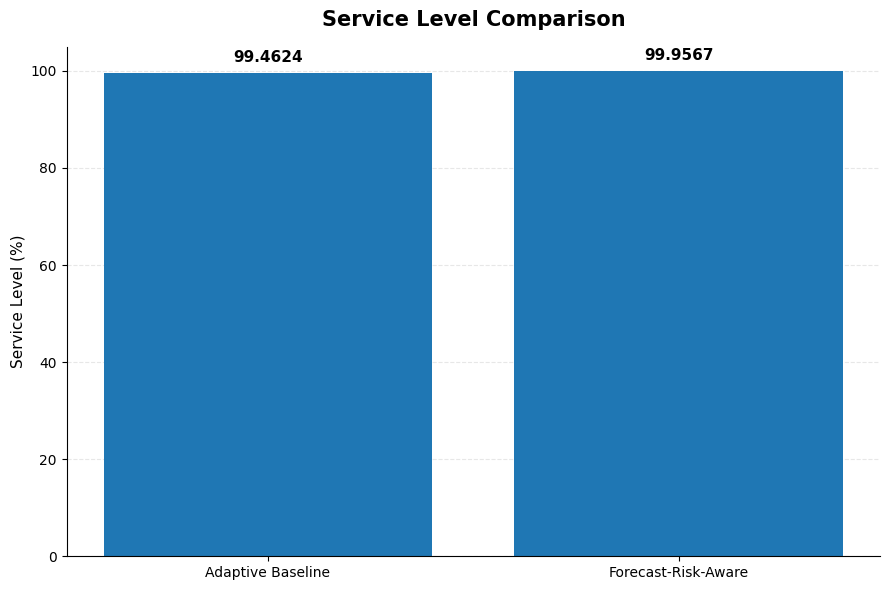

✓ Saved: /content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/07_Results/Figures/Final_Service_Level_Comparison.png


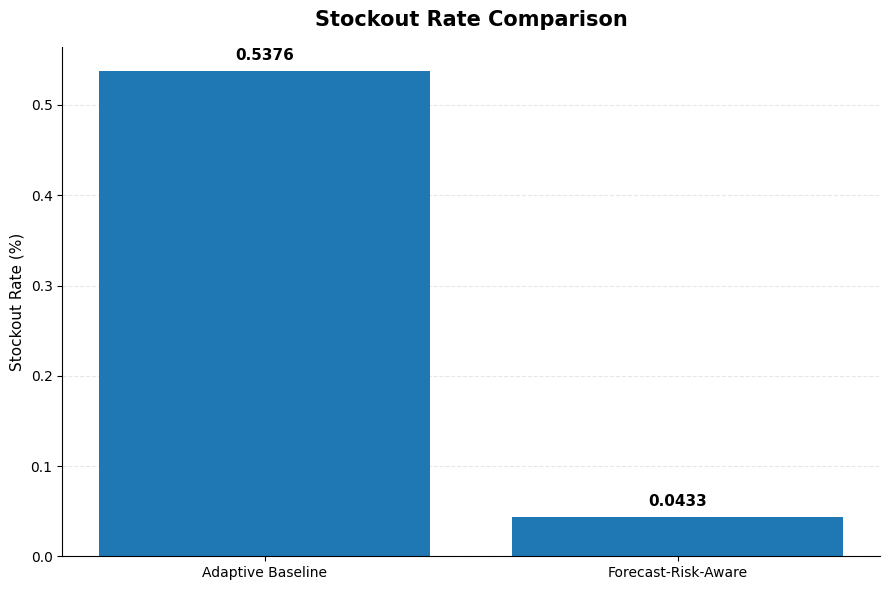

✓ Saved: /content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/07_Results/Figures/Final_Stockout_Rate_Comparison.png


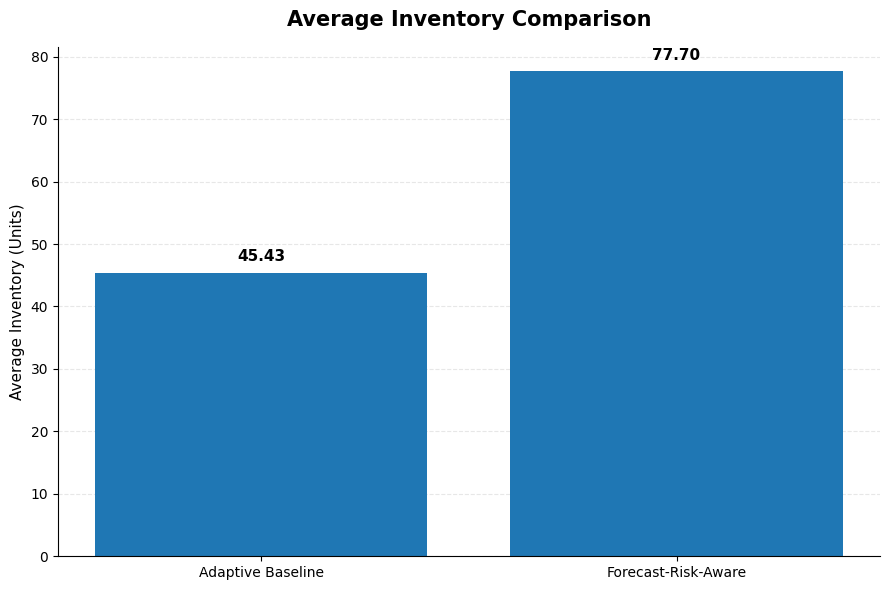

✓ Saved: /content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/07_Results/Figures/Final_Average_Inventory_Comparison.png


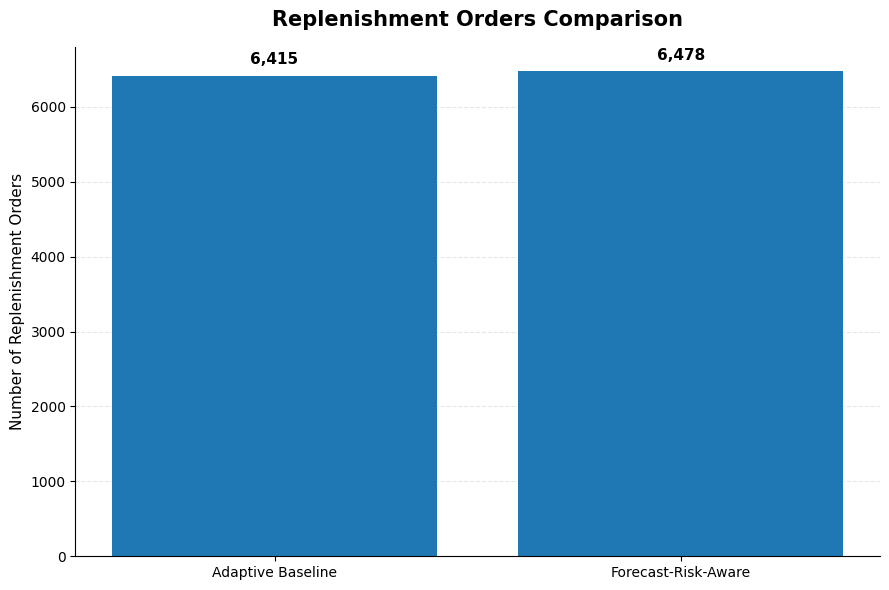

✓ Saved: /content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/07_Results/Figures/Final_Replenishment_Orders_Comparison.png

STEP 16.19 — FINAL FIGURES COMPLETE

Generated files:
✓ Final_Average_Inventory_Comparison.png (101.11 KB)
✓ Final_Replenishment_Orders_Comparison.png (107.61 KB)
✓ Final_Service_Level_Comparison.png (92.07 KB)
✓ Final_Stockout_Rate_Comparison.png (94.11 KB)

Figure directory:
/content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/07_Results/Figures



In [121]:
# ============================================================
# STEP 16.19 — FINAL RESEARCH FIGURES (CORRECTED)
# ============================================================

import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Create figures directory
# ------------------------------------------------------------

FIGURES_DIR = Path(
    "/content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/07_Results/Figures"
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Final KPI values
# ------------------------------------------------------------

models = [
    "Adaptive Baseline",
    "Forecast-Risk-Aware"
]

service_levels = [
    ad_service_level,
    fr_service_level
]

stockout_rates = [
    ad_stockout_rate,
    fr_stockout_rate
]

average_inventory = [
    ad_avg_inventory,
    fr_avg_inventory
]

replenishment_orders = [
    ad_orders,
    fr_orders
]


# ------------------------------------------------------------
# Figure creation function
# ------------------------------------------------------------

def create_comparison_figure(
    values,
    title,
    ylabel,
    filename,
    decimals=2
):

    fig, ax = plt.subplots(figsize=(9, 6))

    bars = ax.bar(
        models,
        values
    )

    ax.set_title(
        title,
        fontsize=15,
        fontweight="bold",
        pad=15
    )

    ax.set_ylabel(
        ylabel,
        fontsize=11
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    ax.set_axisbelow(True)

    # --------------------------------------------------------
    # Add value labels
    # --------------------------------------------------------

    for bar, value in zip(bars, values):

        ax.annotate(
            f"{value:,.{decimals}f}",
            xy=(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height()
            ),
            xytext=(0, 6),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

    # --------------------------------------------------------
    # Clean research-paper appearance
    # --------------------------------------------------------

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    output_path = FIGURES_DIR / filename

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"✓ Saved: {output_path}")


# ============================================================
# FIGURE 1 — SERVICE LEVEL
# ============================================================

create_comparison_figure(
    values=service_levels,
    title="Service Level Comparison",
    ylabel="Service Level (%)",
    filename="Final_Service_Level_Comparison.png",
    decimals=4
)


# ============================================================
# FIGURE 2 — STOCKOUT RATE
# ============================================================

create_comparison_figure(
    values=stockout_rates,
    title="Stockout Rate Comparison",
    ylabel="Stockout Rate (%)",
    filename="Final_Stockout_Rate_Comparison.png",
    decimals=4
)


# ============================================================
# FIGURE 3 — AVERAGE INVENTORY
# ============================================================

create_comparison_figure(
    values=average_inventory,
    title="Average Inventory Comparison",
    ylabel="Average Inventory (Units)",
    filename="Final_Average_Inventory_Comparison.png",
    decimals=2
)


# ============================================================
# FIGURE 4 — REPLENISHMENT ORDERS
# ============================================================

create_comparison_figure(
    values=replenishment_orders,
    title="Replenishment Orders Comparison",
    ylabel="Number of Replenishment Orders",
    filename="Final_Replenishment_Orders_Comparison.png",
    decimals=0
)


# ============================================================
# VALIDATION
# ============================================================

print("\n" + "=" * 80)
print("STEP 16.19 — FINAL FIGURES COMPLETE")
print("=" * 80)

print("\nGenerated files:")

for file in sorted(FIGURES_DIR.glob("Final_*.png")):
    print(
        f"✓ {file.name} "
        f"({file.stat().st_size / 1024:.2f} KB)"
    )

print("\nFigure directory:")
print(FIGURES_DIR)

print("\n" + "=" * 80)

In [122]:
# ============================================================
# STEP 16.20 — CONSOLIDATED FINAL RESEARCH EXCEL WORKBOOK
# ============================================================

from pathlib import Path
import pandas as pd

# ------------------------------------------------------------
# Output location
# ------------------------------------------------------------

RESULTS_DIR = Path(
    "/content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/07_Results"
)

OUTPUT_PATH = (
    RESULTS_DIR /
    "OptiChain_Inventory_Optimization_Final_Research_Results.xlsx"
)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# CREATE CONSOLIDATED WORKBOOK
# ============================================================

with pd.ExcelWriter(
    OUTPUT_PATH,
    engine="openpyxl"
) as writer:

    # --------------------------------------------------------
    # 1. Final KPI Comparison
    # --------------------------------------------------------

    final_kpi_comparison.to_excel(
        writer,
        sheet_name="Final KPI Comparison",
        index=False
    )


    # --------------------------------------------------------
    # 2. Research Summary
    # --------------------------------------------------------

    research_summary.to_excel(
        writer,
        sheet_name="Research Summary",
        index=False
    )


    # --------------------------------------------------------
    # 3. Forecast-Risk-Aware Policy
    # --------------------------------------------------------

    forecast_policy_df.to_excel(
        writer,
        sheet_name="Forecast Risk Policy",
        index=False
    )


    # --------------------------------------------------------
    # 4. Final Simulation Results
    # --------------------------------------------------------

    forecast_risk_simulation_results_df.to_excel(
        writer,
        sheet_name="Final Simulation",
        index=False
    )


    # --------------------------------------------------------
    # 5. Paired Risk Evaluation
    # --------------------------------------------------------

    paired_risk_df.to_excel(
        writer,
        sheet_name="Paired Risk Evaluation",
        index=False
    )


    # --------------------------------------------------------
    # 6. Inventory Parameters
    # --------------------------------------------------------

    inventory_parameters.to_excel(
        writer,
        sheet_name="Inventory Parameters",
        index=False
    )


    # --------------------------------------------------------
    # 7. Baseline vs Adaptive
    # --------------------------------------------------------

    baseline_results_df.to_excel(
        writer,
        sheet_name="Baseline Results",
        index=False
    )

    adaptive_results_df.to_excel(
        writer,
        sheet_name="Adaptive Results",
        index=False
    )


    # --------------------------------------------------------
    # 8. Disruption Scenario Results
    # --------------------------------------------------------

    if "disruption_parameter_results" in globals():

        for scenario, scenario_df in disruption_parameter_results.items():

            sheet_name = f"Params {scenario}"[:31]

            scenario_df.to_excel(
                writer,
                sheet_name=sheet_name,
                index=False
            )


    # --------------------------------------------------------
    # 9. Backorder ML Results
    # --------------------------------------------------------

    backorder_metrics_path = (
        RESULTS_DIR /
        "Metrics" /
        "Final_Backorder_XGBoost_Test_Metrics.csv"
    )

    if backorder_metrics_path.exists():

        backorder_metrics_df = pd.read_csv(
            backorder_metrics_path
        )

        backorder_metrics_df.to_excel(
            writer,
            sheet_name="Backorder ML Metrics",
            index=False
        )


    # --------------------------------------------------------
    # 10. Backorder Confusion Matrix
    # --------------------------------------------------------

    confusion_matrix_path = (
        RESULTS_DIR /
        "Tables" /
        "Backorder_XGBoost_Confusion_Matrix.csv"
    )

    if confusion_matrix_path.exists():

        confusion_matrix_df = pd.read_csv(
            confusion_matrix_path
        )

        confusion_matrix_df.to_excel(
            writer,
            sheet_name="Backorder Confusion",
            index=False
        )


    # --------------------------------------------------------
    # 11. Backorder Test Predictions
    # --------------------------------------------------------

    predictions_path = (
        RESULTS_DIR /
        "Tables" /
        "Backorder_XGBoost_Test_Predictions.csv"
    )

    if predictions_path.exists():

        predictions_df = pd.read_csv(
            predictions_path
        )

        predictions_df.to_excel(
            writer,
            sheet_name="Backorder Predictions",
            index=False
        )


# ============================================================
# FORMAT WORKBOOK
# ============================================================

from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter

workbook = load_workbook(OUTPUT_PATH)

for worksheet in workbook.worksheets:

    # Header formatting
    for cell in worksheet[1]:

        cell.font = Font(
            bold=True,
            color="FFFFFF"
        )

        cell.fill = PatternFill(
            fill_type="solid",
            fgColor="0B1F3A"
        )

        cell.alignment = Alignment(
            horizontal="center",
            vertical="center"
        )

    # Freeze header row
    worksheet.freeze_panes = "A2"

    # Auto-adjust column widths
    for column_cells in worksheet.columns:

        max_length = 0

        column_letter = get_column_letter(
            column_cells[0].column
        )

        for cell in column_cells:

            try:
                cell_length = len(str(cell.value))

                if cell_length > max_length:
                    max_length = cell_length

            except Exception:
                pass

        worksheet.column_dimensions[
            column_letter
        ].width = min(
            max(max_length + 2, 12),
            45
        )


# ------------------------------------------------------------
# Save formatted workbook
# ------------------------------------------------------------

workbook.save(OUTPUT_PATH)


# ============================================================
# VALIDATION
# ============================================================

print("=" * 80)
print("STEP 16.20 — CONSOLIDATED EXCEL WORKBOOK COMPLETE")
print("=" * 80)

print(f"\nWorkbook:")
print(OUTPUT_PATH)

print(
    f"\nFile size: "
    f"{OUTPUT_PATH.stat().st_size / (1024 * 1024):.2f} MB"
)

print("\nSheets created:")

for sheet in workbook.sheetnames:
    print(f"✓ {sheet}")

print("\nTotal sheets:", len(workbook.sheetnames))

print("\n" + "=" * 80)
print("FINAL RESEARCH WORKBOOK READY")
print("=" * 80)

STEP 16.20 — CONSOLIDATED EXCEL WORKBOOK COMPLETE

Workbook:
/content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/07_Results/OptiChain_Inventory_Optimization_Final_Research_Results.xlsx

File size: 27.93 MB

Sheets created:
✓ Final KPI Comparison
✓ Research Summary
✓ Forecast Risk Policy
✓ Final Simulation
✓ Paired Risk Evaluation
✓ Inventory Parameters
✓ Baseline Results
✓ Adaptive Results
✓ Params Normal
✓ Params Moderate
✓ Params Severe
✓ Backorder ML Metrics
✓ Backorder Confusion
✓ Backorder Predictions

Total sheets: 14

FINAL RESEARCH WORKBOOK READY


In [123]:
# ============================================================
# STEP 16.21A — CHECK SAVED INVENTORY RESULTS
# ============================================================

from pathlib import Path

RESULTS_DIR = Path(
    "/content/drive/MyDrive/OptiChain/Research/Inventory_Optimization/07_Results"
)

print("=" * 80)
print("CHECKING SAVED INVENTORY OPTIMIZATION RESULTS")
print("=" * 80)

print("\nMetrics files:")
for file in sorted((RESULTS_DIR / "Metrics").glob("*")):
    print(f"✓ {file.name}")

print("\nTable files:")
for file in sorted((RESULTS_DIR / "Tables").glob("*")):
    print(f"✓ {file.name}")

print("\nFigures:")
for file in sorted((RESULTS_DIR / "Figures").glob("*")):
    print(f"✓ {file.name}")

print("\n" + "=" * 80)
print("FILE CHECK COMPLETE")
print("=" * 80)

CHECKING SAVED INVENTORY OPTIMIZATION RESULTS

Metrics files:
✓ Backorder_Model_Comparison.csv
✓ Final_Backorder_XGBoost_Test_Metrics.csv
✓ Final_Forecast_Risk_Aware_KPI_Comparison.csv
✓ Final_Inventory_Research_Summary.csv
✓ Final_Research_KPI_Summary.csv
✓ Inventory_KPI_Change_Relative_to_Baseline.csv
✓ Normalized_KPI_Comparison.csv

Table files:
✓ Backorder_XGBoost_Confusion_Matrix.csv
✓ Backorder_XGBoost_Test_Predictions.csv
✓ Final_Forecast_Risk_Aware_Policy.csv
✓ Final_Forecast_Risk_Aware_Simulation.csv
✓ Final_Inventory_Model_Comparison.csv
✓ Final_Paired_Risk_Aware_Evaluation.csv

Figures:
✓ Figure_1_Service_Level_Comparison.png
✓ Figure_2_Stockout_Rate_Comparison.png
✓ Figure_3_Average_Inventory_Comparison.png
✓ Figure_4_Replenishment_Order_Comparison.png
✓ Final_Average_Inventory_Comparison.png
✓ Final_Replenishment_Orders_Comparison.png
✓ Final_Service_Level_Comparison.png
✓ Final_Stockout_Rate_Comparison.png

FILE CHECK COMPLETE


In [124]:
# ================================
# OPTICHAIN - CURRENT SESSION CHECK
# ================================

required_objects = [
    "df",
    "inventory_df",
    "inventory_model_df",
    "inventory_parameters",
    "simulation_df",
    "product_day_forecast",
    "integrated_upstream_df",
    "forecast_policy_df",
    "forecast_risk_simulation_df",
    "forecast_risk_simulation_results_df"
]

print("========== CURRENT SESSION STATUS ==========")

for name in required_objects:
    if name in globals():
        obj = globals()[name]
        try:
            print(f"✅ {name:<40} {type(obj).__name__} | shape={obj.shape}")
        except:
            print(f"✅ {name:<40} {type(obj).__name__}")
    else:
        print(f"❌ {name:<40} NOT DEFINED")

print("============================================")

========== CURRENT SESSION STATUS ==========
✅ df                                       DataFrame | shape=(180519, 53)
✅ inventory_df                             DataFrame | shape=(180519, 29)
✅ inventory_model_df                       DataFrame | shape=(171962, 30)
✅ inventory_parameters                     DataFrame | shape=(54, 14)
✅ simulation_df                            DataFrame | shape=(54216, 16)
✅ product_day_forecast                     DataFrame | shape=(1785, 7)
✅ integrated_upstream_df                   DataFrame | shape=(1785, 12)
✅ forecast_policy_df                       DataFrame | shape=(1785, 20)
✅ forecast_risk_simulation_df              DataFrame | shape=(54216, 27)
✅ forecast_risk_simulation_results_df      DataFrame | shape=(54216, 16)


In [125]:
# ============================================================
# EXPORT ALL CURRENT INVENTORY OPTIMIZATION RESULTS
# UP TO CURRENT STEP
# ============================================================

import os
import shutil
from google.colab import files

EXPORT_DIR = "/content/OptiChain_Inventory_Results_Upto_Current"

# Remove old export if it exists
if os.path.exists(EXPORT_DIR):
    shutil.rmtree(EXPORT_DIR)

os.makedirs(EXPORT_DIR)

# ------------------------------------------------------------
# 1. Export current DataFrames
# ------------------------------------------------------------

dataframes_to_export = {
    "DataCo_Raw": df,
    "Inventory_Analysis": inventory_df,
    "Inventory_Model": inventory_model_df,
    "Inventory_Parameters": inventory_parameters,
    "Simulation_Data": simulation_df,
    "Product_Day_Forecast": product_day_forecast,
    "Integrated_Upstream": integrated_upstream_df,
    "Forecast_Policy": forecast_policy_df,
    "Forecast_Risk_Simulation": forecast_risk_simulation_df,
    "Forecast_Risk_Simulation_Results": forecast_risk_simulation_results_df,
}

for name, dataframe in dataframes_to_export.items():
    path = os.path.join(EXPORT_DIR, f"{name}.csv")
    dataframe.to_csv(path, index=False)

    print(f"✅ Saved: {name}.csv | Shape: {dataframe.shape}")

# ------------------------------------------------------------
# 2. Save scenario results if they exist
# ------------------------------------------------------------

if "disruption_simulation_results" in globals():

    scenario_dir = os.path.join(EXPORT_DIR, "Disruption_Scenario_Results")
    os.makedirs(scenario_dir, exist_ok=True)

    for scenario, dataframe in disruption_simulation_results.items():
        path = os.path.join(
            scenario_dir,
            f"{scenario}_Disruption_Simulation.csv"
        )

        dataframe.to_csv(path, index=False)

        print(
            f"✅ Saved scenario: {scenario} | "
            f"Shape: {dataframe.shape}"
        )

# ------------------------------------------------------------
# 3. Save disruption parameter results
# ------------------------------------------------------------

if "disruption_parameter_results" in globals():

    parameter_dir = os.path.join(
        EXPORT_DIR,
        "Disruption_Parameter_Results"
    )

    os.makedirs(parameter_dir, exist_ok=True)

    for scenario, dataframe in disruption_parameter_results.items():

        path = os.path.join(
            parameter_dir,
            f"{scenario}_Disruption_Parameters.csv"
        )

        dataframe.to_csv(path, index=False)

        print(
            f"✅ Saved parameters: {scenario} | "
            f"Shape: {dataframe.shape}"
        )

# ------------------------------------------------------------
# 4. Save existing KPI/result DataFrames
# ------------------------------------------------------------

result_objects = [
    "baseline_results_df",
    "adaptive_results_df",
    "baseline_vs_adaptive_df",
    "disruption_kpi_df",
    "final_kpi_comparison_df",
]

for name in result_objects:

    if name in globals():

        obj = globals()[name]

        if hasattr(obj, "to_csv"):

            path = os.path.join(
                EXPORT_DIR,
                f"{name}.csv"
            )

            obj.to_csv(path, index=False)

            print(f"✅ Saved result: {name}.csv")

# ------------------------------------------------------------
# 5. Save the current notebook
# ------------------------------------------------------------

notebook_files = [
    f for f in os.listdir("/content")
    if f.endswith(".ipynb")
]

for notebook in notebook_files:

    source = os.path.join("/content", notebook)
    destination = os.path.join(EXPORT_DIR, notebook)

    shutil.copy2(source, destination)

    print(f"✅ Notebook included: {notebook}")

# ------------------------------------------------------------
# 6. Create ZIP
# ------------------------------------------------------------

ZIP_PATH = shutil.make_archive(
    "/content/OptiChain_Inventory_Results_Upto_Current",
    "zip",
    EXPORT_DIR
)

size_mb = os.path.getsize(ZIP_PATH) / (1024 * 1024)

print("\n==============================================")
print("       OPTICHAIN EXPORT COMPLETED")
print("==============================================")
print(f"ZIP: {ZIP_PATH}")
print(f"Size: {size_mb:.2f} MB")
print("==============================================")

# ------------------------------------------------------------
# 7. Download ZIP
# ------------------------------------------------------------

files.download(ZIP_PATH)

✅ Saved: DataCo_Raw.csv | Shape: (180519, 53)
✅ Saved: Inventory_Analysis.csv | Shape: (180519, 29)
✅ Saved: Inventory_Model.csv | Shape: (171962, 30)
✅ Saved: Inventory_Parameters.csv | Shape: (54, 14)
✅ Saved: Simulation_Data.csv | Shape: (54216, 16)
✅ Saved: Product_Day_Forecast.csv | Shape: (1785, 7)
✅ Saved: Integrated_Upstream.csv | Shape: (1785, 12)
✅ Saved: Forecast_Policy.csv | Shape: (1785, 20)
✅ Saved: Forecast_Risk_Simulation.csv | Shape: (54216, 27)
✅ Saved: Forecast_Risk_Simulation_Results.csv | Shape: (54216, 16)
✅ Saved scenario: Normal | Shape: (54216, 27)
✅ Saved scenario: Moderate | Shape: (54216, 27)
✅ Saved scenario: Severe | Shape: (54216, 27)
✅ Saved parameters: Normal | Shape: (54216, 21)
✅ Saved parameters: Moderate | Shape: (54216, 21)
✅ Saved parameters: Severe | Shape: (54216, 21)
✅ Saved result: baseline_results_df.csv
✅ Saved result: adaptive_results_df.csv

       OPTICHAIN EXPORT COMPLETED
ZIP: /content/OptiChain_Inventory_Results_Upto_Current.zip
Size: 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [126]:
# ============================================================
# STEP 15.1 — LOAD BACKORDER PREDICTION DATASETS
# ============================================================

import pandas as pd
import os

TRAIN_BOP_PATH = "/content/Training_BOP.csv"
TEST_BOP_PATH = "/content/Testing_BOP.csv"

training_bop_df = pd.read_csv(TRAIN_BOP_PATH)
testing_bop_df = pd.read_csv(TEST_BOP_PATH)

print("========== BACKORDER DATASET LOADED ==========")
print(f"Training shape : {training_bop_df.shape}")
print(f"Testing shape  : {testing_bop_df.shape}")

print("\nTraining columns:")
print(training_bop_df.columns.tolist())

print("\nTesting columns:")
print(testing_bop_df.columns.tolist())

print("\nTraining preview:")
display(training_bop_df.head())

print("\nTesting preview:")
display(testing_bop_df.head())

/tmp/ipykernel_8671/2660842062.py:11: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  training_bop_df = pd.read_csv(TRAIN_BOP_PATH)
/tmp/ipykernel_8671/2660842062.py:12: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  testing_bop_df = pd.read_csv(TEST_BOP_PATH)


========== BACKORDER DATASET LOADED ==========
Training shape : (1687861, 23)
Testing shape  : (242076, 23)

Training columns:
['sku', 'national_inv', 'lead_time', 'in_transit_qty', 'forecast_3_month', 'forecast_6_month', 'forecast_9_month', 'sales_1_month', 'sales_3_month', 'sales_6_month', 'sales_9_month', 'min_bank', 'potential_issue', 'pieces_past_due', 'perf_6_month_avg', 'perf_12_month_avg', 'local_bo_qty', 'deck_risk', 'oe_constraint', 'ppap_risk', 'stop_auto_buy', 'rev_stop', 'went_on_backorder']

Testing columns:
['sku', 'national_inv', 'lead_time', 'in_transit_qty', 'forecast_3_month', 'forecast_6_month', 'forecast_9_month', 'sales_1_month', 'sales_3_month', 'sales_6_month', 'sales_9_month', 'min_bank', 'potential_issue', 'pieces_past_due', 'perf_6_month_avg', 'perf_12_month_avg', 'local_bo_qty', 'deck_risk', 'oe_constraint', 'ppap_risk', 'stop_auto_buy', 'rev_stop', 'went_on_backorder']

Training preview:


,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,sales_9_month,min_bank,potential_issue,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
0,1026827,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No,0.0,-99.00,-99.00,0.0,No,No,No,Yes,No,No
1,1043384,2.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No,0.0,0.99,0.99,0.0,No,No,No,Yes,No,No
2,1043696,2.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No,0.0,-99.00,-99.00,0.0,Yes,No,No,Yes,No,No
3,1043852,7.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,No,0.0,0.10,0.13,0.0,No,No,No,Yes,No,No
4,1044048,8.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,2.0,No,0.0,-99.00,-99.00,0.0,Yes,No,No,Yes,No,No



Testing preview:


,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,sales_9_month,min_bank,potential_issue,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
0,3285085,62.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,No,0.0,-99.00,-99.00,0.0,Yes,No,No,Yes,No,No
1,3285131,9.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,No,0.0,-99.00,-99.00,0.0,No,No,Yes,No,No,No
2,3285358,17.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No,0.0,0.92,0.95,0.0,No,No,No,Yes,No,No
3,3285517,9.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,No,0.0,0.78,0.75,0.0,No,No,Yes,Yes,No,No
4,3285608,2.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No,0.0,0.54,0.71,0.0,No,No,No,Yes,No,No


In [127]:
# ============================================================
# STEP 17.2 — BACKORDER DATA QUALITY ANALYSIS
# ============================================================

print("========== BACKORDER DATA QUALITY ANALYSIS ==========")

# ------------------------------------------------------------
# 1. Dataset dimensions
# ------------------------------------------------------------
print("\n--- Dataset Dimensions ---")
print(f"Training shape : {training_bop_df.shape}")
print(f"Testing shape  : {testing_bop_df.shape}")

# ------------------------------------------------------------
# 2. Column information
# ------------------------------------------------------------
print("\n--- Training Data Types ---")
display(training_bop_df.dtypes)

# ------------------------------------------------------------
# 3. Missing values
# ------------------------------------------------------------
print("\n--- Missing Values: Training ---")
training_missing = (
    training_bop_df.isnull()
    .sum()
    .sort_values(ascending=False)
)

display(
    training_missing[training_missing > 0]
    .to_frame("Missing_Count")
)

print("\n--- Missing Values: Testing ---")
testing_missing = (
    testing_bop_df.isnull()
    .sum()
    .sort_values(ascending=False)
)

display(
    testing_missing[testing_missing > 0]
    .to_frame("Missing_Count")
)

# ------------------------------------------------------------
# 4. Duplicate records
# ------------------------------------------------------------
print("\n--- Duplicate Records ---")
print("Training duplicates:", training_bop_df.duplicated().sum())
print("Testing duplicates :", testing_bop_df.duplicated().sum())

# ------------------------------------------------------------
# 5. Target distribution
# ------------------------------------------------------------
print("\n--- Target Distribution ---")

print("\nTraining target:")
display(
    training_bop_df["went_on_backorder"]
    .value_counts(dropna=False)
    .to_frame("Count")
)

print("\nTraining target percentage:")
display(
    (
        training_bop_df["went_on_backorder"]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(4)
        .to_frame("Percentage")
    )
)

print("\nTesting target:")
display(
    testing_bop_df["went_on_backorder"]
    .value_counts(dropna=False)
    .to_frame("Count")
)

# ------------------------------------------------------------
# 6. Unique values of categorical / binary fields
# ------------------------------------------------------------
binary_columns = [
    "potential_issue",
    "deck_risk",
    "oe_constraint",
    "ppap_risk",
    "stop_auto_buy",
    "rev_stop",
    "went_on_backorder"
]

print("\n--- Binary / Categorical Value Checks ---")

for col in binary_columns:
    if col in training_bop_df.columns:
        print(f"\n{col}:")
        print(training_bop_df[col].value_counts(dropna=False).to_dict())

# ------------------------------------------------------------
# 7. Special missing-value code check
# ------------------------------------------------------------
print("\n--- Special Value Check (-99) ---")

special_value_columns = [
    "perf_6_month_avg",
    "perf_12_month_avg"
]

for col in special_value_columns:
    if col in training_bop_df.columns:
        count_99 = (training_bop_df[col] == -99).sum()
        print(f"{col}: {count_99:,} records with -99")

# ------------------------------------------------------------
# 8. Identifier uniqueness
# ------------------------------------------------------------
print("\n--- SKU Identifier Check ---")

print(
    "Training unique SKU values:",
    training_bop_df["sku"].nunique()
)

print(
    "Training rows:",
    len(training_bop_df)
)

print(
    "Testing unique SKU values:",
    testing_bop_df["sku"].nunique()
)

print(
    "Testing rows:",
    len(testing_bop_df)
)

print("\n========== QUALITY ANALYSIS COMPLETE ==========")

========== BACKORDER DATA QUALITY ANALYSIS ==========

--- Dataset Dimensions ---
Training shape : (1687861, 23)
Testing shape  : (242076, 23)

--- Training Data Types ---


,0
sku,object
national_inv,float64
lead_time,float64
in_transit_qty,float64
forecast_3_month,float64
forecast_6_month,float64
forecast_9_month,float64
sales_1_month,float64
sales_3_month,float64
sales_6_month,float64



--- Missing Values: Training ---


,Missing_Count
lead_time,100894
national_inv,1
in_transit_qty,1
forecast_6_month,1
forecast_3_month,1
forecast_9_month,1
sales_1_month,1
perf_12_month_avg,1
sales_3_month,1
sales_6_month,1



--- Missing Values: Testing ---


...


Training target percentage:


,Percentage
went_on_backorder,
No,99.3309
Yes,0.6691
NaN,0.0001



Testing target:


,Count
went_on_backorder,
No,239387
Yes,2688
NaN,1



--- Binary / Categorical Value Checks ---

potential_issue:
{'No': 1686953, 'Yes': 907, nan: 1}

deck_risk:
{'No': 1300377, 'Yes': 387483, nan: 1}

oe_constraint:
{'No': 1687615, 'Yes': 245, nan: 1}

ppap_risk:
{'No': 1484026, 'Yes': 203834, nan: 1}

stop_auto_buy:
{'Yes': 1626774, 'No': 61086, nan: 1}

rev_stop:
{'No': 1687129, 'Yes': 731, nan: 1}

went_on_backorder:
{'No': 1676567, 'Yes': 11293, nan: 1}

--- Special Value Check (-99) ---
perf_6_month_avg: 129,478 records with -99
perf_12_month_avg: 122,050 records with -99

--- SKU Identifier Check ---
Training unique SKU values: 1687861
Training rows: 1687861
Testing unique SKU values: 242076
Testing rows: 242076

========== QUALITY ANALYSIS COMPLETE ==========


In [128]:
# ============================================================
# STEP 17.3 — BACKORDER DATA CLEANING
# ============================================================

import numpy as np

print("========== BACKORDER DATA CLEANING ==========")

# ------------------------------------------------------------
# Create working copies
# ------------------------------------------------------------
bop_train_clean = training_bop_df.copy()
bop_test_clean = testing_bop_df.copy()

print("Original training shape:", bop_train_clean.shape)
print("Original testing shape :", bop_test_clean.shape)

# ------------------------------------------------------------
# 1. Convert special -99 values to NaN
# ------------------------------------------------------------
performance_columns = [
    "perf_6_month_avg",
    "perf_12_month_avg"
]

for col in performance_columns:
    bop_train_clean[col] = bop_train_clean[col].replace(-99, np.nan)
    bop_test_clean[col] = bop_test_clean[col].replace(-99, np.nan)

print("\nSpecial -99 values converted to NaN.")

# ------------------------------------------------------------
# 2. Remove rows with missing target from training
# ------------------------------------------------------------
before_target_removal = len(bop_train_clean)

bop_train_clean = bop_train_clean.dropna(
    subset=["went_on_backorder"]
).copy()

removed_target_rows = (
    before_target_removal - len(bop_train_clean)
)

print(
    f"Rows removed due to missing target: "
    f"{removed_target_rows}"
)

# ------------------------------------------------------------
# 3. Convert binary categorical variables
# ------------------------------------------------------------
binary_columns = [
    "potential_issue",
    "deck_risk",
    "oe_constraint",
    "ppap_risk",
    "stop_auto_buy",
    "rev_stop"
]

binary_mapping = {
    "No": 0,
    "Yes": 1
}

for col in binary_columns:
    bop_train_clean[col] = bop_train_clean[col].map(binary_mapping)
    bop_test_clean[col] = bop_test_clean[col].map(binary_mapping)

# ------------------------------------------------------------
# 4. Convert target variable
# ------------------------------------------------------------
bop_train_clean["went_on_backorder"] = (
    bop_train_clean["went_on_backorder"]
    .map(binary_mapping)
    .astype(int)
)

bop_test_clean["went_on_backorder"] = (
    bop_test_clean["went_on_backorder"]
    .map(binary_mapping)
)

# ------------------------------------------------------------
# 5. Drop SKU identifier
# ------------------------------------------------------------
# SKU is unique for every row and therefore acts as an
# identifier rather than a meaningful predictive feature.

bop_train_clean = bop_train_clean.drop(columns=["sku"])
bop_test_clean = bop_test_clean.drop(columns=["sku"])

# ------------------------------------------------------------
# 6. Verify cleaning
# ------------------------------------------------------------
print("\n--- Cleaned Dataset Shapes ---")
print("Training:", bop_train_clean.shape)
print("Testing :", bop_test_clean.shape)

print("\n--- Remaining Missing Values: Training ---")
train_missing_after_cleaning = (
    bop_train_clean.isnull()
    .sum()
    .sort_values(ascending=False)
)

display(
    train_missing_after_cleaning[
        train_missing_after_cleaning > 0
    ].to_frame("Missing_Count")
)

print("\n--- Remaining Missing Values: Testing ---")
test_missing_after_cleaning = (
    bop_test_clean.isnull()
    .sum()
    .sort_values(ascending=False)
)

display(
    test_missing_after_cleaning[
        test_missing_after_cleaning > 0
    ].to_frame("Missing_Count")
)

print("\n--- Target Distribution After Cleaning ---")
display(
    bop_train_clean["went_on_backorder"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

print("\n--- Data Types After Cleaning ---")
display(bop_train_clean.dtypes)

print("\n========== DATA CLEANING COMPLETE ==========")

========== BACKORDER DATA CLEANING ==========
Original training shape: (1687861, 23)
Original testing shape : (242076, 23)

Special -99 values converted to NaN.
Rows removed due to missing target: 1

--- Cleaned Dataset Shapes ---
Training: (1687860, 22)
Testing : (242076, 22)

--- Remaining Missing Values: Training ---


,Missing_Count
perf_6_month_avg,129478
perf_12_month_avg,122050
lead_time,100893



--- Remaining Missing Values: Testing ---


,Missing_Count
perf_6_month_avg,19102
perf_12_month_avg,17976
lead_time,14725
forecast_3_month,1
in_transit_qty,1
national_inv,1
forecast_9_month,1
forecast_6_month,1
sales_6_month,1
sales_1_month,1



--- Target Distribution After Cleaning ---


,Count
went_on_backorder,
0,1676567
1,11293



--- Data Types After Cleaning ---


,0
national_inv,float64
lead_time,float64
in_transit_qty,float64
forecast_3_month,float64
forecast_6_month,float64
forecast_9_month,float64
sales_1_month,float64
sales_3_month,float64
sales_6_month,float64
sales_9_month,float64



========== DATA CLEANING COMPLETE ==========


In [129]:
# ============================================================
# STEP 17.4 — MISSING-VALUE IMPUTATION
# ============================================================

print("========== BACKORDER MISSING-VALUE IMPUTATION ==========")

# ------------------------------------------------------------
# 1. Identify numerical feature columns
# ------------------------------------------------------------
target_column = "went_on_backorder"

numerical_columns = bop_train_clean.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Remove target from imputation features
numerical_features = [
    col for col in numerical_columns
    if col != target_column
]

print("Numerical features:")
print(numerical_features)

# ------------------------------------------------------------
# 2. Calculate medians using TRAINING DATA ONLY
# ------------------------------------------------------------
train_medians = bop_train_clean[
    numerical_features
].median()

print("\n--- Training-Derived Imputation Values ---")
display(
    train_medians.to_frame("Training_Median")
)

# ------------------------------------------------------------
# 3. Apply training medians to training and testing
# ------------------------------------------------------------
bop_train_imputed = bop_train_clean.copy()
bop_test_imputed = bop_test_clean.copy()

for col in numerical_features:
    bop_train_imputed[col] = (
        bop_train_imputed[col]
        .fillna(train_medians[col])
    )

    bop_test_imputed[col] = (
        bop_test_imputed[col]
        .fillna(train_medians[col])
    )

# ------------------------------------------------------------
# 4. Verify remaining missing values
# ------------------------------------------------------------
print("\n--- Remaining Missing Values: Training ---")

train_remaining_missing = (
    bop_train_imputed.isnull()
    .sum()
    .sort_values(ascending=False)
)

display(
    train_remaining_missing[
        train_remaining_missing > 0
    ].to_frame("Missing_Count")
)

print("\n--- Remaining Missing Values: Testing ---")

test_remaining_missing = (
    bop_test_imputed.isnull()
    .sum()
    .sort_values(ascending=False)
)

display(
    test_remaining_missing[
        test_remaining_missing > 0
    ].to_frame("Missing_Count")
)

# ------------------------------------------------------------
# 5. Final shape verification
# ------------------------------------------------------------
print("\n--- Final Imputed Dataset Shapes ---")
print("Training:", bop_train_imputed.shape)
print("Testing :", bop_test_imputed.shape)

# ------------------------------------------------------------
# 6. Store feature lists for later modelling
# ------------------------------------------------------------
BOP_FEATURE_COLUMNS = [
    col for col in bop_train_imputed.columns
    if col != target_column
]

print("\nNumber of modelling features:",
      len(BOP_FEATURE_COLUMNS))

print("\nModelling features:")
print(BOP_FEATURE_COLUMNS)

print("\n========== IMPUTATION COMPLETE ==========")

========== BACKORDER MISSING-VALUE IMPUTATION ==========
Numerical features:
['national_inv', 'lead_time', 'in_transit_qty', 'forecast_3_month', 'forecast_6_month', 'forecast_9_month', 'sales_1_month', 'sales_3_month', 'sales_6_month', 'sales_9_month', 'min_bank', 'potential_issue', 'pieces_past_due', 'perf_6_month_avg', 'perf_12_month_avg', 'local_bo_qty', 'deck_risk', 'oe_constraint', 'ppap_risk', 'stop_auto_buy', 'rev_stop']

--- Training-Derived Imputation Values ---


,Training_Median
national_inv,15.00
lead_time,8.00
in_transit_qty,0.00
forecast_3_month,0.00
forecast_6_month,0.00
forecast_9_month,0.00
sales_1_month,0.00
sales_3_month,1.00
sales_6_month,2.00
sales_9_month,4.00



--- Remaining Missing Values: Training ---


,Missing_Count



--- Remaining Missing Values: Testing ---


,Missing_Count
went_on_backorder,1



--- Final Imputed Dataset Shapes ---
Training: (1687860, 22)
Testing : (242076, 22)

Number of modelling features: 21

Modelling features:
['national_inv', 'lead_time', 'in_transit_qty', 'forecast_3_month', 'forecast_6_month', 'forecast_9_month', 'sales_1_month', 'sales_3_month', 'sales_6_month', 'sales_9_month', 'min_bank', 'potential_issue', 'pieces_past_due', 'perf_6_month_avg', 'perf_12_month_avg', 'local_bo_qty', 'deck_risk', 'oe_constraint', 'ppap_risk', 'stop_auto_buy', 'rev_stop']

========== IMPUTATION COMPLETE ==========


In [130]:
# ============================================================
# STEP 17.5 — BACKORDER FEATURE ENGINEERING
# ============================================================

print("========== BACKORDER FEATURE ENGINEERING ==========")

# ------------------------------------------------------------
# Create copies
# ------------------------------------------------------------
bop_train_fe = bop_train_imputed.copy()
bop_test_fe = bop_test_imputed.copy()

# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------
def safe_divide(numerator, denominator):
    return numerator / denominator.replace(0, np.nan).fillna(1)

# ------------------------------------------------------------
# 1. Average monthly demand over 3 months
# ------------------------------------------------------------
bop_train_fe["demand_3m_avg"] = (
    bop_train_fe["sales_3_month"] / 3
)

bop_test_fe["demand_3m_avg"] = (
    bop_test_fe["sales_3_month"] / 3
)

# ------------------------------------------------------------
# 2. Inventory-to-demand ratio
# ------------------------------------------------------------
bop_train_fe["inventory_demand_ratio"] = safe_divide(
    bop_train_fe["national_inv"],
    bop_train_fe["demand_3m_avg"]
)

bop_test_fe["inventory_demand_ratio"] = safe_divide(
    bop_test_fe["national_inv"],
    bop_test_fe["demand_3m_avg"]
)

# ------------------------------------------------------------
# 3. Total available supply
# ------------------------------------------------------------
bop_train_fe["total_available_supply"] = (
    bop_train_fe["national_inv"]
    + bop_train_fe["in_transit_qty"]
    + bop_train_fe["local_bo_qty"]
)

bop_test_fe["total_available_supply"] = (
    bop_test_fe["national_inv"]
    + bop_test_fe["in_transit_qty"]
    + bop_test_fe["local_bo_qty"]
)

# ------------------------------------------------------------
# 4. Supply gap relative to 3-month demand
# ------------------------------------------------------------
bop_train_fe["supply_gap_3m"] = (
    bop_train_fe["sales_3_month"]
    - bop_train_fe["total_available_supply"]
)

bop_test_fe["supply_gap_3m"] = (
    bop_test_fe["sales_3_month"]
    - bop_test_fe["total_available_supply"]
)

# ------------------------------------------------------------
# 5. Forecast-to-inventory ratio
# ------------------------------------------------------------
bop_train_fe["forecast_to_inventory_ratio"] = safe_divide(
    bop_train_fe["forecast_3_month"],
    bop_train_fe["national_inv"]
)

bop_test_fe["forecast_to_inventory_ratio"] = safe_divide(
    bop_test_fe["forecast_3_month"],
    bop_test_fe["national_inv"]
)

# ------------------------------------------------------------
# 6. Average monthly sales indicators
# ------------------------------------------------------------
bop_train_fe["sales_3m_avg"] = (
    bop_train_fe["sales_3_month"] / 3
)

bop_train_fe["sales_6m_avg"] = (
    bop_train_fe["sales_6_month"] / 6
)

bop_train_fe["sales_9m_avg"] = (
    bop_train_fe["sales_9_month"] / 9
)

bop_test_fe["sales_3m_avg"] = (
    bop_test_fe["sales_3_month"] / 3
)

bop_test_fe["sales_6m_avg"] = (
    bop_test_fe["sales_6_month"] / 6
)

bop_test_fe["sales_9m_avg"] = (
    bop_test_fe["sales_9_month"] / 9
)

# ------------------------------------------------------------
# 7. Recent sales trend
# ------------------------------------------------------------
bop_train_fe["sales_trend_3m_9m"] = safe_divide(
    bop_train_fe["sales_3m_avg"],
    bop_train_fe["sales_9m_avg"]
)

bop_test_fe["sales_trend_3m_9m"] = safe_divide(
    bop_test_fe["sales_3m_avg"],
    bop_test_fe["sales_9m_avg"]
)

# ------------------------------------------------------------
# 8. Forecast growth indicators
# ------------------------------------------------------------
bop_train_fe["forecast_growth_3m_6m"] = safe_divide(
    bop_train_fe["forecast_6_month"]
    - bop_train_fe["forecast_3_month"],
    bop_train_fe["forecast_3_month"]
)

bop_train_fe["forecast_growth_6m_9m"] = safe_divide(
    bop_train_fe["forecast_9_month"]
    - bop_train_fe["forecast_6_month"],
    bop_train_fe["forecast_6_month"]
)

bop_test_fe["forecast_growth_3m_6m"] = safe_divide(
    bop_test_fe["forecast_6_month"]
    - bop_test_fe["forecast_3_month"],
    bop_test_fe["forecast_3_month"]
)

bop_test_fe["forecast_growth_6m_9m"] = safe_divide(
    bop_test_fe["forecast_9_month"]
    - bop_test_fe["forecast_6_month"],
    bop_test_fe["forecast_6_month"]
)

# ------------------------------------------------------------
# 9. Inventory compared with minimum bank level
# ------------------------------------------------------------
bop_train_fe["inventory_vs_min_bank"] = (
    bop_train_fe["national_inv"]
    - bop_train_fe["min_bank"]
)

bop_test_fe["inventory_vs_min_bank"] = (
    bop_test_fe["national_inv"]
    - bop_test_fe["min_bank"]
)

# ------------------------------------------------------------
# 10. Past-due pressure
# ------------------------------------------------------------
bop_train_fe["past_due_ratio"] = safe_divide(
    bop_train_fe["pieces_past_due"],
    bop_train_fe["sales_3_month"]
)

bop_test_fe["past_due_ratio"] = safe_divide(
    bop_test_fe["pieces_past_due"],
    bop_test_fe["sales_3_month"]
)

# ------------------------------------------------------------
# 11. Local backorder pressure
# ------------------------------------------------------------
bop_train_fe["local_backorder_pressure"] = (
    bop_train_fe["local_bo_qty"]
    + bop_train_fe["pieces_past_due"]
)

bop_test_fe["local_backorder_pressure"] = (
    bop_test_fe["local_bo_qty"]
    + bop_test_fe["pieces_past_due"]
)

# ------------------------------------------------------------
# 12. Lead-time demand pressure
# ------------------------------------------------------------
bop_train_fe["lead_time_demand_pressure"] = (
    bop_train_fe["demand_3m_avg"]
    * bop_train_fe["lead_time"]
)

bop_test_fe["lead_time_demand_pressure"] = (
    bop_test_fe["demand_3m_avg"]
    * bop_test_fe["lead_time"]
)

# ------------------------------------------------------------
# 13. Replace any generated infinite values
# ------------------------------------------------------------
bop_train_fe = bop_train_fe.replace(
    [np.inf, -np.inf],
    np.nan
)

bop_test_fe = bop_test_fe.replace(
    [np.inf, -np.inf],
    np.nan
)

# ------------------------------------------------------------
# 14. Impute generated NaN values using TRAINING medians
# ------------------------------------------------------------
feature_columns_before_target = [
    col for col in bop_train_fe.columns
    if col != "went_on_backorder"
]

feature_medians = bop_train_fe[
    feature_columns_before_target
].median()

for col in feature_columns_before_target:
    bop_train_fe[col] = (
        bop_train_fe[col]
        .fillna(feature_medians[col])
    )

    bop_test_fe[col] = (
        bop_test_fe[col]
        .fillna(feature_medians[col])
    )

# ------------------------------------------------------------
# 15. Final feature list
# ------------------------------------------------------------
BOP_FEATURE_COLUMNS = [
    col
    for col in bop_train_fe.columns
    if col != "went_on_backorder"
]

# ------------------------------------------------------------
# 16. Verification
# ------------------------------------------------------------
print("\n--- Feature Engineering Results ---")
print("Training shape:", bop_train_fe.shape)
print("Testing shape :", bop_test_fe.shape)

print("\nOriginal modelling features:", 21)
print(
    "Engineered features added:",
    len(BOP_FEATURE_COLUMNS) - 21
)

print(
    "Final modelling features:",
    len(BOP_FEATURE_COLUMNS)
)

print("\nNew engineered features:")

engineered_features = [
    "demand_3m_avg",
    "inventory_demand_ratio",
    "total_available_supply",
    "supply_gap_3m",
    "forecast_to_inventory_ratio",
    "sales_3m_avg",
    "sales_6m_avg",
    "sales_9m_avg",
    "sales_trend_3m_9m",
    "forecast_growth_3m_6m",
    "forecast_growth_6m_9m",
    "inventory_vs_min_bank",
    "past_due_ratio",
    "local_backorder_pressure",
    "lead_time_demand_pressure"
]

print(engineered_features)

print("\nRemaining missing values - Training:")
print(
    bop_train_fe.isnull().sum().sum()
)

print("\nRemaining missing values - Testing:")
print(
    bop_test_fe.drop(
        columns=["went_on_backorder"]
    ).isnull().sum().sum()
)

print("\n========== FEATURE ENGINEERING COMPLETE ==========")

========== BACKORDER FEATURE ENGINEERING ==========

--- Feature Engineering Results ---
Training shape: (1687860, 37)
Testing shape : (242076, 37)

Original modelling features: 21
Engineered features added: 15
Final modelling features: 36

New engineered features:
['demand_3m_avg', 'inventory_demand_ratio', 'total_available_supply', 'supply_gap_3m', 'forecast_to_inventory_ratio', 'sales_3m_avg', 'sales_6m_avg', 'sales_9m_avg', 'sales_trend_3m_9m', 'forecast_growth_3m_6m', 'forecast_growth_6m_9m', 'inventory_vs_min_bank', 'past_due_ratio', 'local_backorder_pressure', 'lead_time_demand_pressure']

Remaining missing values - Training:
0

Remaining missing values - Testing:
0

========== FEATURE ENGINEERING COMPLETE ==========


In [131]:
# ============================================================
# STEP 17.6 — BACKORDER FEATURE LEAKAGE ANALYSIS
# ============================================================

print("========== BACKORDER LEAKAGE ANALYSIS ==========")

TARGET = "went_on_backorder"

# ------------------------------------------------------------
# 1. Target presence check
# ------------------------------------------------------------
print("\n--- Target Presence ---")

print(
    "Target in training:",
    TARGET in bop_train_fe.columns
)

print(
    "Target in testing:",
    TARGET in bop_test_fe.columns
)

# ------------------------------------------------------------
# 2. Feature consistency between train and test
# ------------------------------------------------------------
train_features = set(
    col for col in bop_train_fe.columns
    if col != TARGET
)

test_features = set(
    col for col in bop_test_fe.columns
    if col != TARGET
)

print("\n--- Train/Test Feature Consistency ---")

print(
    "Features only in training:",
    train_features - test_features
)

print(
    "Features only in testing:",
    test_features - train_features
)

print(
    "Number of common features:",
    len(train_features.intersection(test_features))
)

# ------------------------------------------------------------
# 3. Check whether target is accidentally included
# ------------------------------------------------------------
print("\n--- Direct Target Leakage Check ---")

target_in_features = TARGET in BOP_FEATURE_COLUMNS

print(
    "Target included in modelling features:",
    target_in_features
)

# ------------------------------------------------------------
# 4. Check identifier columns
# ------------------------------------------------------------
print("\n--- Identifier Leakage Check ---")

identifier_candidates = [
    "sku",
    "id",
    "ID",
    "index",
    "Unnamed: 0"
]

identifier_found = [
    col
    for col in identifier_candidates
    if col in BOP_FEATURE_COLUMNS
]

print(
    "Identifier columns found in modelling features:",
    identifier_found
)

# ------------------------------------------------------------
# 5. Check duplicate feature columns
# ------------------------------------------------------------
print("\n--- Duplicate Feature Check ---")

duplicate_feature_pairs = []

feature_list = BOP_FEATURE_COLUMNS

for i in range(len(feature_list)):
    for j in range(i + 1, len(feature_list)):

        col_a = feature_list[i]
        col_b = feature_list[j]

        if bop_train_fe[col_a].equals(
            bop_train_fe[col_b]
        ):
            duplicate_feature_pairs.append(
                (col_a, col_b)
            )

print(
    "Identical feature pairs:",
    len(duplicate_feature_pairs)
)

if duplicate_feature_pairs:
    print(duplicate_feature_pairs)

# ------------------------------------------------------------
# 6. Correlation with target
# ------------------------------------------------------------
print("\n--- Feature / Target Correlation Check ---")

correlation_df = (
    bop_train_fe[
        BOP_FEATURE_COLUMNS + [TARGET]
    ]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(
        key=lambda x: x.abs(),
        ascending=False
    )
    .to_frame("Target_Correlation")
)

display(correlation_df.head(15))

# ------------------------------------------------------------
# 7. Check for extremely high correlations
# ------------------------------------------------------------
high_correlation_features = correlation_df[
    correlation_df["Target_Correlation"].abs() >= 0.90
]

print(
    "\nFeatures with absolute correlation >= 0.90:",
    len(high_correlation_features)
)

if len(high_correlation_features) > 0:
    display(high_correlation_features)

# ------------------------------------------------------------
# 8. Final leakage assessment
# ------------------------------------------------------------
print("\n========== LEAKAGE ASSESSMENT ==========")

if target_in_features:
    print("⚠️ WARNING: Target leakage detected.")
else:
    print("✅ Target is not included as a predictor.")

if len(identifier_found) == 0:
    print("✅ No identifier columns detected.")
else:
    print("⚠️ Identifier columns require review.")

if len(duplicate_feature_pairs) == 0:
    print("✅ No identical feature pairs detected.")
else:
    print("⚠️ Duplicate feature columns detected.")

if len(
    train_features.symmetric_difference(test_features)
) == 0:
    print("✅ Training and testing feature sets are consistent.")
else:
    print("⚠️ Training/testing feature mismatch detected.")

print("\n========== LEAKAGE ANALYSIS COMPLETE ==========")

========== BACKORDER LEAKAGE ANALYSIS ==========

--- Target Presence ---
Target in training: True
Target in testing: True

--- Train/Test Feature Consistency ---
Features only in training: set()
Features only in testing: set()
Number of common features: 36

--- Direct Target Leakage Check ---
Target included in modelling features: False

--- Identifier Leakage Check ---
Identifier columns found in modelling features: []

--- Duplicate Feature Check ---
Identical feature pairs: 1
[('demand_3m_avg', 'sales_3m_avg')]

--- Feature / Target Correlation Check ---


,Target_Correlation
sales_trend_3m_9m,0.052994
perf_6_month_avg,-0.028626
perf_12_month_avg,-0.028174
lead_time,-0.018104
potential_issue,0.014090
deck_risk,-0.011691
local_bo_qty,0.009504
ppap_risk,0.008814
oe_constraint,0.003837
forecast_to_inventory_ratio,0.002900



Features with absolute correlation >= 0.90: 0

========== LEAKAGE ASSESSMENT ==========
✅ Target is not included as a predictor.
✅ No identifier columns detected.
⚠️ Duplicate feature columns detected.
✅ Training and testing feature sets are consistent.

========== LEAKAGE ANALYSIS COMPLETE ==========


In [132]:
# ============================================================
# STEP 17.6.1 — REMOVE REDUNDANT FEATURE
# ============================================================

REDUNDANT_FEATURE = "sales_3m_avg"

print("========== REMOVING REDUNDANT FEATURE ==========")

# Remove duplicate information from both datasets
bop_train_fe = bop_train_fe.drop(
    columns=[REDUNDANT_FEATURE]
)

bop_test_fe = bop_test_fe.drop(
    columns=[REDUNDANT_FEATURE]
)

# Update final modelling feature list
BOP_FEATURE_COLUMNS = [
    col
    for col in bop_train_fe.columns
    if col != "went_on_backorder"
]

print(
    f"Removed feature: {REDUNDANT_FEATURE}"
)

print(
    "Training shape:",
    bop_train_fe.shape
)

print(
    "Testing shape :",
    bop_test_fe.shape
)

print(
    "Final modelling features:",
    len(BOP_FEATURE_COLUMNS)
)

print("\nRemaining duplicate check:")

duplicate_pairs = []

for i in range(len(BOP_FEATURE_COLUMNS)):
    for j in range(i + 1, len(BOP_FEATURE_COLUMNS)):
        col_a = BOP_FEATURE_COLUMNS[i]
        col_b = BOP_FEATURE_COLUMNS[j]

        if bop_train_fe[col_a].equals(
            bop_train_fe[col_b]
        ):
            duplicate_pairs.append(
                (col_a, col_b)
            )

print(
    "Identical feature pairs:",
    len(duplicate_pairs)
)

if duplicate_pairs:
    print(duplicate_pairs)
else:
    print("✅ No identical feature pairs remain.")

print("\n========== REDUNDANCY CHECK COMPLETE ==========")

========== REMOVING REDUNDANT FEATURE ==========
Removed feature: sales_3m_avg
Training shape: (1687860, 36)
Testing shape : (242076, 36)
Final modelling features: 35

Remaining duplicate check:
Identical feature pairs: 0
✅ No identical feature pairs remain.

========== REDUNDANCY CHECK COMPLETE ==========


In [133]:
# ============================================================
# STEP 17.7 — TRAIN / VALIDATION PREPARATION
# ============================================================

from sklearn.model_selection import train_test_split

print("========== TRAIN / VALIDATION PREPARATION ==========")

# ------------------------------------------------------------
# Separate features and target
# ------------------------------------------------------------

X = bop_train_fe[BOP_FEATURE_COLUMNS].copy()

y = bop_train_fe["went_on_backorder"].copy()

print("Full feature matrix shape:", X.shape)
print("Full target shape        :", y.shape)

# ------------------------------------------------------------
# Keep the official test dataset completely held out
# ------------------------------------------------------------

X_test_official = bop_test_fe[BOP_FEATURE_COLUMNS].copy()

y_test_official = bop_test_fe["went_on_backorder"].copy()

print("\nOfficial test feature shape:", X_test_official.shape)
print("Official test target shape :", y_test_official.shape)

# ------------------------------------------------------------
# Remove the one test row with missing target
# ------------------------------------------------------------

test_valid_mask = y_test_official.notna()

X_test_official = X_test_official.loc[
    test_valid_mask
].copy()

y_test_official = y_test_official.loc[
    test_valid_mask
].astype(int)

print(
    "\nOfficial test rows with valid target:",
    len(y_test_official)
)

print(
    "Official test rows excluded:",
    (~test_valid_mask).sum()
)

# ------------------------------------------------------------
# Stratified 80/20 train-validation split
# ------------------------------------------------------------

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# ------------------------------------------------------------
# Display shapes
# ------------------------------------------------------------

print("\n========== DATASET SHAPES ==========")

print(
    "Training features   :",
    X_train.shape
)

print(
    "Validation features :",
    X_val.shape
)

print(
    "Official test       :",
    X_test_official.shape
)

# ------------------------------------------------------------
# Display class distributions
# ------------------------------------------------------------

print("\n========== CLASS DISTRIBUTION ==========")

print("\nTraining:")
print(y_train.value_counts().sort_index())

print("\nValidation:")
print(y_val.value_counts().sort_index())

print("\nOfficial Test:")
print(y_test_official.value_counts().sort_index())

# ------------------------------------------------------------
# Display class percentages
# ------------------------------------------------------------

print("\n========== CLASS PERCENTAGES ==========")

print(
    "Training positive rate:",
    round(y_train.mean() * 100, 4),
    "%"
)

print(
    "Validation positive rate:",
    round(y_val.mean() * 100, 4),
    "%"
)

print(
    "Official test positive rate:",
    round(y_test_official.mean() * 100, 4),
    "%"
)

print("\n========== TRAIN / VALIDATION PREPARATION COMPLETE ==========")

========== TRAIN / VALIDATION PREPARATION ==========
Full feature matrix shape: (1687860, 35)
Full target shape        : (1687860,)

Official test feature shape: (242076, 35)
Official test target shape : (242076,)

Official test rows with valid target: 242075
Official test rows excluded: 1

========== DATASET SHAPES ==========
Training features   : (1350288, 35)
Validation features : (337572, 35)
Official test       : (242075, 35)

========== CLASS DISTRIBUTION ==========

Training:
went_on_backorder
0    1341254
1       9034
Name: count, dtype: int64

Validation:
went_on_backorder
0    335313
1      2259
Name: count, dtype: int64

Official Test:
went_on_backorder
0    239387
1      2688
Name: count, dtype: int64

========== CLASS PERCENTAGES ==========
Training positive rate: 0.669 %
Validation positive rate: 0.6692 %
Official test positive rate: 1.1104 %

========== TRAIN / VALIDATION PREPARATION COMPLETE ==========


In [134]:
# ============================================================
# STEP 17.8 — CLASS IMBALANCE ANALYSIS & WEIGHT CALCULATION
# ============================================================

import numpy as np
from sklearn.utils.class_weight import compute_class_weight

print("========== CLASS IMBALANCE ANALYSIS ==========")

# ------------------------------------------------------------
# Class counts
# ------------------------------------------------------------

class_counts = y_train.value_counts().sort_index()

negative_count = int(class_counts[0])
positive_count = int(class_counts[1])

print("Negative class (0):", negative_count)
print("Positive class (1):", positive_count)

# ------------------------------------------------------------
# Imbalance ratio
# ------------------------------------------------------------

imbalance_ratio = negative_count / positive_count

print(
    "\nNegative-to-positive ratio:",
    round(imbalance_ratio, 4)
)

print(
    "Positive class percentage:",
    round(
        positive_count / len(y_train) * 100,
        4
    ),
    "%"
)

# ------------------------------------------------------------
# Balanced class weights
# ------------------------------------------------------------

classes = np.array([0, 1])

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

CLASS_WEIGHTS = {
    int(cls): float(weight)
    for cls, weight in zip(
        classes,
        class_weights_array
    )
}

print("\n========== BALANCED CLASS WEIGHTS ==========")

for cls, weight in CLASS_WEIGHTS.items():
    print(
        f"Class {cls}: {weight:.6f}"
    )

# ------------------------------------------------------------
# XGBoost scale_pos_weight
# ------------------------------------------------------------

XGB_SCALE_POS_WEIGHT = (
    negative_count / positive_count
)

print(
    "\nXGBoost scale_pos_weight:",
    round(
        XGB_SCALE_POS_WEIGHT,
        6
    )
)

# ------------------------------------------------------------
# Interpretation
# ------------------------------------------------------------

print("\n========== IMBALANCE INTERPRETATION ==========")

print(
    "The backorder class is highly imbalanced."
)

print(
    f"Only {positive_count:,} of {len(y_train):,} "
    f"training observations are positive backorders."
)

print(
    "Class weighting will be used to increase the "
    "model's sensitivity to the minority class."
)

print(
    "\n========== CLASS IMBALANCE ANALYSIS COMPLETE =========="
)

========== CLASS IMBALANCE ANALYSIS ==========
Negative class (0): 1341254
Positive class (1): 9034

Negative-to-positive ratio: 148.4673
Positive class percentage: 0.669 %

========== BALANCED CLASS WEIGHTS ==========
Class 0: 0.503368
Class 1: 74.733673

XGBoost scale_pos_weight: 148.467346

========== IMBALANCE INTERPRETATION ==========
The backorder class is highly imbalanced.
Only 9,034 of 1,350,288 training observations are positive backorders.
Class weighting will be used to increase the model's sensitivity to the minority class.

========== CLASS IMBALANCE ANALYSIS COMPLETE ==========


In [1]:
# ============================================================
# STEP 17.9 — BASELINE LOGISTIC REGRESSION
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("========== BASELINE LOGISTIC REGRESSION ==========")

# ------------------------------------------------------------
# Create baseline Logistic Regression model
# ------------------------------------------------------------

logistic_model = LogisticRegression(
    class_weight="balanced",
    solver="saga",
    max_iter=300,
    tol=1e-3,
    random_state=42
)

print("Training Logistic Regression...")

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

logistic_model.fit(
    X_train,
    y_train
)

print("Training completed.")

# ------------------------------------------------------------
# Validation predictions
# ------------------------------------------------------------

y_val_pred_logistic = logistic_model.predict(
    X_val
)

y_val_prob_logistic = logistic_model.predict_proba(
    X_val
)[:, 1]

# ------------------------------------------------------------
# Calculate validation metrics
# ------------------------------------------------------------

logistic_accuracy = accuracy_score(
    y_val,
    y_val_pred_logistic
)

logistic_precision = precision_score(
    y_val,
    y_val_pred_logistic,
    zero_division=0
)

logistic_recall = recall_score(
    y_val,
    y_val_pred_logistic,
    zero_division=0
)

logistic_f1 = f1_score(
    y_val,
    y_val_pred_logistic,
    zero_division=0
)

logistic_roc_auc = roc_auc_score(
    y_val,
    y_val_prob_logistic
)

logistic_pr_auc = average_precision_score(
    y_val,
    y_val_prob_logistic
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\n========== VALIDATION RESULTS ==========")

print(
    f"Accuracy : {logistic_accuracy:.4f}"
)

print(
    f"Precision: {logistic_precision:.4f}"
)

print(
    f"Recall   : {logistic_recall:.4f}"
)

print(
    f"F1 Score : {logistic_f1:.4f}"
)

print(
    f"ROC-AUC  : {logistic_roc_auc:.4f}"
)

print(
    f"PR-AUC   : {logistic_pr_auc:.4f}"
)

print(
    "\n========== BASELINE LOGISTIC REGRESSION COMPLETE =========="
)

========== BASELINE LOGISTIC REGRESSION ==========
Training Logistic Regression...


NameError: name 'X_train' is not defined

In [2]:
# ============================================================
# RECOVERY — RECREATE TRAIN / VALIDATION SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

print("========== RECREATING TRAIN / VALIDATION SPLIT ==========")

# Features and target
X = bop_train_fe[BOP_FEATURE_COLUMNS].copy()
y = bop_train_fe["went_on_backorder"].copy()

# Official test set
X_test_official = bop_test_fe[BOP_FEATURE_COLUMNS].copy()
y_test_official = bop_test_fe["went_on_backorder"].copy()

# Remove the single test row with missing target
test_valid_mask = y_test_official.notna()

X_test_official = X_test_official.loc[
    test_valid_mask
].copy()

y_test_official = y_test_official.loc[
    test_valid_mask
].astype(int)

# Stratified 80/20 split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("\nTraining features   :", X_train.shape)
print("Validation features :", X_val.shape)
print("Official test       :", X_test_official.shape)

print("\nTraining classes:")
print(y_train.value_counts().sort_index())

print("\nValidation classes:")
print(y_val.value_counts().sort_index())

print("\nOfficial test classes:")
print(y_test_official.value_counts().sort_index())

print(
    "\n========== TRAIN / VALIDATION SPLIT RESTORED =========="
)

========== RECREATING TRAIN / VALIDATION SPLIT ==========


NameError: name 'bop_train_fe' is not defined

In [3]:
# ============================================================
# BACKORDER ML — RUNTIME STATE CHECK
# ============================================================

print("========== BACKORDER RUNTIME STATE ==========")

variables_to_check = [
    "bop_train",
    "bop_test",
    "bop_train_clean",
    "bop_test_clean",
    "bop_train_fe",
    "bop_test_fe",
    "BOP_FEATURE_COLUMNS",
    "X_train",
    "X_val",
    "y_train",
    "y_val"
]

for variable in variables_to_check:
    print(
        f"{variable:<22}:",
        "AVAILABLE" if variable in globals() else "MISSING"
    )

print("\n========== STATE CHECK COMPLETE ==========")

========== BACKORDER RUNTIME STATE ==========
bop_train             : MISSING
bop_test              : MISSING
bop_train_clean       : MISSING
bop_test_clean        : MISSING
bop_train_fe          : MISSING
bop_test_fe           : MISSING
BOP_FEATURE_COLUMNS   : MISSING
X_train               : MISSING
X_val                 : MISSING
y_train               : MISSING
y_val                 : MISSING

========== STATE CHECK COMPLETE ==========


In [4]:
# ============================================================
# RECOVERY STEP 17.1 — RELOAD RAW BACKORDER DATASETS
# ============================================================

import pandas as pd
import os

print("========== RELOADING BACKORDER DATASETS ==========")

TRAINING_BOP_PATH = "/content/Training_BOP.csv"
TESTING_BOP_PATH = "/content/Testing_BOP.csv"

# Check files
print("Training file exists:",
      os.path.exists(TRAINING_BOP_PATH))

print("Testing file exists :",
      os.path.exists(TESTING_BOP_PATH))

# Load datasets
bop_train = pd.read_csv(TRAINING_BOP_PATH)
bop_test = pd.read_csv(TESTING_BOP_PATH)

print("\nTraining shape:", bop_train.shape)
print("Testing shape :", bop_test.shape)

print("\nTraining columns:")
print(bop_train.columns.tolist())

print("\nTesting columns:")
print(bop_test.columns.tolist())

print("\n========== BACKORDER DATASETS RELOADED ==========")

========== RELOADING BACKORDER DATASETS ==========
Training file exists: True
Testing file exists : True


/tmp/ipykernel_49134/3389670559.py:21: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  bop_train = pd.read_csv(TRAINING_BOP_PATH)



Training shape: (1687861, 23)
Testing shape : (242076, 23)

Training columns:
['sku', 'national_inv', 'lead_time', 'in_transit_qty', 'forecast_3_month', 'forecast_6_month', 'forecast_9_month', 'sales_1_month', 'sales_3_month', 'sales_6_month', 'sales_9_month', 'min_bank', 'potential_issue', 'pieces_past_due', 'perf_6_month_avg', 'perf_12_month_avg', 'local_bo_qty', 'deck_risk', 'oe_constraint', 'ppap_risk', 'stop_auto_buy', 'rev_stop', 'went_on_backorder']

Testing columns:
['sku', 'national_inv', 'lead_time', 'in_transit_qty', 'forecast_3_month', 'forecast_6_month', 'forecast_9_month', 'sales_1_month', 'sales_3_month', 'sales_6_month', 'sales_9_month', 'min_bank', 'potential_issue', 'pieces_past_due', 'perf_6_month_avg', 'perf_12_month_avg', 'local_bo_qty', 'deck_risk', 'oe_constraint', 'ppap_risk', 'stop_auto_buy', 'rev_stop', 'went_on_backorder']

========== BACKORDER DATASETS RELOADED ==========


/tmp/ipykernel_49134/3389670559.py:22: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  bop_test = pd.read_csv(TESTING_BOP_PATH)


In [5]:
# ============================================================
# RECOVERY STEP 17.3 — BACKORDER DATA CLEANING
# ============================================================

import numpy as np

print("========== BACKORDER DATA CLEANING ==========")

# ------------------------------------------------------------
# Create working copies
# ------------------------------------------------------------

bop_train_clean = bop_train.copy()
bop_test_clean = bop_test.copy()

# ------------------------------------------------------------
# Replace dataset-specific missing-value code
# ------------------------------------------------------------

PERFORMANCE_COLUMNS = [
    "perf_6_month_avg",
    "perf_12_month_avg"
]

for col in PERFORMANCE_COLUMNS:
    bop_train_clean[col] = (
        bop_train_clean[col]
        .replace(-99, np.nan)
    )

    bop_test_clean[col] = (
        bop_test_clean[col]
        .replace(-99, np.nan)
    )

print("Replaced -99 with NaN in performance columns.")

# ------------------------------------------------------------
# Remove training rows with missing target
# ------------------------------------------------------------

train_missing_target = (
    bop_train_clean["went_on_backorder"].isna()
)

print(
    "\nTraining rows with missing target:",
    train_missing_target.sum()
)

bop_train_clean = bop_train_clean.loc[
    ~train_missing_target
].copy()

# ------------------------------------------------------------
# Convert binary Yes/No columns
# ------------------------------------------------------------

BINARY_COLUMNS = [
    "potential_issue",
    "deck_risk",
    "oe_constraint",
    "ppap_risk",
    "stop_auto_buy",
    "rev_stop"
]

for col in BINARY_COLUMNS:
    bop_train_clean[col] = (
        bop_train_clean[col]
        .map({"Yes": 1, "No": 0})
    )

    bop_test_clean[col] = (
        bop_test_clean[col]
        .map({"Yes": 1, "No": 0})
    )

# ------------------------------------------------------------
# Convert target
# ------------------------------------------------------------

bop_train_clean["went_on_backorder"] = (
    bop_train_clean["went_on_backorder"]
    .map({"Yes": 1, "No": 0})
)

bop_test_clean["went_on_backorder"] = (
    bop_test_clean["went_on_backorder"]
    .map({"Yes": 1, "No": 0})
)

# ------------------------------------------------------------
# Remove SKU identifier
# ------------------------------------------------------------

bop_train_clean = bop_train_clean.drop(
    columns=["sku"]
)

bop_test_clean = bop_test_clean.drop(
    columns=["sku"]
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\n========== CLEANED DATASET SHAPES ==========")

print(
    "Training:",
    bop_train_clean.shape
)

print(
    "Testing :",
    bop_test_clean.shape
)

print("\nRemaining missing values — Training:")

print(
    bop_train_clean.isna().sum()[
        bop_train_clean.isna().sum() > 0
    ]
)

print("\nRemaining missing values — Testing:")

print(
    bop_test_clean.isna().sum()[
        bop_test_clean.isna().sum() > 0
    ]
)

print("\n========== DATA CLEANING COMPLETE ==========")

========== BACKORDER DATA CLEANING ==========
Replaced -99 with NaN in performance columns.

Training rows with missing target: 1

========== CLEANED DATASET SHAPES ==========
Training: (1687860, 22)
Testing : (242076, 22)

Remaining missing values — Training:
lead_time            100893
perf_6_month_avg     129478
perf_12_month_avg    122050
dtype: int64

Remaining missing values — Testing:
national_inv             1
lead_time            14725
in_transit_qty           1
forecast_3_month         1
forecast_6_month         1
forecast_9_month         1
sales_1_month            1
sales_3_month            1
sales_6_month            1
sales_9_month            1
min_bank                 1
potential_issue          1
pieces_past_due          1
perf_6_month_avg     19102
perf_12_month_avg    17976
local_bo_qty             1
deck_risk                1
oe_constraint            1
ppap_risk                1
stop_auto_buy            1
rev_stop                 1
went_on_backorder        1
dtype: int6

In [6]:
# ============================================================
# RECOVERY STEP 17.4 — MISSING-VALUE IMPUTATION
# ============================================================

print("========== MISSING-VALUE IMPUTATION ==========")

# ------------------------------------------------------------
# Identify numerical modelling features
# ------------------------------------------------------------

BOP_NUMERICAL_FEATURES = [
    col
    for col in bop_train_clean.columns
    if col != "went_on_backorder"
]

print(
    "Number of numerical modelling features:",
    len(BOP_NUMERICAL_FEATURES)
)

print("\nFeatures:")
print(BOP_NUMERICAL_FEATURES)

# ------------------------------------------------------------
# Calculate medians using TRAINING DATA ONLY
# ------------------------------------------------------------

BOP_TRAIN_MEDIANS = (
    bop_train_clean[
        BOP_NUMERICAL_FEATURES
    ]
    .median()
)

print("\n========== TRAINING MEDIANS ==========")

print(BOP_TRAIN_MEDIANS)

# ------------------------------------------------------------
# Apply training medians to training and test datasets
# ------------------------------------------------------------

for col in BOP_NUMERICAL_FEATURES:

    bop_train_clean[col] = (
        bop_train_clean[col]
        .fillna(BOP_TRAIN_MEDIANS[col])
    )

    bop_test_clean[col] = (
        bop_test_clean[col]
        .fillna(BOP_TRAIN_MEDIANS[col])
    )

# ------------------------------------------------------------
# Verify missing values
# ------------------------------------------------------------

print("\n========== REMAINING MISSING VALUES ==========")

train_missing = (
    bop_train_clean.isna().sum()
)

test_missing = (
    bop_test_clean.isna().sum()
)

print("\nTraining:")
print(
    train_missing[
        train_missing > 0
    ]
)

print("\nTesting:")
print(
    test_missing[
        test_missing > 0
    ]
)

# ------------------------------------------------------------
# Verify target is NOT imputed
# ------------------------------------------------------------

print("\n========== TARGET CHECK ==========")

print(
    "Training target missing:",
    bop_train_clean["went_on_backorder"].isna().sum()
)

print(
    "Testing target missing:",
    bop_test_clean["went_on_backorder"].isna().sum()
)

print("\n========== IMPUTATION COMPLETE ==========")

========== MISSING-VALUE IMPUTATION ==========
Number of numerical modelling features: 21

Features:
['national_inv', 'lead_time', 'in_transit_qty', 'forecast_3_month', 'forecast_6_month', 'forecast_9_month', 'sales_1_month', 'sales_3_month', 'sales_6_month', 'sales_9_month', 'min_bank', 'potential_issue', 'pieces_past_due', 'perf_6_month_avg', 'perf_12_month_avg', 'local_bo_qty', 'deck_risk', 'oe_constraint', 'ppap_risk', 'stop_auto_buy', 'rev_stop']

========== TRAINING MEDIANS ==========
national_inv         15.00
lead_time             8.00
in_transit_qty        0.00
forecast_3_month      0.00
forecast_6_month      0.00
forecast_9_month      0.00
sales_1_month         0.00
sales_3_month         1.00
sales_6_month         2.00
sales_9_month         4.00
min_bank              0.00
potential_issue       0.00
pieces_past_due       0.00
perf_6_month_avg      0.85
perf_12_month_avg     0.83
local_bo_qty          0.00
deck_risk             0.00
oe_constraint         0.00
ppap_risk         

In [7]:
# ============================================================
# RECOVERY STEP 17.5 — BACKORDER FEATURE ENGINEERING
# ============================================================

print("========== BACKORDER FEATURE ENGINEERING ==========")

# ------------------------------------------------------------
# Feature engineering function
# ------------------------------------------------------------

def create_backorder_features(df):

    df = df.copy()

    # --------------------------------------------------------
    # Demand averages
    # --------------------------------------------------------

    df["demand_3m_avg"] = (
        df["forecast_3_month"] / 3
    )

    df["sales_3m_avg"] = (
        df["sales_3_month"] / 3
    )

    df["sales_6m_avg"] = (
        df["sales_6_month"] / 6
    )

    df["sales_9m_avg"] = (
        df["sales_9_month"] / 9
    )

    # --------------------------------------------------------
    # Inventory and supply pressure
    # --------------------------------------------------------

    df["inventory_demand_ratio"] = (
        df["national_inv"] /
        (df["demand_3m_avg"] + 1)
    )

    df["total_available_supply"] = (
        df["national_inv"] +
        df["in_transit_qty"]
    )

    df["supply_gap_3m"] = (
        df["forecast_3_month"] -
        df["total_available_supply"]
    )

    df["forecast_to_inventory_ratio"] = (
        df["forecast_3_month"] /
        (df["national_inv"].abs() + 1)
    )

    # --------------------------------------------------------
    # Sales trend
    # --------------------------------------------------------

    df["sales_trend_3m_9m"] = (
        df["sales_3m_avg"] /
        (df["sales_9m_avg"] + 1)
    )

    # --------------------------------------------------------
    # Forecast growth
    # --------------------------------------------------------

    df["forecast_growth_3m_6m"] = (
        df["forecast_6_month"] /
        (df["forecast_3_month"].abs() + 1)
    )

    df["forecast_growth_6m_9m"] = (
        df["forecast_9_month"] /
        (df["forecast_6_month"].abs() + 1)
    )

    # --------------------------------------------------------
    # Inventory versus minimum bank
    # --------------------------------------------------------

    df["inventory_vs_min_bank"] = (
        df["national_inv"] -
        df["min_bank"]
    )

    # --------------------------------------------------------
    # Past-due pressure
    # --------------------------------------------------------

    df["past_due_ratio"] = (
        df["pieces_past_due"] /
        (df["forecast_3_month"].abs() + 1)
    )

    # --------------------------------------------------------
    # Local backorder pressure
    # --------------------------------------------------------

    df["local_backorder_pressure"] = (
        df["local_bo_qty"] /
        (df["national_inv"].abs() + 1)
    )

    # --------------------------------------------------------
    # Lead-time demand pressure
    # --------------------------------------------------------

    df["lead_time_demand_pressure"] = (
        df["lead_time"] *
        df["demand_3m_avg"]
    )

    return df


# ------------------------------------------------------------
# Apply feature engineering
# ------------------------------------------------------------

bop_train_fe = create_backorder_features(
    bop_train_clean
)

bop_test_fe = create_backorder_features(
    bop_test_clean
)

# ------------------------------------------------------------
# Replace infinite values if any
# ------------------------------------------------------------

bop_train_fe = bop_train_fe.replace(
    [float("inf"), float("-inf")],
    np.nan
)

bop_test_fe = bop_test_fe.replace(
    [float("inf"), float("-inf")],
    np.nan
)

# ------------------------------------------------------------
# Verify engineered datasets
# ------------------------------------------------------------

print("\n========== FEATURE ENGINEERING RESULTS ==========")

print(
    "Training shape:",
    bop_train_fe.shape
)

print(
    "Testing shape :",
    bop_test_fe.shape
)

print(
    "\nTotal training columns:",
    len(bop_train_fe.columns)
)

print(
    "Total testing columns :",
    len(bop_test_fe.columns)
)

# ------------------------------------------------------------
# Check missing values
# ------------------------------------------------------------

print("\nRemaining missing values — Training:")

train_missing = bop_train_fe.isna().sum()

print(
    train_missing[
        train_missing > 0
    ]
)

print("\nRemaining missing values — Testing:")

test_missing = bop_test_fe.isna().sum()

print(
    test_missing[
        test_missing > 0
    ]
)

# ------------------------------------------------------------
# List engineered features
# ------------------------------------------------------------

ENGINEERED_BOP_FEATURES = [
    "demand_3m_avg",
    "sales_3m_avg",
    "sales_6m_avg",
    "sales_9m_avg",
    "inventory_demand_ratio",
    "total_available_supply",
    "supply_gap_3m",
    "forecast_to_inventory_ratio",
    "sales_trend_3m_9m",
    "forecast_growth_3m_6m",
    "forecast_growth_6m_9m",
    "inventory_vs_min_bank",
    "past_due_ratio",
    "local_backorder_pressure",
    "lead_time_demand_pressure"
]

print(
    "\nEngineered features:",
    len(ENGINEERED_BOP_FEATURES)
)

print(
    ENGINEERED_BOP_FEATURES
)

print(
    "\n========== FEATURE ENGINEERING COMPLETE =========="
)

========== BACKORDER FEATURE ENGINEERING ==========

========== FEATURE ENGINEERING RESULTS ==========
Training shape: (1687860, 37)
Testing shape : (242076, 37)

Total training columns: 37
Total testing columns : 37

Remaining missing values — Training:
Series([], dtype: int64)

Remaining missing values — Testing:
went_on_backorder    1
dtype: int64

Engineered features: 15
['demand_3m_avg', 'sales_3m_avg', 'sales_6m_avg', 'sales_9m_avg', 'inventory_demand_ratio', 'total_available_supply', 'supply_gap_3m', 'forecast_to_inventory_ratio', 'sales_trend_3m_9m', 'forecast_growth_3m_6m', 'forecast_growth_6m_9m', 'inventory_vs_min_bank', 'past_due_ratio', 'local_backorder_pressure', 'lead_time_demand_pressure']

========== FEATURE ENGINEERING COMPLETE ==========


In [8]:
# ============================================================
# RECOVERY STEP 17.6 — LEAKAGE & FEATURE REDUNDANCY ANALYSIS
# ============================================================

from sklearn.preprocessing import LabelEncoder

print("========== LEAKAGE & REDUNDANCY ANALYSIS ==========")

# ------------------------------------------------------------
# Define modelling features
# ------------------------------------------------------------

BOP_FEATURE_COLUMNS = [
    col
    for col in bop_train_fe.columns
    if col != "went_on_backorder"
]

print(
    "Total modelling features:",
    len(BOP_FEATURE_COLUMNS)
)

print(
    "\nTarget column:",
    "went_on_backorder"
)

print(
    "Target included in features:",
    "went_on_backorder" in BOP_FEATURE_COLUMNS
)

# ------------------------------------------------------------
# Check train/test feature consistency
# ------------------------------------------------------------

train_features = set(BOP_FEATURE_COLUMNS)

test_features = set(
    col
    for col in bop_test_fe.columns
    if col != "went_on_backorder"
)

print("\n========== TRAIN / TEST FEATURE CONSISTENCY ==========")

print(
    "Training feature count:",
    len(train_features)
)

print(
    "Testing feature count :",
    len(test_features)
)

print(
    "Features missing from test:",
    sorted(train_features - test_features)
)

print(
    "Features missing from train:",
    sorted(test_features - train_features)
)

print(
    "Feature sets identical:",
    train_features == test_features
)

# ------------------------------------------------------------
# Check identifier columns
# ------------------------------------------------------------

IDENTIFIER_TERMS = [
    "sku",
    "id",
    "identifier"
]

possible_identifiers = [
    col
    for col in BOP_FEATURE_COLUMNS
    if any(
        term in col.lower()
        for term in IDENTIFIER_TERMS
    )
]

print("\n========== IDENTIFIER CHECK ==========")

print(
    "Potential identifier columns:",
    possible_identifiers
)

# ------------------------------------------------------------
# Target correlation analysis
# ------------------------------------------------------------

print("\n========== TARGET CORRELATION ANALYSIS ==========")

correlation_df = (
    bop_train_fe[
        BOP_FEATURE_COLUMNS +
        ["went_on_backorder"]
    ]
    .corr(numeric_only=True)["went_on_backorder"]
    .drop("went_on_backorder")
    .abs()
    .sort_values(ascending=False)
)

print(
    correlation_df.head(15)
)

# ------------------------------------------------------------
# High-correlation leakage screening
# ------------------------------------------------------------

HIGH_CORRELATION_THRESHOLD = 0.90

high_correlation_features = (
    correlation_df[
        correlation_df >= HIGH_CORRELATION_THRESHOLD
    ]
)

print(
    "\nFeatures with absolute target correlation "
    f">= {HIGH_CORRELATION_THRESHOLD}:"
)

if len(high_correlation_features) == 0:
    print("None detected.")
else:
    print(high_correlation_features)

# ------------------------------------------------------------
# Detect identical feature pairs
# ------------------------------------------------------------

print("\n========== IDENTICAL FEATURE CHECK ==========")

duplicate_pairs = []

for i in range(len(BOP_FEATURE_COLUMNS)):

    for j in range(i + 1, len(BOP_FEATURE_COLUMNS)):

        col_a = BOP_FEATURE_COLUMNS[i]
        col_b = BOP_FEATURE_COLUMNS[j]

        if bop_train_fe[col_a].equals(
            bop_train_fe[col_b]
        ):
            duplicate_pairs.append(
                (col_a, col_b)
            )

print(
    "Identical feature pairs:",
    len(duplicate_pairs)
)

if duplicate_pairs:
    print(duplicate_pairs)
else:
    print("No identical feature pairs detected.")

# ------------------------------------------------------------
# Final leakage assessment
# ------------------------------------------------------------

print("\n========== LEAKAGE ASSESSMENT ==========")

if "went_on_backorder" not in BOP_FEATURE_COLUMNS:
    print("✅ Target is excluded from modelling features.")
else:
    print("⚠️ Target leakage detected.")

if train_features == test_features:
    print("✅ Train/test feature sets are consistent.")
else:
    print("⚠️ Train/test feature mismatch detected.")

if len(possible_identifiers) == 0:
    print("✅ No obvious identifier columns remain.")
else:
    print("⚠️ Review potential identifier columns.")

if len(high_correlation_features) == 0:
    print("✅ No extremely high target-correlation features detected.")
else:
    print("⚠️ Review high-correlation features.")

print(
    "\n========== LEAKAGE & REDUNDANCY ANALYSIS COMPLETE =========="
)

========== LEAKAGE & REDUNDANCY ANALYSIS ==========
Total modelling features: 36

Target column: went_on_backorder
Target included in features: False

========== TRAIN / TEST FEATURE CONSISTENCY ==========
Training feature count: 36
Testing feature count : 36
Features missing from test: []
Features missing from train: []
Feature sets identical: True

========== IDENTIFIER CHECK ==========
Potential identifier columns: []

========== TARGET CORRELATION ANALYSIS ==========
sales_trend_3m_9m              0.059885
perf_6_month_avg               0.028626
perf_12_month_avg              0.028174
local_backorder_pressure       0.022364
lead_time                      0.018104
potential_issue                0.014090
deck_risk                      0.011691
local_bo_qty                   0.009504
ppap_risk                      0.008814
oe_constraint                  0.003837
forecast_to_inventory_ratio    0.003095
past_due_ratio                 0.002530
in_transit_qty                 0.002427
stop

In [9]:
# ============================================================
# STEP 17.6.1 — REMOVE REDUNDANT FEATURE
# ============================================================

REDUNDANT_FEATURE = "sales_3m_avg"

print("========== REMOVING REDUNDANT FEATURE ==========")

# Remove redundant feature from both datasets
bop_train_fe = bop_train_fe.drop(
    columns=[REDUNDANT_FEATURE]
)

bop_test_fe = bop_test_fe.drop(
    columns=[REDUNDANT_FEATURE]
)

# Rebuild final modelling feature list
BOP_FEATURE_COLUMNS = [
    col
    for col in bop_train_fe.columns
    if col != "went_on_backorder"
]

print(
    "Removed feature:",
    REDUNDANT_FEATURE
)

print(
    "Training shape:",
    bop_train_fe.shape
)

print(
    "Testing shape :",
    bop_test_fe.shape
)

print(
    "Final modelling features:",
    len(BOP_FEATURE_COLUMNS)
)

# ------------------------------------------------------------
# Verify no identical feature pairs remain
# ------------------------------------------------------------

print("\nRemaining duplicate check:")

duplicate_pairs = []

for i in range(len(BOP_FEATURE_COLUMNS)):

    for j in range(i + 1, len(BOP_FEATURE_COLUMNS)):

        col_a = BOP_FEATURE_COLUMNS[i]
        col_b = BOP_FEATURE_COLUMNS[j]

        if bop_train_fe[col_a].equals(
            bop_train_fe[col_b]
        ):
            duplicate_pairs.append(
                (col_a, col_b)
            )

print(
    "Identical feature pairs:",
    len(duplicate_pairs)
)

if duplicate_pairs:
    print(duplicate_pairs)
else:
    print("✅ No identical feature pairs remain.")

print(
    "\n========== REDUNDANCY CHECK COMPLETE =========="
)

========== REMOVING REDUNDANT FEATURE ==========
Removed feature: sales_3m_avg
Training shape: (1687860, 36)
Testing shape : (242076, 36)
Final modelling features: 35

Remaining duplicate check:
Identical feature pairs: 0
✅ No identical feature pairs remain.

========== REDUNDANCY CHECK COMPLETE ==========


In [10]:
# ============================================================
# STEP 17.7 — TRAIN / VALIDATION PREPARATION
# ============================================================

from sklearn.model_selection import train_test_split

print("========== TRAIN / VALIDATION PREPARATION ==========")

# ------------------------------------------------------------
# Separate features and target
# ------------------------------------------------------------

X = bop_train_fe[BOP_FEATURE_COLUMNS].copy()

y = bop_train_fe["went_on_backorder"].copy()

# ------------------------------------------------------------
# Official test dataset
# ------------------------------------------------------------

X_test_official = bop_test_fe[BOP_FEATURE_COLUMNS].copy()

y_test_official = bop_test_fe["went_on_backorder"].copy()

# ------------------------------------------------------------
# Remove the one test row with missing target
# ------------------------------------------------------------

test_valid_mask = y_test_official.notna()

X_test_official = X_test_official.loc[
    test_valid_mask
].copy()

y_test_official = y_test_official.loc[
    test_valid_mask
].astype(int)

# ------------------------------------------------------------
# Stratified 80/20 train-validation split
# ------------------------------------------------------------

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# ------------------------------------------------------------
# Display dataset shapes
# ------------------------------------------------------------

print("\n========== DATASET SHAPES ==========")

print(
    "Training features   :",
    X_train.shape
)

print(
    "Validation features :",
    X_val.shape
)

print(
    "Official test       :",
    X_test_official.shape
)

# ------------------------------------------------------------
# Class distributions
# ------------------------------------------------------------

print("\n========== CLASS DISTRIBUTION ==========")

print("\nTraining:")
print(
    y_train.value_counts().sort_index()
)

print("\nValidation:")
print(
    y_val.value_counts().sort_index()
)

print("\nOfficial Test:")
print(
    y_test_official.value_counts().sort_index()
)

# ------------------------------------------------------------
# Positive class percentages
# ------------------------------------------------------------

print("\n========== CLASS PERCENTAGES ==========")

print(
    "Training positive rate:",
    round(y_train.mean() * 100, 4),
    "%"
)

print(
    "Validation positive rate:",
    round(y_val.mean() * 100, 4),
    "%"
)

print(
    "Official test positive rate:",
    round(y_test_official.mean() * 100, 4),
    "%"
)

print(
    "\n========== TRAIN / VALIDATION PREPARATION COMPLETE =========="
)

========== TRAIN / VALIDATION PREPARATION ==========

========== DATASET SHAPES ==========
Training features   : (1350288, 35)
Validation features : (337572, 35)
Official test       : (242075, 35)

========== CLASS DISTRIBUTION ==========

Training:
went_on_backorder
0    1341254
1       9034
Name: count, dtype: int64

Validation:
went_on_backorder
0    335313
1      2259
Name: count, dtype: int64

Official Test:
went_on_backorder
0    239387
1      2688
Name: count, dtype: int64

========== CLASS PERCENTAGES ==========
Training positive rate: 0.669 %
Validation positive rate: 0.6692 %
Official test positive rate: 1.1104 %

========== TRAIN / VALIDATION PREPARATION COMPLETE ==========


In [11]:
# ============================================================
# STEP 17.9 — BASELINE LOGISTIC REGRESSION
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("========== BASELINE LOGISTIC REGRESSION ==========")

# ------------------------------------------------------------
# Create baseline model
# ------------------------------------------------------------

logistic_model = LogisticRegression(
    class_weight="balanced",
    solver="saga",
    max_iter=300,
    tol=1e-3,
    random_state=42
)

print("Training Logistic Regression...")

# ------------------------------------------------------------
# Train model
# ------------------------------------------------------------

logistic_model.fit(
    X_train,
    y_train
)

print("Training completed.")

# ------------------------------------------------------------
# Validation predictions
# ------------------------------------------------------------

y_val_pred_logistic = logistic_model.predict(
    X_val
)

y_val_prob_logistic = logistic_model.predict_proba(
    X_val
)[:, 1]

# ------------------------------------------------------------
# Calculate metrics
# ------------------------------------------------------------

logistic_accuracy = accuracy_score(
    y_val,
    y_val_pred_logistic
)

logistic_precision = precision_score(
    y_val,
    y_val_pred_logistic,
    zero_division=0
)

logistic_recall = recall_score(
    y_val,
    y_val_pred_logistic,
    zero_division=0
)

logistic_f1 = f1_score(
    y_val,
    y_val_pred_logistic,
    zero_division=0
)

logistic_roc_auc = roc_auc_score(
    y_val,
    y_val_prob_logistic
)

logistic_pr_auc = average_precision_score(
    y_val,
    y_val_prob_logistic
)

# ------------------------------------------------------------
# Store baseline results
# ------------------------------------------------------------

logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": logistic_accuracy,
    "Precision": logistic_precision,
    "Recall": logistic_recall,
    "F1": logistic_f1,
    "ROC_AUC": logistic_roc_auc,
    "PR_AUC": logistic_pr_auc
}

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\n========== VALIDATION RESULTS ==========")

print(
    f"Accuracy : {logistic_accuracy:.4f}"
)

print(
    f"Precision: {logistic_precision:.4f}"
)

print(
    f"Recall   : {logistic_recall:.4f}"
)

print(
    f"F1 Score : {logistic_f1:.4f}"
)

print(
    f"ROC-AUC  : {logistic_roc_auc:.4f}"
)

print(
    f"PR-AUC   : {logistic_pr_auc:.4f}"
)

print(
    "\n========== BASELINE LOGISTIC REGRESSION COMPLETE =========="
)

========== BASELINE LOGISTIC REGRESSION ==========
Training Logistic Regression...


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Training completed.

========== VALIDATION RESULTS ==========
Accuracy : 0.9368
Precision: 0.0609
Recall   : 0.5857
F1 Score : 0.1103
ROC-AUC  : 0.8591
PR-AUC   : 0.0522

========== BASELINE LOGISTIC REGRESSION COMPLETE ==========


In [12]:
# ============================================================
# STEP 17.10 — DECISION TREE CLASSIFIER
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("========== DECISION TREE CLASSIFIER ==========")

# ------------------------------------------------------------
# Create Decision Tree
# ------------------------------------------------------------

decision_tree_model = DecisionTreeClassifier(
    class_weight="balanced",
    max_depth=12,
    min_samples_leaf=20,
    random_state=42
)

print("Training Decision Tree...")

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

decision_tree_model.fit(
    X_train,
    y_train
)

print("Training completed.")

# ------------------------------------------------------------
# Validation predictions
# ------------------------------------------------------------

y_val_pred_tree = decision_tree_model.predict(
    X_val
)

y_val_prob_tree = decision_tree_model.predict_proba(
    X_val
)[:, 1]

# ------------------------------------------------------------
# Calculate metrics
# ------------------------------------------------------------

tree_accuracy = accuracy_score(
    y_val,
    y_val_pred_tree
)

tree_precision = precision_score(
    y_val,
    y_val_pred_tree,
    zero_division=0
)

tree_recall = recall_score(
    y_val,
    y_val_pred_tree,
    zero_division=0
)

tree_f1 = f1_score(
    y_val,
    y_val_pred_tree,
    zero_division=0
)

tree_roc_auc = roc_auc_score(
    y_val,
    y_val_prob_tree
)

tree_pr_auc = average_precision_score(
    y_val,
    y_val_prob_tree
)

# ------------------------------------------------------------
# Store results
# ------------------------------------------------------------

tree_results = {
    "Model": "Decision Tree",
    "Accuracy": tree_accuracy,
    "Precision": tree_precision,
    "Recall": tree_recall,
    "F1": tree_f1,
    "ROC_AUC": tree_roc_auc,
    "PR_AUC": tree_pr_auc
}

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\n========== VALIDATION RESULTS ==========")

print(
    f"Accuracy : {tree_accuracy:.4f}"
)

print(
    f"Precision: {tree_precision:.4f}"
)

print(
    f"Recall   : {tree_recall:.4f}"
)

print(
    f"F1 Score : {tree_f1:.4f}"
)

print(
    f"ROC-AUC  : {tree_roc_auc:.4f}"
)

print(
    f"PR-AUC   : {tree_pr_auc:.4f}"
)

print(
    "\n========== DECISION TREE COMPLETE =========="
)

========== DECISION TREE CLASSIFIER ==========
Training Decision Tree...
Training completed.

========== VALIDATION RESULTS ==========
Accuracy : 0.8920
Precision: 0.0513
Recall   : 0.8654
F1 Score : 0.0969
ROC-AUC  : 0.9107
PR-AUC   : 0.1414

========== DECISION TREE COMPLETE ==========


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("========== RANDOM FOREST CLASSIFIER ==========")
print("Training Random Forest...")

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

print("Training completed.")

# Validation predictions
y_val_pred_rf = random_forest_model.predict(X_val)
y_val_prob_rf = random_forest_model.predict_proba(X_val)[:, 1]

# Evaluation metrics
rf_accuracy = accuracy_score(y_val, y_val_pred_rf)
rf_precision = precision_score(y_val, y_val_pred_rf, zero_division=0)
rf_recall = recall_score(y_val, y_val_pred_rf, zero_division=0)
rf_f1 = f1_score(y_val, y_val_pred_rf, zero_division=0)
rf_roc_auc = roc_auc_score(y_val, y_val_prob_rf)
rf_pr_auc = average_precision_score(y_val, y_val_prob_rf)

# Store results
random_forest_results = {
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1": rf_f1,
    "ROC_AUC": rf_roc_auc,
    "PR_AUC": rf_pr_auc
}

print("\n========== VALIDATION RESULTS ==========")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")
print(f"PR-AUC   : {rf_pr_auc:.4f}")

print("\n========== RANDOM FOREST COMPLETE ==========")

========== RANDOM FOREST CLASSIFIER ==========
Training Random Forest...
Training completed.

========== VALIDATION RESULTS ==========
Accuracy : 0.9173
Precision: 0.0654
Recall   : 0.8544
F1 Score : 0.1215
ROC-AUC  : 0.9593
PR-AUC   : 0.2112

========== RANDOM FOREST COMPLETE ==========


In [14]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("========== XGBOOST CLASSIFIER ==========")
print("Training XGBoost...")

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.10,
    subsample=0.80,
    colsample_bytree=0.80,
    scale_pos_weight=148.467346,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

print("Training completed.")

# Validation predictions
y_val_pred_xgb = xgb_model.predict(X_val)
y_val_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]

# Evaluation metrics
xgb_accuracy = accuracy_score(y_val, y_val_pred_xgb)
xgb_precision = precision_score(y_val, y_val_pred_xgb, zero_division=0)
xgb_recall = recall_score(y_val, y_val_pred_xgb, zero_division=0)
xgb_f1 = f1_score(y_val, y_val_pred_xgb, zero_division=0)
xgb_roc_auc = roc_auc_score(y_val, y_val_prob_xgb)
xgb_pr_auc = average_precision_score(y_val, y_val_prob_xgb)

# Store results
xgb_results = {
    "Model": "XGBoost",
    "Accuracy": xgb_accuracy,
    "Precision": xgb_precision,
    "Recall": xgb_recall,
    "F1": xgb_f1,
    "ROC_AUC": xgb_roc_auc,
    "PR_AUC": xgb_pr_auc
}

print("\n========== VALIDATION RESULTS ==========")
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")
print(f"PR-AUC   : {xgb_pr_auc:.4f}")

print("\n========== XGBOOST COMPLETE ==========")

========== XGBOOST CLASSIFIER ==========
Training XGBoost...
Training completed.

========== VALIDATION RESULTS ==========
Accuracy : 0.9606
Precision: 0.1267
Recall   : 0.8291
F1 Score : 0.2197
ROC-AUC  : 0.9713
PR-AUC   : 0.3768

========== XGBOOST COMPLETE ==========


In [15]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("========== XGBOOST THRESHOLD OPTIMIZATION ==========")

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:

    y_val_threshold_pred = (
        y_val_prob_xgb >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": round(float(threshold), 2),
        "Accuracy": accuracy_score(
            y_val, y_val_threshold_pred
        ),
        "Precision": precision_score(
            y_val, y_val_threshold_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_val, y_val_threshold_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_val, y_val_threshold_pred,
            zero_division=0
        )
    })

threshold_results_df = pd.DataFrame(threshold_results)

print("\n========== THRESHOLD RESULTS ==========")
print(
    threshold_results_df.to_string(
        index=False,
        formatters={
            "Threshold": "{:.2f}".format,
            "Accuracy": "{:.4f}".format,
            "Precision": "{:.4f}".format,
            "Recall": "{:.4f}".format,
            "F1": "{:.4f}".format
        }
    )
)

# Select threshold with highest validation F1
best_threshold_row = threshold_results_df.loc[
    threshold_results_df["F1"].idxmax()
]

BEST_THRESHOLD = float(
    best_threshold_row["Threshold"]
)

print("\n========== SELECTED OPERATING THRESHOLD ==========")
print(f"Best Threshold : {BEST_THRESHOLD:.2f}")
print(f"Accuracy       : {best_threshold_row['Accuracy']:.4f}")
print(f"Precision      : {best_threshold_row['Precision']:.4f}")
print(f"Recall         : {best_threshold_row['Recall']:.4f}")
print(f"F1 Score       : {best_threshold_row['F1']:.4f}")

print("\n========== THRESHOLD OPTIMIZATION COMPLETE ==========")

========== XGBOOST THRESHOLD OPTIMIZATION ==========

========== THRESHOLD RESULTS ==========
Threshold Accuracy Precision Recall     F1
     0.10   0.8776    0.0493 0.9460 0.0938
     0.15   0.8991    0.0583 0.9287 0.1097
     0.20   0.9142    0.0670 0.9154 0.1249
     0.25   0.9242    0.0742 0.8995 0.1371
     0.30   0.9330    0.0820 0.8849 0.1501
     0.35   0.9440    0.0955 0.8699 0.1720
     0.40   0.9497    0.1044 0.8588 0.1861
     0.45   0.9558    0.1159 0.8451 0.2038
     0.50   0.9606    0.1267 0.8291 0.2197
     0.55   0.9652    0.1392 0.8101 0.2376
     0.60   0.9692    0.1526 0.7911 0.2558
     0.65   0.9730    0.1676 0.7641 0.2749
     0.70   0.9769    0.1877 0.7388 0.2993
     0.75   0.9804    0.2126 0.7118 0.3274
     0.80   0.9838    0.2426 0.6662 0.3557
     0.85   0.9871    0.2825 0.6038 0.3849
     0.90   0.9902    0.3452 0.5126 0.4125

========== SELECTED OPERATING THRESHOLD ==========
Best Threshold : 0.90
Accuracy       : 0.9902
Precision      : 0.3452
Recall    

In [18]:
# ==========================================
# RECONSTRUCT OFFICIAL TEST DATASET
# ==========================================

import pandas as pd
import numpy as np

print("========== RECONSTRUCTING OFFICIAL TEST DATA ==========")

TEST_PATH = "/content/Testing_BOP.csv"

# Load official test dataset
test_raw = pd.read_csv(TEST_PATH)

print("Raw test shape:", test_raw.shape)

# ------------------------------------------
# 1. Replace invalid performance values
# ------------------------------------------

performance_cols = [
    "perf_6_month_avg",
    "perf_12_month_avg"
]

for col in performance_cols:
    test_raw[col] = test_raw[col].replace(-99, np.nan)

# ------------------------------------------
# 2. Convert binary columns
# ------------------------------------------

binary_cols = [
    "potential_issue",
    "deck_risk",
    "oe_constraint",
    "ppap_risk",
    "stop_auto_buy",
    "rev_stop"
]

for col in binary_cols:
    test_raw[col] = test_raw[col].map({
        "Yes": 1,
        "No": 0
    })

# ------------------------------------------
# 3. Convert target
# ------------------------------------------

test_raw["went_on_backorder"] = test_raw[
    "went_on_backorder"
].map({
    "Yes": 1,
    "No": 0
})

# ------------------------------------------
# 4. Drop SKU
# ------------------------------------------

test_df = test_raw.drop(
    columns=["sku"]
).copy()

# ------------------------------------------
# 5. Impute numerical features
#    using TRAINING medians
# ------------------------------------------

numerical_features = [
    "national_inv",
    "lead_time",
    "in_transit_qty",
    "forecast_3_month",
    "forecast_6_month",
    "forecast_9_month",
    "sales_1_month",
    "sales_3_month",
    "sales_6_month",
    "sales_9_month",
    "min_bank",
    "potential_issue",
    "pieces_past_due",
    "perf_6_month_avg",
    "perf_12_month_avg",
    "local_bo_qty",
    "deck_risk",
    "oe_constraint",
    "ppap_risk",
    "stop_auto_buy",
    "rev_stop"
]

# Use the training medians already established
training_medians = {
    "national_inv": 15,
    "lead_time": 8,
    "in_transit_qty": 0,
    "forecast_3_month": 0,
    "forecast_6_month": 0,
    "forecast_9_month": 0,
    "sales_1_month": 0,
    "sales_3_month": 1,
    "sales_6_month": 2,
    "sales_9_month": 4,
    "min_bank": 0,
    "potential_issue": 0,
    "pieces_past_due": 0,
    "perf_6_month_avg": 0.85,
    "perf_12_month_avg": 0.83,
    "local_bo_qty": 0,
    "deck_risk": 0,
    "oe_constraint": 0,
    "ppap_risk": 0,
    "stop_auto_buy": 1,
    "rev_stop": 0
}

for col in numerical_features:
    test_df[col] = test_df[col].fillna(
        training_medians[col]
    )

# ------------------------------------------
# 6. Feature Engineering
# ------------------------------------------

test_df["demand_3m_avg"] = (
    test_df["forecast_3_month"] / 3
)

test_df["inventory_demand_ratio"] = (
    test_df["national_inv"] /
    (test_df["demand_3m_avg"] + 1)
)

test_df["total_available_supply"] = (
    test_df["national_inv"] +
    test_df["in_transit_qty"]
)

test_df["supply_gap_3m"] = (
    test_df["forecast_3_month"] -
    test_df["total_available_supply"]
)

test_df["forecast_to_inventory_ratio"] = (
    test_df["forecast_3_month"] /
    (test_df["national_inv"].abs() + 1)
)

test_df["sales_3m_avg"] = (
    test_df["sales_3_month"] / 3
)

test_df["sales_6m_avg"] = (
    test_df["sales_6_month"] / 6
)

test_df["sales_9m_avg"] = (
    test_df["sales_9_month"] / 9
)

test_df["sales_trend_3m_9m"] = (
    test_df["sales_3_month"] /
    (test_df["sales_9_month"] + 1)
)

test_df["forecast_growth_3m_6m"] = (
    test_df["forecast_6_month"] /
    (test_df["forecast_3_month"] + 1)
)

test_df["forecast_growth_6m_9m"] = (
    test_df["forecast_9_month"] /
    (test_df["forecast_6_month"] + 1)
)

test_df["inventory_vs_min_bank"] = (
    test_df["national_inv"] -
    test_df["min_bank"]
)

test_df["past_due_ratio"] = (
    test_df["pieces_past_due"] /
    (test_df["forecast_3_month"] + 1)
)

test_df["local_backorder_pressure"] = (
    test_df["local_bo_qty"] /
    (test_df["national_inv"].abs() + 1)
)

test_df["lead_time_demand_pressure"] = (
    test_df["lead_time"] *
    test_df["demand_3m_avg"]
)

# ------------------------------------------
# 7. Remove redundant feature
# ------------------------------------------

test_df = test_df.drop(
    columns=["sales_3m_avg"]
)

# ------------------------------------------
# 8. Prepare official test matrices
# ------------------------------------------

X_test = test_df[BOP_FEATURE_COLUMNS].copy()

y_test = test_df["went_on_backorder"].copy()

# Remove the one row with missing official target
valid_test_mask = y_test.notna()

X_test = X_test.loc[valid_test_mask].copy()
y_test = y_test.loc[valid_test_mask].astype(int)

# ------------------------------------------
# 9. Final checks
# ------------------------------------------

print("\n========== FINAL TEST DATA ==========")
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)

print("\nTarget distribution:")
print(y_test.value_counts())

print("\nTarget percentage:")
print(
    (y_test.value_counts(normalize=True) * 100).round(4)
)

print("\nMissing feature values:", X_test.isna().sum().sum())

print("\n========== OFFICIAL TEST DATA READY ==========")

========== RECONSTRUCTING OFFICIAL TEST DATA ==========


/tmp/ipykernel_49134/3972796421.py:13: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  test_raw = pd.read_csv(TEST_PATH)


Raw test shape: (242076, 23)

========== FINAL TEST DATA ==========
X_test shape : (242075, 35)
y_test shape : (242075,)

Target distribution:
went_on_backorder
0    239387
1      2688
Name: count, dtype: int64

Target percentage:
went_on_backorder
0    98.8896
1     1.1104
Name: proportion, dtype: float64

Missing feature values: 0

========== OFFICIAL TEST DATA READY ==========


In [19]:
# ==========================================
# OFFICIAL TEST EVALUATION
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

print("========== OFFICIAL TEST EVALUATION ==========")

# Generate probability predictions
y_test_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Apply the frozen validation threshold
y_test_pred_xgb = (
    y_test_prob_xgb >= BEST_THRESHOLD
).astype(int)

# ------------------------------------------
# Final test metrics
# ------------------------------------------

test_accuracy = accuracy_score(
    y_test,
    y_test_pred_xgb
)

test_precision = precision_score(
    y_test,
    y_test_pred_xgb,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_pred_xgb,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_pred_xgb,
    zero_division=0
)

test_roc_auc = roc_auc_score(
    y_test,
    y_test_prob_xgb
)

test_pr_auc = average_precision_score(
    y_test,
    y_test_prob_xgb
)

# ------------------------------------------
# Confusion matrix
# ------------------------------------------

test_cm = confusion_matrix(
    y_test,
    y_test_pred_xgb
)

# ------------------------------------------
# Store final results
# ------------------------------------------

final_xgb_test_results = {
    "Model": "XGBoost",
    "Threshold": BEST_THRESHOLD,
    "Accuracy": test_accuracy,
    "Precision": test_precision,
    "Recall": test_recall,
    "F1": test_f1,
    "ROC_AUC": test_roc_auc,
    "PR_AUC": test_pr_auc
}

print(f"\nOperating Threshold : {BEST_THRESHOLD:.2f}")

print("\n========== FINAL TEST METRICS ==========")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")
print(f"ROC-AUC  : {test_roc_auc:.4f}")
print(f"PR-AUC   : {test_pr_auc:.4f}")

print("\n========== CONFUSION MATRIX ==========")
print(test_cm)

print("\n========== CLASSIFICATION REPORT ==========")
print(
    classification_report(
        y_test,
        y_test_pred_xgb,
        target_names=[
            "No Backorder",
            "Backorder"
        ],
        digits=4,
        zero_division=0
    )
)

print("\n========== OFFICIAL TEST EVALUATION COMPLETE ==========")

========== OFFICIAL TEST EVALUATION ==========

Operating Threshold : 0.90

========== FINAL TEST METRICS ==========
Accuracy : 0.9866
Precision: 0.3159
Recall   : 0.1771
F1 Score : 0.2269
ROC-AUC  : 0.9059
PR-AUC   : 0.1797

========== CONFUSION MATRIX ==========
[[238356   1031]
 [  2212    476]]

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

No Backorder     0.9908    0.9957    0.9932    239387
   Backorder     0.3159    0.1771    0.2269      2688

    accuracy                         0.9866    242075
   macro avg     0.6533    0.5864    0.6101    242075
weighted avg     0.9833    0.9866    0.9847    242075


========== OFFICIAL TEST EVALUATION COMPLETE ==========


In [23]:
# ============================================================
# CREATE OPTICHAIN FOLDER + SAVE CURRENT RESULTS + ZIP
# ============================================================

import os
import joblib
import pandas as pd
import shutil

# ------------------------------------------------------------
# 1. Create permanent-style project structure in Colab
# ------------------------------------------------------------

BASE_PATH = "/content/OptiChain/Research/Inventory_Optimization"

MODEL_DIR = os.path.join(BASE_PATH, "05_Models")
EXPERIMENT_DIR = os.path.join(BASE_PATH, "06_Experiments")
METRIC_DIR = os.path.join(BASE_PATH, "07_Results", "Metrics")
TABLE_DIR = os.path.join(BASE_PATH, "07_Results", "Tables")
FIGURE_DIR = os.path.join(BASE_PATH, "07_Results", "Figures")

for folder in [
    MODEL_DIR,
    EXPERIMENT_DIR,
    METRIC_DIR,
    TABLE_DIR,
    FIGURE_DIR
]:
    os.makedirs(folder, exist_ok=True)

print("Folder structure created.")

# ------------------------------------------------------------
# 2. Save XGBoost model
# ------------------------------------------------------------

MODEL_PATH = os.path.join(
    MODEL_DIR,
    "OptiChain_Backorder_XGBoost_Model.joblib"
)

joblib.dump(xgb_model, MODEL_PATH)

# ------------------------------------------------------------
# 3. Save operating threshold
# ------------------------------------------------------------

THRESHOLD_PATH = os.path.join(
    MODEL_DIR,
    "Backorder_Operating_Threshold.txt"
)

with open(THRESHOLD_PATH, "w") as f:
    f.write(str(BEST_THRESHOLD))

# ------------------------------------------------------------
# 4. Save final test metrics
# ------------------------------------------------------------

FINAL_METRICS_PATH = os.path.join(
    METRIC_DIR,
    "Final_Backorder_XGBoost_Test_Metrics.csv"
)

pd.DataFrame([final_xgb_test_results]).to_csv(
    FINAL_METRICS_PATH,
    index=False
)

# ------------------------------------------------------------
# 5. Save model comparison
# ------------------------------------------------------------

decision_tree_results = {
    "Model": "Decision Tree",
    "Accuracy": 0.8920,
    "Precision": 0.0513,
    "Recall": 0.8654,
    "F1": 0.0969,
    "ROC_AUC": 0.9107,
    "PR_AUC": 0.1414
}

model_comparison = pd.DataFrame([
    logistic_results,
    decision_tree_results,
    random_forest_results,
    xgb_results
])

COMPARISON_PATH = os.path.join(
    METRIC_DIR,
    "Backorder_Model_Comparison.csv"
)

model_comparison.to_csv(
    COMPARISON_PATH,
    index=False
)

# ------------------------------------------------------------
# 6. Save threshold optimization
# ------------------------------------------------------------

THRESHOLD_RESULTS_PATH = os.path.join(
    METRIC_DIR,
    "XGBoost_Threshold_Optimization.csv"
)

threshold_results_df.to_csv(
    THRESHOLD_RESULTS_PATH,
    index=False
)

# ------------------------------------------------------------
# 7. Save confusion matrix
# ------------------------------------------------------------

CONFUSION_PATH = os.path.join(
    TABLE_DIR,
    "Backorder_XGBoost_Confusion_Matrix.csv"
)

pd.DataFrame(
    test_cm,
    index=[
        "Actual_No_Backorder",
        "Actual_Backorder"
    ],
    columns=[
        "Predicted_No_Backorder",
        "Predicted_Backorder"
    ]
).to_csv(CONFUSION_PATH)

# ------------------------------------------------------------
# 8. Save test predictions
# ------------------------------------------------------------

PREDICTIONS_PATH = os.path.join(
    TABLE_DIR,
    "Backorder_XGBoost_Test_Predictions.csv"
)

pd.DataFrame({
    "Actual_Backorder": y_test.values,
    "Predicted_Backorder": y_test_pred_xgb,
    "Predicted_Risk_Score": y_test_prob_xgb
}).to_csv(
    PREDICTIONS_PATH,
    index=False
)

# ------------------------------------------------------------
# 9. Save feature list
# ------------------------------------------------------------

FEATURES_PATH = os.path.join(
    EXPERIMENT_DIR,
    "Backorder_XGBoost_Features.txt"
)

with open(FEATURES_PATH, "w") as f:
    for i, feature in enumerate(BOP_FEATURE_COLUMNS, 1):
        f.write(f"{i}. {feature}\n")

# ------------------------------------------------------------
# 10. Create experiment summary
# ------------------------------------------------------------

SUMMARY_PATH = os.path.join(
    EXPERIMENT_DIR,
    "Backorder_XGBoost_Experiment_Summary.txt"
)

with open(SUMMARY_PATH, "w") as f:
    f.write("OptiChain Backorder Risk Prediction Experiment\n")
    f.write("=" * 55 + "\n\n")

    f.write("Model: XGBoost\n")
    f.write(f"Operating Threshold: {BEST_THRESHOLD:.2f}\n\n")

    f.write("VALIDATION RESULTS\n")
    f.write("-" * 30 + "\n")
    f.write(f"Accuracy:  {xgb_results['Accuracy']:.4f}\n")
    f.write(f"Precision: {xgb_results['Precision']:.4f}\n")
    f.write(f"Recall:    {xgb_results['Recall']:.4f}\n")
    f.write(f"F1:        {xgb_results['F1']:.4f}\n")
    f.write(f"ROC-AUC:   {xgb_results['ROC_AUC']:.4f}\n")
    f.write(f"PR-AUC:    {xgb_results['PR_AUC']:.4f}\n\n")

    f.write("OFFICIAL TEST RESULTS\n")
    f.write("-" * 30 + "\n")
    f.write(f"Accuracy:  {test_accuracy:.4f}\n")
    f.write(f"Precision: {test_precision:.4f}\n")
    f.write(f"Recall:    {test_recall:.4f}\n")
    f.write(f"F1:        {test_f1:.4f}\n")
    f.write(f"ROC-AUC:   {test_roc_auc:.4f}\n")
    f.write(f"PR-AUC:    {test_pr_auc:.4f}\n")

# ------------------------------------------------------------
# 11. ZIP the complete OptiChain folder
# ------------------------------------------------------------

ZIP_BASE = "/content/OptiChain_Inventory_Optimization_Backup"

ZIP_PATH = shutil.make_archive(
    ZIP_BASE,
    "zip",
    "/content",
    "OptiChain"
)

# ------------------------------------------------------------
# 12. Verify
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("OPTICHAIN BACKUP CREATED SUCCESSFULLY")
print("=" * 70)

print("\nMain folder:")
print(BASE_PATH)

print("\nImportant files:")

for root, dirs, files in os.walk(BASE_PATH):
    for file in files:
        print(
            os.path.join(root, file)
        )

print("\nZIP BACKUP:")
print(ZIP_PATH)

print(
    "\nZIP SIZE:",
    round(os.path.getsize(ZIP_PATH) / (1024 ** 2), 2),
    "MB"
)

print("\n========== ALL FILES SAVED ==========")

Folder structure created.

OPTICHAIN BACKUP CREATED SUCCESSFULLY

Main folder:
/content/OptiChain/Research/Inventory_Optimization

Important files:
/content/OptiChain/Research/Inventory_Optimization/05_Models/OptiChain_Backorder_XGBoost_Model.joblib
/content/OptiChain/Research/Inventory_Optimization/05_Models/Backorder_Operating_Threshold.txt
/content/OptiChain/Research/Inventory_Optimization/06_Experiments/Backorder_XGBoost_Features.txt
/content/OptiChain/Research/Inventory_Optimization/06_Experiments/Backorder_XGBoost_Experiment_Summary.txt
/content/OptiChain/Research/Inventory_Optimization/07_Results/Metrics/XGBoost_Threshold_Optimization.csv
/content/OptiChain/Research/Inventory_Optimization/07_Results/Metrics/Backorder_Model_Comparison.csv
/content/OptiChain/Research/Inventory_Optimization/07_Results/Metrics/Final_Backorder_XGBoost_Test_Metrics.csv
/content/OptiChain/Research/Inventory_Optimization/07_Results/Tables/Backorder_XGBoost_Confusion_Matrix.csv
/content/OptiChain/Researc

In [24]:
# ============================================================
# STEP 17.14 — XGBOOST FEATURE IMPORTANCE ANALYSIS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

print("========== XGBOOST FEATURE IMPORTANCE ==========")

# Extract feature importance
feature_importance_df = pd.DataFrame({
    "Feature": BOP_FEATURE_COLUMNS,
    "Importance": xgb_model.feature_importances_
})

# Sort descending
feature_importance_df = (
    feature_importance_df
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

# Add rank
feature_importance_df.insert(
    0,
    "Rank",
    range(1, len(feature_importance_df) + 1)
)

print("\n========== TOP 15 FEATURES ==========")
print(
    feature_importance_df.head(15).to_string(
        index=False
    )
)

print("\n========== FEATURE IMPORTANCE COMPLETE ==========")

========== XGBOOST FEATURE IMPORTANCE ==========

========== TOP 15 FEATURES ==========
 Rank                     Feature  Importance
    1      inventory_demand_ratio    0.256943
    2               supply_gap_3m    0.079695
    3 forecast_to_inventory_ratio    0.063651
    4       inventory_vs_min_bank    0.036969
    5      total_available_supply    0.032338
    6                   lead_time    0.029308
    7                sales_6m_avg    0.028554
    8            forecast_9_month    0.027933
    9               sales_9_month    0.027652
   10              in_transit_qty    0.026163
   11               sales_1_month    0.025811
   12           sales_trend_3m_9m    0.023485
   13               sales_6_month    0.022861
   14               stop_auto_buy    0.019684
   15    local_backorder_pressure    0.019220

========== FEATURE IMPORTANCE COMPLETE ==========


========== SAVING FEATURE IMPORTANCE ==========


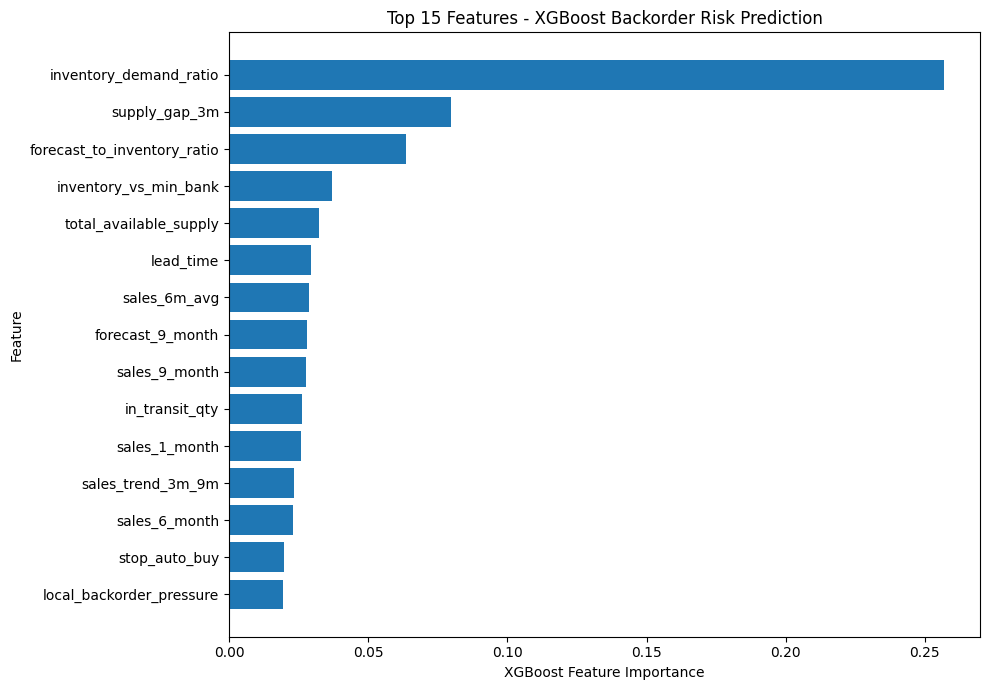


========== FILES SAVED ==========
/content/OptiChain/Research/Inventory_Optimization/07_Results/Tables/Backorder_XGBoost_Feature_Importance.csv
/content/OptiChain/Research/Inventory_Optimization/07_Results/Figures/Backorder_XGBoost_Top15_Feature_Importance.png

========== FEATURE IMPORTANCE SAVED ==========


In [25]:
# ============================================================
# STEP 17.14.1 — SAVE XGBOOST FEATURE IMPORTANCE
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

print("========== SAVING FEATURE IMPORTANCE ==========")

BASE_PATH = "/content/OptiChain/Research/Inventory_Optimization"

METRIC_DIR = os.path.join(
    BASE_PATH,
    "07_Results",
    "Metrics"
)

TABLE_DIR = os.path.join(
    BASE_PATH,
    "07_Results",
    "Tables"
)

FIGURE_DIR = os.path.join(
    BASE_PATH,
    "07_Results",
    "Figures"
)

os.makedirs(METRIC_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

# ------------------------------------------------------------
# 1. Save complete feature importance table
# ------------------------------------------------------------

FEATURE_IMPORTANCE_CSV = os.path.join(
    TABLE_DIR,
    "Backorder_XGBoost_Feature_Importance.csv"
)

feature_importance_df.to_csv(
    FEATURE_IMPORTANCE_CSV,
    index=False
)

# ------------------------------------------------------------
# 2. Create top-15 feature importance figure
# ------------------------------------------------------------

top15 = feature_importance_df.head(15).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top15["Feature"],
    top15["Importance"]
)

plt.xlabel("XGBoost Feature Importance")
plt.ylabel("Feature")
plt.title(
    "Top 15 Features - XGBoost Backorder Risk Prediction"
)

plt.tight_layout()

FEATURE_IMPORTANCE_FIGURE = os.path.join(
    FIGURE_DIR,
    "Backorder_XGBoost_Top15_Feature_Importance.png"
)

plt.savefig(
    FEATURE_IMPORTANCE_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n========== FILES SAVED ==========")
print(FEATURE_IMPORTANCE_CSV)
print(FEATURE_IMPORTANCE_FIGURE)

print("\n========== FEATURE IMPORTANCE SAVED ==========")

In [26]:
# ============================================================
# STEP 17.14.2 — UPDATE OPTICHAIN BACKUP ZIP
# ============================================================

import os
import shutil

SOURCE_DIR = "/content/OptiChain"

ZIP_BASE = "/content/OptiChain_Inventory_Optimization_Backup"

# Re-create ZIP with all current files
ZIP_PATH = shutil.make_archive(
    ZIP_BASE,
    "zip",
    "/content",
    "OptiChain"
)

print("=" * 70)
print("OPTICHAIN BACKUP UPDATED")
print("=" * 70)

print("\nZIP file:")
print(ZIP_PATH)

print(
    "\nZIP size:",
    round(os.path.getsize(ZIP_PATH) / (1024 ** 2), 2),
    "MB"
)

print("\nNew files included:")

print(
    "/Research/Inventory_Optimization/"
    "07_Results/Tables/"
    "Backorder_XGBoost_Feature_Importance.csv"
)

print(
    "/Research/Inventory_Optimization/"
    "07_Results/Figures/"
    "Backorder_XGBoost_Top15_Feature_Importance.png"
)

print("\n========== BACKUP UPDATE COMPLETE ==========")

OPTICHAIN BACKUP UPDATED

ZIP file:
/content/OptiChain_Inventory_Optimization_Backup.zip

ZIP size: 2.64 MB

New files included:
/Research/Inventory_Optimization/07_Results/Tables/Backorder_XGBoost_Feature_Importance.csv
/Research/Inventory_Optimization/07_Results/Figures/Backorder_XGBoost_Top15_Feature_Importance.png

========== BACKUP UPDATE COMPLETE ==========


In [28]:
import os

BASE_DIR = "/content/OptiChain"

csv_files = []

for root, dirs, files in os.walk(BASE_DIR):
    for file in files:
        if file.lower().endswith(".csv"):
            full_path = os.path.join(root, file)
            csv_files.append(full_path)

print(f"Found {len(csv_files)} CSV files:\n")

for i, path in enumerate(sorted(csv_files), 1):
    print(f"{i}. {path}")

Found 6 CSV files:

1. /content/OptiChain/Research/Inventory_Optimization/07_Results/Metrics/Backorder_Model_Comparison.csv
2. /content/OptiChain/Research/Inventory_Optimization/07_Results/Metrics/Final_Backorder_XGBoost_Test_Metrics.csv
3. /content/OptiChain/Research/Inventory_Optimization/07_Results/Metrics/XGBoost_Threshold_Optimization.csv
4. /content/OptiChain/Research/Inventory_Optimization/07_Results/Tables/Backorder_XGBoost_Confusion_Matrix.csv
5. /content/OptiChain/Research/Inventory_Optimization/07_Results/Tables/Backorder_XGBoost_Feature_Importance.csv
6. /content/OptiChain/Research/Inventory_Optimization/07_Results/Tables/Backorder_XGBoost_Test_Predictions.csv


In [29]:
# STEP 2 — Check which Inventory Optimization output variables exist

inventory_variables = [
    "inventory_df",
    "inventory_model_df",
    "inventory_parameters",
    "simulation_df",
    "product_day_forecast",
    "integrated_upstream_df",
    "forecast_policy_df",
    "forecast_risk_simulation_df",
    "forecast_risk_simulation_results_df",
    "forecast_risk_simulation_results_df"
]

print("Inventory output variables currently available:\n")

for var in inventory_variables:
    if var in globals():
        obj = globals()[var]
        try:
            print(f"✓ {var:<40} shape={obj.shape}")
        except:
            print(f"✓ {var:<40} available")
    else:
        print(f"✗ {var:<40} NOT AVAILABLE")

Inventory output variables currently available:

✗ inventory_df                             NOT AVAILABLE
✗ inventory_model_df                       NOT AVAILABLE
✗ inventory_parameters                     NOT AVAILABLE
✗ simulation_df                            NOT AVAILABLE
✗ product_day_forecast                     NOT AVAILABLE
✗ integrated_upstream_df                   NOT AVAILABLE
✗ forecast_policy_df                       NOT AVAILABLE
✗ forecast_risk_simulation_df              NOT AVAILABLE
✗ forecast_risk_simulation_results_df      NOT AVAILABLE
✗ forecast_risk_simulation_results_df      NOT AVAILABLE


In [30]:
import os

print("Searching /content for OptiChain notebooks...\n")

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.lower().endswith(".ipynb"):
            print(os.path.join(root, file))

Searching /content for OptiChain notebooks...

